#Data-driven optimization of PHB production by Rhodopseudomonas palustris using a hybrid machine learning and constraint-based metabolic modeling approach

Ejemplo de Optimización con el Modelo de R. palustris (iDT1294) from Tec-Campos et al., 2023 en COBRApy

Objetivo:
Maximizar la tasa de crecimiento y producción de PHA de R. palustris.

Pasos:
Instalación y carga del modelo: El modelo básico de R. palustris (iDT1294) from Tec-Campos et al., 2023.

## *Installation

In [ ]:
# Install cobrapy
!pip install -qq cobra escher networkx memote catboost

shell-init: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected
shell-init: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected
Traceback (most recent call last):
  File "/usr/local/bin/pip3", line 4, in <module>
    from pip._internal.cli.main import main
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main.py", line 11, in <module>
    from pip._internal.cli.autocompletion import autocomplete
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/autocompletion.py", line 10, in <module>
    from pip._internal.cli.main_parser import create_main_parser
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main_parser.py", line 9, in <module>
    from pip._internal.build_env import get_runnable_pip
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/build_env.py", line 19, in <module>
    from pip._internal.cli.spi

In [ ]:
# Check installation
!pip show cobra

shell-init: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected
shell-init: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected
Traceback (most recent call last):
  File "/usr/local/bin/pip3", line 4, in <module>
    from pip._internal.cli.main import main
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main.py", line 11, in <module>
    from pip._internal.cli.autocompletion import autocomplete
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/autocompletion.py", line 10, in <module>
    from pip._internal.cli.main_parser import create_main_parser
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main_parser.py", line 9, in <module>
    from pip._internal.build_env import get_runnable_pip
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/build_env.py", line 19, in <module>
    from pip._internal.cli.spi

## *Mount drive

In [ ]:
# Mount drive
from google.colab import drive
import os
import sys
import pandas as pd

drive_folder = "Genome_scale_metabolic_models_PNSB/Model_Tec_Campos_2023_RPiDT1294/rpalustris_pha_optimization/models"
def mount_drive():
  drive.mount('/content/driveDL', force_remount=True)
  os.chdir("/content/driveDL/My Drive/"+drive_folder)
mount_drive()

# Project root = current working directory
project_root = Path(os.getcwd())

Mounted at /content/driveDL


## *Load packages

In [ ]:
# load packages

import logging
from pathlib import Path

import cobra
from cobra import Reaction, Metabolite, Model, io
from cobra.io import (
    load_model, load_json_model, save_json_model,
    load_matlab_model, save_matlab_model,
    read_sbml_model, write_sbml_model
)
from cobra.util.solver import linear_reaction_coefficients

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import seaborn as sns
import json
import os
import math
import copy
from itertools import product
from tqdm import tqdm


In [ ]:
!python --version

Python 3.12.12


## *Load model

In [ ]:
print(project_root)


/content/driveDL/My Drive/Genome_scale_metabolic_models_PNSB/Model_Tec_Campos_2023_RPiDT1294/rpalustris_pha/model


In [ ]:
# Load models

# Directory where the model lives
base_model_dir = project_root / "base"
base_model_dir.mkdir(parents=True, exist_ok=True)

# Full path to the SBML file
base_model_path = base_model_dir / "model_rpalustris_comp_fixed.xml"

# Load model
model = io.read_sbml_model(
    str(base_model_path),
    use_fbc=False
)

print("Model loaded successfully")

Model loaded successfully


# Check default model tec_campos_iDT1294

In [ ]:
# Load model
model

Name,M_iDT1294
Memory address,784fbbf77350
Number of metabolites,2124
Number of reactions,2721
Number of genes,1294
Number of groups,117
Objective expression,1.0*BIOMASS__1 - 1.0*BIOMASS__1_reverse_063c7
Compartments,"cytoplasm, unknownCompartment4, periplasm, exterior"


In [ ]:
# Check model summary
model.summary() # BIOMASS__1 is the default objective function

Metabolite,Reaction,Flux,C-Number,C-Flux
actn__R[e],EX_actn__R_e,0.6784,4,12.28%
ca2[e],EX_ca2_e,1.03E-05,0,0.00%
cinnm[e],EX_cinnm_e,2.153,9,87.72%
cl[e],EX_cl_e,2.06E-05,0,0.00%
cobalt2[e],EX_cobalt2_e,4.533E-06,0,0.00%
fe3[e],EX_fe3_e,0.0337,0,0.00%
k[e],EX_k_e,1.366E-06,0,0.00%
mg2[e],EX_mg2_e,0.01097,0,0.00%
mn2[e],EX_mn2_e,1.554E-07,0,0.00%
na1[e],EX_na1_e,1.051E-07,0,0.00%


In [ ]:
# Check model compartments
model.compartments

{'c': 'cytoplasm',
 'u': 'unknownCompartment4',
 'p': 'periplasm',
 'e': 'exterior'}

## PHB reactions

In [ ]:
# Check reaction directly associated to PHB production
phb_rxn = model.reactions.get_by_id("PHBS_syn")
#print(phb_rxn.bounds)
print(phb_rxn.reaction)


3hbcoa__R[c] + phbg[c] --> PHB[c] + coa[c]


# *PHBV reactions

INdustry prefers Poly(3-hydroxybutyrate-co-3-hydroxyvalerate) (PHBV) with various 3-hydroxyvalerate (3HV) contents. Thus, adding the corresponding reactions is needed to map operational paramters with PHBV quality.


In [ ]:
# Test Code to find a metabolite.

find_a_metabolite = model.metabolites.get_by_id("phbg[c]")
print(find_a_metabolite.name)

Growing PHB granule


## *Version with independent monomers and granule sinks

In [ ]:
# Copy base model
model_phbv = model.copy()

In [ ]:
# Define all metabolites and reactions needed for PHBV production

# ---------- helper ----------
def safe_remove_rxn(m, rid):
    if rid in m.reactions:
        try:
            m.reactions.get_by_id(rid).remove_from_model()
            print(f"Removed old reaction {rid}")
        except Exception as e:
            print(f"Failed to remove {rid}: {e}")

def safe_add_metabolite(met):
    if met.id not in [x.id for x in model_phbv.metabolites]:
        model_phbv.add_metabolites([met])
        print(f"Added metabolite {met.id}")
    else:
        print(f"Metabolite {met.id} already present")

def safe_add_reaction(rxn):
    if rxn.id not in [r.id for r in model_phbv.reactions]:
        model_phbv.add_reactions([rxn])
        try:
            print(f"Added reaction {rxn.id}: {rxn.reaction}")
        except Exception:
            print(f"Added reaction {rxn.id}")
    else:
        print(f"Reaction {rxn.id} already present")

# ---------- 0) remove old/broken PHV/PHBV reaction if present ----------
safe_remove_rxn(model_phbv, "PHVS_syn")    # remove old version if it used phvg as substrate incorrectly
#safe_remove_rxn(model_phbv, "PHBV_syn")    # ensure no stray older PHBV definitions
safe_remove_rxn(model_phbv, "PHBVS_syn")   # we'll (re)create PHBVS_syn as monomer-based

# ---------- 1) Ensure core metabolites exist (use your IDs where available) ----------
# CoA, acetyl-CoA (accoa), propionyl-CoA, monomers, NADPH/NADP

# CoA
if "coa[c]" not in [m.id for m in model_phbv.metabolites]:
    safe_add_metabolite(Metabolite("coa[c]", name="Coenzyme A", compartment="c"))
else:
    print("coa[c] present")

# CoA
if "PHV[c]" not in [m.id for m in model_phbv.metabolites]:
    safe_add_metabolite(Metabolite("PHV[c]", name="PHV monomer", compartment="c"))
else:
    print("PHV[c] present")

# acetyl-CoA (common IDs vary)
if "accoa[c]" not in [m.id for m in model_phbv.metabolites]:
    if "accoa_c" in [m.id for m in model_phbv.metabolites]:
        print("accoa_c present (use this if needed)")
    else:
        safe_add_metabolite(Metabolite("accoa[c]", name="Acetyl-CoA", compartment="c"))
else:
    print("accoa[c] present")

# propionyl-CoA
#if "propionylcoa[c]" not in [m.id for m in model.metabolites]:
#    safe_add_metabolite(Metabolite("ppcoa[c]", name="Propionyl-CoA", compartment="c"))
#else:
#    print("propionylcoa[c] present")

# 3HB monomer
if "3hbcoa__R[c]" not in [m.id for m in model_phbv.metabolites]:
    safe_add_metabolite(Metabolite("3hbcoa__R[c]", formula="C25H38N7O18P3S", name="3-hydroxybutyryl-CoA (R)", compartment="c"))
else:
    print("3hbcoa__R[c] present")

# 3HV monomer
if "3hvcoa__R[c]" not in [m.id for m in model_phbv.metabolites]:
    safe_add_metabolite(Metabolite("3hvcoa__R[c]", formula="C26H41N7O18P3S", name="3-hydroxyvaleryl-CoA (R)", compartment="c"))
else:
    print("3hvcoa__R[c] present")

# intermediate 3-ketovaleryl-CoA
if "3ketoHVcoa[c]" not in [m.id for m in model_phbv.metabolites]:
    safe_add_metabolite(Metabolite("3ketoHVcoa[c]", formula="C26H41N7O18P3S", name="3-ketovaleryl-CoA", compartment="c"))
else:
    print("3ketoHVcoa[c] present")

# PHBV polymer pool
if "PHBV[c]" not in [m.id for m in model_phbv.metabolites]:
    safe_add_metabolite(Metabolite("PHBV[c]", name="PHBV polymer (average repeat)", compartment="c"))
else:
    print("PHBV[c] present")

# phbg / phvg granule pools (optional bookkeeping)
if "phbg[c]" not in [m.id for m in model_phbv.metabolites]:
    safe_add_metabolite(Metabolite("phbg[c]", name="PHB granule pool", compartment="c"))
else:
    print("phbg[c] present")

if "phvg[c]" not in [m.id for m in model_phbv.metabolites]:
    safe_add_metabolite(Metabolite("phvg[c]", name="PHV granule pool", compartment="c"))
else:
    print("phvg[c] present")

# NADPH / NADP detection (use existing model ids)
nadph_id = None
nadp_id = None
candidates = [m.id for m in model_phbv.metabolites]
for candidate in ["nadph[c]","nadph_c[u]","nadph_c","nadph"]:
    if candidate in candidates:
        nadph_id = candidate
        break
for candidate in ["nadp[c]","nadp_c[u]","nadp_c","nadp"]:
    if candidate in candidates:
        nadp_id = candidate
        break

if nadph_id is None or nadp_id is None:
    raise RuntimeError("NADPH/NADP not found. Expected one of 'nadph[c]'/'nadph_c[u]' and 'nadp[c]'/'nadp_c[u]'.")
print(f"NADPH id used: {nadph_id}, NADP id used: {nadp_id}")

# ---------- 2) Add lumped propionyl-CoA synthesis reaction if missing ----------
if "propionylcoa_syn" not in model_phbv.reactions:
    if "pyr[c]" not in [m.id for m in model_phbv.metabolites]:
        safe_add_metabolite(Metabolite("pyr[c]", name="Pyruvate", compartment="c"))
    propcoa = model_phbv.metabolites.get_by_id("ppcoa[c]")
    prop_rxn = Reaction('propionylcoa_syn')
    prop_rxn.name = 'Propionyl-CoA synthesis (lumped from pyr)'
    prop_rxn.lower_bound = 0
    prop_rxn.upper_bound = 1000
    prop_rxn.add_metabolites({
        model_phbv.metabolites.get_by_id('h[c]') : -5, #-9.0,
        model_phbv.metabolites.get_by_id('pyr[c]') : -1.0,
        model_phbv.metabolites.get_by_id('coa[c]'): -1.0,
        model_phbv.metabolites.get_by_id('ppcoa[c]'): 1.0,
        model_phbv.metabolites.get_by_id('h2o[c]'): 2.0,
    })
    safe_add_reaction(prop_rxn)
else:
    print("propionylcoa_syn present")

# ---------- 3) Add condensation to 3-keto-valeryl-CoA (β-ketothiolase, lumped) ----------
if "3ketoHVcoa_syn" not in model_phbv.reactions:
    rxn_keto = Reaction("3ketoHVcoa_syn")
    rxn_keto.name = "3-ketovaleryl-CoA synthesis (β-ketothiolase, lumped)"
    rxn_keto.lower_bound = 0
    rxn_keto.upper_bound = 1000
    rxn_keto.add_metabolites({
        model_phbv.metabolites.get_by_id("ppcoa[c]"): -1.0,
        model_phbv.metabolites.get_by_id("accoa[c]"):       -1.0,
        model_phbv.metabolites.get_by_id("3ketoHVcoa[c]"):   1.0,
        model_phbv.metabolites.get_by_id("coa[c]"):          1.0,  # thiolase releases CoA
    })
    safe_add_reaction(rxn_keto)
else:
    print("3ketoHVcoa_syn present")

# ---------- 4) Add NADPH-dependent reduction to 3HV-CoA ----------
if "3hvcoa_syn" not in model_phbv.reactions:
    rxn_hv = Reaction("3hvcoa_syn")
    rxn_hv.name = "3-hydroxyvaleryl-CoA synthesis (NADPH-dependent reductase, lumped)"
    rxn_hv.lower_bound = 0
    rxn_hv.upper_bound = 1000
    rxn_hv.add_metabolites({
        model_phbv.metabolites.get_by_id("3ketoHVcoa[c]"):   -1.0,
        model_phbv.metabolites.get_by_id("3hvcoa__R[c]"):     1.0,
        model_phbv.metabolites.get_by_id(nadph_id):          -1.0,
        model_phbv.metabolites.get_by_id(nadp_id):            1.0,
    })
    safe_add_reaction(rxn_hv)
else:
    print("3hvcoa_syn present")

# ---------- 5) PHV synthetase (optional homopolymer placement into phvg) ----------
if "PHVS_syn" not in model_phbv.reactions:
    phv_rxn = Reaction("PHVS_syn")
    phv_rxn.name = "PHV synthetase"
    phv_rxn.lower_bound = 0
    phv_rxn.upper_bound = 1000
    phv_rxn.add_metabolites({
        model_phbv.metabolites.get_by_id("3hvcoa__R[c]"): -1.0,
        model_phbv.metabolites.get_by_id("phvg[c]"):      -1.0,
        model_phbv.metabolites.get_by_id("PHV[c]"):        1.0,
        model_phbv.metabolites.get_by_id("coa[c]"):        1.0
    })
    safe_add_reaction(phv_rxn)
else:
    print("PHVS_syn present")

# ---------- 6) PHB synthetase (ensure exists, keep your pattern) ----------
if "PHBS_syn" not in model_phbv.reactions:
    phbs = Reaction("PHBS_syn")
    phbs.name = "PHB synthetase"
    phbs.lower_bound = 0
    phbs.upper_bound = 1000
    phbs.add_metabolites({
        model_phbv.metabolites.get_by_id("3hbcoa__R[c]"): -1.0,
        model_phbv.metabolites.get_by_id("phbg[c]"):      -1.0,
        model_phbv.metabolites.get_by_id("PHB[c]"):        1.0,
        model_phbv.metabolites.get_by_id("coa[c]"):        1.0
    })
    safe_add_reaction(phbs)
else:
    print("PHBS_syn present")

# ---------- 7) PHBV copolymer synthesis (MONOMER-BASED) ----------
ratio_PHB = 0.8
ratio_PHV = 0.2
if math.isclose(ratio_PHB + ratio_PHV, 0.0):
    raise RuntimeError("ratio_PHB + ratio_PHV must be > 0.")

if "PHBVS_syn" not in model_phbv.reactions:
    phbv_rxn = Reaction("PHBVS_syn")
    phbv_rxn.name = "PHBV copolymer synthesis (from 3HB-CoA + 3HV-CoA)"
    phbv_rxn.lower_bound = 0
    phbv_rxn.upper_bound = 1
    phbv_rxn.add_metabolites({
        model_phbv.metabolites.get_by_id("3hbcoa__R[c]"): -ratio_PHB,
        model_phbv.metabolites.get_by_id("3hvcoa__R[c]"): -ratio_PHV,
        model_phbv.metabolites.get_by_id("PHBV[c]"):       1.0,
        model_phbv.metabolites.get_by_id("coa[c]"):        (ratio_PHB + ratio_PHV)
    })
    safe_add_reaction(phbv_rxn)
else:
    print("PHBVS_syn present (monomer-based)")

# ---------- 8) Add reversible sinks for phbg/phvg if you want them available ----------
if "SK_phbg_c" not in model_phbv.reactions:
    sk_phbg = Reaction("SK_phbg_c")
    sk_phbg.name = "phbg sink (allow granule pool to exist)"
    sk_phbg.lower_bound = -1000
    sk_phbg.upper_bound = 1000
    sk_phbg.add_metabolites({model_phbv.metabolites.get_by_id("phbg[c]"): -1.0})
    safe_add_reaction(sk_phbg)
else:
    print("SK_phbg_c present")
if "SK_phvg_c" not in model_phbv.reactions:
    sk_phvg = Reaction("SK_phvg_c")
    sk_phvg.name = "phvg sink (allow granule pool to exist)"
    sk_phvg.lower_bound = -1000
    sk_phvg.upper_bound = 1000
    sk_phvg.add_metabolites({model_phbv.metabolites.get_by_id("phvg[c]"): -1.0})
    safe_add_reaction(sk_phvg)
else:
    print("SK_phvg_c present")

# ---------- 9) Add reversible sink for PHBV (your working quick-fix) ----------
if "SK_phbv_c" not in model_phbv.reactions:
    sk_phbv = Reaction("SK_phbv_c")
    sk_phbv.name = "PHBV sink (allow polymer pool to exist)"
    sk_phbv.lower_bound = -1000
    sk_phbv.upper_bound = 1000
    sk_phbv.add_metabolites({model_phbv.metabolites.get_by_id("PHBV[c]") : -1.0 })
    model_phbv.add_reactions([sk_phbv])
    print("Added SK_phbv_c (reversible sink for PHBV[c])")
else:
    rx = model_phbv.reactions.get_by_id("SK_phbv_c")
    rx.lower_bound = -1000
    rx.upper_bound = 1000
    print("SK_phbv_c already present and enabled")

# ---------- 10) Mass/charge balance checks (formulas may be missing for synthetic metabolites) ----------
print("\n-- Mass/charge balance checks --")
for rid in ["propionylcoa_syn","3ketoHVcoa_syn","3hvcoa_syn","PHVS_syn","PHBS_syn","PHBVS_syn"]:
    if rid in model_phbv.reactions:
        try:
            imb = model_phbv.reactions.get_by_id(rid).check_mass_balance()
            print(f"{rid}: imbalance -> {imb}")
        except Exception as e:
            print(f"{rid}: check_mass_balance failed: {e}")
    else:
        print(f"{rid}: NOT IN MODEL")

# Demand reaction for PHV

dm_phv = Reaction("DM_PHV_c")
dm_phv.name = "PHV Demand reaction"
dm_phv.lower_bound = 0
dm_phv.upper_bound = 1000

phv = model_phbv.metabolites.get_by_id("PHV[c]")
dm_phv.add_metabolites({phv: -1})

model_phbv.add_reactions([dm_phv])


# ---------- 11) Quick FBA smoke-tests ----------
# allow common uptakes so precursors are available (adjust to your use-case)
#if "EX_ac_e" in model.reactions:
#    model.reactions.EX_ac_e.lower_bound = -1000
#if "EX_pyr_e" in model.reactions:
#    model.reactions.EX_pyr_e.lower_bound = -1000
#if "EX_glc__D_e" in model.reactions:
#    model.reactions.EX_glc__D_e.lower_bound = -1000
#if "EX_prop_e" in model.reactions:
#    model.reactions.EX_prop_e.lower_bound = -1000

print("\n-- FBA tests (maximize specific reactions) --")
to_test = ["propionylcoa_syn","3hvcoa_syn","PHVS_syn","PHBS_syn","PHBVS_syn"]
for rid in to_test:
    if rid in model_phbv.reactions:
        model_phbv.objective = model_phbv.reactions.get_by_id(rid)
        sol = model_phbv.optimize()
        print(f"{rid:20s} status={sol.status:8s} flux={sol.objective_value}")
    else:
        print(f"{rid:20s} NOT IN MODEL")

# ---------- 12) Optional: attempt to add composition constraint (guarded) ----------
# Note: some COBRApy versions/solvers don't provide add_linear_constraint; this is best-effort.
#try:
#    if ("PHVS_syn" in model.reactions) and ("PHBS_syn" in model.reactions):
#        v_HV_var = model.reactions.PHVS_syn.forward_variable
#        v_HB_var = model.reactions.PHBS_syn.forward_variable
#        constraint_expr = 4 * v_HV_var - 1 * v_HB_var  # enforce ~20% HV if scaled 4:1
#        # try remove existing named constraint if present
 #       try:
 #           if hasattr(model.solver, "constraints") and "enforce_20pct_HV" in model.solver.constraints:
 #               model.solver.remove(model.solver.constraints.get("enforce_20pct_HV"))
 #       except Exception:
 #           pass
 #       # try adding constraint using solver API
 #       try:
 #           model.solver.add_linear_constraint(constraint_expr, lb=0, ub=0, name="enforce_20pct_HV")
 #           print("Added linear constraint to enforce ~20% HV (using PHVS_syn & PHBS_syn fluxes)")
 #       except Exception as e:
 #           print("Could not add linear constraint with model.solver.add_linear_constraint():", e)
 #           print("You may need to use optlang API for your COBRApy/solver version.")
#except Exception as e:
#    print("Composition constraint block failed:", e)

## ---------- 13) How to read final PHBV composition ----------
print("\n-- How to compute HV fraction from the solution --")
if "PHBVS_syn" in model_phbv.reactions:
    v_phbv = model_phbv.reactions.PHBVS_syn.flux
    # monomer-based reaction: v_HB_monomer = ratio_PHB * v_phbv
    v_HB_monomer = ratio_PHB * v_phbv
    v_HV_monomer = ratio_PHV * v_phbv
    f_HV = (v_HV_monomer / (v_HV_monomer + v_HB_monomer)) if (abs(v_HV_monomer + v_HB_monomer) > 0) else None
    print(f"PHBVS_syn flux={v_phbv}; inferred monomer f_HV = {f_HV} (== configured ratio {ratio_PHV/(ratio_PHV+ratio_PHB):.3f})")

# If you track homopolymers:
if ("PHVS_syn" in model_phbv.reactions) and ("PHBS_syn" in model_phbv.reactions):
    v_HV = model_phbv.reactions.PHVS_syn.flux
    v_HB = model_phbv.reactions.PHBS_syn.flux
    f_HV_homopolymer = (v_HV / (v_HV + v_HB)) if (abs(v_HV + v_HB) > 0) else None
    print(f"PHVS_syn flux={v_HV}, PHBS_syn flux={v_HB}; measured f_HV (homopolymer path) = {f_HV_homopolymer}")

# ---------- 14) Extra quick test: ensure PHBV sink present and try PHBVS_syn max (your quick-fix re-test) ----------
# Ensure SK_phbv_c exists and is open
if "SK_phbv_c" not in model_phbv.reactions:
    sk_phbv = Reaction("SK_phbv_c")
    sk_phbv.name = "PHBV sink (allow polymer pool to exist)"
    sk_phbv.lower_bound = -1000.0
    sk_phbv.upper_bound = 1000.0
    sk_phbv.add_metabolites({model_phbv.metabolites.get_by_id("PHBV[c]") : -1.0 })
    model_phbv.add_reactions([sk_phbv])
    print("Added SK_phbv_c (reversible sink for PHBV[c])")
else:
    rx = model_phbv.reactions.get_by_id("SK_phbv_c")
    rx.lower_bound = -1000.0
    rx.upper_bound = 1000.0
    print("SK_phbv_c enabled")

# Enable PHBVS_syn positive flux
if "PHBVS_syn" in model_phbv.reactions:
    model_phbv.reactions.get_by_id("PHBVS_syn").lower_bound = 0.02
    model_phbv.reactions.get_by_id("PHBVS_syn").upper_bound = 1000
else:
    print("PHBVS_syn missing -- check previous steps")

# Optional: set reasonable uptakes
#for ex in ["EX_glc__D_e","EX_pyr_e","EX_ac_e","EX_prop_e"]:
#    if ex in model.reactions:
#        model.reactions.get_by_id(ex).lower_bound = -10.0

# Disable homopolymer synthetases to avoid competition (temporary)
#"PHVS_syn"
#for rid in ["PHVS_syn", "PHBS_syn"]:
#    if rid in model.reactions:
#        model.reactions.get_by_id(rid).lower_bound = 0
#        model.reactions.get_by_id(rid).upper_bound = 0

# Maximize PHBVS_syn and print precursor fluxes
if "PHBVS_syn" in model_phbv.reactions:
    model_phbv.objective = model_phbv.reactions.get_by_id("PHBVS_syn")
    sol = model_phbv.optimize()
    print(f"\nMaximizing PHBVS_syn: status={sol.status}, flux={sol.objective_value}")
    for r in ["propionylcoa_syn", "3ketoHVcoa_syn", "3hvcoa_syn", "PHBVS_syn", "PHVS_syn", "PHBS_syn", "SK_phvg_c", "SK_phbv_c", "SK_phbg_c"]:
        if r in model_phbv.reactions:
            try:
                print(f"{r:20s} flux = {model_phbv.reactions.get_by_id(r).flux}")
            except Exception:
                print(f"{r:20s} flux = (error reading flux)")
else:
    print("PHBVS_syn not present for final test")

print("\n-- Done. Review printed fluxes & mass-balance outputs above. --")


coa[c] present
Added metabolite PHV[c]
accoa[c] present
3hbcoa__R[c] present
Added metabolite 3hvcoa__R[c]
Added metabolite 3ketoHVcoa[c]
Added metabolite PHBV[c]
phbg[c] present
Added metabolite phvg[c]
NADPH id used: nadph[c], NADP id used: nadp[c]
Added reaction propionylcoa_syn: coa[c] + 5 h[c] + pyr[c] --> 2.0 h2o[c] + ppcoa[c]
Added reaction 3ketoHVcoa_syn: accoa[c] + ppcoa[c] --> 3ketoHVcoa[c] + coa[c]
Added reaction 3hvcoa_syn: 3ketoHVcoa[c] + nadph[c] --> 3hvcoa__R[c] + nadp[c]
Added reaction PHVS_syn: 3hvcoa__R[c] + phvg[c] --> PHV[c] + coa[c]
PHBS_syn present
Added reaction PHBVS_syn: 0.8 3hbcoa__R[c] + 0.2 3hvcoa__R[c] --> PHBV[c] + coa[c]
SK_phbg_c present
Added reaction SK_phvg_c: phvg[c] <=> 
Added SK_phbv_c (reversible sink for PHBV[c])

-- Mass/charge balance checks --
propionylcoa_syn: imbalance -> {}
3ketoHVcoa_syn: imbalance -> {'H': 3.0}
3hvcoa_syn: imbalance -> {'H': -1.0}
PHVS_syn: imbalance -> {'C': -5.0, 'H': -9.0, 'O': -2.0}
PHBS_syn: imbalance -> {}
PHBVS_syn

Note:

*   GEM uses deprotonated version of the metabolites formulas.
*   Unbalance in formulas does not affect flux results.


# *Opt: save model with phbv reactions

In [ ]:
# Directory where the model lives
phbv_model_dir = project_root / "phbv"

# Ensure folder exists
phbv_model_dir.mkdir(parents=True, exist_ok=True)

# Target file
phbv_model_file = phbv_model_dir / "model_rpalustris_comp_fixed_PHBV.xml"

# Save COBRA model
cobra.io.write_sbml_model(model_phbv, str(phbv_model_file))


## Version with PHBV direct polymerization

No granules sink added

In [ ]:
# Define all metabolites and reactions needed for PHBV production

# ---------- helper ----------
def safe_remove_rxn(m, rid):
    if rid in m.reactions:
        try:
            m.reactions.get_by_id(rid).remove_from_model()
            print(f"Removed old reaction {rid}")
        except Exception as e:
            print(f"Failed to remove {rid}: {e}")

def safe_add_metabolite(met):
    if met.id not in [x.id for x in model.metabolites]:
        model.add_metabolites([met])
        print(f"Added metabolite {met.id}")
    else:
        print(f"Metabolite {met.id} already present")

def safe_add_reaction(rxn):
    if rxn.id not in [r.id for r in model.reactions]:
        model.add_reactions([rxn])
        try:
            print(f"Added reaction {rxn.id}: {rxn.reaction}")
        except Exception:
            print(f"Added reaction {rxn.id}")
    else:
        print(f"Reaction {rxn.id} already present")

# ---------- 0) remove old/broken PHV/PHBV reaction if present ----------
safe_remove_rxn(model, "PHVS_syn")    # remove old version if it used phvg as substrate incorrectly
safe_remove_rxn(model, "PHBV_syn")    # ensure no stray older PHBV definitions
safe_remove_rxn(model, "PHBVS_syn")   # we'll (re)create PHBVS_syn as monomer-based

# ---------- 1) Ensure core metabolites exist (use your IDs where available) ----------
# CoA, acetyl-CoA (accoa), propionyl-CoA, monomers, NADPH/NADP

# CoA
#if "coa[c]" not in [m.id for m in model.metabolites]:
#    safe_add_metabolite(Metabolite("coa[c]", name="Coenzyme A", compartment="c"))
#else:
#    print("coa[c] present")

# acetyl-CoA (common IDs vary)
#if "accoa[c]" not in [m.id for m in model.metabolites]:
#    print("accoa[c] NOT present")
#    safe_add_metabolite(Metabolite("accoa[c]", name="Acetyl-CoA", compartment="c"))
#else:
#    print("accoa[c] present")

# propionyl-CoA
#if "ppcoa[c]" not in [m.id for m in model.metabolites]:
#    print("ppcoa[c] NOT present")
#    safe_add_metabolite(Metabolite("ppcoa[c]", name="Propionyl-CoA", compartment="c"))
#else:
#    print("ppcoa[c] present")

# 3HB monomer
#if "3hbcoa__R[c]" not in [m.id for m in model.metabolites]:
#    safe_add_metabolite(Metabolite("3hbcoa__R[c]", name="3-hydroxybutyryl-CoA (R)", compartment="c"))
#else:
#    print("3hbcoa__R[c] present")

# 3HV monomer
if "3hvcoa__R[c]" not in [m.id for m in model.metabolites]:
    safe_add_metabolite(Metabolite("3hvcoa__R[c]", formula="C26H44N7O18P3S", name="3-hydroxyvaleryl-CoA (R)", compartment="c"))
else:
    print("3hvcoa__R[c] present")

# intermediate 3-ketovaleryl-CoA
if "3ketoHVcoa[c]" not in [m.id for m in model.metabolites]:
    safe_add_metabolite(Metabolite("3ketoHVcoa[c]", formula= "C26H41N7O18P3S", name="3-ketovaleryl-CoA", compartment="c"))
else:
    print("3ketoHVcoa[c] present")

# PHBV polymer pool
if "phbvg[c]" not in [m.id for m in model.metabolites]:
    safe_add_metabolite(Metabolite("phbvg[c]", name="PHBV granule", compartment="c"))
else:
    print("phbvg[c] present")

# PHBV polymer pool
if "PHBV[c]" not in [m.id for m in model.metabolites]:
    safe_add_metabolite(Metabolite("PHBV[c]", name="PHBV polymer (average C repeat)", compartment="c"))
else:
    print("PHBV[c] present")


# NADPH / NADP detection (use existing model ids)
nadph_id = None
nadp_id = None
candidates = [m.id for m in model.metabolites]
for candidate in ["nadph[c]","nadph_c[u]","nadph_c","nadph"]:
    if candidate in candidates:
        nadph_id = candidate
        break
for candidate in ["nadp[c]","nadp_c[u]","nadp_c","nadp"]:
    if candidate in candidates:
        nadp_id = candidate
        break

if nadph_id is None or nadp_id is None:
    raise RuntimeError("NADPH/NADP not found. Expected one of 'nadph[c]'/'nadph_c[u]' and 'nadp[c]'/'nadp_c[u]'.")
print(f"NADPH id used: {nadph_id}, NADP id used: {nadp_id}")


# ---------- 2) Add lumped propionyl-CoA synthesis reaction if missing ----------
if "propionylcoa_syn" not in model.reactions:
  prop_rxn = Reaction('propionylcoa_syn')
  prop_rxn.name = 'Propionyl-CoA synthesis (lumped from pyr)'
  prop_rxn.formula = 'R'
  prop_rxn.lower_bound = 0
  prop_rxn.upper_bound = 1000
  prop_rxn.add_metabolites({
      model.metabolites.get_by_id('h[c]') : -5.0,
      model.metabolites.get_by_id('pyr[c]') : -1.0,
      model.metabolites.get_by_id('coa[c]'): -1.0,
       model.metabolites.get_by_id('ppcoa[c]'): 1.0,
      model.metabolites.get_by_id('h2o[c]'): 2.0,
  })
  safe_add_reaction(prop_rxn)
else:
  print("propionylcoa_syn present")


# ---------- 3) Add condensation to 3-keto-valeryl-CoA (β-ketothiolase, lumped) ----------
if "3ketoHVcoa_syn" not in model.reactions:
    rxn_keto = Reaction("3ketoHVcoa_syn")
    rxn_keto.name = "3-ketovaleryl-CoA synthesis (β-ketothiolase, lumped)"
    rxn_keto.formula = 'R'
    rxn_keto.lower_bound = 0
    rxn_keto.upper_bound = 1000
    rxn_keto.add_metabolites({
        model.metabolites.get_by_id("ppcoa[c]"): -1.0,
        model.metabolites.get_by_id("accoa[c]"):       -1.0,
        model.metabolites.get_by_id("3ketoHVcoa[c]"):   1.0,
        model.metabolites.get_by_id("coa[c]"):          1.0,  # thiolase releases CoA
        model.metabolites.get_by_id("h[c]"):         -3.0,

    })
    safe_add_reaction(rxn_keto)
else:
    print("3ketoHVcoa_syn present")

# ---------- 4) Add NADPH-dependent reduction to 3HV-CoA ----------
hv_mon_id = "3hvcoa__R[c]"
if "3hvcoa_syn" not in model.reactions:
    rxn_hv = Reaction("3hvcoa_syn")
    rxn_hv.name = "3-hydroxyvaleryl-CoA synthesis (NADPH-dependent reductase, lumped)"
    rxn_hv.lower_bound = 0
    rxn_hv.upper_bound = 1000
    rxn_hv.formula = 'R'
    rxn_hv.add_metabolites({
        model.metabolites.get_by_id("3ketoHVcoa[c]"): -1.0,
        model.metabolites.get_by_id(hv_mon_id):      1.0,
        model.metabolites.get_by_id(nadph_id):      -1.0,
        model.metabolites.get_by_id(nadp_id):        1.0,
        model.metabolites.get_by_id("h[c]"):         -2.0,
    })
    safe_add_reaction(rxn_hv)
else:
    print("3hvcoa_syn present")


# PHBV copolymer synthesis (MONOMER-BASED) ----------
ratio_PHB = 0.8
ratio_PHV = 0.2
if math.isclose(ratio_PHB + ratio_PHV, 0.0):
    raise RuntimeError("ratio_PHB + ratio_PHV must be > 0.")

if "PHBVS_syn" not in model.reactions:
    phbv_rxn = Reaction("PHBVS_syn")
    phbv_rxn.name = "PHBV copolymer synthesis (from 3HB-CoA + 3HV-CoA)"
    phbv_rxn.lower_bound = 0
    phbv_rxn.upper_bound = 1000
    phbv_rxn.add_metabolites({
        model.metabolites.get_by_id("3hbcoa__R[c]"): -ratio_PHB,
        model.metabolites.get_by_id("3hvcoa__R[c]"): -ratio_PHV,
        model.metabolites.get_by_id("phbvg[c]"):       -1.0,
        model.metabolites.get_by_id("PHBV[c]"):       1.0,
        model.metabolites.get_by_id("coa[c]"):        (ratio_PHB + ratio_PHV)
    })
    safe_add_reaction(phbv_rxn)
else:
    print("PHBVS_syn present (monomer-based)")


# Demand ppcoa reaction for testing ppcoa SINK
#DM_ppcoa = Reaction("DM_ppcoa")
#DM_ppcoa.lower_bound = 0
#DM_ppcoa.upper_bound = 1000
#DM_ppcoa.add_metabolites({model.metabolites.get_by_id("ppcoa[c]"): -1})
#model.add_reactions([DM_ppcoa])

if "DM_phbvg" not in model.reactions:
    dm = Reaction("DM_phbvg")
    dm.name = "PHBV granule demand"
    dm.lower_bound = 0.0
    dm.upper_bound = 1000.0
    dm.add_metabolites({ model.metabolites.get_by_id("phbvg[c]"): -1.0 })
    model.add_reactions([dm])
    print("Added DM_phbvg (granule drain)")
else:
    print("DM_phbvg present")



# ---------- 9) Add reversible sink for PHBV (your working quick-fix) ----------
if "SK_phbvg_c" not in model.reactions:
    sk = Reaction("SK_phbvg_c")
    sk.name = "PHBV sink reaction"
    sk.lower_bound = -1000.0     # allow creation of phbg_c
    sk.upper_bound = 1000.0      # allow removal of phbg_c
    sk.add_metabolites({ model.metabolites.get_by_id("phbvg[c]"): -1.0 })
    model.add_reactions([sk])
    print("Added SK_phbvg_c (reversible sink for phbvg[c])")
else:
    rx = model.reactions.get_by_id("SK_phbvg_c")
    rx.lower_bound = -1000.0
    rx.upper_bound = 1000.0
    print("SK_phbvg_c already present and enabled")


# ---------- 10) Mass/charge balance checks (formulas may be missing for synthetic metabolites) ----------
print("\n-- Mass/charge balance checks --")
for rid in ["propionylcoa_syn","3ketoHVcoa_syn","3hvcoa_syn","PHBS_syn","AACOAR_syn", "PHBVS_syn"]:
    if rid in model.reactions:
        try:
            imb = model.reactions.get_by_id(rid).check_mass_balance()
            print(f"{rid}: imbalance -> {imb}")
        except Exception as e:
            print(f"{rid}: check_mass_balance failed: {e}")
    else:
        print(f"{rid}: NOT IN MODEL")

# ---------- 11) Quick FBA smoke-tests ----------
# allow common uptakes so precursors are available (adjust to your use-case)
if "EX_ac_e" in model.reactions:
    model.reactions.EX_ac_e.lower_bound = -1000
if "EX_pyr_e" in model.reactions:
    model.reactions.EX_pyr_e.lower_bound = -1000
if "EX_glc__D_e" in model.reactions:
    model.reactions.EX_glc__D_e.lower_bound = -1000
if "EX_prop_e" in model.reactions:
    model.reactions.EX_prop_e.lower_bound = -1000

print("\n-- FBA tests (maximize specific reactions) --")


to_test = ["propionylcoa_syn","3ketoHVcoa_syn","3hvcoa_syn", "PHBS_syn", "PHBVS_syn", "EX_pyr_e"]
for rid in to_test:
    if rid in model.reactions:
        model.objective = model.reactions.get_by_id(rid)
        sol = model.optimize()
        print(f"{rid:20s} status={sol.status:8s} flux={sol.objective_value}")
    else:
        print(f"{rid:20s} NOT IN MODEL")


#  Read final PHBV composition ----------
print("\n-- How to compute HV fraction from the solution --")
if "PHBVS_syn" in model.reactions:
    v_phbv = model.reactions.PHBVS_syn.flux
    # monomer-based reaction: v_HB_monomer = ratio_PHB * v_phbv
    v_HB_monomer = ratio_PHB * v_phbv
    v_HV_monomer = ratio_PHV * v_phbv
    f_HV = (v_HV_monomer / (v_HV_monomer + v_HB_monomer)) if (abs(v_HV_monomer + v_HB_monomer) > 0) else None
    print(f"PHBVS_syn flux={v_phbv}; inferred monomer f_HV = {f_HV} (== configured ratio {ratio_PHV/(ratio_PHV+ratio_PHB):.3f})")


# Enable PHBVS_syn positive flux
if "PHBVS_syn" in model.reactions:
    model.reactions.get_by_id("PHBVS_syn").lower_bound = 0
    model.reactions.get_by_id("PHBVS_syn").upper_bound = 1000
else:
    print("PHBVS_syn missing -- check previous steps")

# Optional: set reasonable uptakes
#for ex in ["EX_glc__D_e","EX_pyr_e","EX_ac_e","EX_prop_e"]:
#    if ex in model.reactions:
#        model.reactions.get_by_id(ex).lower_bound = -10.0


# Disable homopolymer synthetases to avoid competition (temporary)
for rid in ["PHBS_syn","PHVS_syn"]:
    if rid in model.reactions:
        model.reactions.get_by_id(rid).lower_bound = 0
        model.reactions.get_by_id(rid).upper_bound = 0

# Maximize PHBVS_syn and print precursor fluxes
if "PHBVS_syn" in model.reactions:
    model.objective = model.reactions.get_by_id("PHBVS_syn")
    sol = model.optimize()
    print(f"\nMaximizing PHBVS_syn: status={sol.status}, flux={sol.objective_value}")
    for r in ["propionylcoa_syn","3ketoHVcoa_syn","3hvcoa_syn", "PHBS_syn", "PHBVS_syn"]:
        if r in model.reactions:
            try:
                print(f"{r:20s} flux = {model.reactions.get_by_id(r).flux}")
            except Exception:
                print(f"{r:20s} flux = (error reading flux)")
else:
    print("PHBVS_syn not present for final test")

print("\n-- Done. Review printed fluxes & mass-balance outputs above. --")


Removed old reaction PHBVS_syn
3hvcoa__R[c] present
3ketoHVcoa[c] present
phbvg[c] present
PHBV[c] present
NADPH id used: nadph[c], NADP id used: nadp[c]
propionylcoa_syn present
3ketoHVcoa_syn present
3hvcoa_syn present
Added reaction PHBVS_syn: 0.8 3hbcoa__R[c] + 0.2 3hvcoa__R[c] + phbvg[c] --> PHBV[c] + coa[c]
DM_phbvg present
SK_phbvg_c already present and enabled

-- Mass/charge balance checks --
propionylcoa_syn: imbalance -> {}
3ketoHVcoa_syn: imbalance -> {}
3hvcoa_syn: imbalance -> {}
PHBS_syn: imbalance -> {}
AACOAR_syn: imbalance -> {}
PHBVS_syn: imbalance -> {'C': -4.199999999999999, 'H': -7.200000000000003, 'O': -2.0}

-- FBA tests (maximize specific reactions) --
propionylcoa_syn     status=optimal  flux=0.0
3ketoHVcoa_syn       status=optimal  flux=0.0
3hvcoa_syn           status=optimal  flux=0.0
PHBS_syn             status=optimal  flux=0.0
PHBVS_syn            status=optimal  flux=0.0
EX_pyr_e             status=optimal  flux=1000.0

-- How to compute HV fraction from

In [ ]:
# print likely relevant metabolite ids
print("Candidates (3hb):", [m.id for m in model.metabolites if "3hb" in m.id.lower()])
print("Candidates (3hv):", [m.id for m in model.metabolites if "3hv" in m.id.lower()])
print("Candidates (ppcoa/propionyl):", [m.id for m in model.metabolites if "ppcoa" in m.id.lower() or "propionyl" in m.id.lower()])
print("Candidates (phbvg/PHBV):", [m.id for m in model.metabolites if "phbvg" in m.id.lower() or "phbv" in m.id.lower()])
print("NADPH/NADP ids:", [m.id for m in model.metabolites if "nadph" in m.id.lower() or "nadp" in m.id.lower()])

# show which reactions produce each monomer (products)
def producers(met_id):
    prods = []
    for r in model.reactions:
        coeff = r.metabolites.get(model.metabolites.get_by_id(met_id), 0) if met_id in [m.id for m in model.metabolites] else 0
        if coeff > 0:
            prods.append((r.id, r.reaction))
    return prods

for mid in ["3hbcoa__R[c]", "3hvcoa__R[c]", "ppcoa[c]"]:
    if mid in [m.id for m in model.metabolites]:
        print(f"\nProducers of {mid}:")
        for r in producers(mid):
            print(" ", r)
    else:
        print(f"\n{mid} NOT in model")


Candidates (3hb): ['3hbutACP[c]', '3hbcoa__R[c]', '3hbcoa[c]', '3hbycoa[c]', '3hbz[e]', '3hbz[p]', '3hbz[c]']
Candidates (3hv): ['3hvcoa__R[c]']
Candidates (ppcoa/propionyl): ['ppcoa[c]']
Candidates (phbvg/PHBV): ['phbvg[c]', 'PHBV[c]']
NADPH/NADP ids: ['nadph[c]', 'nadp[c]', 'nadphx__R[c]', 'nadphx__S[c]']

Producers of 3hbcoa__R[c]:
  ('AACOAR_syn', 'aacoa[c] + h[c] + nadph[c] --> 3hbcoa__R[c] + nadp[c]')

Producers of 3hvcoa__R[c]:
  ('3hvcoa_syn', '3ketoHVcoa[c] + 2.0 h[c] + nadph[c] --> 3hvcoa__R[c] + nadp[c]')

Producers of ppcoa[c]:
  ('ACCOAL', 'atp[c] + coa[c] + ppa[c] --> adp[c] + pi[c] + ppcoa[c]')
  ('MMCD', 'h[c] + mmcoa__S[c] --> co2[c] + ppcoa[c]')
  ('OBTFL', '2obut[c] + coa[c] --> for[c] + ppcoa[c]')
  ('ACS2', 'atp[c] + coa[c] + ppa[c] --> amp[c] + ppcoa[c] + ppi[c]')
  ('MMSAD2', 'coa[c] + nad[c] + ppal[c] <=> h[c] + nadh[c] + ppcoa[c]')
  ('MACCOAT', '2maacoa[c] + coa[c] --> accoa[c] + ppcoa[c]')
  ('MMTSAO', 'coa[c] + mmtsa[c] + nad[c] --> co2[c] + nadh[c] + ppcoa[

### Opt: troubleshooting no flux through new reactions

Reactions involved: ppcoa_c[u]  Propanoyl-CoA   C24H36N7O17P3S
accoa_c[u]  Acetyl-CoA  C23H34N7O17P3S
coa_c[u]    Coenzyme A  C21H32N7O16P3S
3hbcoa__R_c[u]  (R)-3-Hydroxybutyryl-CoA    C25H38N7O18P3S
3hvcoa__R_c[u]    3-hydroxyvaleryl-CoA (R)     C26H44N7O18P3S
3ketoHVcoa_c[u]   3-ketovaleryl-CoA  C26H41N7O18P3S
PHBV[c] PHBV polymer (average C repeat) Formula not defined

In [ ]:
for tag in ["ppcoa", "propionyl", "pyr", "accoa", "coa", "nadph", "nadp", "h"]:
    print(tag, [m.id for m in model.metabolites if tag in m.id.lower()])


ppcoa ['ppcoa[c]']
propionyl []
pyr ['phpyr[c]', 'pyr[c]', '1pyr5c[c]', 'hpyr[c]', 'mercppyr[c]', 'indpyr[c]', 'pyr[e]', 'hpyr[e]', 'hpyr[p]', 'pyr[p]']
accoa ['accoa[c]', '2oxpaccoa[c]', 'phaccoa[c]', 'rephaccoa[c]', '2dhphaccoa[c]', 'hphaccoa[c]', 'indaccoa[c]', '3hphaccoa[c]']
coa ['coa[c]', '14dhncoa[c]', 'malcoa[c]', 'dpcoa[c]', 'sbzcoa[c]', 'accoa[c]', 'malcoame[c]', 'aacoa[c]', '3hbcoa__R[c]', 'pmcoa[c]', 'succoa[c]', '2hptcoa[c]', 'oxadpcoa[c]', 'btcoa[c]', '3ohcoa[c]', '3oocoa[c]', 'hxcoa[c]', 'occoa[c]', '3odcoa[c]', '3oddcoa[c]', 'dcacoa[c]', 'ddcacoa[c]', '3otdcoa[c]', '3ohdcoa[c]', 'tdcoa[c]', '3ohodcoa[c]', 'pmtcoa[c]', 'ppcoa[c]', 'b2coa[c]', 'oxalcoa[c]', 'crncoa[c]', 'crnDcoa[c]', 'ctbtcoa[c]', 'tdecoa[c]', 'td2coa[c]', 'hdcoa[c]', 'hdd2coa[c]', 'odecoa[c]', 'od2coa[c]', '23dhacoa[c]', '3hadpcoa[c]', '3hbcoa[c]', '3hhcoa[c]', 'hx2coa[c]', '3hocoa[c]', 'oc2coa[c]', 'dc2coa[c]', '3hdcoa[c]', '3hddcoa[c]', 'dd2coa[c]', '3htdcoa[c]', '3hhdcoa[c]', '3hodcoa[c]', 'stcoa[c]',

In [ ]:
# maximize DM_ppcoa (the sink you added)
model.objective = model.reactions.get_by_id("DM_ppcoa")
sol = model.optimize()
print("DM_ppcoa objective:", sol.status, sol.objective_value)

# list all reactions that touch ppcoa and print their flux (non-zero)
pp = None
for m in model.metabolites:
    if "ppcoa" in m.id.lower() or "propionyl" in (m.name or "").lower():
        pp = m
        break
print("ppcoa metabolite used:", pp.id)

print("\nReactions touching ppcoa with flux:")
for rx in pp.reactions:
    f = sol.fluxes.get(rx.id, 0.0)
    if abs(f) > 1e-9:
        # sign: positive flux means forward; check if rx produces or consumes pp in its stoich
        stoich = rx.metabolites.get(pp, 0.0)
        role = "produces" if stoich > 0 else "consumes"
        print(f"{rx.id:20s} flux={f:10.4f} ({role} ppcoa, coeff={stoich})")


KeyError: 'DM_ppcoa'

In [ ]:
# ---------- Test block for 3ketoHVcoa_syn ----------

from cobra import Reaction

rx_id = "3ketoHVcoa_syn"
if rx_id not in model.reactions:
    raise RuntimeError(f"{rx_id} not found in model")

rx = model.reactions.get_by_id(rx_id)

print("=== Reaction ===")
print(rx.reaction)
print("bounds:", rx.lower_bound, rx.upper_bound)
try:
    print("mass imbalance:", rx.check_mass_balance())
except Exception as e:
    print("mass-balance check failed:", e)

# find product metabolite(s) for this reaction (should be 3ketoHVcoa[c])
products = [m for m,c in rx.metabolites.items() if c > 0]
reactants = [m for m,c in rx.metabolites.items() if c < 0]
print("\nReactants:", [m.id for m in reactants])
print("Products: ", [m.id for m in products])

# 1) create a demand (sink) for the product to test which producers will supply it
prod = products[0] if products else None
if prod is None:
    raise RuntimeError("No product metabolite found for this reaction")

sink_id = f"DM_{prod.id.replace('[','_').replace(']','')}"
# remove existing sink if any
if sink_id in model.reactions:
    model.reactions.get_by_id(sink_id).remove_from_model()
sink = Reaction(sink_id)
sink.lower_bound = 0
sink.upper_bound = 1000
sink.add_metabolites({prod: -1.0})
model.add_reactions([sink])
print("\nAdded sink:", sink.reaction)

# 2) maximize sink and show which reactions touching product have flux
model.objective = sink
sol = model.optimize()
print("\nMaximize", sink_id, "status/flux:", sol.status, sol.objective_value)

print("\nReactions touching", prod.id, "with non-zero flux:")
for r in prod.reactions:
    f = sol.fluxes.get(r.id, 0.0)
    if abs(f) > 1e-9:
        sto = r.metabolites.get(prod, 0.0)
        role = "produces" if sto > 0 else "consumes"
        print(f" {r.id:20s} flux={f:12.6f} ({role}, stoich={sto})")

# 3) For each reactant, test producibility (temporary demand consumer to force production)
print("\n--- Reactant producibility tests (temporary demands) ---")
tmp_ids = []
for met in reactants:
    test_id = f"TEST_DM_{met.id.replace('[','_').replace(']','')}"
    # remove preexisting
    if test_id in model.reactions:
        model.reactions.get_by_id(test_id).remove_from_model()
    t = Reaction(test_id)
    t.lower_bound = 0
    t.upper_bound = 1000
    t.add_metabolites({met: -1.0})
    model.add_reactions([t])
    tmp_ids.append(test_id)
    model.objective = t
    s = model.optimize()
    print(f"{met.id:30s} producible (max) = {s.objective_value}")
    # remove test demand immediately to keep model tidy for next tests
    model.reactions.get_by_id(test_id).remove_from_model()
    tmp_ids.pop()

# 4) OPTIONAL: add temporary SRCs for reactants and re-maximize the reaction itself
print("\n--- Adding temporary sources (SRCs) for each reactant and re-testing main reaction ---")
src_ids = []
for met in reactants:
    src_id = f"SRC_{met.id.replace('[','_').replace(']','')}"
    if src_id not in model.reactions:
        srx = Reaction(src_id)
        srx.lower_bound = 0
        srx.upper_bound = 1000
        srx.add_metabolites({met: 1.0})   # creates the metabolite
        model.add_reactions([srx])
        src_ids.append(src_id)
        print("Added", src_id)

# re-maximize the 3keto reaction itself
model.objective = rx
s_forced = model.optimize()
print("\nMaximizing", rx_id, "after adding SRCs ->", s_forced.status, s_forced.objective_value)

# print fluxes for the 3keto reaction and its neighbors in that solution
for r in [rx_id] + [r.id for r in reactants[0].reactions][:10]:
    if r in model.reactions:
        print(r, "flux =", model.reactions.get_by_id(r).flux)

# 5) CLEANUP helpers (print to run manually if you want to remove temp reactions)
print("\nTemporary SRCs added (to remove run):", src_ids)
print("Temporary sink (to remove):", sink_id)
print("To remove them: for rid in ", src_ids + [sink_id], ": if rid in model.reactions: model.reactions.get_by_id(rid).remove_from_model()")


In [ ]:
r = model.reactions.get_by_id("propionylcoa_syn")

print("\n=== Reactant producers ===")
for met in r.reactants:
    producers = [rx.id for rx in met.reactions if rx is not r and rx.metabolites[met] > 0]
    consumers = [rx.id for rx in met.reactions if rx is not r and rx.metabolites[met] < 0]
    print(f"\n{met.id}")
    print("  Produced by:", producers if producers else "NONE (missing upstream source!)")
    print("  Consumed by:", consumers)


In [ ]:
ppcoa = None
for m in model.metabolites:
    if m.id.lower() in ["ppcoa[c]","propionylcoa[c]","ppcoa_c","ppcoa"]:
        ppcoa = m
        break

print("\n=== ppcoa connectivity ===")
print("Producers:", [rx.id for rx in ppcoa.reactions if rx.metabolites[ppcoa] > 0])
print("Consumers:", [rx.id for rx in ppcoa.reactions if rx.metabolites[ppcoa] < 0])


In [ ]:
for rid in ["propionylcoa_syn", "3ketoHVcoa_syn", "3hvcoa_syn"]:
    rxn = model.reactions.get_by_id(rid)
    # Temporarily force flux to 1 (or small positive)
    rxn.lower_bound = 1.0
    rxn.upper_bound = 1.0

    model.objective = rxn
    sol = model.optimize()
    print(f"Forced flux {rid}: status={sol.status}, flux={sol.objective_value}")

    # Reset bounds after test
    rxn.lower_bound = 0
    rxn.upper_bound = 1000


In [ ]:
for rid in ["propionylcoa_syn", "3ketoHVcoa_syn", "3hvcoa_syn"]:
    rxn = model.reactions.get_by_id(rid)
    rxn.lower_bound = 1.0
    rxn.upper_bound = 1.0

    model.objective = rxn
    sol = model.optimize()
    print(f"Forced flux through {rid}: status={sol.status}, flux={sol.objective_value}")

    # Reset bounds
    rxn.lower_bound = 0
    rxn.upper_bound = 1000


In [ ]:
from cobra import Reaction

# Helper: add exchange reaction if missing
def add_exchange(m, met_id):
    ex_id = f"EX_{met_id.replace('[c]', '')}_e"
    if ex_id not in m.reactions:
        ex_rxn = Reaction(ex_id)
        ex_rxn.name = f"Exchange for {met_id}"
        ex_rxn.lower_bound = -1000  # allow uptake
        ex_rxn.upper_bound = 1000   # allow secretion
        met = m.metabolites.get_by_id(met_id)
        # Exchange reactions consume/produce extracellular metabolites
        # Need to check your model compartments if [c] is cytosol, maybe use extracellular compartment
        # Adjust if needed: here just using cytosolic metabolite for simplicity
        ex_rxn.add_metabolites({met: -1})
        m.add_reactions([ex_rxn])
        print(f"Added exchange {ex_id} for {met_id}")
    else:
        print(f"Exchange {ex_id} already present")

# Helper: add demand reaction for metabolites without natural exchange (like acetyl-CoA)
def add_demand(m, met_id):
    dm_id = f"DM_{met_id}"
    if dm_id not in m.reactions:
        dm_rxn = Reaction(dm_id)
        dm_rxn.name = f"Demand for {met_id}"
        dm_rxn.lower_bound = 0
        dm_rxn.upper_bound = 1000
        met = m.metabolites.get_by_id(met_id)
        dm_rxn.add_metabolites({met: -1})
        m.add_reactions([dm_rxn])
        print(f"Added demand {dm_id} for {met_id}")
    else:
        print(f"Demand {dm_id} already present")

# Add uptake for pyr[c], ppcoa[c], accoa[c]
for met_id in ["pyr[c]", "ppcoa[c]", "accoa[c]"]:
    # For pyruvate, add exchange if missing (assuming extracellular pyruvate exists)
    add_exchange(model, met_id)

# For acetyl-CoA, often no direct exchange, so add a demand reaction as proxy
add_demand(model, "accoa[c]")

# Optionally allow unlimited uptake (just be sure of your use-case)
for rxn_id in ["EX_pyr_e", "EX_ppcoa_e", "EX_accoac_e", "DM_accoa[c]"]:
    if rxn_id in model.reactions:
        model.reactions.get_by_id(rxn_id).lower_bound = -1000
        model.reactions.get_by_id(rxn_id).upper_bound = 1000

# Now test flux through reactions
to_test = ["propionylcoa_syn", "3ketoHVcoa_syn", "3hvcoa_syn", "PHBVS_syn"]
for rid in to_test:
    if rid in model.reactions:
        model.objective = model.reactions.get_by_id(rid)
        sol = model.optimize()
        print(f"Test {rid:15s} status={sol.status:10s} flux={sol.objective_value}")
    else:
        print(f"Test {rid:15s} NOT IN MODEL")


## *Compute the 3HV fraction

In [ ]:
v_HB_monomer = ratio_PHB * model_phbv.reactions.PHBVS_syn.flux     # or flux through 3HB consumption if implemented separately
v_HV_monomer = ratio_PHV * model_phbv.reactions.PHBVS_syn.flux
f_HV = v_HV_monomer / (v_HV_monomer + v_HB_monomer)

# If instead rely on flux through PHBS_syn and PHVS_syn (homopolymer paths), use:
#v_HB = model.reactions.PHBS_syn.flux
#v_HV = model.reactions.PHVS_syn.flux
#f_HV = v_HV / (v_HV + v_HB) if (v_HV+v_HB) != 0 else 0

print("3HV fraction in PHBV:", f_HV)


3HV fraction in PHBV: 0.19999999999999998


## Opt: Enforce PHBV composition

In [ ]:
# Example: enforce v_HV = 0.2*(v_HV + v_HB)  ->  0.8*v_HV - 0.2*v_HB = 0
from optlang.symbolics import Zero
v_HB_var = model.reactions.PHBS_syn.forward_variable
v_HV_var = model.reactions.PHVS_syn.forward_variable
model.solver.add_linear_constraint(4*v_HV_var - 1*v_HB_var, lb=0, ub=0, name="enforce_20pct_HV")


# Opt: Troubleshooting code for metabolites and reactions definition


In [ ]:
# Reaction diagnostic toolbox for COBRApy
# Paste this into your notebook (model must already be loaded)
from cobra import Reaction
from cobra.flux_analysis import find_blocked_reactions, flux_variability_analysis

def test_reaction_functionality(model, rxn_id, verbose=True):
    """
    Tests whether a reaction exists, is balanced, connected and can carry flux.
    Prints a step-by-step diagnostic and returns a dict with numeric results.
    """
    out = {}
    # 1) Existence
    if rxn_id not in model.reactions:
        if verbose: print(f"ERROR: reaction '{rxn_id}' not found in model.")
        out['exists'] = False
        return out
    out['exists'] = True
    rxn = model.reactions.get_by_id(rxn_id)
    if verbose: print(f"\n=== Testing reaction: {rxn_id} ===")
    if verbose: print("Equation:", rxn.reaction)
    # 2) Stoichiometric mass/charge balance (COBRApy convenience)
    try:
        imbalance = rxn.check_mass_balance()
        if imbalance:
            out['mass_charge_balanced'] = False
            out['imbalance'] = imbalance
            if verbose:
                print("Mass/charge imbalance detected:", imbalance)
        else:
            out['mass_charge_balanced'] = True
            if verbose: print("Reaction appears mass & charge balanced.")
    except Exception as e:
        out['mass_charge_balanced'] = None
        out['imbalance_error'] = str(e)
        if verbose: print("Could not run mass balance check:", e)
    # 3) Connectivity: producers and consumers of each metabolite in the reaction
    mets = list(rxn.metabolites.keys())
    out['met_connectivity'] = {}
    if verbose: print("\nMetabolite connectivity (producers -> consumers):")
    for m in mets:
        producers = [r.id for r in m.reactions if m in r.metabolites and r.metabolites[m] < 0]
        consumers = [r.id for r in m.reactions if m in r.metabolites and r.metabolites[m] > 0]
        out['met_connectivity'][m.id] = {'producers': producers, 'consumers': consumers}
        if verbose:
            print(f" {m.id:25s} producers:{len(producers):3d} consumers:{len(consumers):3d}")
    # 4) Is reaction blocked globally? (fast check)
    blocked = set(find_blocked_reactions(model))
    out['is_blocked_in_model'] = (rxn_id in blocked)
    if verbose:
        print("\nBlocked-reaction check (global):", rxn_id, "blocked?" , out['is_blocked_in_model'])
    # 5) Maximize the reaction flux directly (objective) without forcing it
    # Save original objective
    orig_obj = model.objective
    try:
        model.objective = rxn_id
        sol = model.optimize()
        out['max_flux'] = float(sol.objective_value) if sol.status == 'optimal' else None
        out['status_maxopt'] = sol.status
        if verbose:
            print(f"\nMaximizing {rxn_id}: status={sol.status}, max_flux={out['max_flux']}")
    except Exception as e:
        out['max_flux'] = None
        out['status_maxopt'] = str(e)
        if verbose:
            print("Error optimizing reaction as objective:", e)
    finally:
        model.objective = orig_obj
    # 6) Flux Variability Analysis (FVA) around the reaction and direct neighbors
    try:
        check_list = [rxn_id]
        # add reactions that produce or consume any metabolite in the reaction (small neighborhood)
        for m in mets:
            for r in m.reactions:
                if r.id not in check_list:
                    check_list.append(r.id)
        fva = flux_variability_analysis(model, reaction_list=check_list, fraction_of_optimum=1.0)
        out['fva'] = fva
        if verbose:
            print("\nFVA (min,max) for reaction and neighbors (displaying top entries):")
            for rid in check_list:
                if rid in fva.index:
                    lo, hi = fva.loc[rid,'minimum'], fva.loc[rid,'maximum']
                    print(f" {rid:20s}  min={lo:9.4g}  max={hi:9.4g}")
    except Exception as e:
        out['fva_error'] = str(e)
        if verbose: print("FVA failed:", e)
    # 7) Test producibility of each product metabolite: temporary demand reaction approach
    #    This shows whether product(s) can be produced by the network under current constraints.
    out['product_producible'] = {}
    try:
        for m, stoich in rxn.metabolites.items():
            # if metabolite is produced by rxn (positive stoich) test its producibility
            if stoich > 0:
                tmp_id = f"DM_diag_{m.id}"
                if tmp_id in model.reactions:
                    model.reactions.get_by_id(tmp_id).remove_from_model()
                dm = Reaction(tmp_id)
                dm.lower_bound = 0; dm.upper_bound = 1e6
                dm.add_metabolites({m:-1})
                model.add_reactions([dm])
                model.objective = dm.id
                sol2 = model.optimize()
                prod = float(sol2.objective_value) if sol2.status == 'optimal' else None
                out['product_producible'][m.id] = {'max_producible': prod, 'status': sol2.status}
                if verbose:
                    print(f"\nMax producible {m.id}: {prod}  (status: {sol2.status})")
                dm.remove_from_model()
    except Exception as e:
        out['product_producible_error'] = str(e)
        if verbose: print("Error while testing product producibility:", e)
    # 8) Quick suggestions if reaction cannot carry flux
    if out.get('max_flux') in (None, 0) or (out.get('max_flux') == 0.0):
        suggestions = []
        # if mass/charge unbalanced
        if out.get('mass_charge_balanced') is False:
            suggestions.append("Fix mass/charge imbalance for reaction (check metabolite charges/formulas).")
        # check product producibility
        pp = out.get('product_producible', {})
        for mid,info in pp.items():
            if info.get('max_producible') in (None, 0, 0.0):
                suggestions.append(f"Metabolite {mid} cannot be produced by the network; add or enable producer reactions.")
        # connectivity checks
        for mid,conn in out['met_connectivity'].items():
            if len(conn['producers']) == 0:
                suggestions.append(f"No producers for metabolite {mid}.")
            if len(conn['consumers']) == 0:
                suggestions.append(f"No consumers for metabolite {mid}.")
        # blocked global
        if out['is_blocked_in_model']:
            suggestions.append("Reaction is globally blocked (find_blocked_reactions).")
        if not suggestions:
            suggestions.append("Try opening uptake of substrates (EX_…), enable transporters, or increase bounds for upstream producers (PDH, PFOR, ACS, etc.).")
        out['suggestions'] = suggestions
        if verbose:
            print("\nSuggestions:")
            for s in suggestions:
                print(" -", s)
    else:
        if verbose: print("\nReaction can carry flux (above zero) under current model constraints.")
    return out

# Example usage:
# Replace '3hvcoa_syn' with any reaction id you want to test
result = test_reaction_functionality(model, '3hvcoa_syn')

# -----------------------------------------------
# APPLY FUNCTIONALITY DIAGNOSTIC TO SELECTED RXNS
# -----------------------------------------------
target_reactions = [
    "propionylcoa_syn",
    "3hvcoa_syn",
    "PHVS_syn",
    "PHBVS_syn"
]

diag_results = {}

for rxn_id in target_reactions:
    print("\n" + "="*80)
    print(f"Running diagnostics for: {rxn_id}")
    print("="*80)
    result = test_reaction_functionality(model, rxn_id)
    diag_results[rxn_id] = result

print("\n\nFinished testing selected reactions.")



=== Testing reaction: 3hvcoa_syn ===
Equation: accoa[c] + propionylcoa[c] --> 3hvcoa__R[c] + coa[c]
Mass/charge imbalance detected: {'charge': -4, 'H': 2, 'O': -1}

Metabolite connectivity (producers -> consumers):
 3hvcoa__R[c]              producers:  1 consumers:  1
 accoa[c]                  producers: 31 consumers: 28
 propionylcoa[c]           producers:  2 consumers:  2
 coa[c]                    producers: 74 consumers: 65

Blocked-reaction check (global): 3hvcoa_syn blocked? True

Maximizing 3hvcoa_syn: status=optimal, max_flux=0.0

FVA (min,max) for reaction and neighbors (displaying top entries):
 3hvcoa_syn            min=        0  max=        0
 PHVS_syn              min=        0  max=        0
 ACACT4r               min=     -200  max=      800
 KAT6                  min=        0  max=     1000
 CACOAHA               min=        0  max=        0
 MALTATr               min=        0  max=        0
 MACCOAT               min=        0  max=        0
 ACACT7r            

## Opt: save metabolites and reactions

In [ ]:
import pandas as pd

rxn_data = []

for r in model.reactions:
    rxn_data.append({
        "id": r.id,
        "name": r.name,
        "equation": r.reaction,
        "lower_bound": r.lower_bound,
        "upper_bound": r.upper_bound,
        "genes": ";".join([g.id for g in r.genes]),
    })

pd.DataFrame(rxn_data).to_csv("model_reactions.csv", index=False)

met_data = []

for m in model.metabolites:
    met_data.append({
        "id": m.id,
        "name": m.name,
        "formula": m.formula,
        "compartment": m.compartment,
        "charge": m.charge,
        "in_reactions": len(m.reactions),
    })

pd.DataFrame(met_data).to_csv("model_metabolites.csv", index=False)



In [ ]:
# Diagnostic + gentle fix to try to get 3hvcoa_syn working
from cobra import Reaction

# 1) Report current situation
print("=== Current flux snapshot ===")
sol = model.optimize()
for rx in ['propionylcoa_syn','3hvcoa_syn','sink_propcoa','ACOAH','PDH','PFOR','G1PACT','ACOATA']:
    if rx in model.reactions:
        print(f"{rx:15s} flux = {sol.fluxes.get(rx, 'NA')}")
print()

print("propionylcoa_syn bounds:", model.reactions.propionylcoa_syn.bounds if 'propionylcoa_syn' in model.reactions else 'MISSING')
if 'sink_propcoa' in model.reactions:
    print("sink_propcoa bounds:", model.reactions.sink_propcoa.bounds)

# 2) Close any sink that leaks propionyl-CoA
if 'sink_propcoa' in model.reactions:
    model.reactions.sink_propcoa.bounds = (0, 0)
    print("Closed sink_propcoa to prevent leakage.")

# 3) Ensure propionylcoa_syn can run freely & pyruvate/acetate uptake is available
if 'propionylcoa_syn' in model.reactions:
    model.reactions.propionylcoa_syn.bounds = (0, 1000)
for ex in ['EX_pyr_e','EX_ac_e']:
    if ex in model.reactions:
        model.reactions.get_by_id(ex).bounds = (-1000, 1000)

# make sure pyruvate transport is open
if 'PYRt2rpp' in model.reactions:
    model.reactions.PYRt2rpp.bounds = (-999999, 999999)

# 4) Re-optimize maximizing propionyl-CoA production to see capacity
# create temporary demand if needed
tmp_id = "DM_propionylcoa_tmp"
if tmp_id in model.reactions:
    model.reactions.get_by_id(tmp_id).remove_from_model()
prop_met = model.metabolites.get_by_id('propionylcoa[c]')
dm = Reaction(tmp_id)
dm.lower_bound = 0; dm.upper_bound = 1e6
dm.add_metabolites({prop_met: -1})
model.add_reactions([dm])
model.objective = dm.id
sol_prop = model.optimize()
print("\nMax producible propionylcoa[c]:", sol_prop.objective_value, "status:", sol_prop.status)
dm.remove_from_model()

# 5) If producible > 0, try maximizing 3hvcoa_syn now
if '3hvcoa_syn' in model.reactions:
    model.objective = '3hvcoa_syn'
    sol3 = model.optimize()
    print("Max 3hvcoa_syn flux after gentle fixes:", sol3.objective_value, "status:", sol3.status)
    print("Related fluxes:")
    for rx in ['propionylcoa_syn','3hvcoa_syn','ACOAH','PDH','PFOR','G1PACT','ACOATA']:
        if rx in model.reactions:
            print(f"  {rx:15s} = {sol3.fluxes.get(rx,'NA')}")

# 6) Quick test: force propionylcoa_syn to its max and see 3hvcoa_syn
# (only if you found a non-zero max above)
if sol_prop.objective_value > 0:
    print("\nForcing propionylcoa_syn to its max to test coupling...")
    # save original bounds
    orig_bounds = model.reactions.propionylcoa_syn.bounds
    model.reactions.propionylcoa_syn.bounds = (sol_prop.objective_value, sol_prop.objective_value)
    model.objective = '3hvcoa_syn'
    sol_test = model.optimize()
    print("With propionylcoa_syn forced to its max:")
    print("  3hvcoa_syn flux:", sol_test.fluxes.get('3hvcoa_syn','NA'), "status:", sol_test.status)
    # restore original
    model.reactions.propionylcoa_syn.bounds = orig_bounds

# 7) If propionylcoa_syn limit is the blocker, suggest adding another source
if sol_prop.objective_value < 1.0:
    print("\nNote: propionylcoa_syn capacity is small (<1). To get higher 3hvcoa_syn flux you need:")
    print(" - increase pyruvate supply (EX_pyr_e), or")
    print(" - add an additional propionyl-CoA source (e.g., propionate uptake + ligase 'PROP_COA_LIG'), or")
    print(" - implement methylmalonyl/mutase pathway from succinate.")


=== Current flux snapshot ===
propionylcoa_syn flux = 0.0
3hvcoa_syn      flux = 0.0
sink_propcoa    flux = 0.0
ACOAH           flux = 5.348856528992375e-14
PDH             flux = 1.66656666666644
PFOR            flux = 0.0
G1PACT          flux = -5.719875995758415e-26
ACOATA          flux = 200.00000000000003

propionylcoa_syn bounds: (0, 1000)
sink_propcoa bounds: (0, 1000)
Closed sink_propcoa to prevent leakage.

Max producible propionylcoa[c]: 0.7142857142855707 status: optimal
Max 3hvcoa_syn flux after gentle fixes: 0.0 status: optimal
Related fluxes:
  propionylcoa_syn = 0.0
  3hvcoa_syn      = 0.0
  ACOAH           = 3.333333333333338e-05
  PDH             = 0.0
  PFOR            = 0.0
  G1PACT          = 0.0
  ACOATA          = 0.0

Forcing propionylcoa_syn to its max to test coupling...
With propionylcoa_syn forced to its max:
  3hvcoa_syn flux: 0.0 status: infeasible

Note: propionylcoa_syn capacity is small (<1). To get higher 3hvcoa_syn flux you need:
 - increase pyruvate s

/usr/local/lib/python3.12/dist-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


In [ ]:
model.metabolites.get_by_id("accoa[c]").summary()


Percent,Flux,Reaction,Definition
49.75%,993.1,ACACT5r_1,accoa[c] + dccoa[c] <=> 3oddcoa[c] + coa[c]
0.25%,5,ACOAH,ac[c] + coa[c] + h[c] --> accoa[c] + h2o[c]
0.25%,5,ACTD2,actn__R[c] + coa[c] + nad[c] --> acald[c] + accoa[c] + h[c] + nadh[c]
19.69%,393.1,KAT1,aacoa[c] + coa[c] --> 2.0 accoa[c]
9.85%,196.6,KAT2,3ohcoa[c] + coa[c] --> accoa[c] + btcoa[c]
10.02%,200,KAT3,3oocoa[c] + coa[c] --> accoa[c] + hxcoa[c]
10.02%,200,KAT4,3odcoa[c] + coa[c] --> accoa[c] + occoa[c]
0.17%,3.441,POR,coa[c] + fdxo_42[c] + pyr[c] --> accoa[c] + co2[c] + fdxr_42[c] + h[c]
Percent,Flux,Reaction,Definition
39.73%,-793.1,ACACT5r,accoa[c] + dcacoa[c] <=> 3oddcoa[c] + coa[c]


In [ ]:
model.metabolites.get_by_id("propionylcoa[c]").summary()


Percent,Flux,Reaction,Definition
Percent,Flux,Reaction,Definition


In [ ]:
model.reactions.EX_ac_e.lower_bound = -1000
model.reactions.EX_pyr_e.lower_bound = -1000
model.reactions.PDH.lower_bound = 0.1  # small flux to push acetyl-CoA production
model.reactions.PDH.upper_bound = 1000
model.reactions.ACOATA.upper_bound = 1000
accoa_consumers = [rxn.id for rxn in model.reactions if 'accoa[c]' in rxn.build_reaction_string() and rxn.id not in ['3hvcoa_syn']]
print(accoa_consumers)


for rxn_id in ["EX_pyr_e","PYRtex","EX_ac_e","EX_ppa_e", "PYRt2rpp", "ACOATA", "G1PACT"]:
    if rxn_id in model.reactions:
        rx = model.reactions.get_by_id(rxn_id)
        print(rxn_id, "bounds:", rx.lower_bound, rx.upper_bound)
    else:
        print(rxn_id, "missing")

for rxn in ["propionylcoa_syn","3hvcoa_syn","PHVS_syn","PHBVS_syn","PHBS_syn", "PYRt2rpp", "ACOATA", "G1PACT"]:
    if rxn in model.reactions:
        model.objective = rxn
        sol = model.optimize()
        print(rxn, "max flux:", sol.fluxes.get(rxn, 0.0), "status:", sol.status)
    else:
        print(rxn, "NOT IN MODEL")

['G1PACT', 'ACOATA', 'CS', 'SERAT', 'IPPS', 'ACCOAC', 'HSERTA', 'ACS', 'CITMS', 'ACGS', 'PDH', 'KAS15', 'PFOR', 'ACACT1r', 'PDHbr', 'POR_syn', '3OXCOAT', 'ACACCT', 'ACACT2r', 'ACACT3r', 'ACACT4r', 'ACACT5r', 'ACACT6r', 'ACACT7r', 'ACACT8r', 'ACALD', 'ACOXT', 'BUTCT', 'GLCATr', 'GLYAT', 'HXCT', 'MALS', 'MALTATr', 'METNA', 'O16AT', 'OXCOAHDH', 'OXDHCOAT', 'PACCOAE', 'PACCOAL', 'PACOAT', 'PFL', 'POR5', 'REPHACCOAI', 'ACACT5r_1', 'ADHEr', 'DHPACCOAHIT', 'HMGL', 'IOR2b', 'IOR3b', 'IORb', 'KAT2', 'KAT3', 'KAT4', 'KAT5', 'KAT6', 'KAT7', 'MMSAD3', 'PACCOAL3', 'POR', 'FCOAHA', 'KAT1', 'MACCOAT', 'PACCOAL2', 'PHACOAOR', 'THPAT', 'PHACTE', 'ACOAH', '3PHACTE', 'ACTD2', 'CACOAHA', 'COCOAHA']
EX_pyr_e bounds: -1000 1000.0
PYRtex bounds: -999999.0 999999.0
EX_ac_e bounds: -1000 1000.0
EX_ppa_e bounds: 0.0 1000.0
PYRt2rpp bounds: -999999.0 999999.0
ACOATA bounds: 0.0 1000
G1PACT bounds: 0.0 1000.0
propionylcoa_syn max flux: 0.714285714186517 status: optimal
3hvcoa_syn max flux: 0.0 status: optimal
PHV

In [ ]:
from cobra.flux_analysis import find_blocked_reactions
blocked = find_blocked_reactions(model)
print(blocked)


['MSBENZMT', 'DESAT18a', 'PHYFXOR', 'GCATENEC', 'UDPG4E', 'LEUabcpp', 'U23GAAT2', 'LPOR', 'PSIum', 'HOXGfx', 'HBZNPT', 'SQD1', 'PQH2tum', 'LPADSS2', 'MI3PP', 'NTD6', 'DPOR', 'BCAROHX2', 'CPPPGO2', 'CYNL', 'G1PCTYT', 'UHGADA2', 'ARGabcpp', 'LYCOPC', 'EHGLAT', 'GLNabcpp', 'HEMEOS', 'HPROb', 'PTRCabcpp', 'UAGAAT2', 'SPODM', 'MAN6PI', 'CYNTtabcpp', 'TDPDRE', 'BIOMASS_MEM_LIPIDS', 'NO3abcpp', 'MOBDabcpp', 'NPHBDC', 'NPDPS', 'CHPHYS', 'BCAROHX', 'USHD2', 'PQH2tcm', 'PSIIum', 'SK_14glucan_c', 'SK_glycogen_c', 'EX_leu__L_e', 'EX_arg__L_e', 'EX_gln__L_e', 'EX_ptrc_e', 'EX_fe2_e', 'EX_cu2_e', 'EX_no3_e', 'EX_mobd_e', 'EX_ni2_e', 'EX_cynt_e', 'FE2tex', 'NI2tex', 'LEUtex', 'GLNtex', 'CYNTtex', 'ARGtex', 'MOBDtex', 'NO3tex', 'PHYPQOX', 'ZISO', 'ZCARDS', 'PLYCOI', 'CDGS', 'CCGS', 'CDGR', 'QUERT', 'SAMTRI', 'EPXQR', 'UDPGD', 'UDPGLDC', 'GMAND', 'GFUCS', 'CDPGLC46DH', 'NDH_1_1_um_copy2', 'NDH_1_4_um_copy2', 'ALDR18', 'ALDDC17', 'G3PAT1819Z_1', 'AGPATACP_HDE_PALM', 'AGPATACP_OLE_HDE', 'AGPATACP_OLE_PAL

In [ ]:
from cobra.flux_analysis import find_blocked_reactions

# List reactions that produce acetyl-CoA
accoa_rxns = [rxn.id for rxn in model.reactions if 'accoa[c]' in rxn.build_reaction_string() and rxn.lower_bound >= 0]
print("Reactions producing acetyl-CoA:", accoa_rxns)

for rxn_id in accoa_rxns:
    print(rxn_id, model.reactions.get_by_id(rxn_id).flux)

blocked = find_blocked_reactions(model)
blocked_accoa = [rxn for rxn in accoa_rxns if rxn in blocked]
print("Blocked acetyl-CoA reactions:", blocked_accoa)



Reactions producing acetyl-CoA: ['G1PACT', 'ACOATA', 'CS', 'SERAT', 'IPPS', 'ACCOAC', 'HSERTA', 'ACS', 'CITMS', 'ACGS', 'PDH', 'KAS15', 'PFOR', 'ACACT1r', 'POR_syn', '3OXCOAT', 'ACACCT', 'BUTCT', 'HXCT', 'MALS', 'O16AT', 'OXCOAHDH', 'OXDHCOAT', 'PACCOAE', 'PACCOAL', 'PACOAT', 'PFL', 'ADHEr', 'DHPACCOAHIT', 'HMGL', 'KAT2', 'KAT3', 'KAT4', 'KAT5', 'KAT6', 'KAT7', 'MMSAD3', 'PACCOAL3', 'POR', 'FCOAHA', 'KAT1', 'MACCOAT', 'PACCOAL2', 'PHACOAOR', 'THPAT', 'PHACTE', 'ACOAH', '3PHACTE', 'ACTD2', 'CACOAHA', 'COCOAHA', '3hvcoa_syn']
G1PACT 1000.0
ACOATA 0.0
CS 0.0
SERAT 0.0
IPPS 0.0
ACCOAC 0.0
HSERTA 0.0
ACS 0.0
CITMS 6.666666670768025e-05
ACGS 0.0
PDH 0.0
KAS15 0.0
PFOR 0.0
ACACT1r 1.8756519275394076e-13
POR_syn 0.0
3OXCOAT 0.0
ACACCT 0.0
BUTCT 0.0
HXCT 0.0
MALS 0.0
O16AT 0.0
OXCOAHDH 0.0
OXDHCOAT 0.0
PACCOAE 0.0
PACCOAL 0.0
PACOAT 0.0
PFL 0.0
ADHEr 0.0
DHPACCOAHIT 0.0
HMGL 0.0
KAT2 0.0
KAT3 0.0
KAT4 0.0
KAT5 0.0
KAT6 0.0
KAT7 0.0
MMSAD3 0.0
PACCOAL3 0.0
POR 0.0
FCOAHA 0.0
KAT1 0.0
MACCOAT 0.0

## Check PHBV addition



In [ ]:
# Check reaction directly associated to PHB production
phb_rxn = model.reactions.get_by_id("PHBS_syn")
phv_rxn = model.reactions.get_by_id("PHVS_syn")
phbv_rxn = model.reactions.get_by_id("3hbcoa__R")


print(phb_rxn.reaction)
print(phv_rxn.reaction)
print(phbv_rxn.reaction)



## Check reactions that consume or produce differnt metabolites (for trouble shooting)

In [ ]:
def show_producers_consumers(met_id, model=m):
    try:
        met = model.metabolites.get_by_id(met_id)
    except KeyError:
        print("Metabolite not found:", met_id); return
    print(f"\nMetabolite: {met.id}  ({met.name})")
    print("  Producers (stoich>0):")
    for rxn in met.reactions:
        stoich = rxn.get_coefficient(met)
        if stoich > 0:
            print(f"    {rxn.id}: stoich {stoich}, bounds ({rxn.lower_bound},{rxn.upper_bound})")
    print("  Consumers (stoich<0):")
    for rxn in met.reactions:
        stoich = rxn.get_coefficient(met)
        if stoich < 0:
            print(f"    {rxn.id}: stoich {stoich}, bounds ({rxn.lower_bound},{rxn.upper_bound})")

# Check key metabolites
show_producers_consumers("pyr[c]")
show_producers_consumers("propionylcoa__[c]")
show_producers_consumers("3hvcoa__R_[c]")
show_producers_consumers("coa[c]")



Metabolite: pyr[c]  (Pyruvate)
  Producers (stoich>0):
    ACMANAptspp: stoich 1.0, bounds (0.0,1000.0)
    GAMptspp: stoich 1.0, bounds (0.0,1000.0)
    MNLptspp: stoich 1.0, bounds (0.0,1000.0)
    PYK4: stoich 1.0, bounds (0.0,1000.0)
    ASCBptspp: stoich 1.0, bounds (0.0,1000.0)
    THZSN_1: stoich 1.0, bounds (0.0,1000.0)
    ACGAptspp: stoich 1.0, bounds (0.0,1000.0)
    LKDRA: stoich 1.0, bounds (-1000.0,1000.0)
    SHCHCS3: stoich 1.0, bounds (0.0,1000.0)
    ANS2: stoich 1.0, bounds (0.0,1000.0)
    AGTi: stoich 1.0, bounds (-1000.0,1000.0)
    DHAPT: stoich 1.0, bounds (0.0,1000.0)
    ALATA_D2: stoich 1.0, bounds (-999999.0,999999.0)
    HOPNTAL: stoich 1.0, bounds (0.0,999999.0)
    SBTptspp: stoich 1.0, bounds (0.0,1000.0)
    PYK2: stoich 1.0, bounds (0.0,1000.0)
    CELBpts: stoich 1.0, bounds (0.0,1000.0)
    VPAMTr: stoich 1.0, bounds (0.0,1000.0)
    SERD_L: stoich 1.0, bounds (0.0,1000.0)
    CYSDS: stoich 1.0, bounds (0.0,1000.0)
    CHRPL: stoich 1.0, bounds (0.0

Notes: there are two ways to define a multiobjective optimization model:

1.   Weighted sum: both objectives are “important,” solver finds compromise.

2.   Lexicographic: one objective is strictly prioritized, the second is optimized only within the maximum of the first.

In [ ]:
# Set acetate uptake rate (negative value means uptake)
#model.reactions.EX_ac_e.lower_bound = -10  # e.g., max 10 mmol/gDW/h acetate uptake
#model.reactions.EX_ac_e.upper_bound = 0    # no secretion of acetate

#pha_flux = model.reactions.get_by_id('PHBS_syn')
#pha_flux.lower_bound = 0.27  # Set the lower bound (uptake)
#pha_flux.upper_bound = 0.27 # Set the upper boun (secretion)
#model.objective = "PHBS_syn" # set PHB synthesis as objective function
#model.summary()


#sol = model.optimize()

#print("\n📊 Optimization status:", sol.status)
#print(f"PHBS_syn flux: {sol.fluxes.get('PHBS_syn', 0):.3f}")
#print(f"EX_ac_e flux (acetate uptake): {sol.fluxes.get('EX_ac_e', 0):.3f}")
#print(f"ACS flux: {sol.fluxes.get('ACS', 0):.3f}")
#print(f"ACtex_direct flux: {sol.fluxes.get('ACtex_direct', 0):.3f}")

#print("\nTop 20 fluxes (abs):")
#print(sol.fluxes.abs().sort_values(ascending=False).head(20))

# Also print any 'co2' exchanges still present
#print("All exchange reactions containing 'co2':")
#for rx in model.exchanges:
 #   if 'co2' in rx.id.lower() or 'co2' in (rx.name or '').lower():
  #      print(" ", rx.id, "bounds", rx.bounds, "flux", sol.fluxes.get(rx.id, 0.0))


# Default medium

Genome scale-metabolic models simulate media through the reactions staring with "EX" with negative flow.

In [ ]:
# Check default medium conditions
model.medium

# Convert to a DataFrame
medium_df = pd.DataFrame(list(model.medium.items()), columns=["Reaction", "UptakeBound"])

# Save to Excel
medium_df.to_excel("tec_campos_2023_default_medium.xlsx", index=False)

# Print the medium elements
#for rxn_id, bound in model.medium.items():
#   print(rxn_id, bound)



# Model exploration: Acetate Uptake

In [ ]:
# Copy model
model_acetate = model.copy()

## Experiments 1, 2, 3 (basic acetate uptake)

Aim: replicate PHB production according to Montiel-Corona et al., 2022

Three experiments:

1.   minimal acetate uptake magnitude to reach target PHB
2.  maximum PHB given fixed experimental acetate uptake
3. global maximum PHB and required acetate

Note: not very realistic results since PHB conversion from acetate is ~50%

In [ ]:

# === Identify key reactions ===
r_ac = model_acetate.reactions.get_by_id("EX_ac_e")     # acetate exchange
r_phb = model_acetate.reactions.get_by_id("PHBS_syn")   # PHB synthesis

# detect biomass reaction (optional)
r_biomass = None
for rxn in model_acetate.reactions:
    if "biomass" in (rxn.id + " " + (rxn.name or "")).lower():
        r_biomass = rxn
        break
if r_biomass:
    print(f"Detected biomass reaction: {r_biomass.id}")
else:
    print("No biomass reaction detected (continuing without growth coupling).")

# === Experimental parameters ===

acetate_fed = 2260          # mg/L (initial acetate fed)
acetate_removed_mgL = 1561  # mg/L (acetate consumed/removed)
acetate_remaining = acetate_fed - acetate_removed_mgL  # mg/L (leftover)

# use 59.04 mg/mmol here so printed steps match the arithmetic you requested
acetate_MW = 59.04          # mg per mmol (i.e., 59.04 mg/mmol)
biomass_gL = 1.367          # g DW/L
time_h = 3 * 24             # hours (3 days)
PHB_ww = 16                 # % PHB per biomass dry weight (w/w)

# --- Step-by-step calculation (printed for clarity) ---
consumed_mgL = acetate_fed - acetate_removed_mgL                         # mg/L
acetate_removed_mmolL = consumed_mgL / acetate_MW                       # mmol/L
acetate_mmol_per_L_per_h = acetate_removed_mmolL / time_h               # mmol·L^-1·h^-1
q_ac = acetate_mmol_per_L_per_h / biomass_gL                            # mmol·gDW^-1·h^-1

print("\nStep-by-step calculation")
print("1. Acetate consumed")
print(f"   {acetate_fed} - {acetate_removed_mgL} = {consumed_mgL} mg/L")
print("   (i.e., acetate_fed − acetate_remaining = consumed)")

print("\n2. Convert mg/L → mmol/L")
print(f"   Molar mass acetate = {acetate_MW} mg/mmol")
print(f"   {consumed_mgL} / {acetate_MW} = {acetate_removed_mmolL:.4f} mmol/L")

print("\n3. Convert to mmol·L⁻¹·h⁻¹")
print(f"   Time = {int(time_h)} h")
print(f"   {acetate_removed_mmolL:.4f} / {time_h} = {acetate_mmol_per_L_per_h:.6f} mmol·L⁻¹·h⁻¹")

print("\n4. Convert to mmol·gDW⁻¹·h⁻¹")
print(f"   Biomass = {biomass_gL} gDW/L")
print(f"   {acetate_mmol_per_L_per_h:.6f} / {biomass_gL} = {q_ac:.6f} mmol·gDW⁻¹·h⁻¹")

# Print compact summary
print("\nSummary (compact):")
print(f"  Acetate consumed = {consumed_mgL} mg/L  ->  {acetate_removed_mmolL:.4f} mmol/L")
print(f"  Volumetric rate = {acetate_mmol_per_L_per_h:.6f} mmol·L⁻¹·h⁻¹")
print(f"  Specific uptake q_ac = {q_ac:.6f} mmol·gDW⁻¹·h⁻¹")

# NOTE: q_ac is now computed and used below (no hard-coded override)

# Calculate PHB mg/L based on biomass and % PHB (w/w)
phb_mgL_estimated = biomass_gL * (PHB_ww / 100) * 1000  # convert g/g to mg/L
print(f"\nEstimated PHB from biomass and PHB % (PHB_ww={PHB_ww}%) = {phb_mgL_estimated:.2f} mg/L")

# Given PHB concentration (direct measurement)
phb_mgL = 219  # mg/L (reported)

# Compare estimated vs reported PHB concentration:
print(f"Reported PHB concentration (phb_mgL) = {phb_mgL} mg/L")
diff = phb_mgL - phb_mgL_estimated
print(f"Difference between reported and estimated PHB = {diff:.2f} mg/L")

# Convert PHB mg/L to mmol/L
phb_MW = 86.0  # g/mol -> 86.0 mg/mmol
phb_mmolL = phb_mgL / phb_MW

# Specific PHB production rate
q_phb = phb_mmolL / (biomass_gL * time_h)
print(f"Experimental PHB rate (q_phb) = {q_phb:.6f} mmol·gDW⁻¹·h⁻¹")

# PHB yield on acetate (mmol PHB per mmol acetate)
phb_yield_exp = q_phb / q_ac
print(f"Experimental PHB yield = {phb_yield_exp:.6f} mmol PHB per mmol acetate")

# === PHB% per acetate ===
# Using mmol basis (preferred)
phb_percent_per_acetate = (phb_mmolL / acetate_removed_mmolL) * 100

print(f"\nPHB % per acetate (mmol basis) = {phb_percent_per_acetate:.2f}%")

# Also mass basis (optional)
phb_percent_mass = (phb_mgL / consumed_mgL) * 100
print(f"PHB % per acetate (mass basis) = {phb_percent_mass:.2f}%")


# === Quick feasibility check (optional) ===
r_ac.lower_bound = -q_ac
r_ac.upper_bound = 1000
model_acetate.objective = r_phb
sol_test = model_acetate.optimize()
print(f"Feasibility test - max PHB under r_ac.lb=-{q_ac}: ",
      f"{sol_test.fluxes.get(r_phb.id, np.nan):.6f} mmol·gDW⁻¹·h⁻¹")

# --- EXPERIMENT 1: minimal acetate uptake magnitude to reach target PHB ---
print("\n--- Experiment 1: minimal acetate uptake magnitude for target PHB ---")
m1 = model_acetate.copy()

m1.reactions.get_by_id(r_phb.id).lower_bound = q_phb
m1.reactions.get_by_id(r_phb.id).upper_bound = 1000.0
m1.reactions.get_by_id(r_ac.id).lower_bound = -1000.0
m1.reactions.get_by_id(r_ac.id).upper_bound = 1000.0

if r_biomass:
    sol_g = m1.optimize()
    if sol_g.status == "optimal" and sol_g.fluxes.get(r_biomass.id, 0.0) > 0:
        m1.reactions.get_by_id(r_biomass.id).lower_bound = 0.1 * sol_g.fluxes[r_biomass.id]

orig_ac_lb = model_acetate.reactions.get_by_id(r_ac.id).lower_bound
if orig_ac_lb < 0:
    m1.objective = m1.reactions.get_by_id(r_ac.id)
    sol_exp1 = m1.optimize(objective_sense="maximize")
else:
    m1.objective = m1.reactions.get_by_id(r_ac.id)
    sol_exp1 = m1.optimize(objective_sense="minimize")

if sol_exp1.status == "optimal":
    v_ac = sol_exp1.fluxes[r_ac.id]
    uptake_mag = -v_ac if orig_ac_lb < 0 else v_ac
    phb_yield_exp1 = q_phb / uptake_mag if uptake_mag > 0 else np.nan
    print(f"Minimal acetate uptake magnitude (for PHB >= {q_phb:.6f}): {uptake_mag:.6f} mmol·gDW⁻¹·h⁻¹ (flux = {v_ac:.6f})")
    print(f"→ PHB yield (exp1) = {phb_yield_exp1:.3f} mmol PHB per mmol acetate")
else:
    print("Experiment 1: no optimal solution / infeasible.")

# --------- Experiment 1 ---------
try:
    v_ac_exp1 = uptake_mag    # already computed in your script
    v_phb_exp1 = sol_exp1.fluxes[r_phb.id]
    phb_percent_exp1 = phb_percent(v_phb_exp1, v_ac_exp1)

    print(f"\nExperiment 1:")
    print(f"  Acetate uptake = {v_ac_exp1:.6f} mmol·gDW⁻¹·h⁻¹")
    print(f"  PHB production = {v_phb_exp1:.6f} mmol·gDW⁻¹·h⁻¹")
    print(f"  PHB % per acetate = {phb_percent_exp1:.2f}%")
except:
    print("\nExperiment 1: PHB% could not be computed.")

# --- EXPERIMENT 2: maximum PHB given fixed experimental acetate uptake ---
print("\n--- Experiment 2: maximum PHB for fixed acetate uptake ---")
m2 = model_acetate.copy()

m2.reactions.get_by_id(r_ac.id).lower_bound = -q_ac
m2.reactions.get_by_id(r_ac.id).upper_bound = -q_ac
m2.reactions.get_by_id(r_phb.id).lower_bound = 0.0
m2.reactions.get_by_id(r_phb.id).upper_bound = 1000.0

if r_biomass:
    sol_g2 = m2.optimize()
    if sol_g2.status == "optimal" and sol_g2.fluxes.get(r_biomass.id, 0.0) > 0:
        m2.reactions.get_by_id(r_biomass.id).lower_bound = 0.1 * sol_g2.fluxes[r_biomass.id]

m2.objective = m2.reactions.get_by_id(r_phb.id)
sol_exp2 = m2.optimize()

if sol_exp2.status == "optimal":
    v_phb = sol_exp2.fluxes[r_phb.id]
    v_ac = sol_exp2.fluxes[r_ac.id]
    uptake_negative = (model_acetate.reactions.get_by_id(r_ac.id).lower_bound < 0)
    uptake_mag = -v_ac if uptake_negative else v_ac
    yield_phb_exp2 = v_phb / uptake_mag if uptake_mag > 0 else np.nan
    print(f"With acetate uptake fixed at {q_ac:.6f}, max PHB = {v_phb:.6f} mmol·gDW⁻¹·h⁻¹")
    print(f"→ PHB yield (exp2) = {yield_phb_exp2:.3f} mmol PHB per mmol acetate")
else:
    print("Experiment 2: no optimal solution / infeasible.")

# --------- Experiment 2 ---------
try:
    v_ac_exp2 = abs(sol_exp2.fluxes[r_ac.id])
    v_phb_exp2 = sol_exp2.fluxes[r_phb.id]
    phb_percent_exp2 = phb_percent(v_phb_exp2, v_ac_exp2)

    print(f"\nExperiment 2:")
    print(f"  Acetate uptake = {v_ac_exp2:.6f} mmol·gDW⁻¹·h⁻¹")
    print(f"  PHB production = {v_phb_exp2:.6f} mmol·gDW⁻¹·h⁻¹")
    print(f"  PHB % per acetate = {phb_percent_exp2:.2f}%")
except:
    print("\nExperiment 2: PHB% could not be computed.")

# --- EXPERIMENT 3: global maximum PHB and required acetate ---
print("\n--- Experiment 3: global maximum PHB and required acetate ---")
m3 = model_acetate.copy()

uptake_negative = (m3.reactions.get_by_id(r_ac.id).lower_bound < 0)
limit = 2 * q_ac
if uptake_negative:
    m3.reactions.get_by_id(r_ac.id).lower_bound = -limit
    m3.reactions.get_by_id(r_ac.id).upper_bound = 0.0
else:
    m3.reactions.get_by_id(r_ac.id).lower_bound = 0.0
    m3.reactions.get_by_id(r_ac.id).upper_bound = limit

m3.reactions.get_by_id(r_phb.id).lower_bound = 0.0
m3.reactions.get_by_id(r_phb.id).upper_bound = 1000.0

if r_biomass:
    gsol = m3.optimize()
    if gsol.status == "optimal":
        m3.reactions.get_by_id(r_biomass.id).lower_bound = 0.1 * gsol.fluxes[r_biomass.id]

m3.objective = m3.reactions.get_by_id(r_phb.id)
sol_exp3 = m3.optimize()

if sol_exp3.status == "optimal":
    v_phb = sol_exp3.fluxes[r_phb.id]
    v_ac = sol_exp3.fluxes[r_ac.id]
    uptake_mag = -v_ac if uptake_negative else v_ac
    yield_phb_exp3 = v_phb / uptake_mag if uptake_mag > 0 else np.nan
    print(f"Maximum PHB flux = {v_phb:.6f} mmol·gDW⁻¹·h⁻¹")
    print(f"Required acetate uptake = {uptake_mag:.6f} mmol·gDW⁻¹·h⁻¹")
    print(f"→ PHB yield (exp3) = {yield_phb_exp3:.3f} mmol PHB per mmol acetate")
else:
    print("⚠️ Experiment 3 infeasible or unbounded.")

# --------- Experiment 3 ---------
try:
    v_ac_exp3 = abs(sol_exp3.fluxes[r_ac.id])
    v_phb_exp3 = sol_exp3.fluxes[r_phb.id]
    phb_percent_exp3 = phb_percent(v_phb_exp3, v_ac_exp3)

    print(f"\nExperiment 3:")
    print(f"  Acetate uptake = {v_ac_exp3:.6f} mmol·gDW⁻¹·h⁻¹")
    print(f"  PHB production = {v_phb_exp3:.6f} mmol·gDW⁻¹·h⁻¹")
    print(f"  PHB % per acetate = {phb_percent_exp3:.2f}%")
except:
    print("\nExperiment 3: PHB% could not be computed.")

# --- PRODUCTION ENVELOPE: PHB vs acetate uptake ---
print("\n--- Production envelope: PHB vs acetate uptake ---")
uptake_mags = np.linspace(0.01, 2* q_ac, 25)
phb_fluxes = []

m3 = model_acetate.copy()
m3.reactions.get_by_id(r_phb.id).lower_bound = 0.0
m3.reactions.get_by_id(r_phb.id).upper_bound = 1000.0
m3.objective = m3.reactions.get_by_id(r_phb.id)

uptake_negative = (model_acetate.reactions.get_by_id(r_ac.id).lower_bound < 0)

for up in uptake_mags:
    if uptake_negative:
        lb = -up
        ub = -up
    else:
        lb = up
        ub = up
    m3.reactions.get_by_id(r_ac.id).lower_bound = lb
    m3.reactions.get_by_id(r_ac.id).upper_bound = ub

    sol = m3.optimize()
    if sol.status == "optimal":
        phb = sol.fluxes.get(r_phb.id, 0.0)
        phb_fluxes.append(phb)
    else:
        phb_fluxes.append(np.nan)

# Plot PHB production curve only (no yield plot)
plt.figure(figsize=(8,5))
plt.plot(uptake_mags, phb_fluxes, 'o-', label='Model: PHB production')
plt.axvline(q_ac, color='r', linestyle='--', label='Experimental acetate')
plt.axhline(q_phb, color='g', linestyle='--', label='Experimental PHB')
plt.xlabel('Acetate uptake (mmol·gDW⁻¹·h⁻¹)')
plt.ylabel('PHB production (mmol·gDW⁻¹·h⁻¹)')
plt.title('PHB vs Acetate uptake')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'model_acetate' is not defined

## Key fluxes

for which experiment?

In [ ]:
# Check key fluxes of enzymes involved in phb and biomas production by acetate uptake

# Acetoacetyl CoA reductase
# Acetyl-CoA C-acetyltransferase
# Glucose 6-phosphate dehydrogenase
# ATP maintenance requirement
# PHB synthetasa

key = ['BIOMASS__1','EX_ac_e','PHBS_syn','AACOAR_syn','ACACT1r','PDH','G6PDH2r','ATPM']
for r in key:
    if r in model_acetate.reactions:
        print(r, "bounds", model_acetate.reactions.get_by_id(r).bounds, "flux", sol.fluxes.get(r, None))
    else:
        print(r, "not in model")


BIOMASS__1 bounds (0.0, 2.0) flux 0.0
EX_ac_e bounds (0.0, 1000) flux 0.0
PHBS_syn bounds (0.025872872753667567, 0.025872872753667567) flux -9.999999999999593e-05
AACOAR_syn bounds (-1000, 1000) flux -9.999999999999865e-05
ACACT1r bounds (0.0, 1000.0) flux 0.0
PDH bounds (0.0, 1000.0) flux 0.0
G6PDH2r bounds (0.0, 1000.0) flux 0.0
ATPM bounds (0.0, 1000.0) flux 0.0


## Top 20 reactions

In [ ]:
# Print the Top 20 reactions

#sol = model_acetate.optimize()
print("Top 20 active fluxes (abs):")
print(sol.fluxes.abs().sort_values(ascending=False).head(20))
top_reactions = sol.fluxes.abs().sort_values(ascending=False).head(20)
print(top_reactions)

for rxn_id in top_reactions.index:
    rxn = model_acetate.reactions.get_by_id(rxn_id)
    print(f"ID: {rxn.id}")
    print(f"Name: {rxn.name}")
    print(f"Equation: {rxn.reaction}")
    print(f"Flux: {sol.fluxes[rxn.id]:.3f}")
    print(f"Bounds: ({rxn.lower_bound}, {rxn.upper_bound})")
    print("-" * 80)

    import pandas as pd

top_ids = top_reactions.index.tolist()
reaction_report = []

for rxn_id in top_ids:
    rxn = model_acetate.reactions.get_by_id(rxn_id)
    reaction_report.append({
        "Reaction ID": rxn.id,
        "Name": rxn.name,
        "Equation": rxn.reaction,
        "Flux": sol.fluxes[rxn.id],
        "Lower Bound": rxn.lower_bound,
        "Upper Bound": rxn.upper_bound
    })

df_top = pd.DataFrame(reaction_report)
df_top.to_excel("Top20_flux_reactions.xlsx", index=False)
print(df_top)




/usr/local/lib/python3.12/dist-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Top 20 active fluxes (abs):
ALAALAD      0.00455
ALAALAR      0.00455
EAR180y      0.00330
EAR180x      0.00330
ACACT5r_1    0.00265
ACOAD4_1     0.00265
ACACT5r      0.00235
ACOAD4f      0.00235
ACCOAC       0.00210
HCO3E        0.00210
MCOATA       0.00210
MDH          0.00105
AGTi         0.00065
THRS         0.00065
ALATA_L      0.00065
ASPTA        0.00065
HSDxi        0.00065
ASPK         0.00065
HSK          0.00065
ASAD         0.00065
Name: fluxes, dtype: float64
ALAALAD      0.00455
ALAALAR      0.00455
EAR180y      0.00330
EAR180x      0.00330
ACACT5r_1    0.00265
ACOAD4_1     0.00265
ACACT5r      0.00235
ACOAD4f      0.00235
ACCOAC       0.00210
HCO3E        0.00210
MCOATA       0.00210
MDH          0.00105
AGTi         0.00065
THRS         0.00065
ALATA_L      0.00065
ASPTA        0.00065
HSDxi        0.00065
ASPK         0.00065
HSK          0.00065
ASAD         0.00065
Name: fluxes, dtype: float64
ID: ALAALAD
Name: D-alanine-D-alanine dipeptidase
Equation: alaala[c] + h2

In [ ]:
# The following code can be used for Troubleshooting acetate uptake by closing reactions that are working as sink


#block_list = ['SK_for_c','SK_phbg_c','DM_PHB_c','DM_h2_c','SK_fum_c','DM_ac_c','DM_lac__D_c']
#for rid in block_list:
#    if rid in model_acetate.reactions:
#        rx = model_acetate.reactions.get_by_id(rid)
#        rx.upper_bound = 0.0
#        rx.lower_bound = 0.0
#        print("Closed", rid)
#    else:
#        print("Not found:", rid)



In [ ]:
# Check metabolites of model_acetate related to acetate

#[m.id for m in model_acetate.metabolites if "ac" in m.id.lower()]


## Transport reactions

In [ ]:
# show exchange and transport reaction objects & bounds
for rid in ['EX_ac_e','ACtex','ACt2rpp','ACKr']:  # include candidate names
    if rid in model_acetate.reactions:
        r = model_acetate.reactions.get_by_id(rid)
        print(r.id, "| bounds:", r.bounds, "| reaction:", r.reaction)
    else:
        print(rid, "not present")
# show their current fluxes in the current solution
sol = model_acetate.optimize()
print("\nFluxes (robust access):")
for rid in ['EX_ac_e','ACtex','ACt2rpp','ACKr']:
    if rid in sol.fluxes.index:
        print(rid, ":", sol.fluxes[rid])
    else:
        # robust get using model reaction id if present
        if rid in model_acetate.reactions:
            print(rid, ":", sol.fluxes.get(model_acetate.reactions.get_by_id(rid).id))
        else:
            print(rid, ": not in model/solution")


EX_ac_e | bounds: (0.0, 1000) | reaction: ac[e] --> 
ACtex | bounds: (-999999.0, 999999.0) | reaction: ac[e] <=> ac[p]
ACt2rpp | bounds: (-1000, 1000) | reaction: ac[p] + h[p] <=> ac[c] + h[c]
ACKr | bounds: (-1000, 1000) | reaction: ac[c] + atp[c] <=> actp[c] + adp[c]

Fluxes (robust access):
EX_ac_e : 0.0
ACtex : 0.0
ACt2rpp : 0.0
ACKr : 0.0


/usr/local/lib/python3.12/dist-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


In [ ]:
# Check PHBS_syn reaction
rxn = model_phbv.reactions.get_by_id('PHBVS_syn')
print("PHBVS_syn bounds:", rxn.bounds)
print("PHBVS_syn stoichiometry:", rxn.reaction)

PHBVS_syn bounds: (0.02, 1000)
PHBVS_syn stoichiometry: 0.8 3hbcoa__R[c] + 0.2 3hvcoa__R[c] --> PHBV[c] + coa[c]


# *Medium Montiel-Corona 2022

To simulate experiemntal medium from Montiel-Corona et al., Montiel-Corona 2022

Note:
Photon reactions are not connected by default.
Wavelengths >700 nm missing



In [ ]:
# Copy model again
model_acetate1 = model.copy()
rx = model_acetate1.reactions.get_by_id("PHBS_syn")
rx.lower_bound = 0
rx.upper_bound = 1000

In [ ]:
rxn = model_acetate1.reactions.get_by_id('PHBS_syn')
print("PHBS_syn bounds:", rxn.bounds)
print("PHBS_syn stoichiometry:", rxn.reaction)

PHBS_syn bounds: (0, 1000)
PHBS_syn stoichiometry: 3hbcoa__R[c] + phbg[c] --> PHB[c] + coa[c]


## *Connect photon reactions (exchanges)

In [ ]:
from cobra import Reaction

# Photon exchange reaction IDs (allow photon uptake, no secretion)
photon_exchanges = [
    'EX_photon410_e', 'EX_photon430_e', 'EX_photon450_e', 'EX_photon470_e',
    'EX_photon490_e', 'EX_photon510_e', 'EX_photon530_e', 'EX_photon550_e',
    'EX_photon570_e', 'EX_photon590_e', 'EX_photon610_e', 'EX_photon630_e',
    'EX_photon650_e', 'EX_photon670_e', 'EX_photon690_e'
]

# Set exchange bounds for photon uptake in model_acetate1
for rxn_id in photon_exchanges:
    if rxn_id in model_acetate1.reactions:
        rxn = model_acetate1.reactions.get_by_id(rxn_id)
        rxn.lower_bound = -1000  # allow unlimited uptake
        rxn.upper_bound = 0      # no secretion allowed
        print(f"Set bounds of {rxn_id} to [{rxn.lower_bound}, {rxn.upper_bound}]")
    else:
        print(f"{rxn_id} not found in model_acetate1")

# Photon internal metabolite IDs (extracellular photons)
photon_metabolites = [
    'photon410[e]', 'photon430[e]', 'photon450[e]', 'photon470[e]', 'photon490[e]',
    'photon510[e]', 'photon530[e]', 'photon550[e]', 'photon570[e]', 'photon590[e]',
    'photon610[e]', 'photon630[e]', 'photon650[e]', 'photon670[e]', 'photon690[e]'
]

# Get metabolites with compartments from model
ubiquinone8_c = model_acetate1.metabolites.get_by_id('q8[c]')     # ubiquinone-8, cytosol
ubiquinol8_c = model_acetate1.metabolites.get_by_id('qh2[c]')     # ubiquinol-8, cytosol
h2_c = model_acetate1.metabolites.get_by_id('h2[c]')                # proton, cytosol
h2_e = model_acetate1.metabolites.get_by_id('h2[e]')                # proton, extracellular/periplasm

# Add photon absorption reactions modeling photochemistry
for photon_id in photon_metabolites:
    rxn_id = f'{photon_id}_reaction'
    if rxn_id not in model_acetate1.reactions:
        rxn = Reaction(rxn_id)
        rxn.name = f'Photon absorption at {photon_id[6:9]} nm'  # e.g. '410' from 'photon410_e'
        rxn.lower_bound = 0     # irreversible forward reaction
        rxn.upper_bound = 1000  # allow unlimited forward flux

        photon = model_acetate1.metabolites.get_by_id(photon_id)

        # Reaction stoichiometry:
        # photon + ubiquinone8_c + 2 h_c --> ubiquinol8_c + 2 h_e
        rxn.add_metabolites({
            photon: -1,
            ubiquinone8_c: -1,
            h2_c: -2,
            ubiquinol8_c: 1,
            h2_e: 2
        })

        model_acetate1.add_reactions([rxn])
        print(f"Added reaction {rxn_id}")
    else:
        print(f"Reaction {rxn_id} already exists")


Set bounds of EX_photon410_e to [-1000, 0]
Set bounds of EX_photon430_e to [-1000, 0]
Set bounds of EX_photon450_e to [-1000, 0]
Set bounds of EX_photon470_e to [-1000, 0]
Set bounds of EX_photon490_e to [-1000, 0]
Set bounds of EX_photon510_e to [-1000, 0]
Set bounds of EX_photon530_e to [-1000, 0]
Set bounds of EX_photon550_e to [-1000, 0]
Set bounds of EX_photon570_e to [-1000, 0]
Set bounds of EX_photon590_e to [-1000, 0]
Set bounds of EX_photon610_e to [-1000, 0]
Set bounds of EX_photon630_e to [-1000, 0]
Set bounds of EX_photon650_e to [-1000, 0]
Set bounds of EX_photon670_e to [-1000, 0]
Set bounds of EX_photon690_e to [-1000, 0]
Added reaction photon410[e]_reaction
Added reaction photon430[e]_reaction
Added reaction photon450[e]_reaction
Added reaction photon470[e]_reaction
Added reaction photon490[e]_reaction
Added reaction photon510[e]_reaction
Added reaction photon530[e]_reaction
Added reaction photon550[e]_reaction
Added reaction photon570[e]_reaction
Added reaction photon5

## *Montiel-Corona 2022 with conservative upper bounds

In [ ]:
# Set medium as specified in Montiel-Corona & Buitrón 2022.

# === CONSERVATIVE UPPER-BOUND UPTAKE LIMITS (from medium composition) ===
# These are maximal possible average uptake rates (mmol·gDW⁻¹·h⁻¹)
# computed from the medium composition, assuming full consumption over 72 h.
# They are safe, conservative constraints.

nh4_from_acetate = 0.06590  # ammonium from NH4-acetate
nh4_from_nh4cl = 0.07598    # ammonium from NH4Cl
total_nh4_uptake = nh4_from_acetate + nh4_from_nh4cl

medium_montiel_buitron_2022_conservative_upperbound = {
    "EX_ac_e":     0.2477,        # acetate (but we override with q_ac =0.1209 later)
    # Cofeeding
    #"EX_fum_e":    1,       # test: fumarate increases production a lot
    #"EX_hxa_e":    1,       # test: hexanoate
    #"EX_ppa_e":    1,       # test: propionate does not help much
    # Other nutrients
    "EX_nh4_e":   total_nh4_uptake,    # ammonium (from NH4-acetate & NH4Cl)
    "EX_pi_e":     0.03733,       # phosphate (KH2PO4)
    "EX_mg2_e":    0.01604,       # magnesium (MgSO4)
    "EX_na1_e":    0.06955,       # sodium (NaCl)
    "EX_ca2_e":    0.003455,      # calcium
    "EX_fe3_e":    0.0004147,     # iron(III)
    #"EX_cys__L_e": 0.01933,       # L-cysteine·HCl
    #"EX_thm_e":    0.00003363,    # thiamine·HCl
    #"EX_nac_e":    0.00008250,    # nicotinic acid
    "EX_zn2_e":    0.000002337,   # Zn
    "EX_mn2_e":    0.000000620,   # Mn
    "EX_bo3_e":    0.00001972,    # Boron
    #"EX_co2pp_e":  0.000003414,   # Cobalt (ID guessed)
    "EX_cu2_e":    0.000000234,   # Copper
    "EX_ni2_e":    0.000000345,   # Nickel
    "EX_mobd_e":   0.000000559,   # molybdate (NaMoO4)
    "EX_co2_e":    0.0,          # CO2
    "EX_o2_e":     0.0,          # set to 0 if anaerobic; set to >0 if aerobic
    #"EX_hco3_e":   0.0,          # bicarbonate

    # photons for photosynthesis are not connected yet. This is why setting the to zero does not change much.
    'EX_photon410_e': 1000,
    'EX_photon430_e': 1000,
    'EX_photon450_e': 1000,
    'EX_photon470_e': 1000,
    'EX_photon490_e': 1000,
    'EX_photon510_e': 1000,
    'EX_photon530_e': 1000,
    'EX_photon550_e': 1000,
    'EX_photon570_e': 1000,
    'EX_photon590_e': 1000,
    'EX_photon610_e': 1000,
    'EX_photon630_e': 1000,
    'EX_photon650_e': 1000,
    'EX_photon670_e': 1000,
    'EX_photon690_e': 1000
}

# Close ALL uptake (sets a clean minimal medium)
for ex in model_acetate1.exchanges:
    ex.lower_bound = 0.0

# Apply medium_montiel_buitron_2022_conservative_upperbound
print("\n=== Applying conservative medium upper-bound uptake limits ===")
for rxn_id, max_uptake in medium_montiel_buitron_2022_conservative_upperbound.items():
    if rxn_id in model_acetate1.reactions:
        model_acetate1.reactions.get_by_id(rxn_id).lower_bound = -max_uptake
        print(f"{rxn_id}: lower_bound = {-max_uptake:.6g}")
    else:
        print(f"{rxn_id}: NOT FOUND IN MODEL (skipped)")



=== Applying conservative medium upper-bound uptake limits ===
EX_ac_e: lower_bound = -0.2477
EX_nh4_e: lower_bound = -0.14188
EX_pi_e: lower_bound = -0.03733
EX_mg2_e: lower_bound = -0.01604
EX_na1_e: lower_bound = -0.06955
EX_ca2_e: lower_bound = -0.003455
EX_fe3_e: lower_bound = -0.0004147
EX_zn2_e: lower_bound = -2.337e-06
EX_mn2_e: lower_bound = -6.2e-07
EX_bo3_e: lower_bound = -1.972e-05
EX_cu2_e: lower_bound = -2.34e-07
EX_ni2_e: lower_bound = -3.45e-07
EX_mobd_e: lower_bound = -5.59e-07
EX_co2_e: lower_bound = -0
EX_o2_e: lower_bound = -0
EX_photon410_e: lower_bound = -1000
EX_photon430_e: lower_bound = -1000
EX_photon450_e: lower_bound = -1000
EX_photon470_e: lower_bound = -1000
EX_photon490_e: lower_bound = -1000
EX_photon510_e: lower_bound = -1000
EX_photon530_e: lower_bound = -1000
EX_photon550_e: lower_bound = -1000
EX_photon570_e: lower_bound = -1000
EX_photon590_e: lower_bound = -1000
EX_photon610_e: lower_bound = -1000
EX_photon630_e: lower_bound = -1000
EX_photon650_e

In [ ]:

# Acetate upper/lower bounds
#acetate_exchange = model_acetate1.reactions.get_by_id('EX_ac_e')
#acetate_exchange.lower_bound = -10.0  # Set the lower bound (uptake)
#acetate_exchange.upper_bound = 1000.0  # Set the upper boun (secretion)

# Hexanoate upper/lower bounds
#hexanoate_exchange = model_acetate1.reactions.get_by_id('EX_hxa_e')
#hexanoate_exchange.lower_bound = -10.0  # Set the lower bound (uptake)
#hexanoate_exchange.upper_bound = 1000.0  # Set the upper bound (secretion)

# Butyrate upper/lower bounds
#butyrate_exchange = model_acetate1.reactions.get_by_id('EX_but_e')
#butyrate_exchange.lower_bound = 0.0  # Set the lower bound (uptake)
#butyrate_exchange.upper_bound = 0.0  # Set the upper bound (secretion)

# Check medium changes
#for exchange, flux in model_acetate1.medium.items():
#    print(exchange, flux)


### Opt: Alernative Electron Sinks

In [ ]:
# Enable alternative electron carbon sinks to test electron leakage to other products

h2_exchange = model_acetate1.reactions.get_by_id('EX_h2_e') # H2 is the second electron sink of purple bacteria
h2_exchange.lower_bound = 0  # Set the lower bound (uptake)
h2_exchange.upper_bound = 10.0  # Set the upper boun (secretion)

#no3_exchange = model_acetate1.reactions.get_by_id('EX_no3_e')
#no3_exchange.lower_bound = -1000.0  # Set the lower bound (uptake)
#no3_exchange.upper_bound = 0  # Set the upper boun (secretion)


## Checkpoint: Save medium medium_montiel_buitron_2022 with exchange bounds

In [ ]:
# Save medium medium_montiel_buitron_2022_conservative_upperbound

# Collect bounds for all exchange reactions
rows = []
for rxn in model_acetate1.exchanges:
    rows.append({
        "Reaction": rxn.id,
        "Name": rxn.name,
        "LowerBound": rxn.lower_bound,
        "UpperBound": rxn.upper_bound
    })

# Convert to DataFrame
medium_df = pd.DataFrame(rows)

# Save to Excel
medium_df.to_excel("Tec_campos_2023_medium_montiel_buitron_2022_exchange_bounds.xlsx", index=False)

medium_df.head()


,Reaction,Name,LowerBound,UpperBound
0,EX_h2o_e,H2O exchange,0.0,1000.0
1,EX_o2_e,O2 exchange,-0.0,1000.0
2,EX_co2_e,CO2 exchange,-0.0,1000.0
3,EX_leu__L_e,L-Leucine exchange,0.0,0.0
4,EX_cobalt2_e,Co2+ exchange,0.0,1000.0


### Checkponit: Biomass Reaction Bounds

In [ ]:
# Check reaction EX_ac_e
rxn = model_acetate1.reactions.get_by_id('BIOMASS__1') #PDH
print(f"{rxn.id}: lower = {rxn.lower_bound}, upper = {rxn.upper_bound}") # bounds

BIOMASS__1: lower = 0.0, upper = 2.0


### Opt: Constrain Biomass reaction

To constrain the model further. Check if recommended

In [ ]:
# Only run if model needs fuerhter constaints

model_acetate1.reactions.BIOMASS__1.lower_bound = 0.001626
model_acetate1.reactions.BIOMASS__1.upper_bosund = 1


### Opt: set reactions to zero

To investigate which reactions are involved incertain pathways (e.g., PHA production)

In [ ]:
# Tokens to search for (lowercase)
cofactor_tokens = {
    'ATP': ['atp'],
    'ADP': ['adp'],
    'AMP': ['amp'],
    'Pi': ['pi', 'phosphate'],
    'H': ['h', 'proton'],
    'NAD': ['nad(', 'nad_c', 'nad_', 'nicotinamide adenine dinucleotide'],
    'NADH': ['nadh', 'nad_h', 'nadh_c'],
    'NADP': ['nadp', 'nadp_c'],
    'NADPH': ['nadph', 'nadph_c'],
    'FAD': ['fad'],
    'FADH2': ['fadh2', 'fad_h2'],
    'Q': ['q', 'quinone', 'ubiquinone', 'menaquinone'],
    'QH2': ['qh2', 'quinol', 'ubiquinol', 'menaquinol']
}

# Build a map: cofactor -> list of metabolite objects
cofactor_mets = {k: [] for k in cofactor_tokens}

for met in model_acetate1.metabolites:
    mid = (met.id or "").lower()
    mname = (met.name or "").lower()
    for cof, toks in cofactor_tokens.items():
        for t in toks:
            if t in mid or t in mname:
                cofactor_mets[cof].append(met)
                break

# Collect all unique reactions involving these metabolites
cofactor_reactions_set = set()
for mets in cofactor_mets.values():
    for met in mets:
        for rxn in met.reactions:
            cofactor_reactions_set.add(rxn)

# Set bounds of these reactions to zero
for rxn in cofactor_reactions_set:
    rxn.lower_bound = 0
    rxn.upper_bound = 0

print(f"Set flux bounds to zero for {len(cofactor_reactions_set)} reactions associated with cofactors.")


Set flux bounds to zero for 2415 reactions associated with cofactors.


### Opt: Find reactions are associated to certain pathway

In [ ]:
# Identify and diable reactions in the "Fatty acid biosynthesis" subsystem
fatty_acid_reactions = [rxn for rxn in model_acetate1.reactions if rxn.subsystem and 'Fatty acid biosynthesis' in rxn.subsystem]
print(fatty_acid_reactions)
# Disable these reactions by setting bounds to zero
for rxn in fatty_acid_reactions:
    rxn.lower_bound = 0
    rxn.upper_bound = 0

print(f"Disabled {len(fatty_acid_reactions)} reactions in Fatty acid biosynthesis.")


[<Reaction 3HAD40_2 at 0x784ff8205010>, <Reaction 3OAR40_2 at 0x784ff82057c0>, <Reaction ALDR18 at 0x784ff8207d70>, <Reaction ALDDC17 at 0x784ff8207e30>, <Reaction DASYN181_9 at 0x784ff82ca0c0>, <Reaction DASYN182_9_12 at 0x784ff82ca180>, <Reaction DASYN183_6_9_12 at 0x784ff82ca1b0>, <Reaction DASYN183_9_12_15 at 0x784ff82ca1e0>, <Reaction DASYN184_6_9_12_15 at 0x784ff82ca210>, <Reaction G3PAT181_9 at 0x784ff82ca480>, <Reaction G3PAT182_9_12 at 0x784ff82ca510>, <Reaction G3PAT183_6_9_12 at 0x784ff82ca540>, <Reaction G3PAT183_9_12_15 at 0x784ff82ca570>, <Reaction G3PAT184_6_9_12_15 at 0x784ff82ca5a0>, <Reaction PGSA181_9 at 0x784ff82cb410>, <Reaction PGSA182_9_12 at 0x784ff82cb440>, <Reaction PGSA183_6_9_12 at 0x784ff82cb470>, <Reaction PGSA183_9_12_15 at 0x784ff82cb4a0>, <Reaction PGSA184_6_9_12_15 at 0x784ff82cb4d0>]
Disabled 19 reactions in Fatty acid biosynthesis.


## Checkpoint: Save all reactions

To snapshot reactions before performing optimization


In [ ]:
# Collect all reactions in a list of dicts
rxn_data = []
for rxn in model_acetate1.reactions:
    rxn_data.append({
        "ReactionID": rxn.id,
        "Name": rxn.name,
        "Equation": rxn.build_reaction_string(use_metabolite_names=True),
        "LowerBound": rxn.lower_bound,
        "UpperBound": rxn.upper_bound,
        "ObjectiveCoeff": rxn.objective_coefficient,
        "Subsystem": rxn.subsystem
    })

# Convert to DataFrame
rxn_df = pd.DataFrame(rxn_data)

# Save to Excel
rxn_df.to_excel("model_tec_campos_2023_all_reaction_bounds.xlsx", index=False)

print("Saved complete reaction table to model_all_reaction_bounds.xlsx")


Saved complete reaction table to model_all_reaction_bounds.xlsx


In [ ]:
# Check reaction EX_ac_e bounds before optimization
rxn = model_acetate1.reactions.get_by_id('PHBVS_syn') #PDH #PHBS_syn
print(f"{rxn.id}: lower = {rxn.lower_bound}, upper = {rxn.upper_bound}") # bounds

PHBVS_syn: lower = 0, upper = 0


# Checkpoint: model.summary

In [ ]:
model_acetate1.summary() # PHBVS_syn is the new objective function

Metabolite,Reaction,Flux,C-Number,C-Flux
ac[e],EX_ac_e,0.2477,2,100.00%
photon690[e],EX_photon690_e,0.5068,0,0.00%
Metabolite,Reaction,Flux,C-Number,C-Flux
h2o[e],EX_h2o_e,-0.005943,0,0.00%
o2[e],EX_o2_e,-0.1267,0,0.00%
PHBV[c],SK_phbv_c,-0.1179,0,0.00%
2obut[c],sink_2obut_c,-0.0001,4,100.00%


# Experiments 1, 2, 3 (with one data point from Montiel-Corona 2022, table 3)

Aim: to simulate three scenarios to assess PHB production from acetate.


1.   EXPERIMENT 1: minimal acetate uptake magnitude to reach target PHB
2.   EXPERIMENT 2: maximum PHB given fixed experimental acetate uptake
3. EXPERIMENT 3: global maximum PHB and required acetate
**bold text**
Results:

*   Acetate uptake rate =-0.12029
*   Experimental PHB rate = 0.02587


1.   Experiment 1: minimal acetate uptake magnitude for target PHB. Minimal acetate uptake magnitude (for PHB >= 0.025873): 0.051946 mmol·gDW⁻¹·h⁻¹ (flux = -0.051946)
→ PHB yield (exp1) = 0.498 mmol PHB per mmol acetate

2.   Experiment 2: maximum PHB for fixed acetate uptake. With acetate uptake fixed at 0.120290, max PHB = 0.060045 mmol·gDW⁻¹·h⁻¹
→ PHB yield (exp2) = 0.499 mmol PHB per mmol acetate

3. Experiment 3: global maximum PHB and required acetate. Maximum PHB flux = 0.120190 mmol·gDW⁻¹·h⁻¹
Required acetate uptake = 0.240580 mmol·gDW⁻¹·h⁻¹
→ PHB yield (exp3) = 0.500 mmol PHB per mmol acetate


Overall, GEM predicts twice the production observed experiementally.

In [ ]:
# Define function to retrieve fluxes from each optimization performed for each experiment

def get_flux(sol, rxn_id):
    if sol is None or sol.status != 'optimal':
        return float('nan')
    try:
        return float(sol.fluxes.get(rxn_id, float('nan')))
    except:
        return float('nan')

The following code uses real data from Montiel-Corona 2022 (First row in Table 3).



In [ ]:
# Find alternative reactions that may be relevant for carbon source uptake
r_hxa = model_acetate1.reactions.get_by_id('EX_hxa_e')   # hexanoate exchange (may be None)
r_fum = model_acetate1.reactions.get_by_id('EX_fum_e')   # fumarate exchange (may be None)

print("Reactions present:")
print(f"EX_hxa_e: {'found' if r_hxa else 'NOT found'}")
print(f"EX_fum_e: {'found' if r_fum else 'NOT found'}")

# === Identify key reactions ===
r_ac = model_acetate1.reactions.get_by_id("EX_ac_e")     # acetate exchange
r_phb = model_acetate1.reactions.get_by_id("PHBS_syn")   # PHB synthesis
r_biomass = model_acetate1.reactions.get_by_id("BIOMASS__1")   # Biomass reaction

# === Experimental parameters ===

acetate_fed = 2260          # mg/L (initial acetate fed)
acetate_removed_mgL = 1561  # mg/L (acetate consumed/removed)
acetate_remaining = acetate_fed - acetate_removed_mgL  # mg/L (leftover)

# use 59.04 mg/mmol here so printed steps match the arithmetic you requested
acetate_MW = 59.04          # mg per mmol (i.e., 59.04 mg/mmol)
biomass_gL = 1.367          # g DW/L
time_h = 3 * 24             # hours (3 days)
PHB_ww = 16                 # % PHB per biomass dry weight (w/w)

# --- Step-by-step calculation (printed for clarity) ---
consumed_mgL = acetate_fed - acetate_removed_mgL                         # mg/L
acetate_removed_mmolL = consumed_mgL / acetate_MW                       # mmol/L
acetate_mmol_per_L_per_h = acetate_removed_mmolL / time_h               # mmol·L^-1·h^-1
q_ac = acetate_mmol_per_L_per_h / biomass_gL                            # mmol·gDW^-1·h^-1

print("\nStep-by-step calculation")
print("1. Acetate consumed")
print(f"   {acetate_fed} - {acetate_removed_mgL} = {consumed_mgL} mg/L")
print("   (i.e., acetate_fed − acetate_remaining = consumed)")

print("\n2. Convert mg/L → mmol/L")
print(f"   Molar mass acetate = {acetate_MW} mg/mmol")
print(f"   {consumed_mgL} / {acetate_MW} = {acetate_removed_mmolL:.4f} mmol/L")

print("\n3. Convert to mmol·L⁻¹·h⁻¹")
print(f"   Time = {int(time_h)} h")
print(f"   {acetate_removed_mmolL:.4f} / {time_h} = {acetate_mmol_per_L_per_h:.6f} mmol·L⁻¹·h⁻¹")

print("\n4. Convert to mmol·gDW⁻¹·h⁻¹")
print(f"   Biomass = {biomass_gL} gDW/L")
print(f"   {acetate_mmol_per_L_per_h:.6f} / {biomass_gL} = {q_ac:.6f} mmol·gDW⁻¹·h⁻¹")

# Print compact summary
print("\nSummary (compact):")
print(f"  Acetate consumed = {consumed_mgL} mg/L  ->  {acetate_removed_mmolL:.4f} mmol/L")
print(f"  Volumetric rate = {acetate_mmol_per_L_per_h:.6f} mmol·L⁻¹·h⁻¹")
print(f"  Specific uptake q_ac = {q_ac:.6f} mmol·gDW⁻¹·h⁻¹")

# NOTE: q_ac is now computed and used below (no hard-coded override)

# Calculate PHB mg/L based on biomass and % PHB (w/w)
phb_mgL_estimated = biomass_gL * (PHB_ww / 100) * 1000  # convert g/g to mg/L
print(f"\nEstimated PHB from biomass and PHB % (PHB_ww={PHB_ww}%) = {phb_mgL_estimated:.2f} mg/L")

# Given PHB concentration (direct measurement)
phb_mgL = 219  # mg/L (reported)

# Compare estimated vs reported PHB concentration:
print(f"Reported PHB concentration (phb_mgL) = {phb_mgL} mg/L")
diff = phb_mgL - phb_mgL_estimated
print(f"Difference between reported and estimated PHB = {diff:.2f} mg/L")

# Convert PHB mg/L to mmol/L
phb_MW = 86.0  # g/mol -> 86.0 mg/mmol
phb_mmolL = phb_mgL / phb_MW

#PHB Fraction of acetate carbon allowed to go into PHA

# Specific PHB production rate
q_phb = (phb_mmolL / (biomass_gL * time_h))
print(f"Experimental PHB rate (q_phb) = {q_phb:.6f} mmol·gDW⁻¹·h⁻¹")

# PHB yield on acetate (mmol PHB per mmol acetate)
phb_yield_exp = q_phb / q_ac
print(f"Experimental PHB yield = {phb_yield_exp:.6f} mmol PHB per mmol acetate")

# === Quick feasibility check (optional) ===
r_ac.lower_bound = -q_ac
r_ac.upper_bound = 1000
model_acetate1.objective = r_phb
sol_test = model_acetate1.optimize()
print(f"Feasibility test - max PHB under r_ac.lb=-{q_ac}: ",
      f"{sol_test.fluxes.get(r_phb.id, np.nan):.6f} mmol·gDW⁻¹·h⁻¹")

# --- EXPERIMENT 1: minimal acetate uptake magnitude to reach target PHB ---
print("\n--- Experiment 1: minimal acetate uptake magnitude for target PHB ---")
m1 = model_acetate1.copy()

m1.reactions.get_by_id(r_phb.id).lower_bound = q_phb
m1.reactions.get_by_id(r_phb.id).upper_bound = 1000.0
m1.reactions.get_by_id(r_ac.id).lower_bound = -1000.0
m1.reactions.get_by_id(r_ac.id).upper_bound = 1000.0

if r_biomass:
    sol_g = m1.optimize()
    if sol_g.status == "optimal" and sol_g.fluxes.get(r_biomass.id, 0.0) > 0:
        m1.reactions.get_by_id(r_biomass.id).lower_bound = 0.1 * sol_g.fluxes[r_biomass.id]

orig_ac_lb = model_acetate1.reactions.get_by_id(r_ac.id).lower_bound
if orig_ac_lb < 0:
    m1.objective = m1.reactions.get_by_id(r_ac.id)
    sol_exp1 = m1.optimize(objective_sense="maximize")
else:
    m1.objective = m1.reactions.get_by_id(r_ac.id)
    sol_exp1 = m1.optimize(objective_sense="minimize")

if sol_exp1.status == "optimal":
    v_ac = sol_exp1.fluxes[r_ac.id]
    uptake_mag = -v_ac if orig_ac_lb < 0 else v_ac
    phb_yield_exp1 = q_phb / uptake_mag if uptake_mag > 0 else np.nan
    print(f"Minimal acetate uptake magnitude (for PHB >= {q_phb:.6f}): {uptake_mag:.6f} mmol·gDW⁻¹·h⁻¹ (flux = {v_ac:.6f})")
    print(f"→ PHB yield (exp1) = {phb_yield_exp1:.3f} mmol PHB per mmol acetate")
    if r_hxa:
        print(f"  EX_hxa_e flux: {get_flux(sol_exp1, 'EX_hxa_e'):.6f}")
    if r_fum:
        print(f"  EX_fum_e flux: {get_flux(sol_exp1, 'EX_fum_e'):.6f}")
else:
    print("Experiment 1: no optimal solution / infeasible.")


# --- EXPERIMENT 2: maximum PHB given fixed experimental acetate uptake ---
print("\n--- Experiment 2: maximum PHB for fixed acetate uptake ---")
m2 = model_acetate1.copy()

m2.reactions.get_by_id(r_ac.id).lower_bound = -q_ac
m2.reactions.get_by_id(r_ac.id).upper_bound = -q_ac
m2.reactions.get_by_id(r_phb.id).lower_bound = 0.0
m2.reactions.get_by_id(r_phb.id).upper_bound = 1000.0

if r_biomass:
    sol_g2 = m2.optimize()
    if sol_g2.status == "optimal" and sol_g2.fluxes.get(r_biomass.id, 0.0) > 0:
        m2.reactions.get_by_id(r_biomass.id).lower_bound = 0.1 * sol_g2.fluxes[r_biomass.id]

m2.objective = m2.reactions.get_by_id(r_phb.id)
sol_exp2 = m2.optimize()

if sol_exp2.status == "optimal":
    v_phb = sol_exp2.fluxes[r_phb.id]
    v_ac = sol_exp2.fluxes[r_ac.id]
    uptake_negative = (model_acetate1.reactions.get_by_id(r_ac.id).lower_bound < 0)
    uptake_mag = -v_ac if uptake_negative else v_ac
    yield_phb_exp2 = v_phb / uptake_mag if uptake_mag > 0 else np.nan
    print(f"With acetate uptake fixed at {q_ac:.6f}, max PHB = {v_phb:.6f} mmol·gDW⁻¹·h⁻¹")
    print(f"→ PHB yield (exp2) = {yield_phb_exp2:.3f} mmol PHB per mmol acetate")
    if r_hxa:
        print(f"  EX_hxa_e flux: {get_flux(sol_exp2, 'EX_hxa_e'):.6f}")
    if r_fum:
        print(f"  EX_fum_e flux: {get_flux(sol_exp2, 'EX_fum_e'):.6f}")
else:
    print("Experiment 2: no optimal solution / infeasible.")

# --- EXPERIMENT 3: global maximum PHB and required acetate ---
print("\n--- Experiment 3: global maximum PHB and required acetate ---")
m3 = model_acetate1.copy()

uptake_negative = (m3.reactions.get_by_id(r_ac.id).lower_bound < 0)
limit = 2 * q_ac
if uptake_negative:
    m3.reactions.get_by_id(r_ac.id).lower_bound = -limit
    m3.reactions.get_by_id(r_ac.id).upper_bound = 0.0
else:
    m3.reactions.get_by_id(r_ac.id).lower_bound = 0.0
    m3.reactions.get_by_id(r_ac.id).upper_bound = limit

m3.reactions.get_by_id(r_phb.id).lower_bound = 0.0
m3.reactions.get_by_id(r_phb.id).upper_bound = 1000.0

if r_biomass:
    gsol = m3.optimize()
    if gsol.status == "optimal":
        m3.reactions.get_by_id(r_biomass.id).lower_bound = 0.1 * gsol.fluxes[r_biomass.id]

m3.objective = m3.reactions.get_by_id(r_phb.id)
sol_exp3 = m3.optimize()

if sol_exp3.status == "optimal":
    v_phb = sol_exp3.fluxes[r_phb.id]
    v_ac = sol_exp3.fluxes[r_ac.id]
    uptake_mag = -v_ac if uptake_negative else v_ac
    yield_phb_exp3 = v_phb / uptake_mag if uptake_mag > 0 else np.nan
    print(f"Maximum PHB flux = {v_phb:.6f} mmol·gDW⁻¹·h⁻¹")
    print(f"Required acetate uptake = {uptake_mag:.6f} mmol·gDW⁻¹·h⁻¹")
    print(f"→ PHB yield (exp3) = {yield_phb_exp3:.3f} mmol PHB per mmol acetate")
    if r_hxa:
        print(f"  EX_hxa_e flux: {get_flux(sol_exp2, 'EX_hxa_e'):.6f}")
    if r_fum:
        print(f"  EX_fum_e flux: {get_flux(sol_exp2, 'EX_fum_e'):.6f}")
else:
    print("⚠️ Experiment 3 infeasible or unbounded.")

# --- PRODUCTION ENVELOPE: PHB vs acetate uptake ---
print("\n--- Production envelope: PHB vs acetate uptake ---")
uptake_mags = np.linspace(0.01, 2*q_ac, 25)
phb_fluxes = []

m3 = model_acetate1.copy()
m3.reactions.get_by_id(r_phb.id).lower_bound = 0.0
m3.reactions.get_by_id(r_phb.id).upper_bound = 1000.0
m3.objective = m3.reactions.get_by_id(r_phb.id)

uptake_negative = (model_acetate1.reactions.get_by_id(r_ac.id).lower_bound < 0)

for up in uptake_mags:
    if uptake_negative:
        lb = -up
        ub = -up
    else:
        lb = up
        ub = up
    m3.reactions.get_by_id(r_ac.id).lower_bound = lb
    m3.reactions.get_by_id(r_ac.id).upper_bound = ub

    sol = m3.optimize()
    if sol.status == "optimal":
        phb = sol.fluxes.get(r_phb.id, 0.0)
        phb_fluxes.append(phb)
    else:
        phb_fluxes.append(np.nan)

# Plot PHB production curve only (no yield plot)
plt.figure(figsize=(8,5))
plt.plot(uptake_mags, phb_fluxes, 'o-', markersize=8, label='Model: PHB production')
plt.scatter(0.120290, 0.025873, s=80, color='black', marker='o', label='Experimental point')
plt.axvline(0.120290, color='r', linestyle='--', label='Experimental acetate')
plt.axhline(0.025873, color='g', linestyle='--', label='Experimental PHB')
plt.xlabel('Acetate uptake (mmol/gDW/h)', fontsize=14)
plt.ylabel('GEM predicted PHB flux (mmol/gDW/h)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('GEM predicted PHB flux vs Acetate uptake', fontsize=16)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("production_envelope_phb_vs_acetate.pdf")
plt.show()


Reactions present:
EX_hxa_e: found
EX_fum_e: found

Step-by-step calculation
1. Acetate consumed
   2260 - 1561 = 699 mg/L
   (i.e., acetate_fed − acetate_remaining = consumed)

2. Convert mg/L → mmol/L
   Molar mass acetate = 59.04 mg/mmol
   699 / 59.04 = 11.8394 mmol/L

3. Convert to mmol·L⁻¹·h⁻¹
   Time = 72 h
   11.8394 / 72 = 0.164437 mmol·L⁻¹·h⁻¹

4. Convert to mmol·gDW⁻¹·h⁻¹
   Biomass = 1.367 gDW/L
   0.164437 / 1.367 = 0.120290 mmol·gDW⁻¹·h⁻¹

Summary (compact):
  Acetate consumed = 699 mg/L  ->  11.8394 mmol/L
  Volumetric rate = 0.164437 mmol·L⁻¹·h⁻¹
  Specific uptake q_ac = 0.120290 mmol·gDW⁻¹·h⁻¹

Estimated PHB from biomass and PHB % (PHB_ww=16%) = 218.72 mg/L
Reported PHB concentration (phb_mgL) = 219 mg/L
Difference between reported and estimated PHB = 0.28 mg/L
Experimental PHB rate (q_phb) = 0.025873 mmol·gDW⁻¹·h⁻¹
Experimental PHB yield = 0.215087 mmol PHB per mmol acetate
Feasibility test - max PHB under r_ac.lb=-0.12029008061355913:  0.000000 mmol·gDW⁻¹·h⁻¹

--- Ex

ValueError: The lower bound must be less than or equal to the upper bound (0.025872872753667567 <= 0).

The followign code convert from experimental values to flux/rate values for experiments 1,2, 3

# FBA with data from Buitron 2025 (PHBS_syn as objective)

Iterate over first 35 rows (mostly experiments from Buitron 2022)

## Backup code of FBA data from Buitron 2025 using PHBS_syn as objective

In [ ]:
# Version to convert from experimental values to flux/rate values

# Load dataset with operational parameters from Buitron 2025.
df = pd.read_csv("Buitron2025_dataset.csv")

# Select rows 1 to 37 (indices 1 to 37)
df = df.iloc[1:35].reset_index(drop=True)

# Drop rows 17 and 18 (indices 16 and 17 in the new dataframe)
df = df.drop(index=[15, 16]).reset_index(drop=True)

print("Loaded dataset shape:", df.shape)

# ============================================================
# CONSTANTS
# ============================================================
PHB_MW       = 86.0      # mg/mmol
ACETATE_MW   = 59.04     # mg/mmol
HEXANOATE_MW = 116.16    # mg/mmol
FUMARATE_MW  = 116.07    # mg/mmol
LACTATE_MW = 90.08       # mg/mmol
PROPIONATE_MW = 74.08   # mg/mmol
BUTYRATE_MW = 88.11     # mg/mmol
SUCCINATE_MW = 118.09   # mg/mmol
TIME_H       = 72        # experiment length in hours (3 days)
COD_TO_ACETATE_RATIO = 1.066  # mg COD / mg acetate
INITIAL_BIOMASS= 1216 # ±13 mg DW/L (from Montiel-Corona 20222)

# ============================================================
# CONSERVATIVE MEDIUM (Montiel-Corona & Buitrón 2022)
# ============================================================
nh4_from_acetate = 0.06590
nh4_from_nh4cl   = 0.07598
total_nh4_uptake = nh4_from_acetate + nh4_from_nh4cl

medium_montiel_buitron_2022_conservative_upperbound = {
    "EX_ac_e"   : 0.2477,
    "EX_nh4_e"  : total_nh4_uptake,
    "EX_pi_e"   : 0.03733,
    "EX_mg2_e"  : 0.01604,
    "EX_na1_e"  : 0.06955,
    "EX_ca2_e"  : 0.003455,
    "EX_fe3_e"  : 0.0004147,
    "EX_zn2_e"  : 0.000002337,
    "EX_mn2_e"  : 0.000000620,
    "EX_bo3_e"  : 0.00001972,
    "EX_cu2_e"  : 0.000000234,
    "EX_ni2_e"  : 0.000000345,
    "EX_mobd_e" : 0.000000559,
    "EX_co2_e"  : 0,
    "EX_o2_e"   : 0,
    # photons (not connected but included)
    "EX_photon410_e": 100,
    "EX_photon430_e": 100,
    "EX_photon450_e": 100,
    "EX_photon470_e": 100,
    "EX_photon490_e": 100,
    "EX_photon510_e": 100,
    "EX_photon530_e": 100,
    "EX_photon550_e": 100,
    "EX_photon570_e": 100,
    "EX_photon590_e": 100,
    "EX_photon610_e": 100,
    "EX_photon630_e": 100,
    "EX_photon650_e": 100,
    "EX_photon670_e": 100,
    "EX_photon690_e": 100
}

# ============================================================
# SAFE PHOTON SCALING (keeps earlier logic)
# ============================================================
def safe_scale_photons(model, illum_value, ref=1000.0):

    def photons_off():
        for rxn in model.reactions:
            if rxn.id.startswith("EX_photon"):
                model.reactions.get_by_id(rxn.id).lower_bound = 0
        # no print in heavy loops to reduce clutter

    # NaN
    if pd.isna(illum_value):
        photons_off()
        return

    illum_str = str(illum_value).lower()

    if illum_str in ["continuous", "light", "constant", "on"]:
        for rxn_id, ub in medium_montiel_buitron_2022_conservative_upperbound.items():
            if rxn_id.startswith("EX_photon") and rxn_id in model.reactions:
                model.reactions.get_by_id(rxn_id).lower_bound = -ub
        return

    extracted = "".join(ch for ch in illum_str if ch.isdigit() or ch == ".")

    if extracted == "":
        photons_off()
        return

    try:
        num = float(extracted)
    except:
        photons_off()
        return

    if num == 0:
        photons_off()
        return

    scale = num / ref

    for rxn_id, ub in medium_montiel_buitron_2022_conservative_upperbound.items():
        if rxn_id.startswith("EX_photon") and rxn_id in model.reactions:
            model.reactions.get_by_id(rxn_id).lower_bound = -scale * ub


# ============================================================
# Helper to safe-get flux from solution
# ============================================================
def get_flux(sol, rxn_id):
    try:
        return float(sol.fluxes.get(rxn_id, np.nan))
    except Exception:
        return np.nan

# Create output directories if missing
os.makedirs("medium_rows", exist_ok=True)
os.makedirs("fluxes_rows", exist_ok=True)

# ============================================================
# MAIN LOOP: convert experimental -> GEM fluxes, run FBA, save outputs
# ============================================================
results = []

# Pre-check of reaction ids (some may be missing depending on model)
r_ac_exists     = "EX_ac_e"        in model_acetate1.reactions
r_hxa_exists    = "EX_hxa_e"       in model_acetate1.reactions
r_fum_exists    = "EX_fum_e"       in model_acetate1.reactions
r_lac_exists    = "EX_lac__L_e"    in model_acetate1.reactions
r_ppa_exists    = "EX_ppa_e"       in model_acetate1.reactions
r_but_exists    = "EX_but_e"       in model_acetate1.reactions
r_succ_exists   = "EX_succ_e"      in model_acetate1.reactions

# Objective reactions
r_phb_exists    = "PHBS_syn"       in model_acetate1.reactions
r_biomass_exists= "BIOMASS__1"     in model_acetate1.reactions

print(
    f"Model reaction presence: "
    f"EX_ac_e={r_ac_exists}, "
    f"EX_hxa_e={r_hxa_exists}, "
    f"EX_fum_e={r_fum_exists}, "
    f"EX_lac__L_e={r_lac_exists}, "
    f"EX_ppa_e={r_ppa_exists}, "
    f"EX_but_e={r_but_exists}, "
    f"EX_succ_e={r_succ_exists}, "
    f"PHBS_syn={r_phb_exists}, "
    f"BIOMASS__1={r_biomass_exists}"
)


for idx, row in df.iterrows():

    row_id = idx + 1
    print(f"\n=== Row {row_id} / {len(df)} ===")

    # copy model
    m = model_acetate1.copy()

    # -- apply conservative medium: set all exchanges to 0 then apply upperbound map
    for ex in m.exchanges:
        ex.lower_bound = 0.0

    for rxn_id, ub in medium_montiel_buitron_2022_conservative_upperbound.items():
        if rxn_id in m.reactions:
            m.reactions.get_by_id(rxn_id).lower_bound = -ub

    # -----------------------------------------------------
    # Extract experimental parameters from row
    # -----------------------------------------------------
    # Biomass: expect "Biomass (mg dw/L)"
    biomass_mgL = row.get("Biomass (mg dw/L)", np.nan)
    if pd.isna(biomass_mgL) or biomass_mgL == 0:
        print(f"  WARNING: Biomass missing or zero in row {row_id}; setting biomass_gL = NaN")
        biomass_gL = np.nan
    else:
        biomass_gL = biomass_mgL / 1000.0  # mg -> g DW/L

    phb_mgL = row.get("PHB (mg/L)", np.nan)

    # IMPORTANT: "g substrate COD/L" is treated as the *fed* substrate value
    COD_gL_fed = row.get("g substrate COD/L", np.nan)   # g COD per L fed
    substrate_type = str(row.get("Type of substrate", "")).strip().lower()

    # -----------------------------------------------------
    # Convert PHB mg/L -> q_phb (mmol·gDW⁻¹·h⁻¹)
    # -----------------------------------------------------
    if pd.isna(phb_mgL) or pd.isna(biomass_gL) or biomass_gL == 0:
        q_phb = np.nan
    else:
        phb_mmolL = phb_mgL / PHB_MW            # mmol per L
        q_phb = phb_mmolL / (biomass_gL * TIME_H)

    # -----------------------------------------------------
    # Convert COD_fed (g COD/L) -> substrate specific uptake q_sub
    # Version A: treat COD_gL_fed as fed amount. If no 'consumed' column exists,
    # we assume the reported fed substrate is the total consumed over the experiment
    # (i.e., the rate is fed/time). If dataset has a consumed/remaining column, you can
    # replace the following logic to compute consumed explicitly.
    # -----------------------------------------------------
    q_sub = np.nan
    sub_rxn_id = None
    cod_mgL = COD_gL_fed * 1000

    # For acetate substrate: acetate_mass_mgL = COD_mgL / COD_TO_ACETATE_RATIO
    if substrate_type == "acetate":
        acetate_mgL = cod_mgL / COD_TO_ACETATE_RATIO
        acetate_mmolL = acetate_mgL / ACETATE_MW
        q_sub = acetate_mmolL / (biomass_gL * TIME_H)
        sub_rxn_id = "EX_ac_e"

    elif substrate_type in ["hexanoate", "hexanoic acid", "hxa", "hexanoate acid"]:
        hex_mgL = cod_mgL
        hex_mmolL = hex_mgL / HEXANOATE_MW
        q_sub = hex_mmolL / (biomass_gL * TIME_H)
        sub_rxn_id = "EX_hxa_e"

    elif substrate_type in ["fumarate", "fum"]:
        fum_mgL = cod_mgL
        fum_mmolL = fum_mgL / FUMARATE_MW
        q_sub = fum_mmolL / (biomass_gL * TIME_H)
        sub_rxn_id = "EX_fum_e"

    elif substrate_type in ["lactate", "lac", "lactic acid"]:
        lac_mgL = cod_mgL
        lac_mmolL = lac_mgL / LACTATE_MW
        q_sub = lac_mmolL / (biomass_gL * TIME_H)
        sub_rxn_id = "EX_lac__L_e"

    elif substrate_type in ["propionate", "ppa", "propionic acid"]:
        ppa_mgL = cod_mgL
        ppa_mmolL = ppa_mgL / PROPIONATE_MW
        q_sub = ppa_mmolL / (biomass_gL * TIME_H)
        sub_rxn_id = "EX_ppa_e"

    elif substrate_type in ["butyrate", "but", "butyric acid"]:
        but_mgL = cod_mgL
        but_mmolL = but_mgL / BUTYRATE_MW
        q_sub = but_mmolL / (biomass_gL * TIME_H)
        sub_rxn_id = "EX_but_e"

    elif substrate_type in ["succinate", "succ", "succinic acid"]:
        succ_mgL = cod_mgL
        succ_mmolL = succ_mgL / SUCCINATE_MW
        q_sub = succ_mmolL / (biomass_gL * TIME_H)
        sub_rxn_id = "EX_succ_e"

    # ---------------------------

    else:
        # Unknown substrate type -> try acetate as default (conservative)
        acetate_mgL = cod_mgL / COD_TO_ACETATE_RATIO
        acetate_mmolL = acetate_mgL / ACETATE_MW
        q_sub = acetate_mmolL / (biomass_gL * TIME_H)
        sub_rxn_id = "EX_ac_e"
        print(f"  NOTE row {row_id}: substrate type '{substrate_type}' not recognized; assuming acetate conversion.")

    # -----------------------------------------------------
    # Apply substrate flux bounds if reaction exists
    # -----------------------------------------------------
    if sub_rxn_id and sub_rxn_id in m.reactions and not pd.isna(q_sub):
        # set both bounds to -q_sub to force that uptake
        m.reactions.get_by_id(sub_rxn_id).lower_bound = -q_sub
        m.reactions.get_by_id(sub_rxn_id).upper_bound = -q_sub
    else:
        if sub_rxn_id:
            print(f"  Reaction {sub_rxn_id} not present in model; skipping substrate constraint for row {row_id}")

    # -----------------------------------------------------
    # Illumination -> photon scaling
    # -----------------------------------------------------
    illum = row.get("Illumination", np.nan)
    safe_scale_photons(m, illum)


    # -----------------------------------------------------
    ## -----------------------------------------------------
    # PARAMETERS for anaerobic phototrophic R. palustris (Option A)
    phb_rxn_id = 'PHBS_syn'
    mu_max = 0.08 # growth rate R. palustris 1/h
    f = 0.80 # ideal fraction converted into PHB
    MW_phb = 86.09 # mm/mmol

    # Compute PHB max rate from growth + carbon fraction
    v_phb_max = mu_max * f * 1000.0 / MW_phb
    print("v_phb_max (mmol/gDW/h) =", v_phb_max)

    # Disable homopolymer synthetases to avoid competition (temporary)
    #"PHVS_syn"
    for rid in ["PHVS_syn", "PHBVS_syn"]:
        if rid in model.reactions:
            model.reactions.get_by_id(rid).lower_bound = 0
            model.reactions.get_by_id(rid).upper_bound = 0

    # -----------------------------------------------------
    # Apply Option A: model PREDICTS PHB, q_phb NOT used as a constraint
    # -----------------------------------------------------
    if r_phb_exists:
        phb_rxn = m.reactions.get_by_id(phb_rxn_id)

        # PHB is allowed but capped by physiology
        phb_rxn.lower_bound = 0.0
        phb_rxn.upper_bound = v_phb_max   # ~0.74 mmol/gDW/h

        # Set PHB as objective to predict production
        m.objective = phb_rxn
    else:
        print(f"WARNING: PHBS_syn not found in model for row {row_id}")

 # ADDITIONS TO MAKE PHB PRODUCTION MORE REALISTIC (NOT SO LINEAR)---------------------------------------
    # Add minimal biomass requirement to make PHB flux more realistic
    # -----------------------------------------------------
    #if r_biomass_exists:
        biomass_rxn = m.reactions.get_by_id("BIOMASS__1")
        biomass_rxn.lower_bound = 0.001626
        biomass_rxn.upper_bound = 10

    # -----------------------------------------------------
    # Add alternative electron sinks: H2 production, Nitrogen fixation, and ATP maintenance cost
    # -----------------------------------------------------
    #if "EX_h2_e" in m.reactions:
    #    h2_exchange = m.reactions.get_by_id('EX_h2_e')
    #    h2_exchange.lower_bound = 0
    #    h2_exchange.upper_bound = 1000.0

    #if "EX_no3_e" in m.reactions:
    #    no3_exchange = m.reactions.get_by_id('EX_no3_e')
    #    no3_exchange.lower_bound = -1000.0  # Set the lower bound (uptake)
    #    no3_exchange.upper_bound = 0  # Set the upper boun (secretion)

    #if "ATPM" in m.reactions:
    #   atp_maintenance= m.reactions.get_by_id("ATPM")
    #   atp_maintenance.lower_bound = 10

    # -----------------------------------------------------
    # Run FBA
    # -----------------------------------------------------
    sol = m.optimize()
    if sol.status != "optimal":
        print(f"  Row {row_id}: no optimal solution (status={sol.status}); saving NaNs")
        # still save medium bounds and continue
        fluxes = sol.fluxes if hasattr(sol, "fluxes") else pd.Series()
    else:
        fluxes = sol.fluxes

    # -----------------------------------------------------
    # Save medium CSV for this row (exchanges)
    # -----------------------------------------------------
    try:
        medium_df = pd.DataFrame({
            "reaction": [rxn.id for rxn in m.exchanges],
            "lb":       [rxn.lower_bound for rxn in m.exchanges],
            "ub":       [rxn.upper_bound for rxn in m.exchanges],
            "flux":     [float(fluxes.get(rxn.id, np.nan)) for rxn in m.exchanges]
        })
        medium_df.to_csv(f"medium_rows/medium_row_{row_id}.csv", index=False)
    except Exception as e:
        print(f"  Error saving medium_row_{row_id}.csv: {e}")

    # -----------------------------------------------------
    # Save full flux vector for this row (wide)
    # -----------------------------------------------------
    try:
        fluxes_df = pd.DataFrame({
            "reaction": fluxes.index.astype(str),
            "flux": fluxes.values
        })
        fluxes_df.to_csv(f"fluxes_rows/fluxes_row_{row_id}.csv", index=False)
    except Exception as e:
        print(f"  Error saving fluxes_row_{row_id}.csv: {e}")

    # -----------------------------------------------------
    # Collect outputs for summary table
    # -----------------------------------------------------
    biomass_flux = get_flux(sol, "BIOMASS__1") if r_biomass_exists else np.nan
    phb_flux_model = get_flux(sol, "PHBS_syn") if r_phb_exists else np.nan
    #phv_flux_model = get_flux(sol, "PHVS_syn") if r_phb_exists else np.nan
    #phbv_flux_model = get_flux(sol, "PHBVS_syn") if r_phb_exists else np.nan
    sub_flux_model = get_flux(sol, sub_rxn_id) if sub_rxn_id and sub_rxn_id in m.reactions else np.nan

    # top 10 absolute fluxes
    try:
        top10 = fluxes.abs().sort_values(ascending=False).head(10)
        top10_dict = {rxn: float(fluxes.get(rxn, np.nan)) for rxn in top10.index}
    except Exception:
        top10_dict = {}

    results.append({
        # original experiment columns (kept to merge later)
        "PHB_mgL": phb_mgL,
        "COD_gL_fed": COD_gL_fed,
        "Substrate_type": substrate_type,
        # converted GEM values
        "PHB_exp_flux": q_phb,
        "Acetate_flux": q_sub,
        "sub_rxn_id": sub_rxn_id,
        # model outputs
        "PHB_model_flux": phb_flux_model,
        #"PHV_model_flux": phv_flux_model,
        #"PHBV_model_flux": phbv_flux_model,
        "Biomass_model_flux": biomass_flux,
        "Substrate_model_flux": sub_flux_model,
        #"Top10_fluxes": json.dumps(top10_dict)
    })

# ============================================================
# SAVE SUMMARY CSV and MERGE WITH ORIGINAL ROWS
# ============================================================
results_df = pd.DataFrame(results)
results_df.to_csv("FBA_results_summary_versionA.csv", index=False)

# Merge model results with the original Buitron rows (align by index)
df_merged = pd.concat([df.reset_index(drop=True), results_df.reset_index(drop=True)], axis=1)
df_merged.to_csv("Buitron_with_FBA_fluxes.csv", index=False)

print(df_merged.columns)
print("\nSaved: Buitron_with_FBA_fluxes.csv and FBA_results_summary_versionA.csv")


Loaded dataset shape: (32, 23)
Model reaction presence: EX_ac_e=True, EX_hxa_e=True, EX_fum_e=True, EX_lac__L_e=True, EX_ppa_e=True, EX_but_e=True, EX_succ_e=True, PHBS_syn=True, BIOMASS__1=True

=== Row 1 / 32 ===
v_phb_max (mmol/gDW/h) = 0.743408061331165
  Row 1: no optimal solution (status=infeasible); saving NaNs

=== Row 2 / 32 ===


/usr/local/lib/python3.12/dist-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


v_phb_max (mmol/gDW/h) = 0.743408061331165
  Row 2: no optimal solution (status=infeasible); saving NaNs

=== Row 3 / 32 ===


/usr/local/lib/python3.12/dist-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


v_phb_max (mmol/gDW/h) = 0.743408061331165
  Row 3: no optimal solution (status=infeasible); saving NaNs

=== Row 4 / 32 ===


...

/usr/local/lib/python3.12/dist-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


v_phb_max (mmol/gDW/h) = 0.743408061331165
  Row 31: no optimal solution (status=infeasible); saving NaNs

=== Row 32 / 32 ===


/usr/local/lib/python3.12/dist-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


v_phb_max (mmol/gDW/h) = 0.743408061331165
  Row 32: no optimal solution (status=infeasible); saving NaNs
Index(['Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)',
       '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)',
       'Experiment.1', 'Time (d)', 'g substrate COD/L', 'Type of substrate',
       'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium',
       ' g NaHCO3/L', 'Illumination', 'Levulinic acid',
       'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange',
       'PHB_mgL', 'COD_gL_fed', 'Substrate_type', 'PHB_exp_flux',
       'Acetate_flux', 'sub_rxn_id', 'PHB_model_flux', 'Biomass_model_flux',
       'Substrate_model_flux'],
      dtype='object')

Saved: Buitron_with_FBA_fluxes.csv and FBA_results_summary_versionA.csv


/usr/local/lib/python3.12/dist-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


In [ ]:
substrate_type

'acetate'

## Opt: FBA with Buitron's data BIOMASS__1 as objective

In [ ]:

# from copy import deepcopy
# import cobra  # ensure COBRApy is available and model_acetate1 is loaded in the environment

# -------------------------
# Load dataset
# -------------------------
df = pd.read_csv("Buitron2025_dataset.csv")
df = df.iloc[1:35].reset_index(drop=True)
df = df.drop(index=[15, 16]).reset_index(drop=True)
print("Loaded dataset shape:", df.shape)

# ============================================================
# CONSTANTS
# ============================================================
PHB_MW       = 86.0      # mg/mmol (3HB monomer)
ACETATE_MW   = 59.04     # mg/mmol
HEXANOATE_MW = 116.16
FUMARATE_MW  = 116.07
TIME_H       = 72        # experiment length in hours (3 days)
COD_TO_ACETATE_RATIO = 1.066  # mg COD / mg acetate

# ============================================================
# CONSERVATIVE MEDIUM (Montiel-Corona & Buitrón 2022)
# ============================================================
nh4_from_acetate = 0.06590
nh4_from_nh4cl   = 0.07598
total_nh4_uptake = nh4_from_acetate + nh4_from_nh4cl

medium_montiel_buitron_2022_conservative_upperbound = {
    "EX_ac_e"   : 0.2477,
    "EX_nh4_e"  : total_nh4_uptake,
    "EX_pi_e"   : 0.03733,
    "EX_mg2_e"  : 0.01604,
    "EX_na1_e"  : 0.06955,
    "EX_ca2_e"  : 0.003455,
    "EX_fe3_e"  : 0.0004147,
    "EX_zn2_e"  : 0.000002337,
    "EX_mn2_e"  : 0.000000620,
    "EX_bo3_e"  : 0.00001972,
    "EX_cu2_e"  : 0.000000234,
    "EX_ni2_e"  : 0.000000345,
    "EX_mobd_e" : 0.000000559,
    "EX_co2_e"  : 0,
    "EX_o2_e"   : 0,
    # photons (not connected but included)
    "EX_photon410_e": 100,
    "EX_photon430_e": 100,
    "EX_photon450_e": 100,
    "EX_photon470_e": 100,
    "EX_photon490_e": 100,
    "EX_photon510_e": 100,
    "EX_photon530_e": 100,
    "EX_photon550_e": 100,
    "EX_photon570_e": 100,
    "EX_photon590_e": 100,
    "EX_photon610_e": 100,
    "EX_photon630_e": 100,
    "EX_photon650_e": 100,
    "EX_photon670_e": 100,
    "EX_photon690_e": 50
}

# ============================================================
# SAFE PHOTON SCALING
# ============================================================
def safe_scale_photons(model, illum_value, ref=1000.0):
    def photons_off():
        for rxn in model.reactions:
            if rxn.id.startswith("EX_photon"):
                model.reactions.get_by_id(rxn.id).lower_bound = 0.0

    if pd.isna(illum_value):
        photons_off()
        return

    illum_str = str(illum_value).lower()
    if illum_str in ["continuous", "light", "constant", "on"]:
        for rxn_id, ub in medium_montiel_buitron_2022_conservative_upperbound.items():
            if rxn_id.startswith("EX_photon") and rxn_id in model.reactions:
                model.reactions.get_by_id(rxn_id).lower_bound = -ub
        return

    extracted = "".join(ch for ch in illum_str if ch.isdigit() or ch == ".")
    if extracted == "":
        photons_off()
        return

    try:
        num = float(extracted)
    except Exception:
        photons_off()
        return

    if num == 0:
        photons_off()
        return

    scale = num / ref
    for rxn_id, ub in medium_montiel_buitron_2022_conservative_upperbound.items():
        if rxn_id.startswith("EX_photon") and rxn_id in model.reactions:
            model.reactions.get_by_id(rxn_id).lower_bound = -scale * ub

# ============================================================
# Helper to safe-get flux from solution
# ============================================================
def get_flux(sol, rxn_id):
    try:
        return float(sol.fluxes.get(rxn_id, np.nan))
    except Exception:
        return np.nan

# Create output directories if missing
os.makedirs("medium_rows", exist_ok=True)
os.makedirs("fluxes_rows", exist_ok=True)

# ============================================================
# MAIN LOOP: convert experimental -> GEM fluxes, run FBA, save outputs
# ============================================================
results = []

# Pre-check reaction ids exist in the base model
r_ac_exists = "EX_ac_e" in model_acetate1.reactions
r_hxa_exists = "EX_hxa_e" in model_acetate1.reactions
r_fum_exists = "EX_fum_e" in model_acetate1.reactions
r_phb_exists = "PHBS_syn" in model_acetate1.reactions
r_biomass_exists = "BIOMASS__1" in model_acetate1.reactions

print(f"Model reaction presence: EX_ac_e={r_ac_exists}, EX_hxa_e={r_hxa_exists}, EX_fum_e={r_fum_exists}, PHBS_syn={r_phb_exists}, BIOMASS__1={r_biomass_exists}")

# Tunables
biomass_min = 0.01   # minimal biomass flux required (gDW/gDW/h). Reduce if infeasible.
atpm_value = 8.0     # ATP maintenance lower bound (tune as needed)
h2_upper = 10.0      # H2 sink upper bound (tune)

for idx, row in df.iterrows():
    row_id = idx + 1
    print(f"\n=== Row {row_id} / {len(df)} ===")

    # copy model
    m = model_acetate1.copy()

    # apply conservative medium: set all exchanges closed (lb=0) then apply upperbound map
    for ex in m.exchanges:
        ex.lower_bound = 0.0

    for rxn_id, ub in medium_montiel_buitron_2022_conservative_upperbound.items():
        if rxn_id in m.reactions:
            m.reactions.get_by_id(rxn_id).lower_bound = -ub

    # -----------------------------------------------------
    # Extract experimental parameters from row
    # -----------------------------------------------------
    biomass_mgL = row.get("Biomass (mg dw/L)", np.nan)
    if pd.isna(biomass_mgL) or biomass_mgL == 0:
        print(f"  WARNING: Biomass missing or zero in row {row_id}; setting biomass_gL = NaN")
        biomass_gL = np.nan
    else:
        biomass_gL = biomass_mgL / 1000.0  # mg -> g DW/L

    phb_mgL = row.get("PHB (mg/L)", np.nan)
    COD_gL_fed = row.get("g substrate COD/L", np.nan)
    substrate_type = str(row.get("Type of substrate", "")).strip().lower()

    # -----------------------------------------------------
    # Convert PHB mg/L -> q_phb (mmol·gDW⁻¹·h⁻¹)  (for comparison only)
    # -----------------------------------------------------
    if pd.isna(phb_mgL) or pd.isna(biomass_gL) or biomass_gL == 0:
        q_phb = np.nan
    else:
        phb_mmolL = phb_mgL / PHB_MW            # mmol per L
        q_phb = phb_mmolL / (biomass_gL * TIME_H)

    # -----------------------------------------------------
    # Convert COD_fed -> substrate specific uptake q_sub (mmol·gDW⁻¹·h⁻¹)
    # -----------------------------------------------------
    q_sub = np.nan
    sub_rxn_id = None

    if (not pd.isna(COD_gL_fed)) and COD_gL_fed > 0 and (not pd.isna(biomass_gL)) and biomass_gL > 0:
        cod_mgL = COD_gL_fed * 1000.0

        if substrate_type == "acetate":
            acetate_mgL = cod_mgL / COD_TO_ACETATE_RATIO
            acetate_mmolL = acetate_mgL / ACETATE_MW
            q_sub = acetate_mmolL / (biomass_gL * TIME_H)
            sub_rxn_id = "EX_ac_e"

        elif substrate_type in ["hexanoate", "hexanoic acid", "hxa", "hexanoate acid"]:
            hex_mmolL = cod_mgL / HEXANOATE_MW
            q_sub = hex_mmolL / (biomass_gL * TIME_H)
            sub_rxn_id = "EX_hxa_e"

        elif substrate_type in ["fumarate", "fum"]:
            fum_mmolL = cod_mgL / FUMARATE_MW
            q_sub = fum_mmolL / (biomass_gL * TIME_H)
            sub_rxn_id = "EX_fum_e"

        else:
            acetate_mgL = cod_mgL / COD_TO_ACETATE_RATIO
            acetate_mmolL = acetate_mgL / ACETATE_MW
            q_sub = acetate_mmolL / (biomass_gL * TIME_H)
            sub_rxn_id = "EX_ac_e"
            print(f"  NOTE row {row_id}: substrate type '{substrate_type}' not recognized; assuming acetate conversion.")
    else:
        print(f"  WARNING row {row_id}: COD fed or biomass missing -> q_sub set to NaN")

    # -----------------------------------------------------
    # Apply substrate flux bounds if reaction exists
    # IMPORTANT: allow uptake up to q_sub (upper bound = 0), do not force exact fixed uptake
    # -----------------------------------------------------
    if sub_rxn_id and sub_rxn_id in m.reactions and not pd.isna(q_sub):
        sub_rxn = m.reactions.get_by_id(sub_rxn_id)
        sub_rxn.lower_bound = -q_sub  # allow uptake up to q_sub
        sub_rxn.upper_bound = 0.0     # cannot secrete
    else:
        if sub_rxn_id and (sub_rxn_id not in m.reactions):
            print(f"  Reaction {sub_rxn_id} not present in model; skipping substrate constraint for row {row_id}")

    # -----------------------------------------------------
    # Illumination -> photon scaling
    # -----------------------------------------------------
    illum = row.get("Illumination", np.nan)
    safe_scale_photons(m, illum)

    # -----------------------------------------------------
    # PHB: cap by physiology; do not use experimental q_phb as constraint
    # -----------------------------------------------------
    phb_rxn_id = 'PHBS_syn'
    mu_max = 0.08    # default anaerobic phototrophic
    f = 0.80
    MW_phb = 86.09

    v_phb_max = mu_max * f * 1000.0 / MW_phb
    print(f"  v_phb_max (mmol/gDW/h) = {v_phb_max:.6g}")

    if phb_rxn_id in m.reactions:
        phb_rxn = m.reactions.get_by_id(phb_rxn_id)
        phb_rxn.lower_bound = 0.0
        phb_rxn.upper_bound = v_phb_max
    else:
        print(f"  WARNING: {phb_rxn_id} not present in model for row {row_id}")

    # -----------------------------------------------------
    # OBJECTIVE = BIOMASS__1 (growth prioritized). Set minimal biomass requirement.
    # -----------------------------------------------------
    if "BIOMASS__1" in m.reactions:
        biomass_rxn = m.reactions.get_by_id("BIOMASS__1")
        m.objective = biomass_rxn
        # minimal biomass requirement (tune or comment out if infeasible)
        biomass_rxn.lower_bound = biomass_min
    else:
        print(f"  WARNING: BIOMASS__1 not present in model for row {row_id}")

    # -----------------------------------------------------
    # H2 sink (electron sink) applied to m
    # -----------------------------------------------------
    if "EX_h2_e" in m.reactions:
        h2_exchange = m.reactions.get_by_id('EX_h2_e')
        h2_exchange.lower_bound = 0.0
        h2_exchange.upper_bound = h2_upper
    else:
        print(f"  NOTE: EX_h2_e not present in model for row {row_id}")

    # -----------------------------------------------------
    # ATP maintenance (optional/tunable)
    # -----------------------------------------------------
    if "ATPM" in m.reactions:
        atp_maintenance = m.reactions.get_by_id("ATPM")
        atp_maintenance.lower_bound = atpm_value
    else:
        # not an error — many models use different ATPM ids or none
        pass

    # -----------------------------------------------------
    # Run FBA
    # -----------------------------------------------------
    sol = m.optimize()
    if sol.status != "optimal":
        print(f"  Row {row_id}: no optimal solution (status={sol.status}); saving NaNs")
        fluxes = sol.fluxes if hasattr(sol, "fluxes") else pd.Series()
    else:
        fluxes = sol.fluxes

    # -----------------------------------------------------
    # Save medium CSV for this row (exchanges)
    # -----------------------------------------------------
    try:
        medium_df = pd.DataFrame({
            "reaction": [rxn.id for rxn in m.exchanges],
            "lb":       [rxn.lower_bound for rxn in m.exchanges],
            "ub":       [rxn.upper_bound for rxn in m.exchanges],
            "flux":     [float(fluxes.get(rxn.id, np.nan)) for rxn in m.exchanges]
        })
        medium_df.to_csv(f"medium_rows/medium_row_{row_id}.csv", index=False)
    except Exception as e:
        print(f"  Error saving medium_row_{row_id}.csv: {e}")

    # -----------------------------------------------------
    # Save full flux vector for this row (wide)
    # -----------------------------------------------------
    try:
        fluxes_df = pd.DataFrame({
            "reaction": fluxes.index.astype(str),
            "flux": fluxes.values
        })
        fluxes_df.to_csv(f"fluxes_rows/fluxes_row_{row_id}.csv", index=False)
    except Exception as e:
        print(f"  Error saving fluxes_row_{row_id}.csv: {e}")

    # -----------------------------------------------------
    # Collect outputs for summary table
    # -----------------------------------------------------
    biomass_flux = get_flux(sol, "BIOMASS__1") if r_biomass_exists else np.nan
    phb_flux_model = get_flux(sol, "PHBS_syn") if r_phb_exists else np.nan
    sub_flux_model = get_flux(sol, sub_rxn_id) if (sub_rxn_id and sub_rxn_id in m.reactions) else np.nan

    # top 10 absolute fluxes (for debug)
    try:
        top10 = fluxes.abs().sort_values(ascending=False).head(10)
        top10_dict = {rxn: float(fluxes.get(rxn, np.nan)) for rxn in top10.index}
    except Exception:
        top10_dict = {}

    results.append({
        "Row": row_id,
        "Biomass_mgL": biomass_mgL,
        "PHB_mgL": phb_mgL,
        "COD_gL_fed": COD_gL_fed,
        "Substrate_type": substrate_type,
        "biomass_gL": biomass_gL,
        "q_PHB_exp_mmol_gDW_h": q_phb,
        "q_sub_exp_mmol_gDW_h": q_sub,
        "sub_rxn_id": sub_rxn_id,
        "PHB_model_q_mmol_gDW_h": phb_flux_model,
        "Biomass_flux_model": biomass_flux,
        "Substrate_flux_model": sub_flux_model,
        # "Top10_fluxes": json.dumps(top10_dict)
    })

# ============================================================
# SAVE SUMMARY CSV and MERGE WITH ORIGINAL ROWS
# ============================================================
results_df = pd.DataFrame(results)
results_df.to_csv("FBA_results_summary_versionA.csv", index=False)

df_merged = pd.concat([df.reset_index(drop=True), results_df.reset_index(drop=True)], axis=1)
df_merged.to_csv("Buitron_with_FBA_fluxes.csv", index=False)

print("\nSaved: Buitron_with_FBA_fluxes.csv and FBA_results_summary_versionA.csv")


Loaded dataset shape: (32, 23)
Model reaction presence: EX_ac_e=True, EX_hxa_e=True, EX_fum_e=True, PHBS_syn=True, BIOMASS__1=True

=== Row 1 / 32 ===
  v_phb_max (mmol/gDW/h) = 0.743408


ValueError: The lower bound must be less than or equal to the upper bound (0.01 <= 0).

# *FBA with Biutron's data (time is not constant and consideres the average initial biomass as initial biomass)

In [ ]:
"""
Full corrected script: converts experimental values → fluxes and runs FBA per row.
Features / changes:
 - Uses per-row Time (d) -> TIME_H_ROW
 - Uses INITIAL_BIOMASS as the mean of the provided inoculum list
 - Uses effective biomass X_eff = (INITIAL_BIOMASS + biomass_final)/2 for normalization
 - Supports substrates: acetate, hexanoate, fumarate, lactate, propionate, butyrate, succinate
 - Converts g COD/L (fed) -> mg COD/L -> substrate mg/L -> mmol/L -> mmol·gDW⁻¹·h⁻¹
 - Converts PHB mg/L -> mmol/L -> mmol·gDW⁻¹·h⁻¹ using X_eff and TIME_H_ROW
 - Keeps your medium / photon scaling / reaction checks / CSV outputs
 - Assumes `model_acetate1` (COBRA model) is already loaded in the session
"""

# -------------------------
# USER: input dataset path
# -------------------------
CSV_PATH = "/content/driveDL/My Drive/Genome_scale_metabolic_models_PNSB/Model_Tec_Campos_2023_RPiDT1294/rpalustris_pha/data/Buitron2025_dataset.csv"

# -------------------------
# CONSTANTS (mg / mmol)
# -------------------------
PHB_MW        = 86.0     # mg/mmol (3HB monomer)
ACETATE_MW    = 59.04
HEXANOATE_MW  = 116.16
FUMARATE_MW   = 116.07
LACTATE_MW    = 90.08
PROPIONATE_MW = 74.08
BUTYRATE_MW   = 88.11
SUCCINATE_MW  = 118.09

# COD → acetate mass equivalence (mg COD per mg acetate)
COD_TO_ACETATE_RATIO = 1.066

# If Time(d) missing fallback (hours)
FALLBACK_TIME_H = 72.0

# Initial inoculum values provided (mg DW/L)
INOCULUM_VALUES_mgL = [1367, 1383, 1430, 1350, 1478, 1283]
INITIAL_BIOMASS = float(np.mean(INOCULUM_VALUES_mgL)) / 1000.0  # gDW/L

# -------------------------
# Load dataset and slice as in original
# -------------------------
df = pd.read_csv(CSV_PATH)

# Select rows 1 to 34 (the original used iloc[1:35])
df = df.iloc[1:35].reset_index(drop=True)

# Drop rows 17 and 18 (indices 15 and 16 after reset)
df = df.drop(index=[15, 16]).reset_index(drop=True)

print("Loaded dataset shape:", df.shape)
print(f"Using INITIAL_BIOMASS (mean inoculum) = {INITIAL_BIOMASS:.6f} gDW/L")

# -------------------------
# Medium conservative upperbounds (unchanged)
# -------------------------
nh4_from_acetate = 0.06590
nh4_from_nh4cl   = 0.07598
total_nh4_uptake = nh4_from_acetate + nh4_from_nh4cl

medium_montiel_buitron_2022_conservative_upperbound = {
    "EX_ac_e"   : 0.2477,
    "EX_nh4_e"  : total_nh4_uptake,
    "EX_pi_e"   : 0.03733,
    "EX_mg2_e"  : 0.01604,
    "EX_na1_e"  : 0.06955,
    "EX_ca2_e"  : 0.003455,
    "EX_fe3_e"  : 0.0004147,
    "EX_zn2_e"  : 0.000002337,
    "EX_mn2_e"  : 0.000000620,
    "EX_bo3_e"  : 0.00001972,
    "EX_cu2_e"  : 0.000000234,
    "EX_ni2_e"  : 0.000000345,
    "EX_mobd_e" : 0.000000559,
    "EX_co2_e"  : 0,
    "EX_o2_e"   : 0,
    # photons (kept)
    "EX_photon410_e": 100,
    "EX_photon430_e": 100,
    "EX_photon450_e": 100,
    "EX_photon470_e": 100,
    "EX_photon490_e": 100,
    "EX_photon510_e": 100,
    "EX_photon530_e": 100,
    "EX_photon550_e": 100,
    "EX_photon570_e": 100,
    "EX_photon590_e": 100,
    "EX_photon610_e": 100,
    "EX_photon630_e": 100,
    "EX_photon650_e": 100,
    "EX_photon670_e": 100,
    "EX_photon690_e": 100
}

# -------------------------
# Safe photon scaling (unchanged)
# -------------------------
def safe_scale_photons(model, illum_value, ref=1000.0):

    def photons_off():
        for rxn in model.reactions:
            if rxn.id.startswith("EX_photon"):
                model.reactions.get_by_id(rxn.id).lower_bound = 0

    # NaN or empty
    if pd.isna(illum_value):
        photons_off()
        return

    illum_str = str(illum_value).lower()

    if illum_str in ["continuous", "light", "constant", "on"]:
        for rxn_id, ub in medium_montiel_buitron_2022_conservative_upperbound.items():
            if rxn_id.startswith("EX_photon") and rxn_id in model.reactions:
                model.reactions.get_by_id(rxn_id).lower_bound = -ub
        return

    extracted = "".join(ch for ch in illum_str if ch.isdigit() or ch == ".")

    if extracted == "":
        photons_off()
        return

    try:
        num = float(extracted)
    except:
        photons_off()
        return

    if num == 0:
        photons_off()
        return

    scale = num / ref

    for rxn_id, ub in medium_montiel_buitron_2022_conservative_upperbound.items():
        if rxn_id.startswith("EX_photon") and rxn_id in model.reactions:
            model.reactions.get_by_id(rxn_id).lower_bound = -scale * ub

# -------------------------
# Helper to safe-get flux from solution
# -------------------------
def get_flux(sol, rxn_id):
    try:
        return float(sol.fluxes.get(rxn_id, np.nan))
    except Exception:
        return np.nan

# -------------------------
# Output directories
# -------------------------
os.makedirs("medium_rows", exist_ok=True)
os.makedirs("fluxes_rows", exist_ok=True)

# -------------------------
# Pre-check reaction ids in GEM
# -------------------------
r_ac_exists     = "EX_ac_e"        in model_acetate1.reactions
r_hxa_exists    = "EX_hxa_e"       in model_acetate1.reactions
r_fum_exists    = "EX_fum_e"       in model_acetate1.reactions
r_lac_exists    = "EX_lac__L_e"    in model_acetate1.reactions
r_ppa_exists    = "EX_ppa_e"       in model_acetate1.reactions
r_but_exists    = "EX_but_e"       in model_acetate1.reactions
r_succ_exists   = "EX_succ_e"      in model_acetate1.reactions
r_phb_exists    = "PHBS_syn"       in model_acetate1.reactions
r_phbv_exists    = "PHBVS_syn"       in model_acetate1.reactions
r_biomass_exists= "BIOMASS__1"     in model_acetate1.reactions

print(
    f"Model reaction presence: "
    f"EX_ac_e={r_ac_exists}, EX_hxa_e={r_hxa_exists}, EX_fum_e={r_fum_exists}, "
    f"EX_lac__L_e={r_lac_exists}, EX_ppa_e={r_ppa_exists}, EX_but_e={r_but_exists}, EX_succ_e={r_succ_exists}, "
    f"PHBS_syn={r_phb_exists}, BIOMASS__1={r_biomass_exists}, PHBVS_syn={r_phb_exists}"
)

# -------------------------
# MAIN LOOP
# -------------------------
results = []

for idx, row in df.iterrows():

    row_id = idx + 1
    print(f"\n=== Row {row_id} / {len(df)} ===")

    # copy model for this row
    m = model_acetate1.copy()

    # reset exchange lower bounds to 0 then apply conservative upperbounds
    for rxn_id, ub in medium_montiel_buitron_2022_conservative_upperbound.items():
    if rxn_id in m.reactions:
        rxn = m.reactions.get_by_id(rxn_id)
        # uptake flux -> lower <= upper <= 0
        rxn.lower_bound = -ub
        rxn.upper_bound = 0.0


    # -------------------------
    # Final biomass (from dataset)
    # -------------------------
    biomass_mgL = row.get("Biomass (mg dw/L)", np.nan)
    if pd.isna(biomass_mgL) or biomass_mgL == 0:
        print(f"  WARNING: Biomass missing or zero in row {row_id}; setting biomass_final_gL = NaN")
        biomass_final_gL = np.nan
    else:
        biomass_final_gL = biomass_mgL / 1000.0  # mg -> gDW/L

    # -------------------------
    # Row-specific time handling (Time (d) -> hours)
    # -------------------------
    time_days = row.get("Time (d)", np.nan)
    if pd.isna(time_days) or time_days <= 0:
        print(f"  WARNING: Missing or invalid Time (d) in row {row_id}; using fallback {FALLBACK_TIME_H} h")
        t_hours = FALLBACK_TIME_H
    else:
        t_hours = float(time_days) * 24.0

    # -------------------------
    # Effective biomass (X_eff = (initial_inoculum + final)/2)
    # -------------------------
    if pd.isna(biomass_final_gL):
        X_eff = np.nan
    else:
        X_eff = (INITIAL_BIOMASS + biomass_final_gL) / 2.0

    print(f"  Time (h) = {t_hours:.2f}, biomass_final_gL = {biomass_final_gL}, X_eff = {X_eff}")

    # -------------------------
    # PHB experimental conversion mg/L -> q_phb (mmol·gDW⁻¹·h⁻¹)
    # -------------------------
    phb_mgL = row.get("PHB (mg/L)", np.nan)
    if pd.isna(phb_mgL) or pd.isna(X_eff) or X_eff == 0:
        q_phb = np.nan
    else:
        phb_mmolL = phb_mgL / PHB_MW
        q_phb = phb_mmolL / (X_eff * t_hours)

    # -------------------------
    # COD-fed -> substrate uptake flux (q_sub)
    # -------------------------
    COD_gL_fed = row.get("g substrate COD/L", np.nan)   # g COD / L fed
    substrate_type = str(row.get("Type of substrate", "")).strip().lower()

    q_sub = np.nan
    sub_rxn_id = None

    if not pd.isna(COD_gL_fed) and COD_gL_fed > 0 and not pd.isna(X_eff) and X_eff > 0:
        # convert g COD/L -> mg COD/L
        cod_mgL = COD_gL_fed * 1000.0

        # for acetate we convert COD->acetate mass using COD_TO_ACETATE_RATIO
        if substrate_type in ["acetate", "ac", "acetic acid"]:
            substrate_mgL = cod_mgL / COD_TO_ACETATE_RATIO
            substrate_mmolL = substrate_mgL / ACETATE_MW
            sub_rxn_id = "EX_ac_e"

        elif substrate_type in ["hexanoate", "hexanoic acid", "hxa", "hex"]:
            substrate_mgL = cod_mgL
            substrate_mmolL = substrate_mgL / HEXANOATE_MW
            sub_rxn_id = "EX_hxa_e"

        elif substrate_type in ["fumarate", "fum"]:
            substrate_mgL = cod_mgL
            substrate_mmolL = substrate_mgL / FUMARATE_MW
            sub_rxn_id = "EX_fum_e"

        elif substrate_type in ["lactate", "lac", "lactic acid"]:
            substrate_mgL = cod_mgL
            substrate_mmolL = substrate_mgL / LACTATE_MW
            sub_rxn_id = "EX_lac__L_e"

        elif substrate_type in ["propionate", "ppa", "propionic acid", "prop"]:
            substrate_mgL = cod_mgL
            substrate_mmolL = substrate_mgL / PROPIONATE_MW
            sub_rxn_id = "EX_ppa_e"

        elif substrate_type in ["butyrate", "but", "butyric acid"]:
            substrate_mgL = cod_mgL
            substrate_mmolL = substrate_mgL / BUTYRATE_MW
            sub_rxn_id = "EX_but_e"

        elif substrate_type in ["succinate", "succ", "succinic acid"]:
            substrate_mgL = cod_mgL
            substrate_mmolL = substrate_mgL / SUCCINATE_MW
            sub_rxn_id = "EX_succ_e"

        else:
            # default conservative: treat as acetate COD
            substrate_mgL = cod_mgL / COD_TO_ACETATE_RATIO
            substrate_mmolL = substrate_mgL / ACETATE_MW
            sub_rxn_id = "EX_ac_e"
            print(f"  NOTE row {row_id}: substrate_type '{substrate_type}' not recognized -> assuming acetate conversion")

        # compute q_sub (mmol·gDW⁻¹·h⁻¹)
        try:
            q_sub = substrate_mmolL / (X_eff * t_hours)
        except Exception as e:
            print(f"  ERROR computing q_sub row {row_id}: {e}")
            q_sub = np.nan

    else:
        print(f"  WARNING row {row_id}: Missing COD_fed or X_eff -> q_sub set to NaN")

    # -------------------------
    # Apply substrate flux bounds if reaction exists
    # -------------------------
    if sub_rxn_id and sub_rxn_id in m.reactions and not pd.isna(q_sub):
        # set both bounds to -q_sub to force uptake (negative uptake in COBRA convention)
        m.reactions.get_by_id(sub_rxn_id).lower_bound = -q_sub
        m.reactions.get_by_id(sub_rxn_id).upper_bound = -q_sub
    else:
        if sub_rxn_id and sub_rxn_id not in m.reactions:
            print(f"  Reaction {sub_rxn_id} not present in model; skipping substrate constraint for row {row_id}")

    # -------------------------
    # Illumination -> photon scaling
    # -------------------------
    illum = row.get("Illumination", np.nan)
    safe_scale_photons(m, illum)

    # -------------------------
    # PHB physiological cap and objective (Option A)
    # -------------------------

#PHVS_syn: imbalance -> {'H': 2.0, 'O': 1.0}
#PHBS_syn: imbalance -> {'C': 1.0, 'H': 2.0}
#PHBVS_syn: imbalance -> {}

    phb_rxn_id = 'PHBS_syn'
    mu_max = 0.08
    f = 0.80
    MW_phb = 86.09

    v_phb_max = mu_max * f * 1000.0 / MW_phb
    print(f" v_phb_max (mmol/gDW/h) = {v_phb_max:.6f}")

    if r_phb_exists and phb_rxn_id in m.reactions:
        phb_rxn = m.reactions.get_by_id(phb_rxn_id)
        phb_rxn.lower_bound = 0.0
        phb_rxn.upper_bound = 1 #v_phb_max
        m.objective = phb_rxn # define OBJECTIVE
    else:
        print(f"WARNING: PHBS_syn not found in model for row {row_id}")

    # -------------------------
    # Minimal biomass requirement (if present)
    # Enabling biomass bounds turn predictions infeasible (probably because biomass and PHB produciton are competing objectives)
    # -------------------------
    #if r_biomass_exists and "BIOMASS__1" in m.reactions:
        biomass_rxn = m.reactions.get_by_id("BIOMASS__1")
        biomass_rxn.lower_bound = 0.001626
        biomass_rxn.upper_bound = 10

    # optional model fixes
    #if "EX_h2_e" in m.reactions:
    #    m.reactions.get_by_id("EX_h2_e").lower_bound = 0
    #    m.reactions.get_by_id("EX_h2_e").upper_bound = 1000.0

    #if "EX_no3_e" in m.reactions:
    #    no3 = m.reactions.get_by_id("EX_no3_e")
    #    no3.lower_bound = -1000.0
    #    no3.upper_bound = 0

    #if "ATPM" in m.reactions:
    #   m.reactions.get_by_id("ATPM").lower_bound = 10


    # Disable homopolymer synthetases to avoid competition (temporary)
      #"PHVS_syn"
    #for rid in ["PHVS_syn", "PHBVS_syn"]:
    #    if rid in m.reactions:
    #        m.reactions.get_by_id(rid).lower_bound = 0
    #        m.reactions.get_by_id(rid).upper_bound = 0

    m.summary()
    # -------------------------
    # Run FBA
    # -------------------------
    sol = m.optimize()
    if sol.status != "optimal":
        print(f"  Row {row_id}: no optimal solution (status={sol.status}); saving NaNs")
        fluxes = sol.fluxes if hasattr(sol, "fluxes") else pd.Series()
    else:
        fluxes = sol.fluxes


    # Save model

    # Directory where the model lives
    phb_model_dir = project_root / "phb"

    # Ensure folder exists
    phb_model_dir.mkdir(parents=True, exist_ok=True)

    # Target file
    phb_model_file = phb_model_dir / "model_rpalustris_comp_fixed_PHB.xml"

    # Save COBRA model
    cobra.io.write_sbml_model(m, str(phb_model_file))

    # -------------------------
    # Save medium CSV for this row
    # -------------------------
    try:
        medium_df = pd.DataFrame({
            "reaction": [rxn.id for rxn in m.exchanges],
            "lb":       [rxn.lower_bound for rxn in m.exchanges],
            "ub":       [rxn.upper_bound for rxn in m.exchanges],
            "flux":     [float(fluxes.get(rxn.id, np.nan)) for rxn in m.exchanges]
        })
        medium_df.to_csv(f"medium_rows/medium_row_{row_id}.csv", index=False)
    except Exception as e:
        print(f"  Error saving medium_row_{row_id}.csv: {e}")

    # -------------------------
    # Save full flux vector for this row
    # -------------------------
    try:
        fluxes_df = pd.DataFrame({
            "reaction": fluxes.index.astype(str),
            "flux": fluxes.values
        })
        fluxes_df.to_csv(f"fluxes_rows/fluxes_row_{row_id}.csv", index=False)
    except Exception as e:
        print(f"  Error saving fluxes_row_{row_id}.csv: {e}")

    # -------------------------
    # Collect outputs for summary table
    # -------------------------
    biomass_flux = get_flux(sol, "BIOMASS__1") if r_biomass_exists else np.nan
    phb_flux_model = get_flux(sol, "PHBS_syn") if r_phb_exists else np.nan
    phv_flux_model = get_flux(sol, "PHVS_syn") if r_phb_exists else np.nan
    phbv_flux_model = get_flux(sol, "PHBVS_syn") if r_phb_exists else np.nan
    sub_flux_model = get_flux(sol, sub_rxn_id) if sub_rxn_id and sub_rxn_id in m.reactions else np.nan

    # top 10 absolute fluxes
    try:
      top10 = fluxes.abs().sort_values(ascending=False).head(10)

      records = []
      for rxn_id in top10.index:
          rxn = m.reactions.get_by_id(rxn_id)

          records.append({
              "reaction_id": rxn_id,
              "flux": float(fluxes.get(rxn_id, np.nan)),
              "name": rxn.name if rxn.name else "Unnamed",
              "subsystem": rxn.subsystem if rxn.subsystem else "Unassigned"
          })

      # Final DataFrame with full metadata
      top10_df = pd.DataFrame(records)

      # JSON/dict format for later use if needed
      top10_dict = {row["reaction_id"]: row["flux"] for row in records}

      # store for wordcloud later
      top10_subsystems = list(top10_df["subsystem"])

      # Save top 10 flux details per row
      top10_df.to_csv(f"fluxes_rows/top10_fluxes_row_{row_id}.csv", index=False)

    except Exception as e:
        print(f"Error extracting top10 fluxes row {row_id}: {e}")
        top10_df = pd.DataFrame(columns=["reaction_id","flux","name","subsystem"])
        top10_dict = {}
        top10_subsystems = []

    results.append({
        "Row": row_id,
        # original experiment columns (kept to merge later)
        "Biomass_mgL": biomass_mgL,
        "COD_gL_fed": COD_gL_fed,
        "Substrate_type": substrate_type,
        "Time_h": t_hours,
        "PHB_mgL": phb_mgL,
        # converted GEM values
        "biomass_initial_gL": INITIAL_BIOMASS,
        "biomass_final_gL": biomass_final_gL,
        "biomass_eff_gL": X_eff,
        "PHB_exp_flux": q_phb,
        "Substrate_exp_flux": q_sub,
        "sub_rxn_id": sub_rxn_id,
        # model outputs
        "PHB_model_flux": phb_flux_model,
        "PHV_model_flux": sol.fluxes.get("PHVS_syn", np.nan) if sol.status == "optimal" else np.nan,
        "3HV_model_flux": sol.fluxes.get("3hvcoa_syn", np.nan) if sol.status == "optimal" else np.nan,
        "PHBV_model_flux": sol.fluxes.get("PHBVS_syn", np.nan) if sol.status == "optimal" else np.nan,
        "Biomass_model_flux": biomass_flux,
        "Substrate_model_flux": sub_flux_model,
        #"Top10_fluxes": json.dumps(top10_dict) ## Uncomment for producing Wordcloud
    })

# -------------------------
# SAVE SUMMARY CSV and MERGE WITH ORIGINAL ROWS
# -------------------------
results_df = pd.DataFrame(results)
results_df.to_csv("FBA_results_summary_versionA.csv", index=False)

df_merged = pd.concat([df.reset_index(drop=True), results_df.reset_index(drop=True)], axis=1)
df_merged.to_csv("Buitron_with_FBA_fluxes_PHBV.csv", index=False)

print("\nSaved: Buitron_with_FBA_fluxes_PHBV.csv and FBA_results_summary_versionA.csv")


Loaded dataset shape: (32, 23)
Using INITIAL_BIOMASS (mean inoculum) = 1.381833 gDW/L
Model reaction presence: EX_ac_e=True, EX_hxa_e=True, EX_fum_e=True, EX_lac__L_e=True, EX_ppa_e=True, EX_but_e=True, EX_succ_e=True, PHBS_syn=True, BIOMASS__1=True, PHBVS_syn=True

=== Row 1 / 32 ===
  Time (h) = 120.00, biomass_final_gL = 2.467, X_eff = 1.9244166666666667
 v_phb_max (mmol/gDW/h) = 0.743408

=== Row 2 / 32 ===
  Time (h) = 120.00, biomass_final_gL = 1.15, X_eff = 1.2659166666666666
 v_phb_max (mmol/gDW/h) = 0.743408

=== Row 3 / 32 ===
  Time (h) = 120.00, biomass_final_gL = 1.133, X_eff = 1.2574166666666666
 v_phb_max (mmol/gDW/h) = 0.743408

=== Row 4 / 32 ===
  Time (h) = 120.00, biomass_final_gL = 1.683, X_eff = 1.5324166666666668
 v_phb_max (mmol/gDW/h) = 0.743408

=== Row 5 / 32 ===
  Time (h) = 120.00, biomass_final_gL = 1.667, X_eff = 1.5244166666666668
 v_phb_max (mmol/gDW/h) = 0.743408

=== Row 6 / 32 ===
  Time (h) = 120.00, biomass_final_gL = 2.0, X_eff = 1.690916666666666

In [ ]:
top10_df

## *Wordcloud Top10 reactions

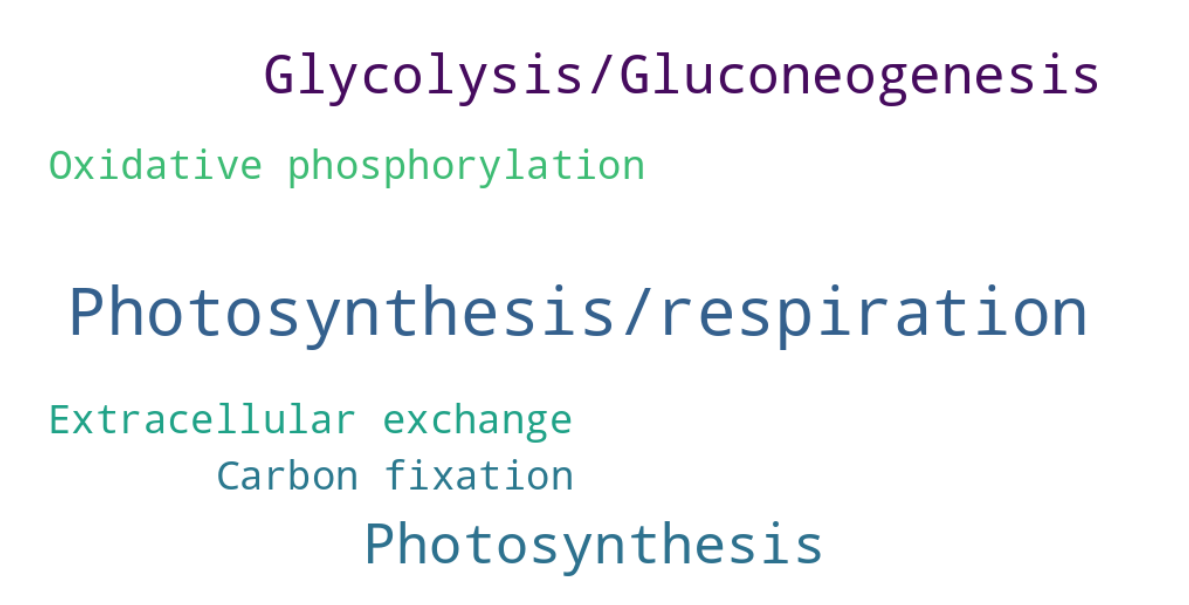

 Wordcloud saved as:  wordcloud_top10_reactions.png
 Most active subsystems (Top 20):
 {'Photosynthesis/respiration': 3, 'Photosynthesis': 2, 'Glycolysis/Gluconeogenesis': 2, 'Extracellular exchange': 1, 'Oxidative phosphorylation': 1, 'Carbon fixation': 1}


In [ ]:
import json
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================================
# STORAGE BUFFERS — must exist before the loop
# ==========================================================
results = []                 # your original collector
ALL_SUBSYSTEMS = []          # ↓ will feed the wordcloud
reaction_agg = {}            # frequency counter for all reactions seen in top10

try:
    top10 = fluxes.abs().sort_values(ascending=False).head(10)

    top10_dict = {}
    top10_subsystems = []         # NEW
    for rxn_id in top10.index:
        top10_dict[rxn_id] = float(fluxes.get(rxn_id, np.nan))

        # extract subsystem from model
        if rxn_id in m.reactions:
            subsystem = m.reactions.get_by_id(rxn_id).subsystem
        else:
            subsystem = None

        if subsystem is None or subsystem == "":
            subsystem = ""

        top10_subsystems.append(subsystem)

        # 📌 count reaction appearance for cloud
        reaction_agg[subsystem] = reaction_agg.get(subsystem, 0) + 1

except Exception:
    top10_dict = {}
    top10_subsystems = []

# store back into results (so each row keeps subsystem vector)
results.append({
    "Row": idx,
    "Top10_fluxes": json.dumps(top10_dict),
    "Top10_subsystems": json.dumps(top10_subsystems)
})


# ==========================================================
# AFTER THE LOOP — Wordcloud build section
# ==========================================================

# flatten all subsystems from results
for r in results:
    if "Top10_subsystems" in r:
        subs = json.loads(r["Top10_subsystems"])
        ALL_SUBSYSTEMS.extend(subs)

# -------------------------
# Convert subsystem frequency into dict
# -------------------------
subsystem_freq = {}
for s in ALL_SUBSYSTEMS:
    subsystem_freq[s] = subsystem_freq.get(s, 0) + 1

# keep top 20 most frequent subsystems
subsystem_freq = dict(sorted(subsystem_freq.items(), key=lambda x: x[1], reverse=True)[:20])

# -------------------------
# Generate WordCloud
# -------------------------
wc = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="viridis"
).generate_from_frequencies(subsystem_freq)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.savefig("wordcloud_top10_reactions.png", dpi=300, bbox_inches='tight')
plt.show()

print(" Wordcloud saved as:  wordcloud_top10_reactions.png")
print(" Most active subsystems (Top 20):\n", subsystem_freq)


# FBA with Buitron's data (PHBVS)

In [ ]:
"""
Full corrected script: converts experimental values → fluxes and runs FBA per row.
Features / changes:
 - Uses per-row Time (d) -> TIME_H_ROW
 - Uses INITIAL_BIOMASS as the mean of the provided inoculum list
 - Uses effective biomass X_eff = (INITIAL_BIOMASS + biomass_final)/2 for normalization
 - Supports substrates: acetate, hexanoate, fumarate, lactate, propionate, butyrate, succinate
 - Converts g COD/L (fed) -> mg COD/L -> substrate mg/L -> mmol/L -> mmol·gDW⁻¹·h⁻¹
 - Converts PHB mg/L -> mmol/L -> mmol·gDW⁻¹·h⁻¹ using X_eff and TIME_H_ROW
 - Keeps your medium / photon scaling / reaction checks / CSV outputs
 - Assumes `model_acetate1` (COBRA model) is already loaded in the session
"""

# -------------------------
# USER: input dataset path
# -------------------------
CSV_PATH = "Buitron2025_dataset.csv"

# -------------------------
# CONSTANTS (mg / mmol)
# -------------------------
PHB_MW        = 86.0     # mg/mmol (3HB monomer)
ACETATE_MW    = 59.04
HEXANOATE_MW  = 116.16
FUMARATE_MW   = 116.07
LACTATE_MW    = 90.08
PROPIONATE_MW = 74.08
BUTYRATE_MW   = 88.11
SUCCINATE_MW  = 118.09

# COD → acetate mass equivalence (mg COD per mg acetate)
COD_TO_ACETATE_RATIO = 1.066

# If Time(d) missing fallback (hours)
FALLBACK_TIME_H = 72.0

# Initial inoculum values provided (mg DW/L)
INOCULUM_VALUES_mgL = [1367, 1383, 1430, 1350, 1478, 1283]
INITIAL_BIOMASS = float(np.mean(INOCULUM_VALUES_mgL)) / 1000.0  # gDW/L

# -------------------------
# Load dataset and slice as in original
# -------------------------
df = pd.read_csv(CSV_PATH)

# Select rows 1 to 34 (the original used iloc[1:35])
df = df.iloc[1:35].reset_index(drop=True)

# Drop rows 17 and 18 (indices 15 and 16 after reset)
df = df.drop(index=[15, 16]).reset_index(drop=True)

print("Loaded dataset shape:", df.shape)
print(f"Using INITIAL_BIOMASS (mean inoculum) = {INITIAL_BIOMASS:.6f} gDW/L")

# -------------------------
# Medium conservative upperbounds (unchanged)
# -------------------------
nh4_from_acetate = 0.06590
nh4_from_nh4cl   = 0.07598
total_nh4_uptake = nh4_from_acetate + nh4_from_nh4cl

medium_montiel_buitron_2022_conservative_upperbound = {
    "EX_ac_e"   : 0.2477,
    "EX_nh4_e"  : total_nh4_uptake,
    "EX_pi_e"   : 0.03733,
    "EX_mg2_e"  : 0.01604,
    "EX_na1_e"  : 0.06955,
    "EX_ca2_e"  : 0.003455,
    "EX_fe3_e"  : 0.0004147,
    "EX_zn2_e"  : 0.000002337,
    "EX_mn2_e"  : 0.000000620,
    "EX_bo3_e"  : 0.00001972,
    "EX_cu2_e"  : 0.000000234,
    "EX_ni2_e"  : 0.000000345,
    "EX_mobd_e" : 0.000000559,
    "EX_co2_e"  : 0,
    "EX_o2_e"   : 0,
    # photons (kept)
    "EX_photon410_e": 100,
    "EX_photon430_e": 100,
    "EX_photon450_e": 100,
    "EX_photon470_e": 100,
    "EX_photon490_e": 100,
    "EX_photon510_e": 100,
    "EX_photon530_e": 100,
    "EX_photon550_e": 100,
    "EX_photon570_e": 100,
    "EX_photon590_e": 100,
    "EX_photon610_e": 100,
    "EX_photon630_e": 100,
    "EX_photon650_e": 100,
    "EX_photon670_e": 100,
    "EX_photon690_e": 100
}

# -------------------------
# Safe photon scaling (unchanged)
# -------------------------
def safe_scale_photons(model, illum_value, ref=1000.0):

    def photons_off():
        for rxn in model.reactions:
            if rxn.id.startswith("EX_photon"):
                model.reactions.get_by_id(rxn.id).lower_bound = 0

    # NaN or empty
    if pd.isna(illum_value):
        photons_off()
        return

    illum_str = str(illum_value).lower()

    if illum_str in ["continuous", "light", "constant", "on"]:
        for rxn_id, ub in medium_montiel_buitron_2022_conservative_upperbound.items():
            if rxn_id.startswith("EX_photon") and rxn_id in model.reactions:
                model.reactions.get_by_id(rxn_id).lower_bound = -ub
        return

    extracted = "".join(ch for ch in illum_str if ch.isdigit() or ch == ".")

    if extracted == "":
        photons_off()
        return

    try:
        num = float(extracted)
    except:
        photons_off()
        return

    if num == 0:
        photons_off()
        return

    scale = num / ref

    for rxn_id, ub in medium_montiel_buitron_2022_conservative_upperbound.items():
        if rxn_id.startswith("EX_photon") and rxn_id in model.reactions:
            model.reactions.get_by_id(rxn_id).lower_bound = -scale * ub

# -------------------------
# Helper to safe-get flux from solution
# -------------------------
def get_flux(sol, rxn_id):
    try:
        return float(sol.fluxes.get(rxn_id, np.nan))
    except Exception:
        return np.nan

# -------------------------
# Output directories
# -------------------------
os.makedirs("medium_rows", exist_ok=True)
os.makedirs("fluxes_rows", exist_ok=True)

# -------------------------
# Pre-check reaction ids in GEM
# -------------------------
r_ac_exists     = "EX_ac_e"        in model_acetate1.reactions
r_hxa_exists    = "EX_hxa_e"       in model_acetate1.reactions
r_fum_exists    = "EX_fum_e"       in model_acetate1.reactions
r_lac_exists    = "EX_lac__L_e"    in model_acetate1.reactions
r_ppa_exists    = "EX_ppa_e"       in model_acetate1.reactions
r_but_exists    = "EX_but_e"       in model_acetate1.reactions
r_succ_exists   = "EX_succ_e"      in model_acetate1.reactions
r_phb_exists    = "PHBS_syn"       in model_acetate1.reactions
r_phbv_exists   = "PHBVS_syn"      in model_acetate1.reactions
r_biomass_exists= "BIOMASS__1"     in model_acetate1.reactions

print(
    f"Model reaction presence: "
    f"EX_ac_e={r_ac_exists}, EX_hxa_e={r_hxa_exists}, EX_fum_e={r_fum_exists}, "
    f"EX_lac__L_e={r_lac_exists}, EX_ppa_e={r_ppa_exists}, EX_but_e={r_but_exists}, EX_succ_e={r_succ_exists}, PHBVS_syn={r_phbv_exists}, PHBVS_syn={r_phbv_exists}"
    f"PHBS_syn={r_phb_exists}, BIOMASS__1={r_biomass_exists}"
)

# -------------------------
# MAIN LOOP
# -------------------------
results = []

for idx, row in df.iterrows():

    row_id = idx + 1
    print(f"\n=== Row {row_id} / {len(df)} ===")

    # copy model for this row
    m = model_acetate1.copy()

    # reset exchange lower bounds to 0 then apply conservative upperbounds
    for ex in m.exchanges:
        ex.lower_bound = 0.0

    for rxn_id, ub in medium_montiel_buitron_2022_conservative_upperbound.items():
        if rxn_id in m.reactions:
            m.reactions.get_by_id(rxn_id).lower_bound = -ub

    # -------------------------
    # Final biomass (from dataset)
    # -------------------------
    biomass_mgL = row.get("Biomass (mg dw/L)", np.nan)
    if pd.isna(biomass_mgL) or biomass_mgL == 0:
        print(f"  WARNING: Biomass missing or zero in row {row_id}; setting biomass_final_gL = NaN")
        biomass_final_gL = np.nan
    else:
        biomass_final_gL = biomass_mgL / 1000.0  # mg -> gDW/L

    # -------------------------
    # Row-specific time handling (Time (d) -> hours)
    # -------------------------
    time_days = row.get("Time (d)", np.nan)
    if pd.isna(time_days) or time_days <= 0:
        print(f"  WARNING: Missing or invalid Time (d) in row {row_id}; using fallback {FALLBACK_TIME_H} h")
        t_hours = FALLBACK_TIME_H
    else:
        t_hours = float(time_days) * 24.0

    # -------------------------
    # Effective biomass (X_eff = (initial_inoculum + final)/2)
    # -------------------------
    if pd.isna(biomass_final_gL):
        X_eff = np.nan
    else:
        X_eff = (INITIAL_BIOMASS + biomass_final_gL) / 2.0

    print(f"  Time (h) = {t_hours:.2f}, biomass_final_gL = {biomass_final_gL}, X_eff = {X_eff}")

    # -------------------------
    # PHB experimental conversion mg/L -> q_phb (mmol·gDW⁻¹·h⁻¹)
    # -------------------------
    phb_mgL = row.get("PHB (mg/L)", np.nan)
    if pd.isna(phb_mgL) or pd.isna(X_eff) or X_eff == 0:
        q_phb = np.nan
    else:
        phb_mmolL = phb_mgL / PHB_MW
        q_phb = phb_mmolL / (X_eff * t_hours)

    # -------------------------
    # COD-fed -> substrate uptake flux (q_sub)
    # -------------------------
    COD_gL_fed = row.get("g substrate COD/L", np.nan)   # g COD / L fed
    substrate_type = str(row.get("Type of substrate", "")).strip().lower()

    q_sub = np.nan
    sub_rxn_id = None

    if not pd.isna(COD_gL_fed) and COD_gL_fed > 0 and not pd.isna(X_eff) and X_eff > 0:
        # convert g COD/L -> mg COD/L
        cod_mgL = COD_gL_fed * 1000.0

        # for acetate we convert COD->acetate mass using COD_TO_ACETATE_RATIO
        if substrate_type in ["acetate", "ac", "acetic acid"]:
            substrate_mgL = cod_mgL / COD_TO_ACETATE_RATIO
            substrate_mmolL = substrate_mgL / ACETATE_MW
            sub_rxn_id = "EX_ac_e"

        elif substrate_type in ["hexanoate", "hexanoic acid", "hxa", "hex"]:
            substrate_mgL = cod_mgL
            substrate_mmolL = substrate_mgL / HEXANOATE_MW
            sub_rxn_id = "EX_hxa_e"

        elif substrate_type in ["fumarate", "fum"]:
            substrate_mgL = cod_mgL
            substrate_mmolL = substrate_mgL / FUMARATE_MW
            sub_rxn_id = "EX_fum_e"

        elif substrate_type in ["lactate", "lac", "lactic acid"]:
            substrate_mgL = cod_mgL
            substrate_mmolL = substrate_mgL / LACTATE_MW
            sub_rxn_id = "EX_lac__L_e"

        elif substrate_type in ["propionate", "ppa", "propionic acid", "prop"]:
            substrate_mgL = cod_mgL
            substrate_mmolL = substrate_mgL / PROPIONATE_MW
            sub_rxn_id = "EX_ppa_e"

        elif substrate_type in ["butyrate", "but", "butyric acid"]:
            substrate_mgL = cod_mgL
            substrate_mmolL = substrate_mgL / BUTYRATE_MW
            sub_rxn_id = "EX_but_e"

        elif substrate_type in ["succinate", "succ", "succinic acid"]:
            substrate_mgL = cod_mgL
            substrate_mmolL = substrate_mgL / SUCCINATE_MW
            sub_rxn_id = "EX_succ_e"

        else:
            # default conservative: treat as acetate COD
            substrate_mgL = cod_mgL / COD_TO_ACETATE_RATIO
            substrate_mmolL = substrate_mgL / ACETATE_MW
            sub_rxn_id = "EX_ac_e"
            print(f"  NOTE row {row_id}: substrate_type '{substrate_type}' not recognized -> assuming acetate conversion")

        # compute q_sub (mmol·gDW⁻¹·h⁻¹)
        try:
            q_sub = substrate_mmolL / (X_eff * t_hours)
        except Exception as e:
            print(f"  ERROR computing q_sub row {row_id}: {e}")
            q_sub = np.nan

    else:
        print(f"  WARNING row {row_id}: Missing COD_fed or X_eff -> q_sub set to NaN")

    # -------------------------
    # Apply substrate flux bounds if reaction exists
    # -------------------------
    if sub_rxn_id and sub_rxn_id in m.reactions and not pd.isna(q_sub):
        # set both bounds to -q_sub to force uptake (negative uptake in COBRA convention)
        m.reactions.get_by_id(sub_rxn_id).lower_bound = -q_sub
        m.reactions.get_by_id(sub_rxn_id).upper_bound = -q_sub
    else:
        if sub_rxn_id and sub_rxn_id not in m.reactions:
            print(f"  Reaction {sub_rxn_id} not present in model; skipping substrate constraint for row {row_id}")

    # -------------------------
    # Illumination -> photon scaling
    # -------------------------
    illum = row.get("Illumination", np.nan)
    safe_scale_photons(m, illum)

    # PHBV physiological cap and objective
    # -------------------------
    phbv_rxn_id = 'PHBVS_syn'  # PHBV polymerization reaction
    mu_max = 0.08              # max specific growth rate (1/h)
    f_HB = 0.8                 # fraction HB
    f_HV = 0.2                 # fraction HV
    MW_hb = 86.09              # mg/mmol
    MW_hv = 102.13             # mg/mmol

    # Theoretical maximum fluxes in mmol/gDW/h
    v_HB_max = mu_max * f_HB * 1000.0 / MW_hb
    v_HV_max = mu_max * f_HV * 1000.0 / MW_hv
    v_PHBV_max = v_HB_max + v_HV_max

    print(f"v_HB_max = {v_HB_max:.6f} mmol/gDW/h")
    print(f"v_HV_max = {v_HV_max:.6f} mmol/gDW/h")
    print(f"v_PHBV_max = {v_PHBV_max:.6f} mmol/gDW/h")

    # Apply flux bounds and set PHBV as objective
    if phbv_rxn_id in m.reactions:
        phbv_rxn = m.reactions.get_by_id(phbv_rxn_id)
        phbv_rxn.lower_bound = 0.0
        phbv_rxn.upper_bound = v_PHBV_max
        m.objective = phbv_rxn  # now PHBV production is optimized
    else:
        print(f"  WARNING: {phbv_rxn_id} not found in model for row {row_id}")

    # -------------------------
    # Minimal biomass requirement (if present)
    # Enabling biomass bounds turn predictions infeasible (probably because biomass and PHB produciton are competing objectives)
    # -------------------------
    #if r_biomass_exists and "BIOMASS__1" in m.reactions:
    #    biomass_rxn = m.reactions.get_by_id("BIOMASS__1")
    #    biomass_rxn.lower_bound = # 0.001626
    #    biomass_rxn.upper_bound = 10

    # optional model fixes
    #if "EX_h2_e" in m.reactions:
    #    m.reactions.get_by_id("EX_h2_e").lower_bound = 0
    #    m.reactions.get_by_id("EX_h2_e").upper_bound = 1000.0

    #if "EX_no3_e" in m.reactions:
    #    no3 = m.reactions.get_by_id("EX_no3_e")
    #    no3.lower_bound = -1000.0
    #    no3.upper_bound = 0

    #if "ATPM" in m.reactions:
    #   m.reactions.get_by_id("ATPM").lower_bound = 10

    m.summary()
    # -------------------------
    # Run FBA
    # -------------------------
    sol = m.optimize()
    if sol.status != "optimal":
        print(f"  Row {row_id}: no optimal solution (status={sol.status}); saving NaNs")
        fluxes = sol.fluxes if hasattr(sol, "fluxes") else pd.Series()
    else:
        fluxes = sol.fluxes

    # -------------------------
    # Save medium CSV for this row
    # -------------------------
    try:
        medium_df = pd.DataFrame({
            "reaction": [rxn.id for rxn in m.exchanges],
            "lb":       [rxn.lower_bound for rxn in m.exchanges],
            "ub":       [rxn.upper_bound for rxn in m.exchanges],
            "flux":     [float(fluxes.get(rxn.id, np.nan)) for rxn in m.exchanges]
        })
        medium_df.to_csv(f"medium_rows/medium_row_{row_id}.csv", index=False)
    except Exception as e:
        print(f"  Error saving medium_row_{row_id}.csv: {e}")

    # -------------------------
    # Save full flux vector for this row
    # -------------------------
    try:
        fluxes_df = pd.DataFrame({
            "reaction": fluxes.index.astype(str),
            "flux": fluxes.values
        })
        fluxes_df.to_csv(f"fluxes_rows/fluxes_row_{row_id}.csv", index=False)
    except Exception as e:
        print(f"  Error saving fluxes_row_{row_id}.csv: {e}")

    # -------------------------
    # Collect outputs for summary table
    # -------------------------
    biomass_flux = get_flux(sol, "BIOMASS__1") if r_biomass_exists else np.nan
    phb_flux_model = get_flux(sol, "PHBS_syn") if r_phb_exists else np.nan
    sub_flux_model = get_flux(sol, sub_rxn_id) if sub_rxn_id and sub_rxn_id in m.reactions else np.nan

    # top 10 absolute fluxes
    try:
        top10 = fluxes.abs().sort_values(ascending=False).head(10)
        top10_dict = {rxn: float(fluxes.get(rxn, np.nan)) for rxn in top10.index}
    except Exception:
        top10_dict = {}

    results.append({
        "Row": row_id,
        # original experiment columns (kept to merge later)
        "Biomass_mgL": biomass_mgL,
        "COD_gL_fed": COD_gL_fed,
        "Substrate_type": substrate_type,
        "Time_h": t_hours,
        "PHB_mgL": phb_mgL,
        # converted GEM values
        "biomass_initial_gL": INITIAL_BIOMASS,
        "biomass_final_gL": biomass_final_gL,
        "biomass_eff_gL": X_eff,
        "PHB_exp_flux": q_phb,
        "Substrate_exp_flux": q_sub,
        "sub_rxn_id": sub_rxn_id,
        # model outputs
        "PHB_model_flux": phb_flux_model,
        "PHV_model_flux": sol.fluxes.get("PHVS_syn", np.nan) if sol.status == "optimal" else np.nan,
        "3HV_model_flux": sol.fluxes.get("3hvcoa_syn", np.nan) if sol.status == "optimal" else np.nan,
        "PHBV_model_flux": sol.fluxes.get("PHBVS_syn", np.nan) if sol.status == "optimal" else np.nan,
        "Biomass_model_flux": biomass_flux,
        "Substrate_model_flux": sub_flux_model,
        "propionylcoa_model_flux": sol.fluxes.get("propionylcoa_syn", np.nan) if sol.status == "optimal" else np.nan,
        #"Top10_fluxes": json.dumps(top10_dict)
    })

# -------------------------
# SAVE SUMMARY CSV and MERGE WITH ORIGINAL ROWS
# -------------------------
results_df = pd.DataFrame(results)
results_df.to_csv("FBA_results_summary_versionA_PHBV.csv", index=False)

df_merged = pd.concat([df.reset_index(drop=True), results_df.reset_index(drop=True)], axis=1)
df_merged.to_csv("Buitron_with_FBA_fluxes_PHBV.csv", index=False)

print("\nSaved: Buitron_with_FBA_fluxes_PHBV.csv and FBA_results_summary_versionA_PHBV.csv")


Loaded dataset shape: (32, 23)
Using INITIAL_BIOMASS (mean inoculum) = 1.381833 gDW/L
Model reaction presence: EX_ac_e=True, EX_hxa_e=True, EX_fum_e=True, EX_lac__L_e=True, EX_ppa_e=True, EX_but_e=True, EX_succ_e=True, PHBVS_syn=True, PHBVS_syn=TruePHBS_syn=True, BIOMASS__1=True

=== Row 1 / 32 ===
  Time (h) = 120.00, biomass_final_gL = 2.467, X_eff = 1.9244166666666667
v_HB_max = 0.743408 mmol/gDW/h
v_HV_max = 0.156663 mmol/gDW/h
v_PHBV_max = 0.900071 mmol/gDW/h


Infeasible: None (infeasible).

In [ ]:
# 1. Check PHB / PHV max fluxes
for rxn_id in ["propionylcoa_syn", "3hvcoa_syn", "PHBS_syn", "PHVS_syn", "PHBVS_syn"]:
    rxn = model_acetate1.reactions.get_by_id(rxn_id)
    model_acetate1.objective = rxn
    sol = model_acetate1.optimize()
    print(f"{rxn_id} flux: {sol.fluxes[rxn_id]}, status: {sol.status}")


propionylcoa_syn flux: 0.0, status: optimal
3hvcoa_syn flux: 0.0, status: optimal
PHBS_syn flux: 0.12375000000000129, status: optimal
PHVS_syn flux: 0.0, status: optimal
PHBVS_syn flux: 0.0, status: optimal


In [ ]:
for rxn_id in ["EX_ac_e", "EX_ppa_e"]:
    if rxn_id in model_acetate1.reactions:
        model_acetate1.reactions.get_by_id(rxn_id).lower_bound = -1000
        model_acetate1.reactions.get_by_id(rxn_id).upper_bound = 1000
phbv_rxn = model_acetate1.reactions.get_by_id("PHBVS_syn")
phbv_rxn.add_metabolites({
    model_acetate1.metabolites.get_by_id("phbg[c]"): -1.0,
    model_acetate1.metabolites.get_by_id("phvg[c]"): -1.0,
})
model_acetate1.objective = model_acetate1.reactions.get_by_id("PHBVS_syn")
sol = model_acetate1.optimize()
print("PHBV flux (test):", sol.fluxes.get("PHBVS_syn", 0.0))


PHBV flux (test): 0.0


## *Checkpoint: GEM linearity

In [ ]:
df = pd.read_csv('Buitron_with_FBA_fluxes.csv')
df.columns

Index(['Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)',
       '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)',
       'Experiment.1', 'Time (d)', 'g substrate COD/L', 'Type of substrate',
       'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium',
       ' g NaHCO3/L', 'Illumination', 'Levulinic acid',
       'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange',
       'Row', 'Biomass_mgL', 'COD_gL_fed', 'Substrate_type', 'Time_h',
       'PHB_mgL', 'biomass_initial_gL', 'biomass_final_gL', 'biomass_eff_gL',
       'PHB_exp_flux', 'Substrate_exp_flux', 'sub_rxn_id', 'PHB_model_flux',
       'PHV_model_flux', '3HV_model_flux', 'PHBV_model_flux',
       'Biomass_model_flux', 'Substrate_model_flux'],
      dtype='object')

Number of data points: 32
Unique substrates: ['acetate']


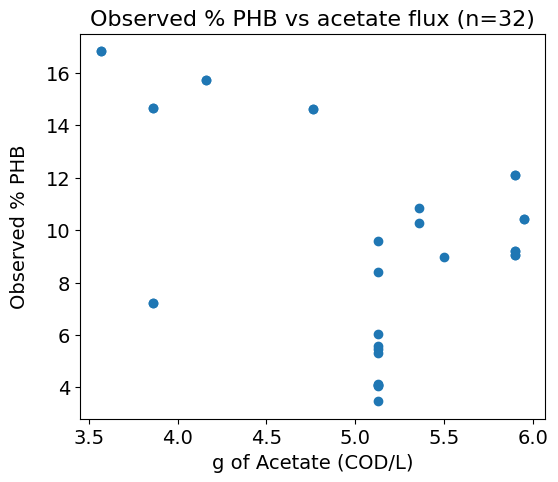

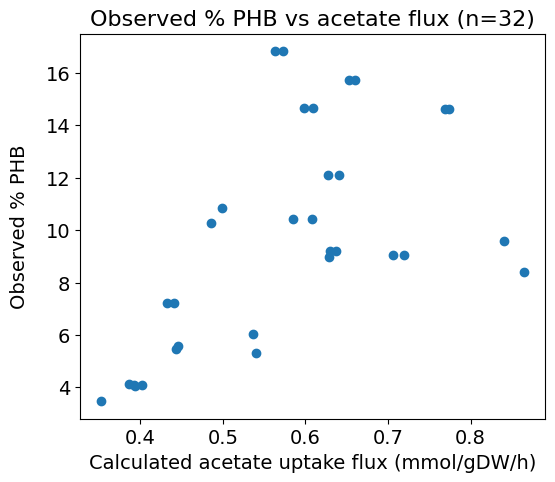

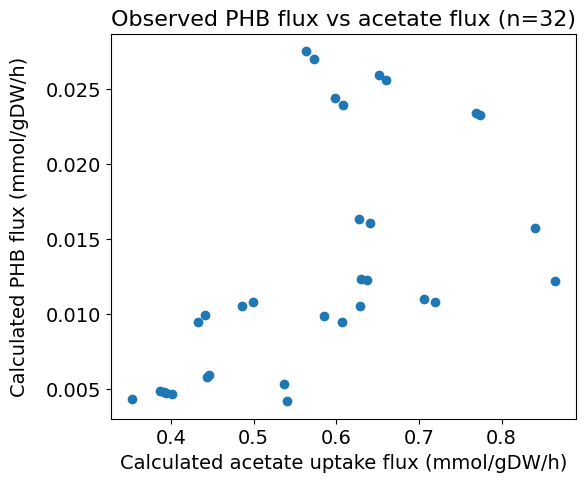

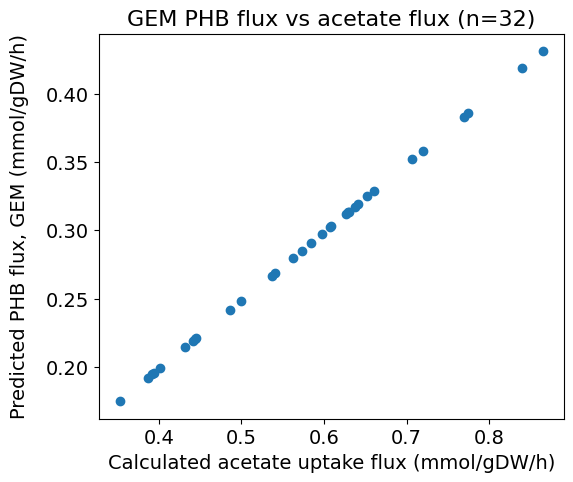

In [ ]:
# ---------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------
df = pd.read_csv('Buitron_with_FBA_fluxes.csv')

# Number of points
n = len(df)
print("Number of data points:", n)

# ---------------------------------------------------------
# UNIQUE SUBSTRATE TYPES
# ---------------------------------------------------------
substrates = df["Substrate_type"].unique()
print("Unique substrates:", substrates)

# Use the FIRST substrate (assuming single-substrate experiments)
substrate_name = substrates[0]

# ---------------------------------------------------------
# PLOTS
# ---------------------------------------------------------

# --- Scatterplot 1 ---
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(df['g substrate COD/L'], df['% PHB'])
ax.set_xlabel('g of Acetate (COD/L)', fontsize=14)
ax.set_ylabel('Observed % PHB', fontsize=14)
ax.set_title(f'Observed % PHB vs {substrate_name} flux (n={n})', fontsize=16)
ax.tick_params(axis='both', labelsize=14)
ax.yaxis.labelpad = 12
fig.savefig("scatter_exp_COD_PHB_percent.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Scatterplot 2 ---
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(df['Substrate_exp_flux'], df['% PHB'])
ax.set_xlabel('Calculated acetate uptake flux (mmol/gDW/h)', fontsize=14)
ax.set_ylabel('Observed % PHB', fontsize=14)
ax.set_title(f'Observed % PHB vs {substrate_name} flux (n={n})', fontsize=16)
ax.tick_params(axis='both', labelsize=14)
ax.yaxis.labelpad = 12
fig.savefig("scatter_obs_PHB_percent.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Scatterplot 3 ---
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(df['Substrate_exp_flux'], df['PHB_exp_flux'])
ax.set_xlabel('Calculated acetate uptake flux (mmol/gDW/h)', fontsize=14)
ax.set_ylabel('Calculated PHB flux (mmol/gDW/h)', fontsize=14)
ax.set_title(f'Observed PHB flux vs {substrate_name} flux (n={n})', fontsize=16)
ax.tick_params(axis='both', labelsize=14)
ax.yaxis.labelpad = 12
fig.savefig("scatter_obs_q_PHB.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Scatterplot 4 ---
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(df['Substrate_exp_flux'], df['PHB_model_flux'])
ax.set_xlabel('Calculated acetate uptake flux (mmol/gDW/h)', fontsize=14)
ax.set_ylabel('Predicted PHB flux, GEM (mmol/gDW/h)', fontsize=14)
ax.set_title(f'GEM PHB flux vs {substrate_name} flux (n={n})', fontsize=16)
ax.tick_params(axis='both', labelsize=14)
ax.yaxis.labelpad = 12
fig.savefig("scatter_model_q_PHB.png", dpi=300, bbox_inches='tight')
plt.show()



## Opt: PHB yield on acetate

To calculate the PHB yield per molecule of acetate using Montiel-Corona 2022 medium.

In [ ]:
# === Y_PHB/Ac: PHB yield on acetate (g PHB per g acetate) ===
# Constants (masses)
MW_ac_mg_per_mmol = 59.04    # mg per mmol acetate
MW_phb_mg_per_mmol = 86.0    # mg per mmol PHB monomer
MW_ac_g_per_mmol = MW_ac_mg_per_mmol / 1000.0
MW_phb_g_per_mmol = MW_phb_mg_per_mmol / 1000.0

# ---------- Experimental yield (total mg/L -> g/g) ----------
phb_gL = phb_mgL / 1000.0                # g PHB per L
ac_consumed_gL = (acetate_fed - acetate_removed_mgL) / 1000.0  # g Ac per L

if ac_consumed_gL > 0:
    Y_exp_g_per_g = phb_gL / ac_consumed_gL
    print(f"\nExperimental Y_PHB/Ac = {Y_exp_g_per_g:.4f} g PHB / g Ac  ({Y_exp_g_per_g*100:.2f} %)")
else:
    print("\nExperimental Y_PHB/Ac: cannot compute (no acetate consumed).")

# ---------- Helper to compute yield from model solution fluxes ----------
def compute_Y_from_fluxes(sol_fluxes, biomass_gL):
    """
    sol_fluxes: dict-like of fluxes (mmol·gDW^-1·h^-1)
    biomass_gL: gDW per L (for conversion to per-L basis)
    returns (Y_g_per_g, details_dict) or (np.nan, details) if cannot compute
    """
    v_phb = float(sol_fluxes.get(r_phb.id, 0.0))
    v_ac  = float(sol_fluxes.get(r_ac.id, 0.0))  # uptake is negative if importing

    ac_mag = abs(v_ac)  # mmol·gDW^-1·h^-1
    if ac_mag == 0:
        return np.nan, {"v_phb": v_phb, "v_ac": v_ac}

    # convert to mmol/L/h by multiplying by biomass (gDW/L)
    mmol_ac_L_h = ac_mag * biomass_gL
    mmol_phb_L_h = v_phb * biomass_gL

    # grams per L per h
    g_ac_L_h = mmol_ac_L_h * MW_ac_g_per_mmol
    g_phb_L_h = mmol_phb_L_h * MW_phb_g_per_mmol

    if g_ac_L_h == 0:
        return np.nan, {"v_phb": v_phb, "v_ac": v_ac, "g_ac_L_h": g_ac_L_h}

    Y = g_phb_L_h / g_ac_L_h
    details = {
        "v_phb_mmol_gDW_h": v_phb,
        "v_ac_mmol_gDW_h": v_ac,
        "mmol_phb_L_h": mmol_phb_L_h,
        "mmol_ac_L_h": mmol_ac_L_h,
        "g_phb_L_h": g_phb_L_h,
        "g_ac_L_h": g_ac_L_h
    }
    return Y, details

# ---------- Compute for Experiment 1 ----------
print("\n--- EXPERIMENT 1 (model) ---")
try:
    if sol_exp1.status == "optimal":
        Y1, det1 = compute_Y_from_fluxes(sol_exp1.fluxes, biomass_gL)
        if np.isnan(Y1):
            print("Experiment 1: Y_PHB/Ac cannot be computed (acetate uptake = 0).")
            print("  fluxes:", det1)
        else:
            print(f"Experiment 1 model Y_PHB/Ac = {Y1:.4f} g/g  ({Y1*100:.2f} %)")
            print("  details:", det1)
    else:
        print("Experiment 1 solution not optimal; skipping Y calculation.")
except NameError:
    print("Experiment 1 result (sol_exp1) not found; skipping.")

# ---------- Compute for Experiment 2 ----------
print("\n--- EXPERIMENT 2 (model, fixed acetate) ---")
try:
    if sol_exp2.status == "optimal":
        Y2, det2 = compute_Y_from_fluxes(sol_exp2.fluxes, biomass_gL)
        if np.isnan(Y2):
            print("Experiment 2: Y_PHB/Ac cannot be computed (acetate uptake = 0).")
            print("  fluxes:", det2)
        else:
            print(f"Experiment 2 model Y_PHB/Ac = {Y2:.4f} g/g  ({Y2*100:.2f} %)")
            print("  details:", det2)
    else:
        print("Experiment 2 solution not optimal; skipping Y calculation.")
except NameError:
    print("Experiment 2 result (sol_exp2) not found; skipping.")

# ---------- Compute for Experiment 3 ----------
print("\n--- EXPERIMENT 3 (model, max PHB) ---")
try:
    if sol_exp3.status == "optimal":
        Y3, det3 = compute_Y_from_fluxes(sol_exp3.fluxes, biomass_gL)
        if np.isnan(Y3):
            print("Experiment 3: Y_PHB/Ac cannot be computed (acetate uptake = 0).")
            print("  fluxes:", det3)
        else:
            print(f"Experiment 3 model Y_PHB/Ac = {Y3:.4f} g/g  ({Y3*100:.2f} %)")
            print("  details:", det3)
    else:
        print("Experiment 3 solution not optimal; skipping Y calculation.")
except NameError:
    print("Experiment 3 result (sol_exp3) not found; skipping.")



Experimental Y_PHB/Ac = 0.3133 g PHB / g Ac  (31.33 %)

--- EXPERIMENT 1 (model) ---
Experiment 1 model Y_PHB/Ac = 0.0688 g/g  (6.88 %)
  details: {'v_phb_mmol_gDW_h': 0.025872872753667567, 'v_ac_mmol_gDW_h': 0.5480542544864875, 'mmol_phb_L_h': 0.035368217054263566, 'mmol_ac_L_h': 0.7491901658830283, 'g_phb_L_h': 0.0030416666666666665, 'g_ac_L_h': 0.044232187393733996}

--- EXPERIMENT 2 (model, fixed acetate) ---
Experiment 2 model Y_PHB/Ac = 4.3599 g/g  (435.99 %)
  details: {'v_phb_mmol_gDW_h': 0.36004504030678314, 'v_ac_mmol_gDW_h': -0.12029008061355913, 'mmol_phb_L_h': 0.4921815700993725, 'mmol_ac_L_h': 0.16443654019873533, 'g_phb_L_h': 0.04232761502854603, 'g_ac_L_h': 0.009708333333333334}

--- EXPERIMENT 3 (model, max PHB) ---
Experiment 3 model Y_PHB/Ac = 2.5441 g/g  (254.41 %)
  details: {'v_phb_mmol_gDW_h': 0.42019008061356405, 'v_ac_mmol_gDW_h': -0.24058016122711826, 'mmol_phb_L_h': 0.574399840198742, 'mmol_ac_L_h': 0.32887308039747065, 'g_phb_L_h': 0.04939838625709181, 'g_a

# Co-feeding sweep

To find the best combinations of carbon sources (in co-feeding) and their fluxes using (and modifying)Montiel-Corona 2022 medium as basis.
It gives a hint into R. palustris carbon preferences.

In [ ]:
phb_rxn = model_acetate1.reactions.get_by_id("PHBS_syn")
phb_rxn.lower_bound = 0
phb_rxn.upper_bound = 0.6  # realistic max flux based on physiology

# === Define the reactions to sweep ===
targets = ["EX_fum_e", "EX_hxa_e", "EX_ppa_e", "EX_lac__L_e", "EX_but_e", "EX_succ_e"]

# === Define sweep range ===
sweep_values = np.linspace(0, 0.2, 3)   # 0 → 0.2 mmol/gDW/h, 3 points

# Output list
results = []

# === Loop over all combinations of the 6 substrates ===
for fum, hxa, ppa, lac, but, succ in tqdm(product(sweep_values, repeat=len(targets)),
                                          total=len(sweep_values)**len(targets),
                                          desc="Running simulations"):

    # copy model for this simulation
    m = model_acetate1.copy()

    # Fix acetate uptake
    m.reactions.get_by_id("EX_ac_e").lower_bound = -0.12029
    m.reactions.get_by_id("EX_ac_e").upper_bound = 0

    # Set uptake bounds for all other substrates (negative for uptake)
    m.reactions.get_by_id("EX_fum_e").lower_bound = -fum
    m.reactions.get_by_id("EX_fum_e").upper_bound = 0

    m.reactions.get_by_id("EX_hxa_e").lower_bound = -hxa
    m.reactions.get_by_id("EX_hxa_e").upper_bound = 0

    m.reactions.get_by_id("EX_ppa_e").lower_bound = -ppa
    m.reactions.get_by_id("EX_ppa_e").upper_bound = 0

    m.reactions.get_by_id("EX_lac__L_e").lower_bound = -lac
    m.reactions.get_by_id("EX_lac__L_e").upper_bound = 0

    m.reactions.get_by_id("EX_but_e").lower_bound = -but
    m.reactions.get_by_id("EX_but_e").upper_bound = 0

    m.reactions.get_by_id("EX_succ_e").lower_bound = -succ
    m.reactions.get_by_id("EX_succ_e").upper_bound = 0

    # Set objective (PHB synthesis)
    m.objective = "PHBS_syn"

    # Optimize
    sol = m.optimize()

    # Save results
    if sol.status == "optimal":
        results.append({
            "ac": 0.12029,  # fixed acetate to the calculated uptake flux of experiment in Montiel-Corona 2022
            "fum": fum,
            "hxa": hxa,
            "ppa": ppa,
            "lac": lac,
            "but": but,
            "succ": succ,
            "PHB_flux": sol.fluxes.get("PHBS_syn", 0),
            "biomass": sol.fluxes.get("BIOMASS", np.nan)
        })
    else:
        results.append({
            "ac": 0.12029,
            "fum": fum,
            "hxa": hxa,
            "ppa": ppa,
            "lac": lac,
            "but": but,
            "succ": succ,
            "PHB_flux": np.nan,
            "biomass": np.nan
        })

# Convert to DataFrame
df_results = pd.DataFrame(results)

print(df_results.head())
df_results.to_csv("sweep_fixed_ac_fum_hxa_ppa_lac_but_succ_PHB.csv", index=False)

print("\nSaved: sweep_fixed_ac_fum_hxa_ppa_lac_but_succ_PHB.csv")


Running simulations:  14%|█▎        | 99/729 [01:42<10:53,  1.04s/it]


KeyboardInterrupt: 

# *Max PHB production with minimum amount of carbon sources (combined)

Including the cost of carbon sources.

Added total_cost column (USD/gDW/h)
Saved full results with cost to 'PHB_sweep_with_CN_total_uptake_and_cost.csv'


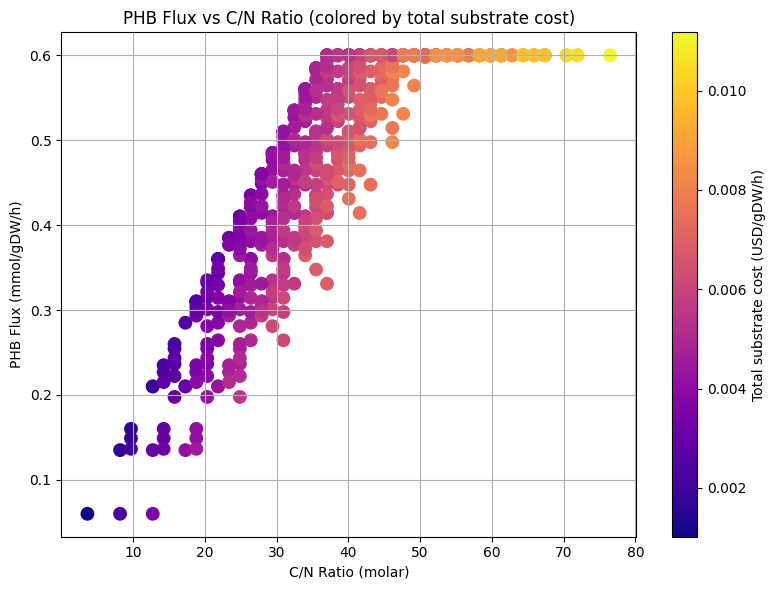


Top 5 best conditions balancing PHB flux, cost, and substrate uptake:

     PHB_flux  C/N_ratio  total_cost  total_uptake       ac  fum  hxa  ppa  \
97   0.585045  35.517147    0.004470       0.62029  0.12029  0.0  0.1  0.0   
89   0.600000  37.034598    0.004481       0.62029  0.12029  0.0  0.1  0.0   
95   0.582273  35.517147    0.004523       0.62029  0.12029  0.0  0.1  0.0   
177  0.600000  38.552049    0.004653       0.62029  0.12029  0.0  0.2  0.0   
169  0.600000  40.069499    0.004664       0.62029  0.12029  0.0  0.2  0.0   

     lac  but  succ  
97   0.1  0.2   0.1  
89   0.0  0.2   0.2  
95   0.1  0.1   0.2  
177  0.1  0.2   0.0  
169  0.0  0.2   0.1  


In [ ]:

# Assuming df_results is already loaded or computed with these columns:
# 'ac', 'fum', 'hxa', 'ppa', 'lac', 'but', 'succ', 'PHB_flux', etc.

df_results = pd.read_csv("sweep_fixed_ac_fum_hxa_ppa_lac_but_succ_PHB.csv") ##

# Carbon atoms per substrate
C_atoms = {
    "ac": 2,
    "fum": 4,
    "hxa": 6,
    "ppa": 3,
    "lac": 3,
    "but": 4,
    "succ": 4
}

# Nitrogen uptake (from ammonium, example value from your medium)
nh4_uptake = 0.06590  # mmol N/gDW/h, from medium_montiel_buitron_2022_conservative_upperbound["EX_nh4_e"]

# Calculate total carbon uptake (mmol C/gDW/h)
df_results['C_total'] = 0
for sub in C_atoms:
    if sub in df_results.columns:
        df_results['C_total'] += df_results[sub] * C_atoms[sub]

# Nitrogen total uptake (constant)
df_results['N_total'] = nh4_uptake

# Calculate molar C/N ratio
df_results['C/N_ratio'] = df_results['C_total'] / df_results['N_total']

# Calculate total substrate uptake (mmol/gDW/h)
substrates = list(C_atoms.keys())
df_results['total_uptake'] = df_results[substrates].sum(axis=1)

# Prices per mmol substrate (USD/mmol) - example approximate values
price_per_mmol = {
    "ac": 0.00847,
    "fum": 0.01034,
    "hxa": 0.00860,
    "ppa": 0.01215,
    "lac": 0.00666,
    "but": 0.00624,
    "succ": 0.00677
}

# Calculate total substrate cost (USD/gDW/h)
df_results['total_cost'] = 0
for sub in price_per_mmol:
    if sub in df_results.columns:
        df_results['total_cost'] += df_results[sub] * price_per_mmol[sub]

print("Added total_cost column (USD/gDW/h)")

# Save full dataframe with C/N, uptake, cost
df_results.to_csv("PHB_sweep_with_CN_total_uptake_and_cost.csv", index=False)
print("Saved full results with cost to 'PHB_sweep_with_CN_total_uptake_and_cost.csv'")

# Plot PHB flux vs C/N ratio colored by total substrate cost
plt.figure(figsize=(8,6))
sc = plt.scatter(df_results['C/N_ratio'], df_results['PHB_flux'],
                 c=df_results['total_cost'], cmap='plasma', s=80)
plt.title('PHB Flux vs C/N Ratio (colored by total substrate cost)')
plt.xlabel('C/N Ratio (molar)')
plt.ylabel('PHB Flux (mmol/gDW/h)')
plt.colorbar(sc, label='Total substrate cost (USD/gDW/h)')
plt.grid(True)
plt.tight_layout()
plt.savefig("PHB_flux_vs_CN_ratio_and_cost.png")
plt.show()

# Find best conditions balancing PHB flux, cost, and uptake
max_phb = df_results['PHB_flux'].max()
threshold = 0.95 * max_phb  # 95% of max PHB

high_phb = df_results[df_results['PHB_flux'] >= threshold]

# Sort by total_cost then total_uptake (lowest cost + lowest uptake first)
best_conditions = high_phb.sort_values(by=['total_cost', 'total_uptake'])

print("\nTop 5 best conditions balancing PHB flux, cost, and substrate uptake:\n")
print(best_conditions[['PHB_flux', 'C/N_ratio', 'total_cost', 'total_uptake'] + substrates].head(5))


In [ ]:
# print top 10 results

top_10 = df_results.sort_values(by=['PHB_flux', 'total_uptake', 'total_cost'], ascending=[False, True, True]).head(5)
print(top_10[['PHB_flux', 'total_uptake', 'total_cost','C/N_ratio'] + substrates])



     PHB_flux  total_uptake  total_cost  C/N_ratio       ac  fum  hxa  ppa  \
89        0.6       0.62029    0.004481  37.034598  0.12029  0.0  0.1  0.0   
177       0.6       0.62029    0.004653  38.552049  0.12029  0.0  0.2  0.0   
169       0.6       0.62029    0.004664  40.069499  0.12029  0.0  0.2  0.0   
183       0.6       0.62029    0.004695  37.034598  0.12029  0.0  0.2  0.0   
175       0.6       0.62029    0.004706  38.552049  0.12029  0.0  0.2  0.0   

     lac  but  succ  
89   0.0  0.2   0.2  
177  0.1  0.2   0.0  
169  0.0  0.2   0.1  
183  0.2  0.1   0.0  
175  0.1  0.1   0.1  


# *Pareto optimality of three objectives


1.   Minimize total cost
2.   Minimize total uptake
3.   Maximize PHA producition (flux through PHB_syn)




Index(['Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)',
       '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)',
       'Experiment.1', 'Time (d)', 'g substrate COD/L', 'Type of substrate',
       'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium',
       ' g NaHCO3/L', 'Illumination', 'Levulinic acid',
       'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange',
       'Time_h', 'PHB_mgL', 'biomass_initial_gL', 'biomass_final_gL',
       'biomass_eff_gL', 'PHB_exp_flux', 'Substrate_exp_flux', 'sub_rxn_id',
       'PHB_model_flux', 'Biomass_model_flux', 'Substrate_model_flux',
       'is_experimental', 'ac', 'fum', 'hxa', 'ppa', 'lac', 'but', 'succ',
       'C_total', 'N_total', 'C/N_ratio', 'total_uptake', 'total_cost'],
      dtype='object')
Found 34 Pareto optimal solutions.
Optimal solution with highest PHB production:
Experiment                          21
Biomass (mg dw/L)                 1417
PHB (mg

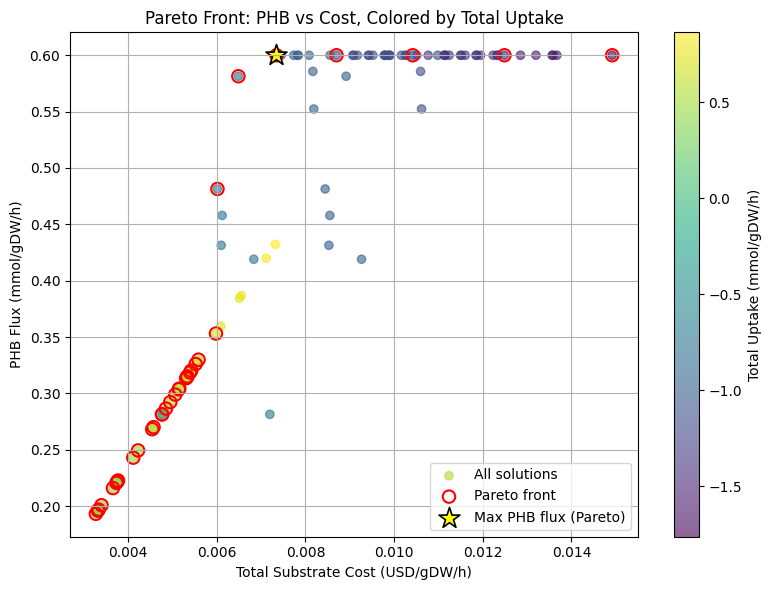

In [ ]:
df_results = pd.read_csv("Buitron2025_dataset_augmented_with_cost.csv")
print(df_results.columns)

def is_pareto_efficient(costs, maximize_cols=None):
    """
    Find the Pareto-efficient points.
    costs: 2D array with objectives (each row is a point, columns are objectives)
    maximize_cols: list of indices of objectives to maximize (others are minimized)

    Returns: boolean mask of Pareto efficient points
    """
    costs_adj = costs.copy()
    if maximize_cols:
        for col in maximize_cols:
            costs_adj[:, col] = -costs_adj[:, col]

    n_points = costs_adj.shape[0]
    is_efficient = np.ones(n_points, dtype=bool)
    for i in range(n_points):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(costs_adj[is_efficient] < costs_adj[i], axis=1)
            is_efficient[i] = True
    return is_efficient

# Prepare data: PHB_flux (maximize), total_cost (minimize), total_uptake (minimize)
objectives = df_results[['PHB_model_flux', 'total_cost', 'total_uptake']].to_numpy()
pareto_mask = is_pareto_efficient(objectives, maximize_cols=[0])

pareto_solutions = df_results[pareto_mask]

print(f"Found {pareto_solutions.shape[0]} Pareto optimal solutions.")

# Find Pareto solution with max PHB_flux
idx_max_phb_pareto = pareto_solutions['PHB_model_flux'].idxmax()
max_phb_pareto_solution = pareto_solutions.loc[idx_max_phb_pareto]


# Extract that row
optimal_solution = df_results.loc[idx_max_phb_pareto]

print("Optimal solution with highest PHB production:")
print(optimal_solution)


# Plot PHB_flux vs cost, highlighting Pareto points
plt.figure(figsize=(8,6))

# Main scatter: color by total_uptake
sc = plt.scatter(
    df_results['total_cost'],
    df_results['PHB_model_flux'],
    c=df_results['total_uptake'],
    cmap='viridis',
    alpha=0.6,
    label='All solutions'
)

# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Total Uptake (mmol/gDW/h)', rotation=90)

# Pareto points (outline-only circles so color still visible)
plt.scatter(
    pareto_solutions['total_cost'],
    pareto_solutions['PHB_model_flux'],
    facecolors='none',
    edgecolors='red',
    s=80,
    linewidths=1.5,
    label='Pareto front'
)

# Mark best Pareto PHB (green star)
plt.scatter(
    max_phb_pareto_solution['total_cost'],
    max_phb_pareto_solution['PHB_model_flux'],
    color='yellow',
    s=250,
    marker='*',
    edgecolors='black',
    linewidths=1.2,
    label='Max PHB flux (Pareto)'
)

plt.xlabel('Total Substrate Cost (USD/gDW/h)')
plt.ylabel('PHB Flux (mmol/gDW/h)')
plt.title('Pareto Front: PHB vs Cost, Colored by Total Uptake')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Opt: List reactions associated to acetyl-coa, nad, ferrodoxin

In [ ]:
# 1A: list open uptake exchanges (possible carbon donors)
open_uptakes = [(ex.id, ex.lower_bound) for ex in model_acetate1.exchanges if ex.lower_bound < 0]
print("Open uptakes (id, lb):", open_uptakes)

# 1B: top consumers of acetyl-CoA and top NAD(P)H producers/consumers
sol = model_acetate1.optimize()
# filter by strings may be coarse; adapt IDs to your model
for rxn in model_acetate1.reactions:
    if 'accoa' in str(rxn.reaction).lower() or 'acetyl-coa' in (rxn.name or '').lower():
        print(rxn.id, sol.fluxes.get(rxn.id,0.0), rxn.reaction)
# redox drivers
redox = []
for rxn in model_acetate1.reactions:
    s = str(rxn.reaction).lower()
    if 'nad' in s or 'nadp' in s or 'fd' in s or 'ferredoxin' in s:
        redox.append((rxn.id, sol.fluxes.get(rxn.id,0.0), rxn.reaction))
redox_sorted = sorted(redox, key=lambda x: abs(x[1]), reverse=True)[:30]
print("Top redox reactions:")
for r in redox_sorted:
    print(r)


### Checkpoint: save reactions

In [ ]:

# Convert to a DataFrame
medium_df_2022 = pd.DataFrame(list(model_acetate1.medium.items()), columns=["Reaction", "UptakeBound"])

# Save to Excel
medium_df_2022.to_excel("EX_reactions_model_tec_campos_2023_medium_montielcorona_2022.xlsx", index=False)

## Opt: Report flux of key reactions

Modify reactions of interest

In [ ]:
# Check key fluxes of enzymes involved in phb and biomas production by acetate uptake

# Acetoacetyl CoA reductase
# Acetyl-CoA C-acetyltransferase
# Glucose 6-phosphate dehydrogenase
# ATP maintenance requirement
# PHB synthetasa

key = ['BIOMASS__1','EX_ac_e','PHBS_syn','AACOAR_syn','ACACT1r','PDH','G6PDH2r','ATPM']
for r in key:
    if r in model_acetate1.reactions:
        print(r, "bounds", model_acetate1.reactions.get_by_id(r).bounds, "flux", sol.fluxes.get(r, None))
    else:
        print(r, "not in model")


BIOMASS__1 bounds (0.0, 2.0) flux 0.0
EX_ac_e bounds (-0.12029008061355913, 1000) flux -0.24058016122711826
PHBS_syn bounds (0.0, 999999.0) flux 0.12019008061356057
AACOAR_syn bounds (0.0, 1000.0) flux 0.12019008061356055
ACACT1r bounds (0.0, 1000.0) flux 0.00022499999999918844
PDH bounds (0.0, 1000.0) flux 0.0
G6PDH2r bounds (0.0, 1000.0) flux 0.0
ATPM bounds (0.0, 1000.0) flux 0.0


### Checkpoint: Print the top 20 reactions

In [ ]:
# Print the Top 20 reactions

#sol = model_acetate1.optimize()
print("Top 20 active fluxes (abs):")
print(sol.fluxes.abs().sort_values(ascending=False).head(20))
top_reactions = sol.fluxes.abs().sort_values(ascending=False).head(20)
print(top_reactions)

for rxn_id in top_reactions.index:
    rxn = model_acetate1.reactions.get_by_id(rxn_id)
    print(f"ID: {rxn.id}")
    print(f"Name: {rxn.name}")
    print(f"Equation: {rxn.reaction}")
    print(f"Flux: {sol.fluxes[rxn.id]:.3f}")
    print(f"Bounds: ({rxn.lower_bound}, {rxn.upper_bound})")
    print("-" * 80)

top_ids = top_reactions.index.tolist()
reaction_report = []

for rxn_id in top_ids:
    rxn = model_acetate1.reactions.get_by_id(rxn_id)
    reaction_report.append({
        "Reaction ID": rxn.id,
        "Name": rxn.name,
        "Equation": rxn.reaction,
        "Flux": sol.fluxes[rxn.id],
        "Lower Bound": rxn.lower_bound,
        "Upper Bound": rxn.upper_bound
    })

df_top = pd.DataFrame(reaction_report)
df_top.to_excel("Top20_flux_reactions.xlsx", index=False)
print(df_top)


Top 20 active fluxes (abs):
PCXHtpp      2.235613
DALAt2pp     1.995033
DALAabcpp    1.995033
NADTRHD      1.200526
ACOAD4_1     1.080281
ACACT5r_1    1.080281
ACACT5r      0.960316
ACOAD4f      0.960316
ACCOAC       0.839756
HCO3E        0.839756
MCOATA       0.839756
ACOAH        0.641214
ASPTA        0.400733
ASPK         0.400733
HSDxi        0.400733
PPC          0.400733
ASAD         0.400733
HSK          0.400733
THRS         0.400733
THRA         0.400633
Name: fluxes, dtype: float64
PCXHtpp      2.235613
DALAt2pp     1.995033
DALAabcpp    1.995033
NADTRHD      1.200526
ACOAD4_1     1.080281
ACACT5r_1    1.080281
ACACT5r      0.960316
ACOAD4f      0.960316
ACCOAC       0.839756
HCO3E        0.839756
MCOATA       0.839756
ACOAH        0.641214
ASPTA        0.400733
ASPK         0.400733
HSDxi        0.400733
PPC          0.400733
ASAD         0.400733
HSK          0.400733
THRS         0.400733
THRA         0.400633
Name: fluxes, dtype: float64
ID: PCXHtpp
Name: H+ export PcxA
E

# *Integration ML + GEM

In [ ]:
# Load experimental data from Buitron 2025

Buitron2025_dataset = pd.read_csv('Buitron2025_dataset.csv')
print(Buitron2025_dataset.head())

   Experiment  Biomass (mg dw/L)  PHB (mg/L)  % PHB  PHV (mg/L)  % PHV  \
0           1               2317       81.00   3.50        8.50   0.40   
1           2               2467       85.56   3.47       11.97   0.57   
2           3               1150       69.51   6.04        8.95   0.70   
3           4               1133       54.00   5.31        8.67   0.68   
4           5               1683       91.85   5.46        4.72   0.31   

   5-ALA (micromol/L)  Q10 (mg/g dw)  Carotenoids (mg/g dw)  Experiment.1  \
0                 NaN            NaN                    NaN           NaN   
1                 NaN            NaN                    NaN           NaN   
2                 NaN            NaN                    NaN           NaN   
3                 NaN            NaN                    NaN           NaN   
4                 NaN            NaN                    NaN           NaN   

   ...  mg N/L  C/N (molar base) mg ethanol/L  Fraction mineral medium  \
0  ...   154.7    

In [ ]:
max_score_index = Buitron2025_dataset['% PHB'].idxmax()

# Retrieve the row using .loc[]
max_score_row = Buitron2025_dataset.loc[max_score_index]

print("Row with the maximum score (first occurrence):")
print(max_score_row)

Row with the maximum score (first occurrence):
Experiment                         103
Biomass (mg dw/L)                 1354
PHB (mg/L)                      608.55
% PHB                            44.94
PHV (mg/L)                       15.48
% PHV                             1.14
5-ALA (micromol/L)               10.32
Q10 (mg/g dw)                     1.23
Carotenoids (mg/g dw)             2.18
Experiment.1                       NaN
Time (d)                            10
g substrate COD/L                 4.97
Type of substrate                 MCCA
mg N/L                           154.7
C/N (molar base)                  14.0
mg ethanol/L                      0.79
Fraction mineral medium            1.0
 g NaHCO3/L                        1.5
Illumination                continuous
Levulinic acid                      No
Fe (mg Ferric citrate/L)             5
Operation mode                   Batch
% Volume exchange                  100
Name: 102, dtype: object


In [ ]:
max_score_index = Buitron2025_dataset['% PHB'].idxmax()

# Retrieve the row using .loc[]
max_score_row = Buitron2025_dataset.loc[max_score_index]

print("Row with the maximum score (first occurrence):")
print(max_score_row)

Row with the maximum score (first occurrence):
Experiment                         103
Biomass (mg dw/L)                 1354
PHB (mg/L)                      608.55
% PHB                            44.94
PHV (mg/L)                       15.48
% PHV                             1.14
5-ALA (micromol/L)               10.32
Q10 (mg/g dw)                     1.23
Carotenoids (mg/g dw)             2.18
Experiment.1                       NaN
Time (d)                            10
g substrate COD/L                 4.97
Type of substrate                 MCCA
mg N/L                           154.7
C/N (molar base)                  14.0
mg ethanol/L                      0.79
Fraction mineral medium            1.0
 g NaHCO3/L                        1.5
Illumination                continuous
Levulinic acid                      No
Fe (mg Ferric citrate/L)             5
Operation mode                   Batch
% Volume exchange                  100
Name: 102, dtype: object


### FBA NOT forcing PHB flux

Uses conservative q from COD, mg N, Fe, etc.

Lets PHB reaction be optimized naturally.

Does not force PHB flux to experimental value.

Simulates “what the model predicts with these resources”



In [ ]:
# === Settings / constants ===
time_horizon_default = 72.0   # hours used to compute conservative q (consumption over this time)
safety_frac = 0.9             # multiply calculated q by this to be conservative

# COD conversion factors: g O2 per g substrate (COD per g substrate)
COD_PER_G = {
    'acetate': 1.067,    # g O2 per g acetate  (64 g O2 / 60.05 g acetate)
    'fumarate': 1.0,     # fumarate (C4H4O4) theoretical factor ~1.0 (approx) — adjust if desired
    'hexanoate': 1.42    # approximate (compute via stoichiometry if you want exact)
}
# molecular weights in mg per mmol (mg/mmol)
MW_mg_per_mmol = {
    'acetate': 60.05 * 1000/1000.0,   # mg/mmol (we'll use mg/mmol = g/mol *1.0 since we want mg/mmol)
    # Above we keep units consistent: use mg/mmol values; actually mg/mmol = g/mol * 1.0? (60.05 mg/mmol)
}
# more explicit:
MW_mg_per_mmol = {
    'acetate': 60.05,     # mg per mmol
    'fumarate': 116.07,   # mg per mmol
    'hexanoate': 116.16   # mg per mmol (hexanoic acid)
}

# mapping substrate names in your DataFrame to model exchange reaction IDs
substrate_to_ex = {
    'acetate': 'EX_ac_e',
    'fumarate': 'EX_fum_e',
    'hexanoate': 'EX_hxa_e',
    # add more if needed
}

# conservative base medium upper-bound dictionary (from your supplied block)
medium_base = {
    "EX_ac_e":     0.2477,
    "EX_nh4_e":   0.06590 + 0.07598,
    "EX_pi_e":     0.03733,
    "EX_mg2_e":    0.01604,
    "EX_na1_e":    0.06955,
    "EX_ca2_e":    0.003455,
    "EX_fe3_e":    0.0004147,
    "EX_zn2_e":    0.000002337,
    "EX_mn2_e":    0.000000620,
    "EX_bo3_e":    0.00001972,
    "EX_cu2_e":    0.000000234,
    "EX_ni2_e":    0.000000345,
    "EX_mobd_e":   0.000000559,
    "EX_co2_e":    0.0,
    "EX_o2_e":     0.0,
    'EX_photon410_e': 1000,
    'EX_photon430_e': 1000,
    'EX_photon450_e': 1000,
    'EX_photon470_e': 1000,
    'EX_photon490_e': 1000,
    'EX_photon510_e': 1000,
    'EX_photon530_e': 1000,
    'EX_photon550_e': 1000,
    'EX_photon570_e': 1000,
    'EX_photon590_e': 1000,
    'EX_photon610_e': 1000,
    'EX_photon630_e': 1000,
    'EX_photon650_e': 1000,
    'EX_photon670_e': 1000,
    'EX_photon690_e': 50
}

# ----- helper functions -----
def mgL_to_mmol_per_L(mgL, mw_mg_per_mmol):
    """ Convert mg/L to mmol/L """
    return mgL / mw_mg_per_mmol

def gCOD_perL_to_g_substrate_perL(gCOD_perL, substrate_name):
    """ Convert COD (g O2/L) to g substrate/L for a given substrate type using COD_PER_G """
    if substrate_name not in COD_PER_G:
        raise KeyError(f"No COD factor for {substrate_name}")
    return gCOD_perL / COD_PER_G[substrate_name]

def gL_to_q_conservative(gL_substrate, substrate_name, biomass_gDW_per_L, t_h=time_horizon_default, safety=safety_frac):
    """ Convert substrate g/L (initial available) -> conservative specific uptake q (mmol/gDW/h)
        Assumes the entire g/L is consumed over t_h hours by biomass_gDW_per_L. """
    mw = MW_mg_per_mmol.get(substrate_name)
    if mw is None:
        raise KeyError(f"No MW for {substrate_name}")
    mmol_per_L = (gL_substrate * 1000.0) / mw   # g/L -> mg/L -> mmol/L
    r = mmol_per_L / t_h                        # mmol/L/h volumetric
    q = r / biomass_gDW_per_L                   # mmol/gDW/h
    return q * safety

def mgN_L_to_q_N(mgN_L, biomass_gDW_per_L, t_h=time_horizon_default, safety=safety_frac):
    """ Convert mg N/L into conservative NH4+ uptake q (mmol/gDW/h)
        mgN/L divided by atomic mass of N (14.01 mg/mmol) gives mmol N/L.
        We assume this is ammonium-N, so it maps to EX_nh4_e.
    """
    mmolN_per_L = mgN_L / 14.01
    r = mmolN_per_L / t_h
    q = r / biomass_gDW_per_L
    return q * safety

def scale_photon_bounds(model, illumination_value, medium_ref_photon=1000.0):
    """ Scale all photon exchange bounds proportionally to illumination_value / medium_ref_photon """
    scale = float(illumination_value) / float(medium_ref_photon)
    for pid in [k for k in medium_base.keys() if k.startswith('EX_photon')]:
        if pid in model.reactions:
            model.reactions.get_by_id(pid).lower_bound = -abs(medium_base[pid] * scale)
    return

def safe_get_rxn(model, rxn_id):
    return model.reactions.get_by_id(rxn_id) if rxn_id in model.reactions else None

def safe_get_flux(sol, rxn_id):
    if sol is None or sol.status != 'optimal':
        return np.nan
    return float(sol.fluxes.get(rxn_id, np.nan))

# ----- main runner function -----
def run_experiments_on_model(model, df_exp, time_horizon=time_horizon_default, medium_defaults=medium_base):
    """
    model: cobra model object (will be copied per run)
    df_exp: pandas DataFrame with rows representing experimental runs
    Required columns in df_exp:
      - 'Biomass (mg dw/L)' (or 'biomass_mgL'), 'PHB (mg/L)' or '% PHB',
      - 'Time (d)' (float days) OR will use default t_h,
      - 'g substrate COD/L' (float) and 'Type of substrate' (string: 'acetate', 'fumarate', ...),
      - 'mg N/L' (for ammonium), 'Fraction mineral medium' (0-1),
      - 'Illumination' (scalar), 'Fe (mg Ferric citrate/L)' optional
    Returns: df_results (pandas) with model fluxes
    """
    rows_out = []
    for idx, row in df_exp.iterrows():
        m = model.copy()  # work on copy

        # 1) reset all uptake to 0 (clean minimal medium)
        for ex in m.exchanges:
            ex.lower_bound = 0.0

        # 2) apply medium conservative upper bounds scaled by Fraction mineral medium
        frac_min = float(row.get('Fraction mineral medium', 1.0))
        for rxn_id, base_val in medium_defaults.items():
            if rxn_id in m.reactions:
                m.reactions.get_by_id(rxn_id).lower_bound = -abs(base_val * frac_min)

        # 3) set biomass and compute gDW/L from mg DW / L
        biomass_mgL = float(row.get('Biomass (mg dw/L)', row.get('biomass_mgL', np.nan)))
        if np.isnan(biomass_mgL):
            raise ValueError("Biomass mg DW/L required in df_exp")
        biomass_gDW_L = biomass_mgL / 1000.0

        # 4) determine time horizon (hours)
        time_days = float(row.get('Time (d)', time_horizon/24.0))
        t_h = time_days * 24.0

        # 5) substrate: convert g substrate COD/L -> g substrate/L using Type of substrate mapping
        substrate_type = str(row.get('Type of substrate', 'acetate')).strip().lower()
        g_substrate_per_L = None

        # If the table already gives actual substrate mg/L (e.g., 'acetate fed' fields), respect them:
        if substrate_type == 'acetate' and 'acetate_fed_mgL' in row and not pd.isna(row['acetate_fed_mgL']):
            g_substrate_per_L = float(row['acetate_fed_mgL']) / 1000.0  # mg -> g
        else:
            gCOD_perL = float(row.get('g substrate COD/L', np.nan))
            if np.isnan(gCOD_perL):
                raise ValueError(f"g substrate COD/L missing for row {idx}")
            # assume COD units are g O2/L; convert to g substrate/L
            g_substrate_per_L = gCOD_perL / COD_PER_G.get(substrate_type, COD_PER_G['acetate'])

        # 6) compute conservative q for substrate and apply to model exchange if present
        ex_id = substrate_to_ex.get(substrate_type, None)
        if ex_id and ex_id in m.reactions:
            q_sub = gL_to_q_conservative(g_substrate_per_L, substrate_type, biomass_gDW_L, t_h=t_h, safety=safety_frac)
            m.reactions.get_by_id(ex_id).lower_bound = -abs(q_sub)
        else:
            q_sub = np.nan

        # 7) set ammonium uptake from mg N/L if present
        mgN_L = float(row.get('mg N/L', row.get('mg_n_L', 0.0)))
        if mgN_L > 0 and 'EX_nh4_e' in m.reactions:
            q_n = mgN_L_to_q_N(mgN_L, biomass_gDW_L, t_h=t_h, safety=safety_frac)
            m.reactions.get_by_id('EX_nh4_e').lower_bound = -abs(q_n)
        else:
            q_n = np.nan

        # 8) set Fe if provided (we assume Fe mg ferric citrate/L refers to mg Fe salt per L).
        # conservative conversion: if small, convert mg/L -> mmol/L via Fe atomic mass 55.845 g/mol (55.845 mg/mmol)
        fe_mg_per_L = float(row.get('Fe (mg Ferric citrate/L)', row.get('Fe (mg Ferric citrate/L)'.lower(), 0.0) or 0.0))
        if fe_mg_per_L and 'EX_fe3_e' in m.reactions:
            mmol_fe_per_L = fe_mg_per_L / 55.845
            r_fe = mmol_fe_per_L / t_h
            q_fe = r_fe / biomass_gDW_L
            m.reactions.get_by_id('EX_fe3_e').lower_bound = -abs(q_fe)
        else:
            q_fe = np.nan

        # 9) scale photons by illumination value if present
        illum_val = float(row.get('Illumination', np.nan))
        if not np.isnan(illum_val):
            # choose reference 1000 (as in medium_base)
            scale_photon_bounds(m, illum_val, medium_ref_photon=1000.0)

        # 10) ensure PHB reaction exists
        phb_rxn = None
        if 'PHBS_syn' in m.reactions:
            phb_rxn = m.reactions.get_by_id('PHBS_syn')
        elif 'PHB_synth' in m.reactions:
            phb_rxn = m.reactions.get_by_id('PHB_synth')

        # 11) set model objective to PHB (or biomass if you prefer)
        if phb_rxn:
            m.objective = phb_rxn

        # 12) run optimization
        sol = m.optimize()

        # 13) record results: substrate q applied, model fluxes for EX_ac_e, EX_hxa_e, EX_fum_e, PHB, biomass
        rec = {'run_index': idx,
               'biomass_mgDW_L': biomass_mgL,
               'time_h': t_h,
               'substrate_type': substrate_type,
               'g_substrate_per_L': g_substrate_per_L,
               'q_sub_applied_mmol_gDW_h': q_sub,
               'q_N_applied_mmol_gDW_h': q_n,
               'q_Fe_applied_mmol_gDW_h': q_fe,
               'solver_status': sol.status if sol is not None else 'no_solution'}

        # model fluxes (negative = uptake)
        for ex in ['EX_ac_e', 'EX_hxa_e', 'EX_fum_e', 'EX_nh4_e', 'EX_fe3_e']:
            rec[f'flux_{ex}'] = safe_get_flux(sol, ex)

        # PHB produced (mmol/gDW/h)
        rec['flux_PHB'] = safe_get_flux(sol, phb_rxn.id) if phb_rxn else np.nan

        # detect biomass reaction if present and get flux
        biomass_flux_val = np.nan
        for rxn in m.reactions:
            if "biomass" in (rxn.id + " " + (rxn.name or "")).lower():
                biomass_flux_val = float(sol.fluxes.get(rxn.id, np.nan)) if sol is not None else np.nan
                rec['biomass_rxn'] = rxn.id
                rec['flux_biomass'] = biomass_flux_val
                break

        rows_out.append(rec)

    df_results = pd.DataFrame(rows_out)
    return df_results

# ---------------- Example usage ----------------
# Build an example DataFrame with the three runs (fill with your actual rows)
df_runs = pd.DataFrame([
    {
        'Biomass (mg dw/L)': 1367,          # mg DW/L
        'PHB (mg/L)': 219,
        '% PHB': 16,
        'Time (d)': 3,
        'g substrate COD/L': 2.413,         # e.g. 2.413 g COD/L corresponds to 2260 mg acetate/L approx
        'Type of substrate': 'acetate',
        'mg N/L': 80,
        'C/N (molar base)': 18,
        'mg ethanol/L': 0,
        'Fraction mineral medium': 1.0,
        ' g NaHCO3/L': 1.2,
        'Illumination': 150,
        'Levulinic acid': 0.0,
        'Fe (mg Ferric citrate/L)': 2.5
    }
    # add two more rows here (use your experimental rows)
])

# Run the experiments
df_results = run_experiments_on_model(model_acetate1, df_runs, time_horizon=time_horizon_default)
print(df_results.to_string(index=False))
# save results
df_results.to_csv('FBA_not_forcing_PHB_flux_results.csv', index=False)
print("Saved gems simulation results to FBA_not_forcing_PHB_flux_results.csv")


 run_index  biomass_mgDW_L  time_h substrate_type  g_substrate_per_L  q_sub_applied_mmol_gDW_h  q_N_applied_mmol_gDW_h  q_Fe_applied_mmol_gDW_h solver_status  flux_EX_ac_e  flux_EX_hxa_e  flux_EX_fum_e  flux_EX_nh4_e  flux_EX_fe3_e  flux_PHB      biomass_rxn  flux_biomass
         0          1367.0    72.0        acetate           2.261481                  0.344367                0.052215                 0.000455       optimal     -0.344367            0.0            0.0  -4.552905e-15            0.0  0.172083 BIOMASS_PIGMENTS           0.0
Saved gems simulation results to FBA_not_forcing_PHB_flux_results.csv


### FBA forcing PHB flux to experiments & for each experiment.

This script takes experimental data (biomass, PHB, substrate, illumination) from a CSV file and uses it to run FBA simulations on a metabolic model of R. palustris. For each experimental condition (row of the CSV), it rebuilds the medium, applies constraints, sets PHB synthesis as the objective, runs FBA, and saves the results. Results are appended to Buitron2025 results.

In [ ]:
df = pd.read_csv("Buitron2025_dataset.csv")

df.nlargest(10, "PHV (mg/L)")['Type of substrate']



,Type of substrate
141,MCCA
163,MCCA
140,MCCA
162,MCCA
142,MCCA
164,MCCA
144,MCCA
125,MCCA
166,MCCA
165,MCCA


In [ ]:
# Load the Buitron2025_dataset
df = pd.read_csv("Buitron2025_dataset.csv")

# Select rows 1 to 37 (indices 1 to 37)
df = df.iloc[1:38].reset_index(drop=True)

# Drop rows 17 and 18 (indices 16 and 17 in the new dataframe)
df = df.drop(index=[15, 16]).reset_index(drop=True)

print(df.shape)
print(df.head())


# ============================================================
# CONSTANTS
# ============================================================
PHB_MW       = 86.0      # mg/mmol
ACETATE_MW   = 59.04
HEXANOATE_MW = 116.16
FUMARATE_MW  = 116.07
TIME_H       = 72        # 3 days
COD_TO_ACETATE_RATIO = 1.066  # mg COD / mg acetate

# ============================================================
# CONSERVATIVE MEDIUM (Montiel-Corona & Buitrón 2022)
# ============================================================
nh4_from_acetate = 0.06590
nh4_from_nh4cl   = 0.07598
total_nh4_uptake = nh4_from_acetate + nh4_from_nh4cl

medium_montiel_buitron_2022_conservative_upperbound = {
    "EX_ac_e"   : 0.2477,
    "EX_nh4_e"  : total_nh4_uptake,
    "EX_pi_e"   : 0.03733,
    "EX_mg2_e"  : 0.01604,
    "EX_na1_e"  : 0.06955,
    "EX_ca2_e"  : 0.003455,
    "EX_fe3_e"  : 0.0004147,
    "EX_zn2_e"  : 0.000002337,
    "EX_mn2_e"  : 0.000000620,
    "EX_bo3_e"  : 0.00001972,
    "EX_cu2_e"  : 0.000000234,
    "EX_ni2_e"  : 0.000000345,
    "EX_mobd_e" : 0.000000559,
    "EX_co2_e"  : 0,
    "EX_o2_e"   : 0,
    # photons (not connected but included)
    "EX_photon410_e": 100,
    "EX_photon430_e": 100,
    "EX_photon450_e": 100,
    "EX_photon470_e": 100,
    "EX_photon490_e": 100,
    "EX_photon510_e": 100,
    "EX_photon530_e": 100,
    "EX_photon550_e": 100,
    "EX_photon570_e": 100,
    "EX_photon590_e": 100,
    "EX_photon610_e": 100,
    "EX_photon630_e": 100,
    "EX_photon650_e": 100,
    "EX_photon670_e": 100,
    "EX_photon690_e": 50
}

# ============================================================
# SAFE PHOTON SCALING
# ============================================================
def safe_scale_photons(model, illum_value, ref=1000.0):

    def photons_off():
        for rxn in model.reactions:
            if rxn.id.startswith("EX_photon"):
                model.reactions.get_by_id(rxn.id).lower_bound = 0
        print("  → photons OFF")

    # NaN
    if pd.isna(illum_value):
        print("  Illumination missing → photons OFF")
        photons_off()
        return

    # String form
    illum_str = str(illum_value).lower()

    # Continuous = baseline photons
    if illum_str in ["continuous", "light", "constant", "on"]:
        print("  Illumination='continuous' → baseline")
        for rxn_id, ub in medium_montiel_buitron_2022_conservative_upperbound.items():
            if rxn_id.startswith("EX_photon") and rxn_id in model.reactions:
                model.reactions.get_by_id(rxn_id).lower_bound = -ub
        return

    # Extract numeric part
    extracted = "".join(ch for ch in illum_str if ch.isdigit() or ch == ".")

    if extracted == "":
        print(f"  Illumination '{illum_value}' not numeric → photons OFF")
        photons_off()
        return

    try:
        num = float(extracted)
    except:
        print(f"  Illumination '{illum_value}' invalid → photons OFF")
        photons_off()
        return

    if num == 0:
        print("  Illumination=0 → photons OFF")
        photons_off()
        return

    # Scaling factor
    scale = num / ref
    print(f"  Illumination={num} → photon scale={scale:.3f}")

    for rxn_id, ub in medium_montiel_buitron_2022_conservative_upperbound.items():
        if rxn_id.startswith("EX_photon") and rxn_id in model.reactions:
            model.reactions.get_by_id(rxn_id).lower_bound = -scale * ub


# ============================================================
# MAIN LOOP
# ============================================================
results = []

for idx, row in df.iterrows():

    print(f"\n========== Running simulation for row {idx+1} ==========")

    m = model_acetate1.copy()

    # -----------------------------------------------------
    # APPLY CONSERVATIVE MEDIUM
    # -----------------------------------------------------
    for ex in m.exchanges:
        ex.lower_bound = 0.0

    for rxn_id, ub in medium_montiel_buitron_2022_conservative_upperbound.items():
        if rxn_id in m.reactions:
            m.reactions.get_by_id(rxn_id).lower_bound = -ub

    # -----------------------------------------------------
    # 1) EXTRACT EXP PARAMETERS
    # -----------------------------------------------------
    biomass_gL = row["Biomass (mg dw/L)"] / 1000
    phb_mgL    = row["PHB (mg/L)"]
    COD_gL     = row["g substrate COD/L"]
    sub_type   = row["Type of substrate"]

    # -----------------------------------------------------
    # 2) PHB mg/L → q_phb
    # -----------------------------------------------------
    phb_mmolL = phb_mgL / PHB_MW
    q_phb = phb_mmolL / (biomass_gL * TIME_H)

    # -----------------------------------------------------
    # 3) COD → substrate flux
    # -----------------------------------------------------
    if sub_type.lower() == "acetate":
        acetate_gL   = COD_gL / COD_TO_ACETATE_RATIO
        acetate_mmol = (acetate_gL * 1000) / ACETATE_MW
        q_sub        = acetate_mmol / (biomass_gL * TIME_H)
        sub_rxn_id   = "EX_ac_e"

    elif sub_type.lower() == "hexanoate":
        mmolL = (COD_gL * 1000) / HEXANOATE_MW
        q_sub = mmolL / (biomass_gL * TIME_H)
        sub_rxn_id = "EX_hxa_e"

    elif sub_type.lower() == "fumarate":
        mmolL = (COD_gL * 1000) / FUMARATE_MW
        q_sub = mmolL / (biomass_gL * TIME_H)
        sub_rxn_id = "EX_fum_e"

    else:
        raise ValueError(f"Unknown substrate: {sub_type}")

    # apply substrate flux
    if sub_rxn_id in m.reactions:
        m.reactions.get_by_id(sub_rxn_id).lower_bound = -q_sub
        m.reactions.get_by_id(sub_rxn_id).upper_bound = -q_sub

    # -----------------------------------------------------
    # 4) Illumination → photon scaling
    # -----------------------------------------------------
    illum = row.get("Illumination", np.nan)
    safe_scale_photons(m, illum)

    # -----------------------------------------------------
    # 5) Set PHB objective
    # -----------------------------------------------------
    phb_rxn = m.reactions.get_by_id("PHBS_syn")
    phb_rxn.lower_bound = q_phb
    phb_rxn.upper_bound = 1000
    m.objective = phb_rxn

    # -----------------------------------------------------
    # 6) RUN FBA
    # -----------------------------------------------------
    sol = m.optimize()
    if sol.status != "optimal":
        print("No solution")
        continue

    fluxes = sol.fluxes

    # -----------------------------------------------------
    # 7) SAVE MEDIUM CSV
    # -----------------------------------------------------
    medium_df = pd.DataFrame({
        "reaction": [rxn.id for rxn in m.exchanges],
        "lb":       [rxn.lower_bound for rxn in m.exchanges],
        "ub":       [rxn.upper_bound for rxn in m.exchanges],
        "flux":     [fluxes[rxn.id] for rxn in m.exchanges]
    })
    medium_df.to_csv(f"medium_row_{idx+1}.csv", index=False)

    # -----------------------------------------------------
    # 8) COLLECT OUTPUTS
    # -----------------------------------------------------
    biomass_flux = fluxes.get("BIOMASS__1", np.nan)
    phb_flux     = fluxes["PHBS_syn"]
    sub_flux     = fluxes.get(sub_rxn_id, np.nan)

    top10 = fluxes.abs().sort_values(ascending=False).head(10)
    top10_dict = {rxn: float(fluxes[rxn]) for rxn in top10.index}

    results.append({
        "Row": idx + 1,
        "Substrate": sub_type,
        "Substrate_flux": sub_flux,
        "PHB_exp_mgL": phb_mgL,
        "PHB_exp_q": q_phb,
        "PHB_model_q": phb_flux,
        "Biomass_flux": biomass_flux,
        "Top10_fluxes": top10_dict
    })

# ============================================================
# SAVE SUMMARY
# ============================================================
results_df = pd.DataFrame(results)
results_df.to_csv("FBA_results_summary.csv", index=False)

# After finishing the loop:

results_df = pd.DataFrame(results)

# Merge model results with the original Buitron rows
df_merged = pd.concat([df.reset_index(drop=True), results_df], axis=1)

df_merged.to_csv("Buitron_with_FBA_forcing_PHB_flux_results.csv", index=False)

print("\nMerged dataset saved as Buitron_with_FBA_forcing_PHB_flux_results.csv")
print("\n===== DONE. Summary =====")
print(df_merged)



(35, 23)
   Experiment  Biomass (mg dw/L)  PHB (mg/L)  % PHB  PHV (mg/L)  % PHV  \
0           2               2467       85.56   3.47       11.97   0.57   
1           3               1150       69.51   6.04        8.95   0.70   
2           4               1133       54.00   5.31        8.67   0.68   
3           5               1683       91.85   5.46        4.72   0.31   
4           6               1667       93.18   5.59        5.12   0.34   

   5-ALA (micromol/L)  Q10 (mg/g dw)  Carotenoids (mg/g dw)  Experiment.1  \
0                 NaN            NaN                    NaN           NaN   
1                 NaN            NaN                    NaN           NaN   
2                 NaN            NaN                    NaN           NaN   
3                 NaN            NaN                    NaN           NaN   
4                 NaN            NaN                    NaN           NaN   

   ...  mg N/L  C/N (molar base) mg ethanol/L  Fraction mineral medium  \
0  ...   

# *Predictions ML + GEM

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

from catboost import CatBoostRegressor, Pool
import shap
# ---------- USER: path to merged CSV ----------
INPUT_CSV = "Buitron_with_FBA_fluxes.csv" #"Buitron_with_FBA_forcing_PHB_flux_results.csv"
OUTPUT_DIR = "catboost_shap_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------- Choose the target ----------
# Options: 'PHB_model_q', 'PHB_exp_q', or other numeric column from the merged file
TARGET = "PHB_model_flux"

# ---------- Load data ----------
df = pd.read_csv(INPUT_CSV)
print("Loaded", df.shape, "rows/cols from", INPUT_CSV)
print("Columns:", df.columns.tolist())

# ---------- Basic cleaning / feature selection ----------
# Remove columns that are obviously non-features (strings with long dicts, filepaths, etc.)
# You can customize this list as needed.
drop_candidates = [
    "Row", "Top10_fluxes",  # keep if you want, but Top10_fluxes is a dict string by default
    # any other text columns you don't want as features
]
drop_cols = [c for c in drop_candidates if c in df.columns]
df = df.drop(columns=drop_cols)

# Keep only rows where target is finite
df = df[np.isfinite(df[TARGET])]
df = df.reset_index(drop=True)

# ---------- Identify feature columns ----------
# Heuristic: select numeric columns (float/int) except the target as features.
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET in numeric_cols:
    numeric_cols.remove(TARGET)

# Also include a few categorical/text features if present (e.g., 'Substrate', 'Type of substrate')
cat_cols = []
for c in ["Substrate", "Type of substrate", "substrate_type"]:
    if c in df.columns and df[c].nunique() <= 10:
        cat_cols.append(c)

print("Numeric features:", numeric_cols)
print("Categorical features:", cat_cols)
print("Using target:", TARGET)

# CatBoost preprocessor

from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(sparse_output=False), cat_cols),
    ],
    remainder="drop"
)

X = df[numeric_cols + cat_cols].copy()
y = df[TARGET].astype(float).copy()

# If the dataset is tiny, holdout test must be small-ish; we still split.
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42
)

# Fit preprocessor
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

# Save feature names after OneHot encoding
ohe = preprocessor.named_transformers_["cat"]
ohe_cat_names = []
if cat_cols:
    ohe_cat_names = list(ohe.get_feature_names_out(cat_cols))
feature_names = numeric_cols + ohe_cat_names

print("Feature matrix shape (train):", X_train_trans.shape)
print("Feature names:", feature_names)

# ---------- Train CatBoost regressor ----------
# If dataset is small, use shallow trees and low iterations to avoid overfitting.
cb = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=4,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    early_stopping_rounds=100,
    verbose=100
)

# CatBoost can accept Pool with feature names
train_pool = Pool(X_train_trans, y_train, feature_names=feature_names)
eval_pool = Pool(X_test_trans, y_test, feature_names=feature_names)

print("Training CatBoost...")
cb.fit(train_pool, eval_set=eval_pool, use_best_model=True)

# ---------- Evaluate ----------
y_pred = cb.predict(X_test_trans)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Test MSE: {mse:.6g}, RMSE: {np.sqrt(mse):.6g}, R2: {r2:.4f}")

# Save model
model_path = os.path.join(OUTPUT_DIR, "catboost_model.cbm")
cb.save_model(model_path)
print("Saved CatBoost model to", model_path)

# ---------- SHAP analysis ----------
# Use TreeExplainer (fast) — works well with CatBoost
explainer = shap.TreeExplainer(cb)
# compute shap values for the whole dataset (or test set)
# note: shap returns array with shape (n_samples, n_features) for regression
X_all = preprocessor.transform(X)  # all rows
shap_values = explainer.shap_values(X_all)  # shape (n_rows, n_features)

# Convert to DataFrame for convenience
shap_df = pd.DataFrame(shap_values, columns=feature_names)
shap_df.index = X.index

# Save shap values to csv (optional)
shap_df.to_csv(os.path.join(OUTPUT_DIR, "shap_values.csv"), index=True)
print("Saved SHAP values to", os.path.join(OUTPUT_DIR, "shap_values.csv"))

# ---------- Beeswarm plot ----------
plt.figure(figsize=(10,6))
# shap.plots.beeswarm expects a shap.Explanation or (shap_values, features)
# We'll call the matplotlib-based beeswarm for compatibility:
shap.summary_plot(shap_values, X_all, feature_names=feature_names, show=False)
plt.title(f"SHAP beeswarm for target {TARGET}")
plt.tight_layout()
beeswarm_path = os.path.join(OUTPUT_DIR, "shap_beeswarm.png")
plt.savefig(beeswarm_path, dpi=300)
plt.close()
print("Saved SHAP beeswarm plot to", beeswarm_path)

# ---------- Optional: save predictions alongside original data ----------
df_out = df.copy()
df_out["model_pred"] = cb.predict(X_all)
# Save merged file
merged_out_path = os.path.join(OUTPUT_DIR, "merged_with_model_preds.csv")
df_out.to_csv(merged_out_path, index=False)
print("Saved merged dataset with model predictions to", merged_out_path)

print("Done. Outputs in folder:", OUTPUT_DIR)


Loaded (32, 35) rows/cols from Buitron_with_FBA_fluxes.csv
Columns: ['Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)', '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', 'Time (d)', 'g substrate COD/L', 'Type of substrate', 'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium', ' g NaHCO3/L', 'Illumination', 'Levulinic acid', 'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange', 'Row', 'Biomass_mgL', 'PHB_mgL', 'COD_gL_fed', 'Substrate_type', 'biomass_gL', 'PHB_exp_flux', 'Acetate_flux', 'sub_rxn_id', 'PHB_model_flux', 'Biomass_model_flux', 'Substrate_model_flux']
Numeric features: ['Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)', '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', 'Time (d)', 'g substrate COD/L', 'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium', ' g NaHCO3/L', 'Fe (mg Ferric citrate/L)', '% Volume

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


200:	learn: 0.0037736	test: 0.0278697	best: 0.0278697 (200)	total: 58.5ms	remaining: 524ms
300:	learn: 0.0014118	test: 0.0281341	best: 0.0277458 (215)	total: 87.3ms	remaining: 493ms
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.02774575828
bestIteration = 215

Shrink model to first 216 iterations.
Test MSE: 0.000769827, RMSE: 0.0277458, R2: 0.8138
Saved CatBoost model to catboost_shap_outputs/catboost_model.cbm
Saved SHAP values to catboost_shap_outputs/shap_values.csv
Saved SHAP beeswarm plot to catboost_shap_outputs/shap_beeswarm.png
Saved merged dataset with model predictions to catboost_shap_outputs/merged_with_model_preds.csv
Done. Outputs in folder: catboost_shap_outputs


### Catboost

In [ ]:
from catboost import CatBoostRegressor, Pool

cb = CatBoostRegressor(
    iterations=100,
    depth=3,
    learning_rate=0.1,
    loss_function="RMSE",
    verbose=False
)

train_pool = Pool(X, y, cat_features=[X.columns.get_loc(c) for c in categorical_features])

cb.fit(train_pool)   # no train/test split


NameError: name 'categorical_features' is not defined

### SHAP explainer

In [ ]:

# Prepare SHAP explainer
explainer = shap.TreeExplainer(cb)
shap_values = explainer.shap_values(X)

# Beeswarm plot
shap.summary_plot(shap_values, X, show=True)
plt.show()


### Check the following codes

#### SHAP of multiple targets

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score

from catboost import CatBoostRegressor, Pool
import shap

INPUT_CSV = "Buitron_with_FBA_predictions.csv"
OUTPUT_DIR = "catboost_PHB_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGETS = [
    "PHB_model_q",       # model PHA rate
    "PHB_exp_q",         # experimental PHA rate
    "%PHB",              # if you have a % column
    "PHB_percent"        # optional fallback
]

# Load dataset
df = pd.read_csv(INPUT_CSV)
print("Loaded:", df.shape, "columns:", df.columns.tolist())

# Find which targets exist
valid_targets = [t for t in TARGETS if t in df.columns]
if not valid_targets:
    raise ValueError("None of the expected PHB targets exist in the dataset!")

print("Targets found:", valid_targets)

# Drop non-features
drop_cols = [c for c in ["Row", "Top10_fluxes"] if c in df.columns]
df = df.drop(columns=drop_cols)

# Identify categorical features
cat_cols = []
for c in ["Substrate", "Type of substrate", "substrate_type"]:
    if c in df.columns and df[c].nunique() <= 10:
        cat_cols.append(c)

# Numeric features
numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()

# ==========================================================
# FUNCTION: Train model + Produce SHAP for a given target
# ==========================================================
def run_catboost_for_target(target_name):

    print("\n====================================================")
    print("Training CatBoost for target:", target_name)
    print("====================================================")

    # Filter dataset
    df_clean = df[np.isfinite(df[target_name])].reset_index(drop=True)

    numeric_cols = [c for c in numeric_cols_all if c != target_name]

    X = df_clean[numeric_cols + cat_cols].copy()
    y = df_clean[target_name].astype(float)

    # Preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", OneHotEncoder(sparse_output=False), cat_cols)
        ],
        remainder="drop"
    )

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Fit transformer
    X_train_t = preprocessor.fit_transform(X_train)
    X_test_t = preprocessor.transform(X_test)

    # Extract feature names
    ohe = preprocessor.named_transformers_["cat"]
    ohe_names = list(ohe.get_feature_names_out(cat_cols)) if cat_cols else []

    feature_names = numeric_cols + ohe_names

    # Train CatBoost
    cb = CatBoostRegressor(
        iterations=2000,
        learning_rate=0.05,
        depth=4,
        loss_function="RMSE",
        random_seed=42,
        early_stopping_rounds=100,
        verbose=200
    )

    train_pool = Pool(X_train_t, y_train, feature_names=feature_names)
    test_pool  = Pool(X_test_t,  y_test,  feature_names=feature_names)

    cb.fit(train_pool, eval_set=test_pool, use_best_model=True)

    # Evaluate
    y_pred = cb.predict(X_test_t)
    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)

    print(f"[{target_name}] MSE = {mse:.4f}, RMSE = {np.sqrt(mse):.4f}, R2 = {r2:.4f}")

    # Save model
    model_file = os.path.join(OUTPUT_DIR, f"catboost_{target_name}.cbm")
    cb.save_model(model_file)
    print("Saved model:", model_file)

    # ----------- SHAP -----------
    explainer = shap.TreeExplainer(cb)
    X_all = preprocessor.transform(X)
    shap_values = explainer.shap_values(X_all)

    # Save SHAP table
    shap_df = pd.DataFrame(shap_values, columns=feature_names)
    shap_df.to_csv(os.path.join(OUTPUT_DIR, f"shap_{target_name}.csv"), index=False)
    print("Saved SHAP CSV")

    # SHAP Plot
    plt.figure(figsize=(10,6))
    shap.summary_plot(shap_values, X_all, feature_names=feature_names, show=False)
    plt.title(f"SHAP summary for {target_name}")
    plt.tight_layout()
    plot_file = os.path.join(OUTPUT_DIR, f"shap_plot_{target_name}.png")
    plt.savefig(plot_file, dpi=300)
    plt.close()
    print("Saved SHAP plot:", plot_file)

    # Save predictions merged with original dataset
    df_pred = df_clean.copy()
    df_pred["model_pred"] = cb.predict(X_all)
    df_pred.to_csv(os.path.join(OUTPUT_DIR, f"predictions_{target_name}.csv"), index=False)
    print("Saved prediction file.")

    return cb


# ==========================================================
# Run for all valid targets found in the dataset
# ==========================================================
for t in valid_targets:
    run_catboost_for_target(t)

print("\nAll models finished. Outputs saved in:", OUTPUT_DIR)


Loaded: (35, 31) columns: ['Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)', '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', 'Time (d)', 'g substrate COD/L', 'Type of substrate', 'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium', ' g NaHCO3/L', 'Illumination', 'Levulinic acid', 'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange', 'Row', 'Substrate', 'Substrate_flux', 'PHB_exp_mgL', 'PHB_exp_q', 'PHB_model_q', 'Biomass_flux', 'Top10_fluxes']
Targets found: ['PHB_model_q', 'PHB_exp_q']

Training CatBoost for target: PHB_model_q


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


0:	learn: 0.0891510	test: 0.0517941	best: 0.0517941 (0)	total: 1.06ms	remaining: 2.12s
200:	learn: 0.0037822	test: 0.0068999	best: 0.0068167 (158)	total: 107ms	remaining: 960ms
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.006607950536
bestIteration = 291

Shrink model to first 292 iterations.
[PHB_model_q] MSE = 0.0000, RMSE = 0.0066, R2 = 0.9802
Saved model: catboost_PHB_outputs/catboost_PHB_model_q.cbm
Saved SHAP CSV


/tmp/ipython-input-1416590906.py:125: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_all, feature_names=feature_names, show=False)


Saved SHAP plot: catboost_PHB_outputs/shap_plot_PHB_model_q.png
Saved prediction file.

Training CatBoost for target: PHB_exp_q


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


0:	learn: 0.0061599	test: 0.0066913	best: 0.0066913 (0)	total: 607us	remaining: 1.21s
200:	learn: 0.0002018	test: 0.0002136	best: 0.0002089 (183)	total: 146ms	remaining: 1.3s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.0002088940245
bestIteration = 183

Shrink model to first 184 iterations.
[PHB_exp_q] MSE = 0.0000, RMSE = 0.0002, R2 = 0.9978
Saved model: catboost_PHB_outputs/catboost_PHB_exp_q.cbm
Saved SHAP CSV


/tmp/ipython-input-1416590906.py:125: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_all, feature_names=feature_names, show=False)


Saved SHAP plot: catboost_PHB_outputs/shap_plot_PHB_exp_q.png
Saved prediction file.

All models finished. Outputs saved in: catboost_PHB_outputs


# ***Fixing for SHAP fluxes

In [ ]:
import ast
import shap
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# -------------------------------------------------------
# USER PATHS
# -------------------------------------------------------
INPUT_CSV = "Buitron_with_FBA_fluxes.csv"
OUTPUT_DIR = "catboost_shap_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
df = pd.read_csv(INPUT_CSV)
print("Loaded dataframe:", df.shape)
print(df.columns)

# Expand dictionary column into numeric columns
def expand_flux_dict(row):
    try:
        d = ast.literal_eval(row) if isinstance(row, str) else row
        return pd.Series(d)
    except:
        return pd.Series()

# Expand dictionary into wide numeric features
flux_expanded = df["Top10_fluxes"].apply(expand_flux_dict)
print(flux_expanded.tail())

# Rename columns so they do not collide with anything else
flux_expanded = flux_expanded.add_prefix("flux_")

# Add to dataframe
df = pd.concat([df, flux_expanded], axis=1)

print(df)

# Optional but recommended: drop original dictionary column
#df = df.drop(columns=["Top10_fluxes"])


# -------------------------------------------------------
# CHOOSE TARGET
# -------------------------------------------------------
TARGET =  "% PHB" # "PHB_exp_q"     # you can change to PHB_model_q or %PHB

# Drop rows where target is missing
df = df[np.isfinite(df[TARGET])]
df = df.reset_index(drop=True)

# -------------------------------------------------------
# PARSE Top10_fluxes (dictionary)
# -------------------------------------------------------
# Example dictionary: {"ACCOA_SYN": 12.1, "CIT_SYN": 5.2, ...}
raw_dict = df["Top10_fluxes"].iloc[0]
top10_dict = ast.literal_eval(raw_dict)
top10_fluxes = list(top10_dict.keys())

print("\nExtracted reaction names from Top10_fluxes:")
print(top10_fluxes)

# -------------------------------------------------------
# BUILD FEATURE SET
# -------------------------------------------------------

# Remove Experiment column if present (as you requested)
if "Experiment" in numeric_cols:
    numeric_cols.remove("Experiment")

print("Numeric columns used:", numeric_cols)

# Select numeric features except target
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET in numeric_cols:
    numeric_cols.remove(TARGET)

# Optional categorical columns
cat_cols = []
for c in ["Substrate", "Type of substrate", "substrate_type"]:
    if c in df.columns:
        cat_cols.append(c)

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(sparse_output=False), cat_cols)
    ],
    remainder="drop"
)

X = df[numeric_cols + cat_cols]
y = df[TARGET].astype(float)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

# Get post-encoding feature names
ohe = preprocessor.named_transformers_["cat"]
ohe_names = list(ohe.get_feature_names_out(cat_cols)) if cat_cols else []
feature_names = numeric_cols + ohe_names

# -------------------------------------------------------
# TRAIN CATBOOST
# -------------------------------------------------------
train_pool = Pool(X_train_trans, y_train, feature_names=feature_names)
test_pool = Pool(X_test_trans, y_test, feature_names=feature_names)

model_catboostreg = CatBoostRegressor(
    iterations=600,
    depth=4,
    learning_rate=0.05,
    loss_function="RMSE",
    verbose=100
)

model_catboostreg.fit(train_pool, eval_set=test_pool, use_best_model=True)
print("\nCatBoost training completed.")

# -------------------------------------------------------
# SHAP VALUES
# -------------------------------------------------------
explainer = shap.TreeExplainer(model_catboostreg)

X_all_trans = preprocessor.transform(X)
shap_values = explainer.shap_values(X_all_trans)

# -------------------------------------------------------
# FILTER ONLY TOP10 FLUX FEATURES
# -------------------------------------------------------

# Only keep the reaction IDs that exist in the ML feature set
top10_in_X = [r for r in top10_fluxes if r in feature_names]

print("\nTop10 fluxes present in X after preprocessing:")
print(top10_in_X)

# Filter X and SHAP accordingly
X_top10 = pd.DataFrame(
    X_all_trans[:, [feature_names.index(f) for f in top10_in_X]],
    columns=top10_in_X
)

shap_top10 = shap_values[:, [feature_names.index(f) for f in top10_in_X]]

print("\nFiltered SHAP matrix:", shap_top10.shape)

# -------------------------------------------------------
# SHAP BEESWARM PLOT
# -------------------------------------------------------
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_top10, X_top10, plot_type="dot", show=False)
plt.title(f"SHAP Beeswarm – Top 10 Fluxes\nTarget = {TARGET}")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_beeswarm_top10_fluxes.pdf"), dpi=300)
plt.close()

# -------------------------------------------------------
# SHAP BAR PLOT
# -------------------------------------------------------
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_top10, X_top10, plot_type="bar", show=False)
plt.title(f"SHAP Bar Plot – Top 10 Fluxes\nTarget = {TARGET}")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_bar_top10_fluxes.pdf"), dpi=300)
plt.close()

print("\nSaved all plots to:", OUTPUT_DIR)


Loaded dataframe: (32, 42)
Index(['Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)',
       '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)',
       'Experiment.1', 'Time (d)', 'g substrate COD/L', 'Type of substrate',
       'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium',
       ' g NaHCO3/L', 'Illumination', 'Levulinic acid',
       'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange',
       'Row', 'Biomass_mgL', 'COD_gL_fed', 'Substrate_type', 'Time_h',
       'PHB_mgL', 'biomass_initial_gL', 'biomass_final_gL', 'biomass_eff_gL',
       'PHB_exp_flux', 'Substrate_exp_flux', 'sub_rxn_id', 'PHB_model_flux',
       'PHV_model_flux', '3HV_model_flux', 'PHBV_model_flux',
       'Biomass_model_flux', 'Substrate_model_flux', 'Top10_fluxes'],
      dtype='object')
    PHOA690um  EX_photon690_e     PSIum   PSICSum      FNOR      UREA  \
27   4.253537       -4.253537  3.828183  3.828183  2.187228  1.691278   
2

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


100:	learn: 0.4379670	test: 0.8484452	best: 0.8484452 (100)	total: 80.7ms	remaining: 399ms
200:	learn: 0.1294487	test: 0.6559110	best: 0.6559110 (200)	total: 190ms	remaining: 377ms
300:	learn: 0.0431055	test: 0.5710822	best: 0.5710822 (300)	total: 299ms	remaining: 297ms
400:	learn: 0.0178721	test: 0.5515444	best: 0.5515444 (400)	total: 401ms	remaining: 199ms
500:	learn: 0.0076190	test: 0.5482207	best: 0.5482207 (500)	total: 529ms	remaining: 105ms
599:	learn: 0.0032925	test: 0.5459196	best: 0.5459196 (599)	total: 637ms	remaining: 0us

bestTest = 0.5459196073
bestIteration = 599


CatBoost training completed.

Top10 fluxes present in X after preprocessing:
[]

Filtered SHAP matrix: (32, 0)


/tmp/ipython-input-484257835.py:162: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_top10, X_top10, plot_type="dot", show=False)
/tmp/ipython-input-484257835.py:172: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_top10, X_top10, plot_type="bar", show=False)



Saved all plots to: catboost_shap_outputs


#### SHAP of single target: unfold top 10 Fluxes

In [ ]:
import ast
import shap
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# -------------------------------------------------------
# USER PATHS
# -------------------------------------------------------
INPUT_CSV = "Buitron_with_FBA_fluxes.csv" # Fluxes are not expanded yet.
OUTPUT_DIR = "catboost_shap_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
df = pd.read_csv(INPUT_CSV)
print("Loaded dataframe:", df.shape)
print("Columns:", df.columns.tolist())

# -------------------------------------------------------
# EXPAND Top10_fluxes DICTIONARY INTO COLUMNS
# -------------------------------------------------------
#def expand_flux_dict(row):
#    try:
#        d = ast.literal_eval(row) if isinstance(row, str) else row
#        return pd.Series(d)
#    except:
#        return pd.Series()

#flux_expanded = df["Top10_fluxes"].apply(expand_flux_dict)
#flux_expanded = flux_expanded.add_prefix("flux_")  # prefix to avoid collisions

#df = pd.concat([df, flux_expanded], axis=1)
#df = df.drop(columns=["Top10_fluxes"])  # drop original dict column
#print("Expanded flux columns added:", flux_expanded.columns.tolist())

# Save the dataframe with expanded flux columns
#expanded_csv_path = os.path.join(OUTPUT_DIR, "Buitron_with_fluxes.csv")
#df.to_csv(expanded_csv_path, index=False)
#print("Saved dataframe with flux columns to:", expanded_csv_path)



# -------------------------------------------------------
# CHOOSE TARGET
# -------------------------------------------------------
TARGET = "% PHB"  # or "PHB_model_q", "PHB_exp_q"
df = df[np.isfinite(df[TARGET])]
df = df.reset_index(drop=True)

# -------------------------------------------------------
# FEATURE SELECTION
# -------------------------------------------------------
# Numeric features (all numeric columns except target)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET in numeric_cols:
    numeric_cols.remove(TARGET)

# Optional categorical columns
cat_cols = [c for c in ["Substrate", "Type of substrate", "substrate_type"] if c in df.columns]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", cat_cols)

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(sparse_output=False), cat_cols)
    ],
    remainder="drop"
)

X = df[numeric_cols + cat_cols]
y = df[TARGET].astype(float)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

# Feature names after preprocessing
ohe = preprocessor.named_transformers_["cat"]
ohe_names = list(ohe.get_feature_names_out(cat_cols)) if cat_cols else []
feature_names = numeric_cols + ohe_names

# -------------------------------------------------------
# TRAIN CATBOOST
# -------------------------------------------------------
train_pool = Pool(X_train_trans, y_train, feature_names=feature_names)
test_pool = Pool(X_test_trans, y_test, feature_names=feature_names)

model_catboostreg = CatBoostRegressor(
    iterations=600,
    depth=4,
    learning_rate=0.05,
    loss_function="RMSE",
    verbose=100
)

model_catboostreg.fit(train_pool, eval_set=test_pool, use_best_model=True)
print("\nCatBoost training completed.")

# -------------------------------------------------------
# SHAP VALUES
# -------------------------------------------------------
explainer = shap.TreeExplainer(model_catboostreg)
X_all_trans = preprocessor.transform(X)
shap_values = explainer.shap_values(X_all_trans)

# -------------------------------------------------------
# TOP 10 FLUXES
# -------------------------------------------------------
# Extract Top10 flux names from first row dictionary
raw_dict = df[numeric_cols].filter(like="flux_").iloc[0]
top10_fluxes = list(raw_dict.index)[:10]  # first 10 flux columns as example

print("Top 10 fluxes used:", top10_fluxes)

# Filter X and SHAP for top10 fluxes
top10_indices = [feature_names.index(f) for f in top10_fluxes if f in feature_names]

X_top10 = pd.DataFrame(X_all_trans[:, top10_indices], columns=top10_fluxes)
shap_top10 = shap_values[:, top10_indices]


# -------------------------------------------------------
# Filter X and SHAP for top10 fluxes
top10_indices = [feature_names.index(f) for f in top10_fluxes if f in feature_names]

X_top10 = pd.DataFrame(X_all_trans[:, top10_indices], columns=top10_fluxes)
shap_top10 = shap_values[:, top10_indices]

# -------------------------------
# PRINT DATA FOR DEBUGGING
# -------------------------------
print("\nData going into SHAP plot (Top 10 fluxes):")
print(X_top10)

print("\nCorresponding SHAP values:")
print(pd.DataFrame(shap_top10, columns=top10_fluxes))

print("\nShape of X_top10:", X_top10.shape)
print("Shape of shap_top10:", shap_top10.shape)


# -------------------------------------------------------
# SHAP BEESWARM PLOT
# -------------------------------------------------------
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_top10, X_top10, plot_type="dot", show=False)
plt.title(f"SHAP Beeswarm – Top 10 Fluxes\nTarget = {TARGET}")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_beeswarm_top10_fluxes.pdf"), dpi=300)
plt.close()

# -------------------------------------------------------
# SHAP BAR PLOT
# -------------------------------------------------------
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_top10, X_top10, plot_type="bar", show=False)
plt.title(f"SHAP Bar Plot – Top 10 Fluxes\nTarget = {TARGET}")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_bar_top10_fluxes.pdf"), dpi=300)
plt.close()

print("\nSaved SHAP plots to:", OUTPUT_DIR)


Loaded dataframe: (32, 42)
Columns: ['Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)', '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', 'Time (d)', 'g substrate COD/L', 'Type of substrate', 'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium', ' g NaHCO3/L', 'Illumination', 'Levulinic acid', 'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange', 'Row', 'Biomass_mgL', 'COD_gL_fed', 'Substrate_type', 'Time_h', 'PHB_mgL', 'biomass_initial_gL', 'biomass_final_gL', 'biomass_eff_gL', 'PHB_exp_flux', 'Substrate_exp_flux', 'sub_rxn_id', 'PHB_model_flux', 'PHV_model_flux', '3HV_model_flux', 'PHBV_model_flux', 'Biomass_model_flux', 'Substrate_model_flux', 'Top10_fluxes']
Numeric columns: ['Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', 'PHV (mg/L)', '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', 'Time (d)', 'g substrate COD/L', 'mg N/L', 'C/N (molar base)', 'mg 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


0:	learn: 3.9655928	test: 4.0028735	best: 4.0028735 (0)	total: 1.65ms	remaining: 991ms
100:	learn: 0.4007708	test: 0.8789430	best: 0.8789430 (100)	total: 99.7ms	remaining: 493ms
200:	learn: 0.1239659	test: 0.6100794	best: 0.6100794 (200)	total: 181ms	remaining: 360ms
300:	learn: 0.0492476	test: 0.5323523	best: 0.5323523 (300)	total: 250ms	remaining: 248ms
400:	learn: 0.0221801	test: 0.5209960	best: 0.5209614 (378)	total: 307ms	remaining: 152ms
500:	learn: 0.0139457	test: 0.5167203	best: 0.5166961 (496)	total: 369ms	remaining: 72.9ms
599:	learn: 0.0082178	test: 0.5137100	best: 0.5136249 (572)	total: 430ms	remaining: 0us

bestTest = 0.5136248808
bestIteration = 572

Shrink model to first 573 iterations.

CatBoost training completed.
Top 10 fluxes used: []

Data going into SHAP plot (Top 10 fluxes):
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]

Corresponding SHAP values:
Empty Data

/tmp/ipython-input-4025751689.py:154: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_top10, X_top10, plot_type="dot", show=False)
/tmp/ipython-input-4025751689.py:164: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_top10, X_top10, plot_type="bar", show=False)



Saved SHAP plots to: catboost_shap_outputs


# *Visualization ML + GEM

## Shap barplot

To find which features are more important for predicting PHB production. Barplot visualization is useful to see shap even with small changes.

In [ ]:
print("SHAP values summary:")
print(pd.DataFrame(shap_top10).describe())
plt.figure(figsize=(10,6))
shap.summary_plot(shap_top10, X_top10, plot_type="bar", show=True)


SHAP values summary:


ValueError: Cannot describe a DataFrame without columns

## Shap Beeswarm Top10 fluxes

Beeswarm visualization

/tmp/ipython-input-4082272032.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_top10, X_top10, plot_type="dot", show=False)


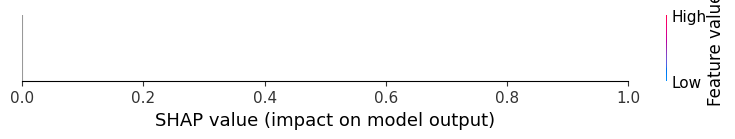

In [ ]:
# Select only top 10 flux columns from the original expanded flux data
X_top10_orig = flux_expanded[top10_fluxes].copy()

# Filter shap_top10 accordingly (same columns order)
shap_top10_filtered = shap_top10[:, :len(top10_fluxes)]  # already aligned

# Do not call plt.figure()
shap.summary_plot(shap_top10, X_top10, plot_type="dot", show=False)
plt.tight_layout()
plt.savefig("shap_beeswarm_top10_fluxes.pdf", dpi=300)
#plt.close()


## Spearman Correlation Heatmap

Index(['Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)',
       '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)',
       'Experiment.1', 'Time (d)', 'g substrate COD/L', 'Type of substrate',
       'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium',
       ' g NaHCO3/L', 'Illumination', 'Levulinic acid',
       'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange',
       'Row', 'Biomass_mgL', 'COD_gL_fed', 'Substrate_type', 'Time_h',
       'PHB_mgL', 'biomass_initial_gL', 'biomass_final_gL', 'biomass_eff_gL',
       'PHB_exp_flux', 'Substrate_exp_flux', 'sub_rxn_id', 'PHB_model_flux',
       'PHV_model_flux', '3HV_model_flux', 'PHBV_model_flux',
       'Biomass_model_flux', 'Substrate_model_flux', 'Top10_fluxes'],
      dtype='object')


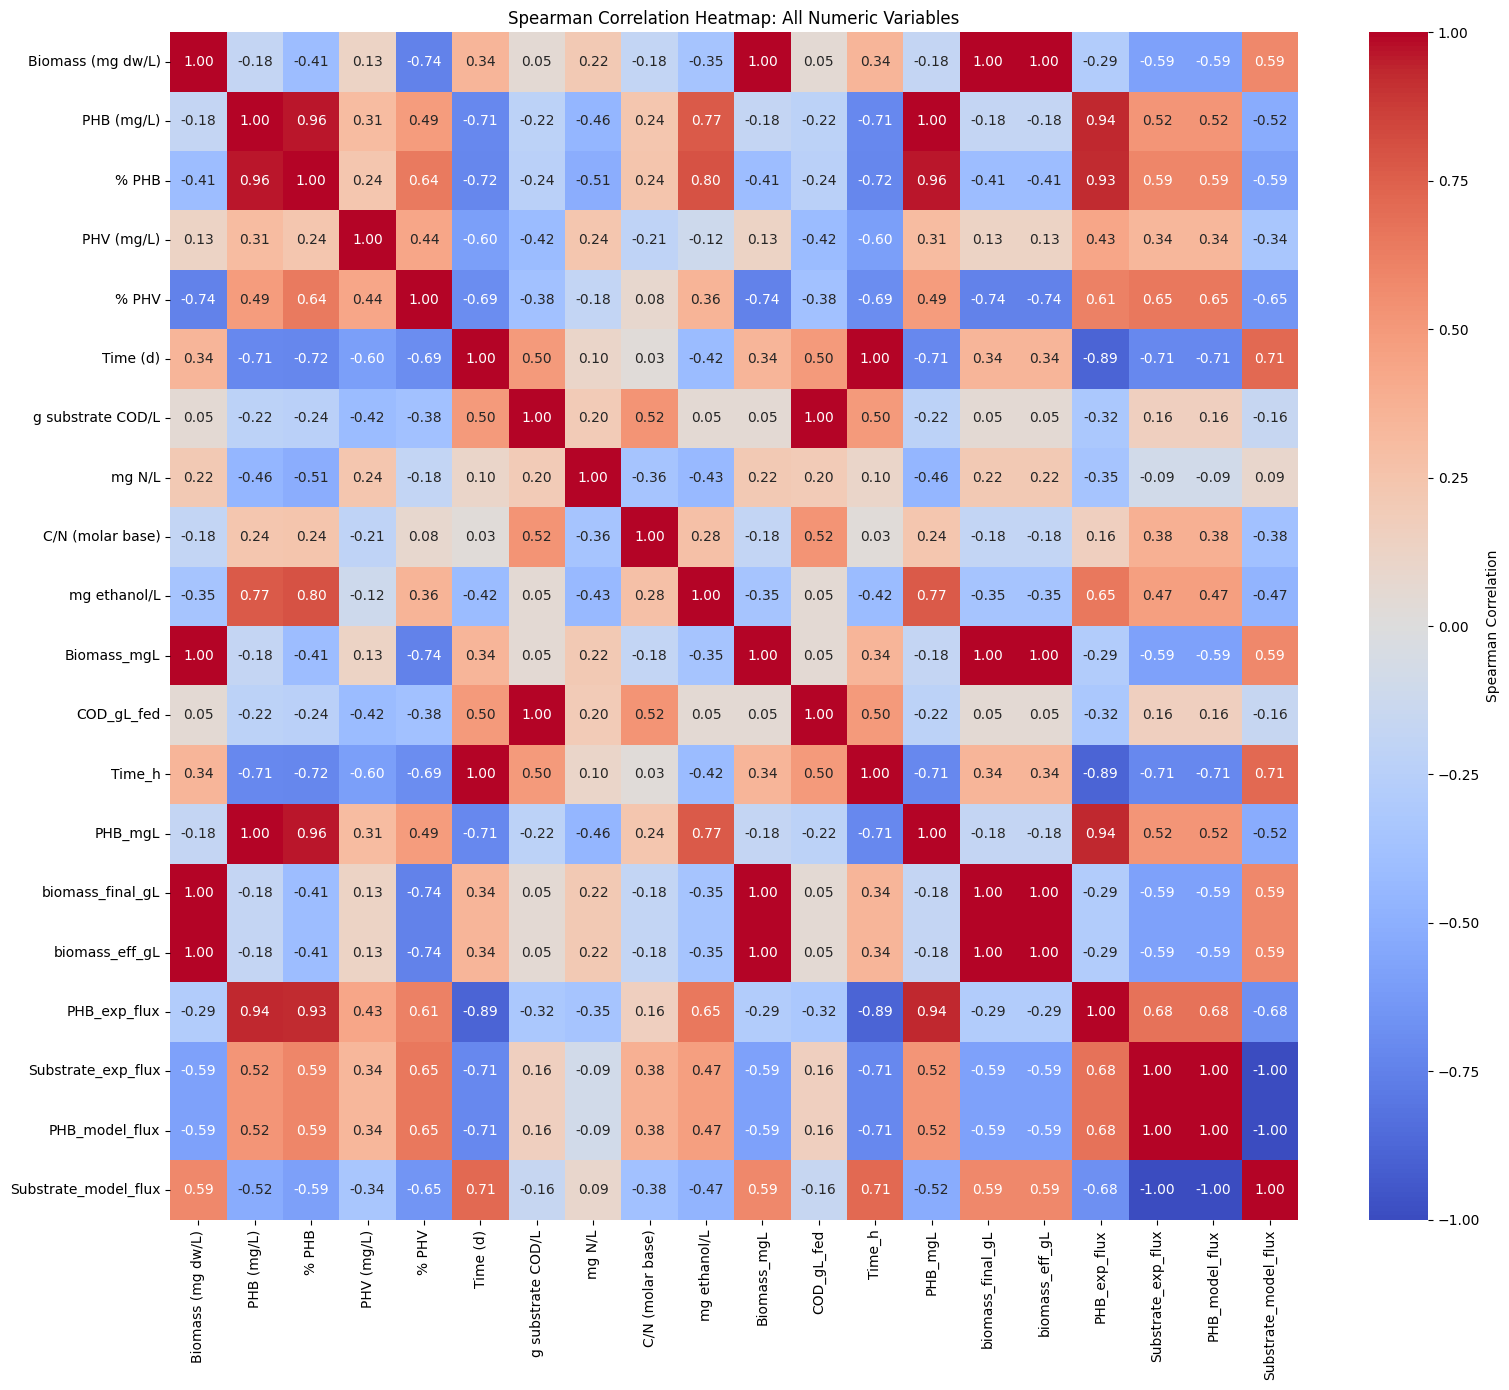

In [ ]:
# Load experimental data form Buitron 2025 with fluxes added from GEM
expanded_csv_path = os.path.join(OUTPUT_DIR, "Buitron_FBA_with_fluxes.csv")

df = pd.read_csv("Buitron_with_FBA_fluxes.csv")

print(df.columns)

columns_to_drop = ['Row', 'Experiment', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', '5-ALA (micromol/L)'] # focus on PHB

# Remove the specified columns
# axis=1 indicates columns (axis=0 is for rows)
# inplace=True modifies the DataFrame directly, otherwise a new DataFrame is returned
df.drop(columns_to_drop, axis=1, inplace=True)


# Keep only numeric columns
numeric_df = df.select_dtypes(include=[float, int])

# Drop constant columns
numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]

# Compute Spearman correlation
spearman_corr = numeric_df.corr(method='spearman')

# Plot heatmap with correlation values
plt.figure(figsize=(16, 14))
sns.heatmap(
    spearman_corr,
    cmap="coolwarm",
    center=0,
    annot=True,        # Show correlation values
    fmt=".2f",         # Format to 2 decimal places
    cbar_kws={'label': 'Spearman Correlation'}
)
plt.title("Spearman Correlation Heatmap: All Numeric Variables")
plt.tight_layout()
plt.show()


Note: almost all fluxes corrlate negatively with PHB production. Also, fluxes seem to correlate almost perfectly among them.

## SHAP interaction plot

In [ ]:
# Use full preprocessed feature set (numeric + one-hot encoded categorical)
X_full = X_all_trans  # already transformed via preprocessor
feature_names_full = feature_names

# Create SHAP TreeExplainer for the full model
explainer = shap.TreeExplainer(model)  # your trained CatBoost model
shap_interaction_values = explainer.shap_interaction_values(X_full)
# shape: (n_samples, n_features, n_features)

# Compute mean absolute interactions across all samples
mean_interactions = np.abs(shap_interaction_values).mean(axis=0)
interaction_df = pd.DataFrame(mean_interactions, index=feature_names_full, columns=feature_names_full)

# Optional: keep only the top 20 features by mean absolute SHAP
top_features = np.abs(explainer.shap_values(X_full)).mean(axis=0).argsort()[-20:][::-1]
interaction_df_top = interaction_df.iloc[top_features, top_features]

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(interaction_df_top, annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("Mean Absolute SHAP Interaction Heatmap – Top 20 Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("shap_interaction_heatmap_full_top20.pdf", dpi=300)
plt.show()


NameError: name 'X_all_trans' is not defined

## Pathway-level SHAP analysis

These are the pathways that contribute to the prediction of PHB production the most

[]


IndexError: index 0 is out of bounds for axis 0 with size 0

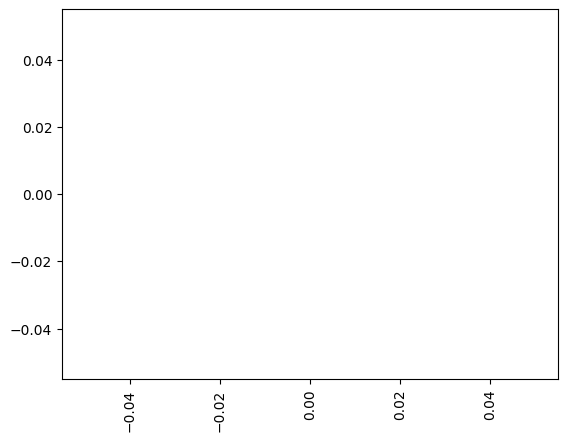

In [ ]:
# Create a dictionary: reaction ID → subsystem
flux_subsystem = {rxn.id: rxn.subsystem if rxn.subsystem else "Other"
                  for rxn in model_acetate1.reactions}

# Map SHAP features to subsystem
feature_to_subsystem = {f: flux_subsystem.get(f.replace("flux_", ""), "Other") for f in top10_fluxes}

# Aggregate SHAP values
shap_df = pd.DataFrame(shap_top10, columns=top10_fluxes)

shap_df.columns = [feature_to_subsystem[f] for f in shap_df.columns]

print(shap_df.columns.tolist())

# Mean absolute SHAP per subsystem
#subsystem_shap = shap_df.abs().mean(axis=0).groupby(level=0).sum().sort_values(ascending=False)
subsystem_shap = shap_df.mean(axis=0).groupby(level=0).sum().sort_values()



# Plot
subsystem_shap.plot(kind="bar")


## WordCloud (using SHAP values)

In [ ]:
from wordcloud import WordCloud

# Make a dictionary for WordCloud: subsystem -> mean absolute SHAP
# You can use signed or absolute values depending on whether you want directionality
wordcloud_dict = subsystem_shap_signed.abs().to_dict()  # use abs for size only

# Create the WordCloud
wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis"  # choose any colormap
).generate_from_frequencies(wordcloud_dict)

# Display
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Subsystem Importance WordCloud (from SHAP values)")
plt.tight_layout()
plt.show()


NameError: name 'subsystem_shap_signed' is not defined

In [ ]:
# Print reactions associated to an specific subsystem (e.g., "Oxidative phosphorylation")

# Remove "flux_" prefix to match reaction IDs in model
reaction_ids = [f.replace("flux_", "") for f in top10_fluxes]

# Find reactions in top10 that belong to Oxidative phosphorylation
oxphos_reactions = [rxn for rxn in reaction_ids
                    if flux_subsystem.get(rxn, "Other") == "Oxidative phosphorylation"]

print("Top 10 flux reactions associated with Oxidative phosphorylation:")
print(oxphos_reactions)


Top 10 flux reactions associated with Oxidative phosphorylation:
[]


## UMAP

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


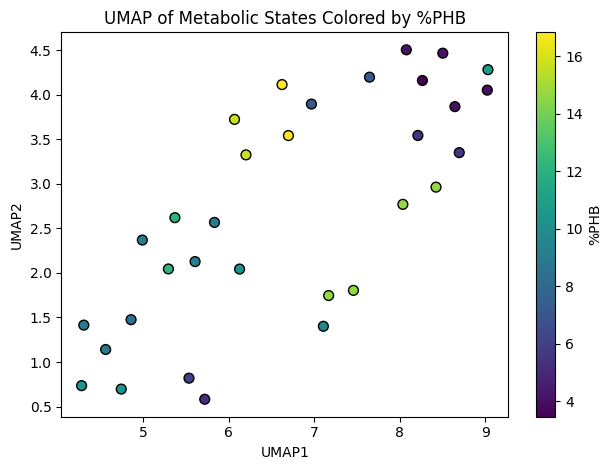

In [ ]:
from sklearn.preprocessing import StandardScaler
import umap

# ---------------------------
# Load data
# ---------------------------
df = pd.read_csv(expanded_csv_path)

# Select flux columns (numeric)
flux_cols = [c for c in df.columns if c.startswith("flux_")]
flux_data = df[flux_cols].fillna(0)  # fill missing fluxes

# Assuming flux_data is numeric and scaled
scaler = StandardScaler()
flux_scaled = scaler.fit_transform(flux_data)

# Run UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
umap_embedding = reducer.fit_transform(flux_scaled)

# Plot UMAP, make sure to capture the scatter object
scatter = plt.scatter(
    umap_embedding[:,0],
    umap_embedding[:,1],
    c=df["% PHB"].values,  # numeric values
    cmap="viridis",
    s=50,
    edgecolor="k"
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP of Metabolic States Colored by %PHB")

# Attach colorbar to the scatter
plt.colorbar(scatter, label="%PHB")

plt.tight_layout()
plt.show()


In [ ]:
# Find the metabolic states associated to the highest porduction of PHB

# Identify indices of top 3 highest %PHB
top3_idx = df["% PHB"].nlargest(3).index

# Get their UMAP coordinates
top3_umap = umap_embedding[top3_idx]

# Get the original fluxes of these top 3 points
top3_fluxes = flux_data.iloc[top3_idx]

# Optionally, get all info from original dataframe
top3_data = df.iloc[top3_idx]

print("Top 3 points by % PHB:")
print(top3_data)

print("\nUMAP coordinates of top 3 points:")
print(top3_umap)

print("\nFlux profiles of top 3 points:")
print(top3_fluxes)


Top 3 points by % PHB:
    Experiment  Biomass (mg dw/L)  PHB (mg/L)  % PHB  PHV (mg/L)  % PHV  \
17          21               1417      238.44  16.83       10.65   0.75   
18          22               1367      230.03  16.83       10.27   0.75   
21          25               1433      225.72  15.75       10.67   0.74   

    5-ALA (micromol/L)  Q10 (mg/g dw)  Carotenoids (mg/g dw)  Experiment.1  \
17                 NaN            NaN                    NaN           NaN   
18                 NaN            NaN                    NaN           NaN   
21                 NaN            NaN                    NaN           NaN   

    ...  flux_ASPTA  flux_GLNS flux_GLUSfx  flux_FNOR_1  flux_ATPSu  \
17  ...   -2.730924   1.990027    1.990027          NaN         NaN   
18  ...   -2.830843   2.062836    2.062836          NaN         NaN   
21  ...   -3.146851   2.293108    2.293108          NaN         NaN   

    flux_ACOAH  flux_DHORDi  flux_DHORD3um flux_ATPM flux_NDH_1_1_um_copy1  
1

Top 3 PHB producers:
   % PHB
1  16.83
2  16.83
5  15.75


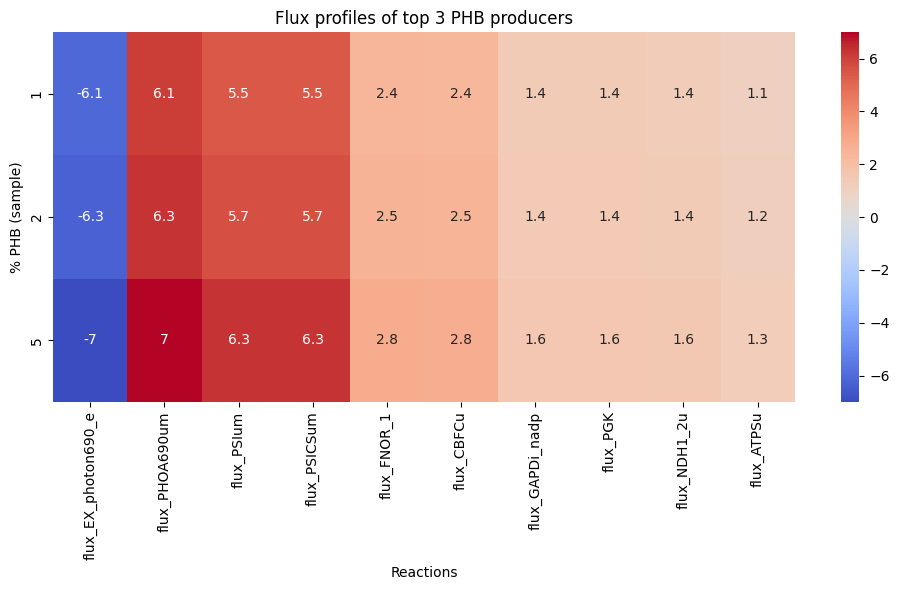

In [ ]:
# Sort dataframe by % PHB
top3_idx = df["% PHB"].nlargest(3).index
top3_df = df.loc[top3_idx]

print("Top 3 PHB producers:")
print(top3_df[["% PHB"]])

# Visualize heatmap

plt.figure(figsize=(10,6))
sns.heatmap(top3_fluxes, cmap="coolwarm", annot=True)
plt.title("Flux profiles of top 3 PHB producers")
plt.xlabel("Reactions")
plt.ylabel("% PHB (sample)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## Performance comparisson

Standard numeric cols: ['Biomass (mg dw/L)', 'PHB (mg/L)', 'PHV (mg/L)', '% PHV', 'Time (d)', 'g substrate COD/L', 'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium', ' g NaHCO3/L', 'Fe (mg Ferric citrate/L)', '% Volume exchange', 'Biomass_mgL', 'PHB_mgL', 'COD_gL_fed', 'biomass_gL', 'PHB_exp_flux', 'Acetate_flux', 'PHB_model_flux', 'Biomass_model_flux', 'Substrate_model_flux']
Flux cols: []
Categorical cols: ['Type of substrate']
Standard features only -> RMSE: 0.36122453449804937 R²: 0.9923272922367269
Standard + flux features -> RMSE: 0.36122453449804937 R²: 0.9923272922367269

Training set (first 10 rows, Standard + Flux features):
   Biomass (mg dw/L)  PHB (mg/L)  PHV (mg/L)  % PHV  Time (d)  \
0               1538      158.07        0.60   0.60         5   
1               1383      125.21        8.00   0.58         4   
2               2467       85.56       11.97   0.57         5   
3               1667       93.18        5.12   0.34         5   
4         

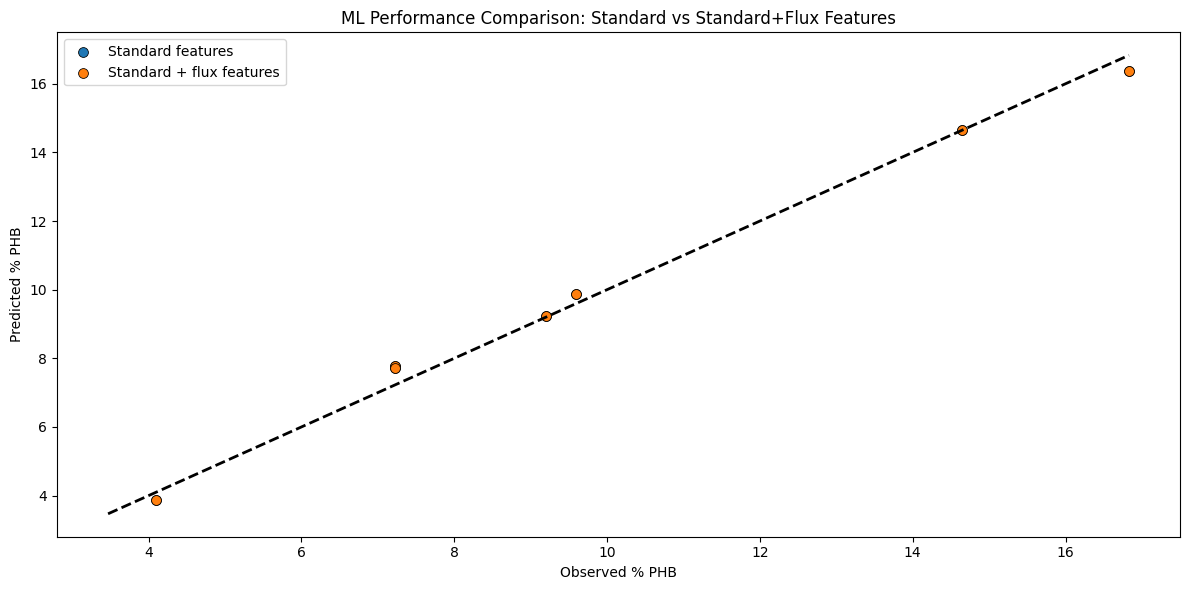

In [ ]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------------
# LOAD DATA
# -------------------------------
df = pd.read_csv("Buitron_with_FBA_fluxes.csv") #expanded_csv_path

columns_to_drop = ['Row', 'Experiment', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', '5-ALA (micromol/L)']
df.drop(columns_to_drop, axis=1, inplace=True)

TARGET = "% PHB"
df = df[np.isfinite(df[TARGET])]
df = df.reset_index(drop=True)

# -------------------------------
# FEATURE IDENTIFICATION
# -------------------------------
flux_cols = [c for c in df.columns if c.startswith("flux_")]

standard_numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
standard_numeric_cols = [c for c in standard_numeric_cols if c not in flux_cols + [TARGET]]

cat_cols = [c for c in ["Substrate", "Type of substrate", "substrate_type"] if c in df.columns]

print("Standard numeric cols:", standard_numeric_cols)
print("Flux cols:", flux_cols)
print("Categorical cols:", cat_cols)

# -------------------------------
# HELPER FUNCTION TO TRAIN AND EVALUATE
# -------------------------------
def train_evaluate_catboost(X, y, cat_cols=None, random_state=42):
    # Split first to keep original DataFrame alignment
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    # Preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), [c for c in X.columns if c not in (cat_cols or [])]),
            ("cat", OneHotEncoder(sparse_output=False), cat_cols or [])
        ],
        remainder="drop"
    )

    X_train_trans = preprocessor.fit_transform(X_train)
    X_test_trans = preprocessor.transform(X_test)

    # Feature names after preprocessing
    ohe_names = list(preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)) if cat_cols else []
    feature_names = [c for c in X.columns if c not in (cat_cols or [])] + ohe_names

    train_pool = Pool(X_train_trans, y_train, feature_names=feature_names)
    test_pool = Pool(X_test_trans, y_test, feature_names=feature_names)

    model = CatBoostRegressor(
        iterations=600,
        depth=4,
        learning_rate=0.05,
        loss_function="RMSE",
        verbose=0
    )

    model.fit(train_pool, eval_set=test_pool, use_best_model=True)

    y_pred = model.predict(X_test_trans)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Return aligned DataFrames as well
    return model, mse, r2, X_train, X_test, y_train, y_test, y_pred

# -------------------------------
# MODEL 1: Standard features only
# -------------------------------
X_standard = df[standard_numeric_cols + cat_cols]
y = df[TARGET]

(model_std, mse_std, r2_std,
 X_train_std, X_test_std, y_train_std, y_test_std, y_pred_std) = train_evaluate_catboost(X_standard, y, cat_cols=cat_cols)

print("Standard features only -> RMSE:", np.sqrt(mse_std), "R²:", r2_std)

# -------------------------------
# MODEL 2: Standard + Flux features
# -------------------------------
X_flux = df[standard_numeric_cols + flux_cols + cat_cols]

(model_flux, mse_flux, r2_flux,
 X_train_flux, X_test_flux, y_train_flux, y_test_flux, y_pred_flux) = train_evaluate_catboost(X_flux, y, cat_cols=cat_cols)

print("Standard + flux features -> RMSE:", np.sqrt(mse_flux), "R²:", r2_flux)

# -------------------------------
# PRINT TRAINING AND VALIDATION DATASETS
# -------------------------------
print("\nTraining set (first 10 rows, Standard + Flux features):")
print(pd.concat([X_train_flux.reset_index(drop=True), y_train_flux.reset_index(drop=True)], axis=1).head(10))

print("\nValidation set (first 10 rows, Standard + Flux features):")
print(pd.concat([X_test_flux.reset_index(drop=True), y_test_flux.reset_index(drop=True)], axis=1).head(10))

# -------------------------------
# VISUALIZE PERFORMANCE
# -------------------------------
plt.figure(figsize=(12,6))
sns.scatterplot(x=y_test_std, y=y_pred_std, label="Standard features", s=50, edgecolor="k")
sns.scatterplot(x=y_test_flux, y=y_pred_flux, label="Standard + flux features", s=50, edgecolor="k")

plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel("Observed % PHB")
plt.ylabel("Predicted % PHB")
plt.title("ML Performance Comparison: Standard vs Standard+Flux Features")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
df = pd.read_csv(expanded_csv_path)

columns_to_drop = ['Row', 'Experiment', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', '5-ALA (micromol/L)']
df.drop(columns_to_drop, axis=1, inplace=True)
print(df.columns)

Index(['Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)', '% PHV',
       'Time (d)', 'g substrate COD/L', 'Type of substrate', 'mg N/L',
       'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium',
       ' g NaHCO3/L', 'Illumination', 'Levulinic acid',
       'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange',
       'Substrate', 'Substrate_flux', 'PHB_exp_mgL', 'PHB_exp_q',
       'PHB_model_q', 'Biomass_flux', 'flux_EX_photon690_e', 'flux_PHOA690um',
       'flux_PSIum', 'flux_PSICSum', 'flux_FNOR_1', 'flux_CBFCu',
       'flux_GAPDi_nadp', 'flux_PGK', 'flux_NDH1_2u', 'flux_ATPSu'],
      dtype='object')


## Version 2 of performance comparison

In [ ]:
# Standardized version of performance comparison

# -------------------------------
# LOAD DATA
# -------------------------------
df = pd.read_csv(expanded_csv_path)

columns_to_drop = ['Row', 'Experiment', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', '5-ALA (micromol/L)']
df.drop(columns_to_drop, axis=1, inplace=True)

TARGET = "% PHB"
df = df[np.isfinite(df[TARGET])]
df = df.reset_index(drop=True)

# -------------------------------
# FEATURE IDENTIFICATION
# -------------------------------
flux_cols = [c for c in df.columns if c.startswith("flux_")]

standard_numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
standard_numeric_cols = [c for c in standard_numeric_cols if c not in flux_cols + [TARGET]]

cat_cols = [c for c in ["Substrate", "Type of substrate", "substrate_type"] if c in df.columns]

print("Standard numeric cols:", standard_numeric_cols)
print("Flux cols:", flux_cols)
print("Categorical cols:", cat_cols)

# -------------------------------
# HELPER FUNCTION TO TRAIN AND EVALUATE
# -------------------------------
def train_evaluate_catboost(X, y, cat_cols=None, random_state=42):
    # Preprocessing: standardize all numeric features
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), [c for c in X.columns if c not in (cat_cols or [])]),
            ("cat", OneHotEncoder(sparse_output=False), cat_cols or [])
        ],
        remainder="drop"
    )

    # Split into train/validation
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    X_train_trans = preprocessor.fit_transform(X_train)
    X_test_trans = preprocessor.transform(X_test)

    # Feature names after preprocessing
    ohe_names = list(preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)) if cat_cols else []
    feature_names = [c for c in X.columns if c not in (cat_cols or [])] + ohe_names

    train_pool = Pool(X_train_trans, y_train, feature_names=feature_names)
    test_pool = Pool(X_test_trans, y_test, feature_names=feature_names)

    model = CatBoostRegressor(
        iterations=600,
        depth=4,
        learning_rate=0.05,
        loss_function="RMSE",
        verbose=0
    )

    model.fit(train_pool, eval_set=test_pool, use_best_model=True)

    y_pred = model.predict(X_test_trans)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return model, mse, r2, X_train, X_test, y_train, y_test, y_pred

# -------------------------------
# MODEL 1: Standard features only
# -------------------------------
X_standard = df[standard_numeric_cols + cat_cols]
y = df[TARGET]

model_std, mse_std, r2_std, X_train_std, X_test_std, y_train_std, y_test_std, y_pred_std = train_evaluate_catboost(
    X_standard, y, cat_cols=cat_cols
)
print("Standard features only -> RMSE:", np.sqrt(mse_std), "R²:", r2_std)

# -------------------------------
# MODEL 2: Standard + Flux features
# -------------------------------
X_flux = df[standard_numeric_cols + flux_cols + cat_cols]

model_flux, mse_flux, r2_flux, X_train_flux, X_test_flux, y_train_flux, y_test_flux, y_pred_flux = train_evaluate_catboost(
    X_flux, y, cat_cols=cat_cols
)
print("Standard + flux features -> RMSE:", np.sqrt(mse_flux), "R²:", r2_flux)

# -------------------------------
# PRINT TRAINING/VALIDATION DATA
# -------------------------------
print("\nTraining set (first 10 rows):")
print(pd.concat([X_train_flux.reset_index(drop=True), y_train_flux.reset_index(drop=True)], axis=1).head(10))

print("\nValidation set (first 10 rows):")
print(pd.concat([X_test_flux.reset_index(drop=True), y_test_flux.reset_index(drop=True)], axis=1).head(10))

# -------------------------------
# VISUALIZE PERFORMANCE
# -------------------------------
plt.figure(figsize=(12,6))
sns.scatterplot(x=y_test_std, y=y_pred_std, label="Standard features", s=50, edgecolor="k")
sns.scatterplot(x=y_test_flux, y=y_pred_flux, label="Standard + flux features", s=50, edgecolor="k")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel("Observed % PHB")
plt.ylabel("Predicted % PHB")
plt.title("ML Performance Comparison: Standard vs Standard+Flux Features (All numeric features standardized)")
plt.legend()
plt.tight_layout()
plt.show()


# *Data Augmentation

To generalize outside observed space. This code computes costs

In [ ]:
df_exp = pd.read_csv("Buitron_with_FBA_fluxes_PHBV.csv")
df_exp['PHBV_model_flux']

,PHBV_model_flux
0,0.167984
1,0.255415
2,0.257142
3,0.210980
4,0.212087
5,0.191194
6,0.187478
7,0.183956
8,0.186612
9,0.399997


In [ ]:
from itertools import product
from tqdm import tqdm

# ---------------------------------------------------------
# PART 0 — Setup
# ---------------------------------------------------------

# Replace with your actual GEM model object
model = model_acetate1  # COBRApy model


# ---------------------------------------------------------
# PART 1 — Load experimental dataset and identify max PHB
# ---------------------------------------------------------

df_exp = pd.read_csv("Buitron_with_FBA_fluxes_PHBV.csv")

# Keep only experimental rows
df_exp = df_exp.iloc[1:38].copy()

# Identify max-PHB row
max_phb_index = df_exp['% PHB'].idxmax()
max_phb_row = df_exp.loc[max_phb_index]

print("\n=== Max PHB Row ===")
print(max_phb_row)

# Acetate uptake used for GEM sweep
ACETATE_UPTAKE = max_phb_row['Substrate_model_flux']
print("\nUsing Substrate_flux_model as acetate uptake =", ACETATE_UPTAKE)


# ---------------------------------------------------------
# PART 2 — GEM sweep with co-feeding substrates
# ---------------------------------------------------------

# PHVB bounds
phb_rxn = model.reactions.get_by_id("PHBVS_syn")
phb_rxn.lower_bound = 0
phb_rxn.upper_bound = 0.6

# Swept exchange reactions (co-feeding)
targets = ["EX_fum_e", "EX_hxa_e", "EX_ppa_e",
           "EX_lac__L_e", "EX_but_e", "EX_succ_e"]

# Sweep values
sweep_values = np.linspace(0, 0.2, 2)  # adjust as needed

results = []

print("\n=== Running GEM sweep ===")

for fum, hxa, ppa, lac, but, succ in tqdm(
    product(sweep_values, repeat=len(targets)),
    total=len(sweep_values) ** len(targets),
    desc="Simulations"
):
    m = model.copy()

    # Fix acetate uptake
    rx_ac = m.reactions.get_by_id("EX_ac_e")
    rx_ac.lower_bound = ACETATE_UPTAKE
    rx_ac.upper_bound = 0

    # Set co-substrate uptakes
    for rxn_id, val in zip(targets, [fum, hxa, ppa, lac, but, succ]):
        rx = m.reactions.get_by_id(rxn_id)
        rx.lower_bound = -val
        rx.upper_bound = 0

    # Set objective as PHB synthesis
    m.objective =  "PHBVS_syn"#"PHB_syn"
    sol = m.optimize()

    results.append({
        "ac": ACETATE_UPTAKE,
        "fum": -fum,
        "hxa": -hxa,
        "ppa": -ppa,
        "lac": -lac,
        "but": -but,
        "succ": -succ,
        "PHB_model_flux": sol.fluxes.get("PHBS_syn", np.nan) if sol.status == "optimal" else np.nan,
        "PHV_model_flux": sol.fluxes.get("PHVS_syn", np.nan) if sol.status == "optimal" else np.nan,
        "3HV_model_flux": sol.fluxes.get("3hvcoa_syn", np.nan) if sol.status == "optimal" else np.nan,
        "PHBV_model_flux": sol.fluxes.get("PHBVS_syn", np.nan) if sol.status == "optimal" else np.nan,
        "Biomass_model_flux": sol.fluxes.get("BIOMASS__1", np.nan) if sol.status == "optimal" else np.nan
    })

df_gem = pd.DataFrame(results)
df_gem.to_csv("sweep_fixed_ac_MAX_PHB.csv", index=False)
print("\nSaved GEM sweep results → sweep_fixed_ac_MAX_PHB.csv")


# ---------------------------------------------------------
# PART 3 — Copy experimental standard features to GEM rows
# ---------------------------------------------------------

flux_cols = [c for c in df_exp.columns if c.startswith("flux_")]
standard_cols = [c for c in df_exp.columns if c not in flux_cols + ["% PHB", "PHB_model_flux"]]

for col in standard_cols:
    df_gem[col] = max_phb_row[col]

df_gem["is_experimental"] = 0
df_exp["is_experimental"] = 1


# ---------------------------------------------------------
# PART 4 — Add/assign substrate uptake columns
# ---------------------------------------------------------

substrate_cols = ["ac", "fum", "hxa", "ppa", "lac", "but", "succ"]

# Ensure columns exist in experimental data
for col in substrate_cols:
    if col not in df_exp.columns:
        df_exp[col] = 0.0

# Set acetate uptake for experimental rows
df_exp.loc[df_exp["is_experimental"] == 1, "ac"] = -df_exp["Substrate_model_flux"]

# Co-feeding substrates = 0 for experimental
for col in ["fum", "hxa", "ppa", "lac", "but", "succ"]:
    df_exp[col] = 0.0


# ---------------------------------------------------------
# PART 5 — Merge experimental + GEM simulated dataset
# ---------------------------------------------------------

df_final = pd.concat([df_exp, df_gem], ignore_index=True)


# ---------------------------------------------------------
# PART 6 — Carbon accounting, uptake, C/N ratio, cost
# ---------------------------------------------------------

# Carbon atoms per substrate
C_atoms = {
    "ac": 2,
    "fum": 4,
    "hxa": 6,
    "ppa": 3,
    "lac": 3,
    "but": 4,
    "succ": 4
}

# Nitrogen uptake (constant ammonium consumption)
nh4_uptake = 0.06590  # mmol N/gDW/h

# Total carbon uptake
df_final["C_total"] = 0
for sub in C_atoms:
    if sub in df_final.columns:
        df_final["C_total"] += df_final[sub] * C_atoms[sub]

# Nitrogen total
df_final["N_total"] = nh4_uptake

# C/N ratio
df_final["C/N_ratio"] = df_final["C_total"] / df_final["N_total"]

# Total substrate uptake
df_final["total_uptake"] = df_final[substrate_cols].sum(axis=1)

# Price per mmol substrate (USD/mmol)
price_per_mmol = {
    "ac": 0.00847,
    "fum": 0.01034,
    "hxa": 0.00860,
    "ppa": 0.01215,
    "lac": 0.00666,
    "but": 0.00624,
    "succ": 0.00677
}

# Total cost
df_final["total_cost"] = 0
for sub in price_per_mmol:
    if sub in df_final.columns:
        df_final['total_cost'] = sum(df_final[sub].abs() * price_per_mmol[sub] for sub in substrate_cols)

print("Added C_total, N_total, C/N_ratio, total_uptake, total_cost to df_final.")


# ---------------------------------------------------------
# PART 7 — Save augmented dataset
# ---------------------------------------------------------

df_final.to_csv("Buitron2025_dataset_augmented_PHBV_with_cost.csv", index=False)
print("\n=== Final dataset saved → Buitron2025_dataset_augmented_PHBV_with_cost.csv ===")



=== Max PHB Row ===
Experiment                          21
Biomass (mg dw/L)                 1417
PHB (mg/L)                      238.44
% PHB                            16.83
PHV (mg/L)                       10.65
% PHV                             0.75
5-ALA (micromol/L)                 NaN
Q10 (mg/g dw)                      NaN
Carotenoids (mg/g dw)              NaN
Experiment.1                       NaN
Time (d)                             3
g substrate COD/L                 3.57
Type of substrate              Acetate
mg N/L                           130.0
C/N (molar base)                  12.0
mg ethanol/L                      0.79
Fraction mineral medium            1.0
 g NaHCO3/L                        0.0
Illumination                continuous
Levulinic acid                      No
Fe (mg Ferric citrate/L)             5
Operation mode                   Batch
% Volume exchange                  100
Row                                 18
Biomass_mgL                       1417
COD_

Simulations: 100%|██████████| 64/64 [01:29<00:00,  1.40s/it]


Saved GEM sweep results → sweep_fixed_ac_MAX_PHB.csv
Added C_total, N_total, C/N_ratio, total_uptake, total_cost to df_final.

=== Final dataset saved → Buitron2025_dataset_augmented_with_cost.csv ===


# Data augmentation (PHBV)

This code does data augmentation using a GEM with PHBV as objective function

In [ ]:
from itertools import product
from tqdm import tqdm

# ---------------------------------------------------------
# PART 0 — Setup
# ---------------------------------------------------------

# Replace with your actual GEM model object
model = model_acetate1  # COBRApy model


# ---------------------------------------------------------
# PART 1 — Load experimental dataset and identify max PHB
# ---------------------------------------------------------

df_exp = pd.read_csv("Buitron_with_FBA_fluxes_PHBV.csv")

# Keep only experimental rows
df_exp = df_exp.iloc[1:38].copy()

# Identify max-PHB row
max_phb_index = df_exp['% PHB'].idxmax()
max_phb_row = df_exp.loc[max_phb_index]

print("\n=== Max PHB Row ===")
print(max_phb_row)

# Acetate uptake used for GEM sweep
ACETATE_UPTAKE = max_phb_row['Substrate_model_flux']
print("\nUsing Substrate_flux_model as acetate uptake =", ACETATE_UPTAKE)


# ---------------------------------------------------------
# PART 2 — GEM sweep with co-feeding substrates
# ---------------------------------------------------------

# PHB bounds
#phb_rxn = model.reactions.get_by_id("PHBVS_syn")
phb_rxn.lower_bound = 0
phb_rxn.upper_bound = 1

# Swept exchange reactions (co-feeding)
targets = ["EX_fum_e", "EX_hxa_e", "EX_ppa_e",
           "EX_lac__L_e", "EX_but_e", "EX_succ_e"]

# Sweep values
sweep_values = np.linspace(0, 0.2, 2)  # adjust as needed

results = []

print("\n=== Running GEM sweep ===")

for fum, hxa, ppa, lac, but, succ in tqdm(
    product(sweep_values, repeat=len(targets)),
    total=len(sweep_values) ** len(targets),
    desc="Simulations"
):
    m = model.copy()

    # Fix acetate uptake
    rx_ac = m.reactions.get_by_id("EX_ac_e")
    rx_ac.lower_bound = ACETATE_UPTAKE
    rx_ac.upper_bound = 0

    # Set co-substrate uptakes
    for rxn_id, val in zip(targets, [fum, hxa, ppa, lac, but, succ]):
        rx = m.reactions.get_by_id(rxn_id)
        rx.lower_bound = -val
        rx.upper_bound = 0

    # Set objective as PHB synthesis
    m.objective = "PHBVS_syn"
    sol = m.optimize()

    results.append({
        "ac": ACETATE_UPTAKE,
        "fum": -fum,
        "hxa": -hxa,
        "ppa": -ppa,
        "lac": -lac,
        "but": -but,
        "succ": -succ,
        "PHBV_model_flux": sol.fluxes.get("PHBVS_syn", np.nan) if sol.status == "optimal" else np.nan,
        "PHB_model_flux": sol.fluxes.get("PHBS_syn", np.nan) if sol.status == "optimal" else np.nan,
        "PHV_model_flux": sol.fluxes.get("PHVS_syn", np.nan) if sol.status == "optimal" else np.nan,
        "3HV_model_flux": sol.fluxes.get("3hvcoa_syn", np.nan) if sol.status == "optimal" else np.nan,
        "Biomass_model_flux": sol.fluxes.get("BIOMASS__1", np.nan) if sol.status == "optimal" else np.nan
    })

df_gem = pd.DataFrame(results)
df_gem.to_csv("sweep_fixed_ac_MAX_PHB.csv", index=False)
print("\nSaved GEM sweep results → sweep_fixed_ac_MAX_PHB.csv")


# ---------------------------------------------------------
# PART 3 — Copy experimental standard features to GEM rows
# ---------------------------------------------------------

flux_cols = [c for c in df_exp.columns if c.startswith("flux_")]
standard_cols = [c for c in df_exp.columns if c not in flux_cols + ["% PHB", "PHB_model_flux"]]

for col in standard_cols:
    df_gem[col] = max_phb_row[col]

df_gem["is_experimental"] = 0
df_exp["is_experimental"] = 1


# ---------------------------------------------------------
# PART 4 — Add/assign substrate uptake columns
# ---------------------------------------------------------

substrate_cols = ["ac", "fum", "hxa", "ppa", "lac", "but", "succ"]

# Ensure columns exist in experimental data
for col in substrate_cols:
    if col not in df_exp.columns:
        df_exp[col] = 0.0

# Set acetate uptake for experimental rows
df_exp.loc[df_exp["is_experimental"] == 1, "ac"] = -df_exp["Substrate_model_flux"]

# Co-feeding substrates = 0 for experimental
for col in ["fum", "hxa", "ppa", "lac", "but", "succ"]:
    df_exp[col] = 0.0


# ---------------------------------------------------------
# PART 5 — Merge experimental + GEM simulated dataset
# ---------------------------------------------------------

df_final = pd.concat([df_exp, df_gem], ignore_index=True)


# ---------------------------------------------------------
# PART 6 — Carbon accounting, uptake, C/N ratio, cost
# ---------------------------------------------------------

# Carbon atoms per substrate
C_atoms = {
    "ac": 2,
    "fum": 4,
    "hxa": 6,
    "ppa": 3,
    "lac": 3,
    "but": 4,
    "succ": 4
}

# Nitrogen uptake (constant ammonium consumption)
nh4_uptake = 0.06590  # mmol N/gDW/h

# Total carbon uptake
df_final["C_total"] = 0
for sub in C_atoms:
    if sub in df_final.columns:
        df_final["C_total"] += df_final[sub] * C_atoms[sub]

# Nitrogen total
df_final["N_total"] = nh4_uptake

# C/N ratio
df_final["C/N_ratio"] = df_final["C_total"] / df_final["N_total"]

# Total substrate uptake
df_final["total_uptake"] = df_final[substrate_cols].sum(axis=1)

# Price per mmol substrate (USD/mmol)
price_per_mmol = {
    "ac": 0.00847,
    "fum": 0.01034,
    "hxa": 0.00860,
    "ppa": 0.01215,
    "lac": 0.00666,
    "but": 0.00624,
    "succ": 0.00677
}

# Total cost
df_final["total_cost"] = 0
for sub in price_per_mmol:
    if sub in df_final.columns:
        df_final['total_cost'] = sum(df_final[sub].abs() * price_per_mmol[sub] for sub in substrate_cols)

print("Added C_total, N_total, C/N_ratio, total_uptake, total_cost to df_final.")


# ---------------------------------------------------------
# PART 7 — Save augmented dataset
# ---------------------------------------------------------

df_final.to_csv("Buitron2025_dataset_augmented_with_cost_PHBV.csv", index=False)
print("\n=== Final dataset saved → Buitron2025_dataset_augmented_with_cost_PHBV.csv ===")



=== Max PHB Row ===
Experiment                          21
Biomass (mg dw/L)                 1417
PHB (mg/L)                      238.44
% PHB                            16.83
PHV (mg/L)                       10.65
% PHV                             0.75
5-ALA (micromol/L)                 NaN
Q10 (mg/g dw)                      NaN
Carotenoids (mg/g dw)              NaN
Experiment.1                       NaN
Time (d)                             3
g substrate COD/L                 3.57
Type of substrate              Acetate
mg N/L                           130.0
C/N (molar base)                  12.0
mg ethanol/L                      0.79
Fraction mineral medium            1.0
 g NaHCO3/L                        0.0
Illumination                continuous
Levulinic acid                      No
Fe (mg Ferric citrate/L)             5
Operation mode                   Batch
% Volume exchange                  100
Row                                 18
Biomass_mgL                       1417
COD_

Simulations: 100%|██████████| 64/64 [01:18<00:00,  1.23s/it]


Saved GEM sweep results → sweep_fixed_ac_MAX_PHB.csv
Added C_total, N_total, C/N_ratio, total_uptake, total_cost to df_final.

=== Final dataset saved → Buitron2025_dataset_augmented_with_cost_PHBV.csv ===


## Opt: augmented data exploration

In [ ]:
df = pd.read_csv("Buitron2025_dataset_augmented_with_cost_PHBV.csv")
df['PHBV_model_flux']

,PHBV_model_flux
0,0.255415
1,0.257142
2,0.210980
3,0.212087
4,0.191194
...,...
90,0.267986
91,0.267986
92,0.267986
93,0.267986


# *Pareto using augmented data and costs
This code includes GEM but does not include catboost as surrogate predicting engine

Index(['Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)',
       '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)',
       'Experiment.1', 'Time (d)', 'g substrate COD/L', 'Type of substrate',
       'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium',
       ' g NaHCO3/L', 'Illumination', 'Levulinic acid',
       'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange',
       'Row', 'Biomass_mgL', 'COD_gL_fed', 'Substrate_type', 'Time_h',
       'PHB_mgL', 'biomass_initial_gL', 'biomass_final_gL', 'biomass_eff_gL',
       'PHB_exp_flux', 'Substrate_exp_flux', 'sub_rxn_id', 'PHB_model_flux',
       'PHV_model_flux', '3HV_model_flux', 'PHBV_model_flux',
       'Biomass_model_flux', 'Substrate_model_flux', 'is_experimental', 'ac',
       'fum', 'hxa', 'ppa', 'lac', 'but', 'succ', 'C_total', 'N_total',
       'C/N_ratio', 'total_uptake', 'total_cost'],
      dtype='object')
Found 1 Pareto optimal solutions.
Optimal s

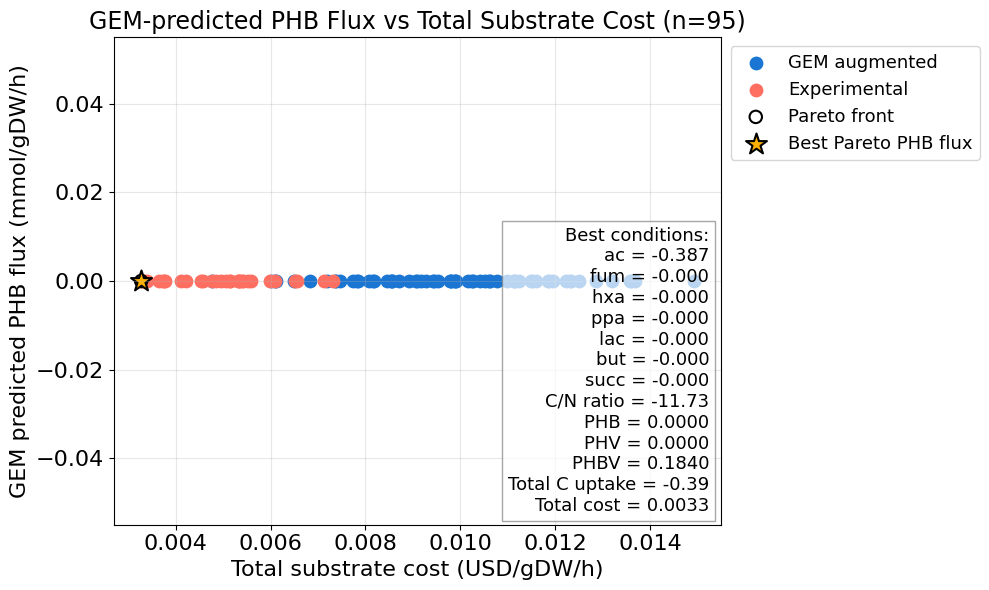

In [ ]:
df_results = pd.read_csv("Buitron2025_dataset_augmented_PHBV_with_cost.csv")
print(df_results.columns)


def is_pareto_efficient(costs, maximize_cols=None):
    """
    Find the Pareto-efficient points.
    costs: 2D array with objectives (each row is a point, columns are objectives)
    maximize_cols: list of indices of objectives to maximize (others are minimized)

    Returns: boolean mask of Pareto efficient points
    """
    costs_adj = costs.copy()
    if maximize_cols:
        for col in maximize_cols:
            costs_adj[:, col] = -costs_adj[:, col]

    n_points = costs_adj.shape[0]
    is_efficient = np.ones(n_points, dtype=bool)
    for i in range(n_points):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(costs_adj[is_efficient] < costs_adj[i], axis=1)
            is_efficient[i] = True
    return is_efficient

# Prepare data: PHB_flux (maximize), total_cost (minimize), total_uptake (minimize)
objectives = df_results[['PHB_model_flux', 'total_cost']].to_numpy()
pareto_mask = is_pareto_efficient(objectives, maximize_cols=[0])

pareto_solutions = df_results[pareto_mask]

print(f"Found {pareto_solutions.shape[0]} Pareto optimal solutions.")

# Find Pareto solution with max PHB_flux
idx_max_phb_pareto = pareto_solutions['PHB_model_flux'].idxmax()
max_phb_pareto_solution = pareto_solutions.loc[idx_max_phb_pareto]


# Extract that row
optimal_solution = df_results.loc[idx_max_phb_pareto]

print("Optimal solution with highest PHB production:")
print(optimal_solution)

n= len(df_results)

plt.figure(figsize=(10,6))

# Recommended scientific palette
COLOR_GEM = "#1A76D2"      # blue
COLOR_EXP = "#FF6F61"      # green
COLOR_BEST = "#FFB000"     # amber gold


# GEM-augmented points
gem_points = df_results[df_results['is_experimental']==0]
plt.scatter(gem_points['total_cost'], gem_points['PHB_model_flux'],
            color=COLOR_GEM, s=80, label='GEM augmented')

# Experimental points
exp_points = df_results[df_results['is_experimental']==1]
plt.scatter(exp_points['total_cost'], exp_points['PHB_model_flux'],
            color=COLOR_EXP, s=80, label='Experimental')

# Pareto front
plt.scatter(pareto_solutions['total_cost'], pareto_solutions['PHB_model_flux'],
            facecolors='none', edgecolors='black', s=80, linewidths=1.5, label='Pareto front')


# Highlight best Pareto PHB solution with yellow star
idx_max_phb_pareto = pareto_solutions['PHB_model_flux'].idxmax()
best_solution = pareto_solutions.loc[idx_max_phb_pareto]

# Best Pareto solution
plt.scatter(best_solution['total_cost'], best_solution['PHB_model_flux'],
            color=COLOR_BEST, s=250, marker='*', edgecolors='black', linewidths=1.5,
            label='Best Pareto PHB flux')

# ---------------------------
# Annotate best solution
# ---------------------------

substrates = ['ac', 'fum', 'hxa', 'ppa', 'lac', 'but', 'succ']
print("Unique substrates:", substrates)

feature_text = "Best conditions:\n" + "\n".join(
    [f"{col} = {-best_solution[col]:.3f}" for col in substrates] +
    [f"C/N ratio = {-best_solution['C/N_ratio']:.2f}",
     f"PHB = {best_solution['PHB_model_flux']:.4f}",
     f"PHV = {best_solution['PHV_model_flux']:.4f}",
     f"PHBV = {best_solution['PHBV_model_flux']:.4f}",
     f"Total C uptake = {-best_solution['total_uptake']:.2f}",
     f"Total cost = {best_solution['total_cost']:.4f}"]
)

plt.annotate(
    feature_text,
    xy=(0.98, 0.02),                 # lower-right corner
    xycoords='axes fraction',
    fontsize=13,
    ha='right',
    va='bottom',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7)
)

# ---------------------------
# Axis labels, title, ticks
# ---------------------------
plt.xlabel('Total substrate cost (USD/gDW/h)', fontsize=16)
plt.ylabel('GEM predicted PHB flux (mmol/gDW/h)', fontsize=16)

plt.title(f'GEM-predicted PHB Flux vs Total Substrate Cost (n={n})',fontsize=17)

# Tick font size
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Grid and legend
plt.grid(True, alpha=0.3)

# Legend outside
plt.legend(loc='upper left', bbox_to_anchor=(1,1), fontsize=13)

plt.tight_layout()
plt.savefig("PHB_flux_predictions_augmented_data_Pareto_3_objectives.png", dpi=300, bbox_inches='tight')
plt.show()


## Pareto for PHBV

In [ ]:
df_results = pd.read_csv("Buitron2025_dataset_augmented_with_cost_PHBV.csv")
print(df_results['PHBV_model_flux'])

0     0.255415
1     0.257142
2     0.210980
3     0.212087
4     0.191194
        ...   
90    0.267986
91    0.267986
92    0.267986
93    0.267986
94    0.267986
Name: PHBV_model_flux, Length: 95, dtype: float64


0     0.255415
1     0.257142
2     0.210980
3     0.212087
4     0.191194
        ...   
90    0.267986
91    0.267986
92    0.267986
93    0.267986
94    0.267986
Name: PHBV_model_flux, Length: 95, dtype: float64
Found 31 Pareto optimal solutions.
Optimal solution with highest PHB production:
Experiment                          12
Biomass (mg dw/L)                 1237
PHB (mg/L)                        99.0
% PHB                              8.4
PHV (mg/L)                         9.5
% PHV                              0.8
5-ALA (micromol/L)                 NaN
Q10 (mg/g dw)                      NaN
Carotenoids (mg/g dw)              NaN
Experiment.1                       NaN
Time (d)                             3
g substrate COD/L                 5.13
Type of substrate              Acetate
mg N/L                           154.7
C/N (molar base)                  16.3
mg ethanol/L                       0.0
Fraction mineral medium            1.0
 g NaHCO3/L                        0.0
Il

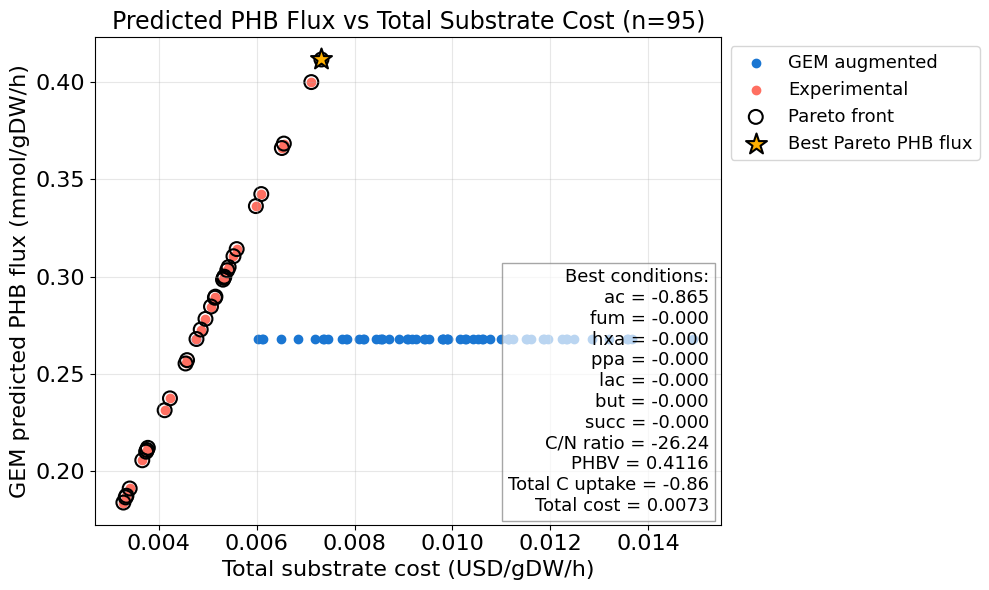

In [ ]:
df_results = pd.read_csv("Buitron2025_dataset_augmented_with_cost_PHBV.csv")
print(df_results['PHBV_model_flux'])


def is_pareto_efficient(costs, maximize_cols=None):
    """
    Find the Pareto-efficient points.
    costs: 2D array with objectives (each row is a point, columns are objectives)
    maximize_cols: list of indices of objectives to maximize (others are minimized)

    Returns: boolean mask of Pareto efficient points
    """
    costs_adj = costs.copy()
    if maximize_cols:
        for col in maximize_cols:
            costs_adj[:, col] = -costs_adj[:, col]

    n_points = costs_adj.shape[0]
    is_efficient = np.ones(n_points, dtype=bool)
    for i in range(n_points):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(costs_adj[is_efficient] < costs_adj[i], axis=1)
            is_efficient[i] = True
    return is_efficient

# Prepare data: PHB_flux (maximize), total_cost (minimize), total_uptake (minimize)
objectives = df_results[['PHBV_model_flux', 'total_cost']].to_numpy()
pareto_mask = is_pareto_efficient(objectives, maximize_cols=[0])

pareto_solutions = df_results[pareto_mask]

print(f"Found {pareto_solutions.shape[0]} Pareto optimal solutions.")

# Find Pareto solution with max PHB_flux
idx_max_phb_pareto = pareto_solutions['PHBV_model_flux'].idxmax()
max_phb_pareto_solution = pareto_solutions.loc[idx_max_phb_pareto]


# Extract that row
optimal_solution = df_results.loc[idx_max_phb_pareto]

print("Optimal solution with highest PHB production:")
print(optimal_solution)

n= len(df_results)

plt.figure(figsize=(10,6))

# Recommended scientific palette
COLOR_GEM = "#1A76D2"      # blue
COLOR_EXP = "#FF6F61"      # green
COLOR_BEST = "#FFB000"     # amber gold


# GEM-augmented points
gem_points = df_results[df_results['is_experimental']==0]
plt.scatter(gem_points['total_cost'], gem_points['PHBV_model_flux'],
            color=COLOR_GEM, alpha=1, label='GEM augmented')

# Experimental points
exp_points = df_results[df_results['is_experimental']==1]
plt.scatter(exp_points['total_cost'], exp_points['PHBV_model_flux'],
            color=COLOR_EXP, label='Experimental')

# Pareto front
plt.scatter(pareto_solutions['total_cost'], pareto_solutions['PHBV_model_flux'],
            facecolors='none', edgecolors='black', s=100, linewidths=1.5, label='Pareto front')


# Highlight best Pareto PHB solution with yellow star
idx_max_phb_pareto = pareto_solutions['PHBV_model_flux'].idxmax()
best_solution = pareto_solutions.loc[idx_max_phb_pareto]

# Best Pareto solution
plt.scatter(best_solution['total_cost'], best_solution['PHBV_model_flux'],
            color=COLOR_BEST, s=250, marker='*', edgecolors='black', linewidths=1.5,
            label='Best Pareto PHB flux')

# ---------------------------
# Annotate best solution
# ---------------------------

substrates = ['ac', 'fum', 'hxa', 'ppa', 'lac', 'but', 'succ']
print("Unique substrates:", substrates)

feature_text = "Best conditions:\n" + "\n".join(
    [f"{col} = {-best_solution[col]:.3f}" for col in substrates] +
    [f"C/N ratio = {-best_solution['C/N_ratio']:.2f}",
     #f"PHV = {best_solution['PHV_model_flux']:.4f}",
     f"PHBV = {best_solution['PHBV_model_flux']:.4f}",
     f"Total C uptake = {-best_solution['total_uptake']:.2f}",
     f"Total cost = {best_solution['total_cost']:.4f}"]
)

plt.annotate(
    feature_text,
    xy=(0.98, 0.02),                 # lower-right corner
    xycoords='axes fraction',
    fontsize=13,
    ha='right',
    va='bottom',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7)
)

# ---------------------------
# Axis labels, title, ticks
# ---------------------------
plt.xlabel('Total substrate cost (USD/gDW/h)', fontsize=16)
plt.ylabel('GEM predicted PHB flux (mmol/gDW/h)', fontsize=16)

plt.title(f'Predicted PHB Flux vs Total Substrate Cost (n={n})',
          fontsize=17)

# Tick font size
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Grid and legend
plt.grid(True, alpha=0.3)

# Legend outside
plt.legend(loc='upper left', bbox_to_anchor=(1,1), fontsize=13)

plt.tight_layout()
plt.savefig("PHB_flux_predictions_augmented_data_Pareto_3_objectives_PHBV.png", dpi=300, bbox_inches='tight')
plt.show()


Next version adds all features to annotation. Version used in presentation

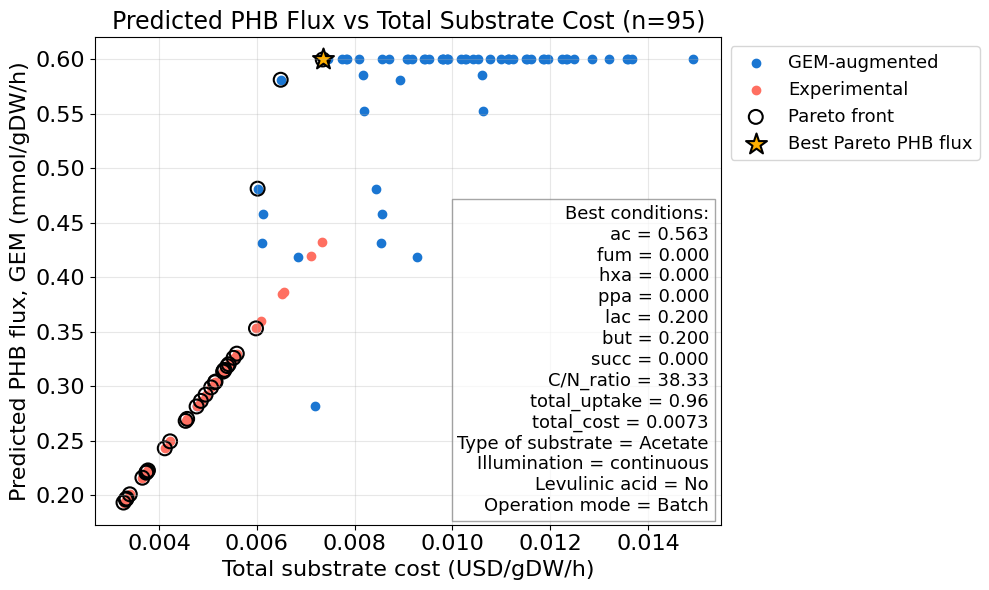

In [ ]:

df_results = pd.read_csv("Buitron2025_dataset_augmented_with_cost.csv")
n = len(df_results)

# Define colors
COLOR_GEM = "#1A76D2"
COLOR_EXP = "#FF6F61"
COLOR_BEST = "#FFB000"

# -------------------------
# PARETO EFFICIENCY FUNCTION
# -------------------------
def is_pareto_efficient(costs, maximize_cols=None):
    costs_adj = costs.copy()
    if maximize_cols:
        for col in maximize_cols:
            costs_adj[:, col] = -costs_adj[:, col]
    n_points = costs_adj.shape[0]
    is_efficient = np.ones(n_points, dtype=bool)
    for i in range(n_points):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(costs_adj[is_efficient] < costs_adj[i], axis=1)
            is_efficient[i] = True
    return is_efficient

# -------------------------
# COMPUTE PARETO FRONT
# -------------------------
objectives = df_results[['PHB_model_flux', 'total_cost', 'Biomass_model_flux']].to_numpy()
pareto_mask = is_pareto_efficient(objectives, maximize_cols=[0, 2])
pareto_solutions = df_results[pareto_mask]

# Best PHB solution on Pareto front
idx_max_phb_pareto = pareto_solutions['PHB_model_flux'].idxmax()
best_solution = pareto_solutions.loc[idx_max_phb_pareto]

# -------------------------
# SCATTER PLOT WITH ANNOTATION
# -------------------------
fig, ax = plt.subplots(figsize=(10,6))

# GEM-augmented points
gem_points = df_results[df_results['is_experimental']==0]
ax.scatter(gem_points['total_cost'], gem_points['PHB_model_flux'],
           color=COLOR_GEM, alpha=1, label='GEM-augmented')

# Experimental points
exp_points = df_results[df_results['is_experimental']==1]
ax.scatter(exp_points['total_cost'], exp_points['PHB_model_flux'],
           color=COLOR_EXP, label='Experimental')

# Pareto front
ax.scatter(pareto_solutions['total_cost'], pareto_solutions['PHB_model_flux'],
           facecolors='none', edgecolors='black', s=100, linewidths=1.5, label='Pareto front')

# Best Pareto PHB solution
ax.scatter(best_solution['total_cost'], best_solution['PHB_model_flux'],
           color=COLOR_BEST, s=250, marker='*', edgecolors='black', linewidths=1.5,
           label='Best Pareto PHB flux')

# -------------------------
# ANNOTATION
# -------------------------
substrates = ['ac', 'fum', 'hxa', 'ppa', 'lac', 'but', 'succ']
cat_features = [c for c in df_results.columns if df_results[c].dtype == "object"]

annotation_lines = []

# Numeric substrate uptakes
for col in substrates:
    if col in best_solution.index:
        annotation_lines.append(f"{col} = {-float(best_solution[col]):.3f}")

# Continuous variables
for col in ['C/N_ratio', 'total_uptake', 'total_cost']:
    if col in best_solution.index:
        val = best_solution[col]
        if col != 'total_cost':
            val = -val
        annotation_lines.append(f"{col} = {val:.4f}" if col=='total_cost' else f"{col} = {val:.2f}")

# Categorical variables
existing_cat_features = [c for c in cat_features if c in df_results.columns]
for col in existing_cat_features:
    if col not in substrates and col != 'sub_rxn_id':
        annotation_lines.append(f"{col} = {best_solution[col]}")

feature_text = "Best conditions:\n" + "\n".join(annotation_lines)

ax.annotate(
    feature_text,
    xy=(0.98, 0.02),
    xycoords='axes fraction',
    fontsize=13,
    ha='right',
    va='bottom',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7)
)

# -------------------------
# AXES AND TITLE
# -------------------------
ax.set_xlabel('Total substrate cost (USD/gDW/h)', fontsize=16)
ax.set_ylabel('Predicted PHB flux, GEM (mmol/gDW/h)', fontsize=16)
ax.set_title(f'Predicted PHB Flux vs Total Substrate Cost (n={n})', fontsize=17)
ax.tick_params(axis='both', labelsize=16)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', bbox_to_anchor=(1,1), fontsize=13)

fig.tight_layout()
fig.savefig("PHB_flux_predictions_augmented_data_Pareto_annotated.png", dpi=300, bbox_inches='tight')
plt.show()


# *Catboost + data augmentation


In [ ]:
df = pd.read_csv("Buitron2025_dataset_augmented_with_cost.csv")
df[['Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)', '% PHV',
                '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)',
                'Time (d)', 'g substrate COD/L', 'mg N/L', 'C/N (molar base)', 'mg ethanol/L',
                'Fraction mineral medium', ' g NaHCO3/L', 'Fe (mg Ferric citrate/L)',
                '% Volume exchange', 'Biomass_mgL', 'PHB_mgL', 'COD_gL_fed', 'biomass_gL',
                'PHB_exp_flux', 'Acetate_flux', 'Biomass_model_flux', 'Substrate_model_flux',
                'is_experimental', 'ac', 'fum', 'hxa', 'ppa', 'lac', 'but', 'succ',
                'C_total', 'N_total', 'C/N_ratio', 'total_uptake', 'total_cost']]

KeyError: "['biomass_gL', 'Acetate_flux'] not in index"

0:	learn: 0.0075428	test: 0.0085490	best: 0.0085490 (0)	total: 5.21ms	remaining: 5.2s
100:	learn: 0.0015538	test: 0.0019754	best: 0.0019754 (100)	total: 515ms	remaining: 4.59s
200:	learn: 0.0005067	test: 0.0006476	best: 0.0006476 (200)	total: 1.26s	remaining: 5s
300:	learn: 0.0002254	test: 0.0004514	best: 0.0004514 (300)	total: 2.1s	remaining: 4.88s
400:	learn: 0.0001081	test: 0.0004405	best: 0.0004405 (399)	total: 2.96s	remaining: 4.42s
500:	learn: 0.0000553	test: 0.0004476	best: 0.0004399 (416)	total: 4.52s	remaining: 4.5s
600:	learn: 0.0000284	test: 0.0004516	best: 0.0004399 (416)	total: 6.05s	remaining: 4.02s
700:	learn: 0.0000180	test: 0.0004542	best: 0.0004399 (416)	total: 7.38s	remaining: 3.15s
800:	learn: 0.0000111	test: 0.0004544	best: 0.0004399 (416)	total: 8.2s	remaining: 2.04s
900:	learn: 0.0000075	test: 0.0004547	best: 0.0004399 (416)	total: 8.94s	remaining: 982ms
999:	learn: 0.0000051	test: 0.0004550	best: 0.0004399 (416)	total: 9.61s	remaining: 0us

bestTest = 0.00043994

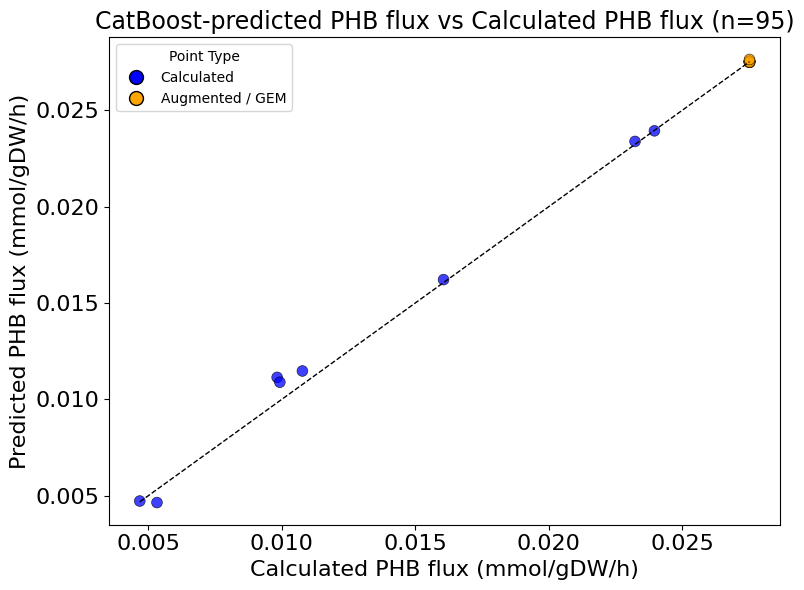

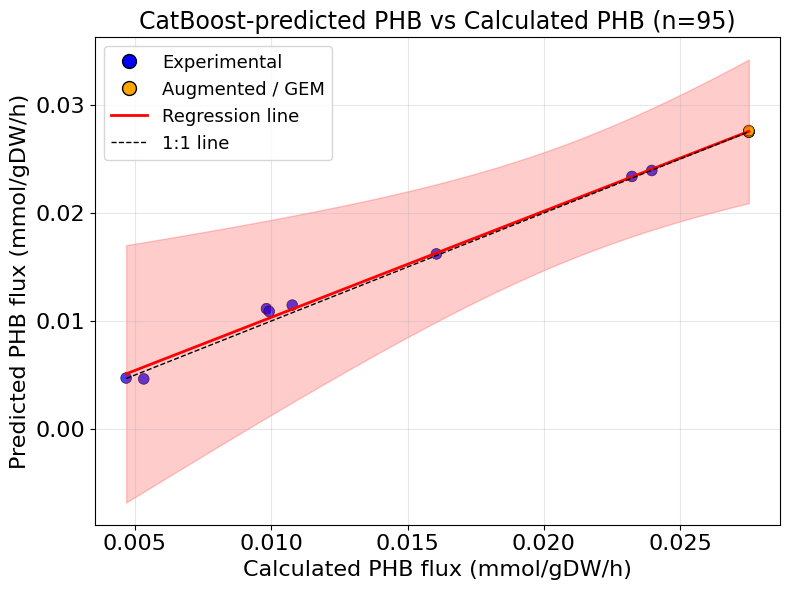

In [ ]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------------
df = pd.read_csv("Buitron2025_dataset_augmented_with_cost.csv")

# ---------------------------------------------------------
# 2. DEFINE TARGET AND FEATURES
# ---------------------------------------------------------
# Change this line if needed:
target_column = "PHB_exp_flux"   # or "PHB_mgL", depending on your goal

y = df[target_column]
X = df.drop(columns=[target_column])

# Use your feature lists directly:
cat_features = [
    'Type of substrate',
    'Illumination',
    'Levulinic acid',
    'Operation mode',
    'sub_rxn_id'
]


num_features = ['Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)', '% PHV',
                '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)',
                'Time (d)', 'g substrate COD/L', 'mg N/L', 'C/N (molar base)', 'mg ethanol/L',
                'Fraction mineral medium', ' g NaHCO3/L', 'Fe (mg Ferric citrate/L)',
                '% Volume exchange', 'Biomass_mgL', 'PHB_mgL', 'COD_gL_fed', 'biomass_gL',
                'PHB_exp_flux', 'Acetate_flux', 'Biomass_model_flux', 'Substrate_model_flux',
                'is_experimental', 'ac', 'fum', 'hxa', 'ppa', 'lac', 'but', 'succ',
                'C_total', 'N_total', 'C/N_ratio', 'total_uptake', 'total_cost']

# CatBoost pools
train_pool = Pool(X, y, cat_features=cat_features)

# ---------------------------------------------------------
# 3. TRAIN / TEST SPLIT
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_features)

# ---------------------------------------------------------
# 4. TRAIN MODEL
# ---------------------------------------------------------
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    verbose=100
)

model.fit(train_pool, eval_set=test_pool)

# ---------------------------------------------------------
# 5. PREDICT AND EVALUATE
# ---------------------------------------------------------
pred_test = model.predict(test_pool)

rmse = np.sqrt(mean_squared_error(y_test, pred_test))
r2   = r2_score(y_test, pred_test)

print(f"\nRMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


# ---------------------------------------------------------
# 6. SCATTER PLOT: Experimental vs Predicted PHB
# ---------------------------------------------------------

# Extract is_experimental for the test set
is_exp_test = X_test["is_experimental"].values

# Map 0 → orange , 1 → blue (or whatever colors you prefer)
color_map = {0: "orange", 1: "blue"}
colors = [color_map[val] for val in is_exp_test]

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred_test,
    c=colors,
    alpha=0.75,
     s=60,
    edgecolor="k",
    linewidth=0.5
)


n = len(df)
plt.xlabel("Calculated PHB flux (mmol/gDW/h)", fontsize=16)
plt.ylabel("Predicted PHB flux (mmol/gDW/h)", fontsize=16)
plt.title(f"CatBoost-predicted PHB flux vs Calculated PHB flux (n={n})", fontsize=17)


# Tick font size
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# identity line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--', lw=1
)


# Custom legend for the two classes
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Calculated',
           markerfacecolor='blue', markersize=10, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='Augmented / GEM',
           markerfacecolor='orange', markersize=10, markeredgecolor='k')
]

plt.legend(handles=legend_elements, title="Point Type")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 6b. SCATTER PLOT WITH REGRESSION + 95% CI
# ---------------------------------------------------------
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Colors for experimental vs GEM
color_map = {0: "orange", 1: "blue"}
colors = [color_map[val] for val in X_test["is_experimental"].values]

plt.figure(figsize=(8,6))

# Scatter points
plt.scatter(
    y_test,
    pred_test,
    c=colors,
    alpha=0.75,
    s=60,
    edgecolor="k",
    linewidth=0.5
)

# ----------------------------
# Regression + 95% CI
# ----------------------------
# Regression: predicted = a + b * calculated
slope, intercept, r_val, p_val, std_err = stats.linregress(y_test, pred_test)

# Points for regression line
x_line = np.linspace(y_test.min(), y_test.max(), 200)
y_line = intercept + slope * x_line

# 95% CI
n = len(y_test)
t_value = stats.t.ppf(1 - 0.025, df=n - 2)

# Standard error of prediction
pred_err = std_err * np.sqrt(
    1/n + (x_line - np.mean(y_test))**2 /
    np.sum((y_test - np.mean(y_test))**2)
)

y_upper = y_line + t_value * pred_err
y_lower = y_line - t_value * pred_err

# Plot regression line
plt.plot(x_line, y_line, color="red", lw=2, label="Regression line")

# Shade CI
plt.fill_between(
    x_line, y_lower, y_upper,
    color="red", alpha=0.2, label="95% CI"
)

# Identity line (perfect prediction)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--', lw=1, label="1:1 line"
)

# ----------------------------
# Labels & formatting
# ----------------------------
plt.xlabel("Calculated PHB flux (mmol/gDW/h)", fontsize=16)
plt.ylabel("Catboost predicted PHB flux (mmol/gDW/h)", fontsize=16)
plt.title(f"CatBoost-predicted PHB vs Calculated PHB (n={len(df)})", fontsize=17)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(alpha=0.3)

# Custom legend (experimental vs GEM)
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='Experimental', markerfacecolor='blue',
           markeredgecolor='k', markersize=10),
    Line2D([0], [0], marker='o', color='w',
           label='Augmented / GEM', markerfacecolor='orange',
           markeredgecolor='k', markersize=10),
    Line2D([], [], color='red', lw=2, label="Regression line"),
    Line2D([], [], color='k', lw=1, linestyle='--', label="1:1 line")
]
plt.legend(handles=legend_elements, fontsize=13)

plt.tight_layout()
plt.show()



## *Opt: catboost prediction for a new point


In [ ]:
new_point = {
    'Type of substrate': 'acetate',      # must be string
    'Illumination': 'continuous',        # string
    'Levulinic acid': 'no',              # string
    'Operation mode': 'batch',           # string
    'Substrate_type': 'ac',              # string
    'sub_rxn_id': 'r_ac_e',              # string

    # Example numerical values (yours will differ)
    'Experiment': 0,
    'Biomass (mg dw/L)': 300,
    'PHB (mg/L)': 0,
    '% PHB': 0,
    'PHV (mg/L)': 0,
    '% PHV': 0,
    '5-ALA (micromol/L)': 1.2,
    'Q10 (mg/g dw)': 5.1,
    'Carotenoids (mg/g dw)': 0.4,
    'Experiment.1': 0,
    'Time (d)': 3.0,
    'g substrate COD/L': 2.5,
    'mg N/L': 15,
    'C/N (molar base)': 18,
    'mg ethanol/L': 0,
    'Fraction mineral medium': 0.5,
    ' g NaHCO3/L': 1.0,
    'Fe (mg Ferric citrate/L)': 3.0,
    '% Volume exchange': 20,
    'Row': 1,
    'Biomass_mgL': 350,
    'PHB_mgL': 0,
    'COD_gL_fed': 3.0,
    'biomass_gL': 0.35,
    'PHB_exp_flux': 0.12,
    'Acetate_flux': 1.4,
    'Biomass_model_flux': 0.08,
    'Substrate_model_flux': 1.5,
    'is_experimental': 0,
    'ac': 1.0,
    'fum': 0.2,
    'hxa': 0.1,
    'ppa': 0.3,
    'lac': 0.0,
    'but': 0.1,
    'succ': 0.4,
    'C_total': 6.2,
    'N_total': 1.1,
    'C/N_ratio': 5.6,
    'total_uptake': 3.4,
    'total_cost': 5.1
}

# Build dataframe
new_df = pd.DataFrame([new_point])

# Convert categorical features to string
for c in cat_features:
    new_df[c] = new_df[c].astype(str)

pred_new = model.predict(new_df)[0]
print("Predicted PHB:", pred_new)


# *Catboost + Pareto

In [ ]:
df.columns

Index(['Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)',
       '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)',
       'Experiment.1', 'Time (d)', 'g substrate COD/L', 'Type of substrate',
       'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium',
       ' g NaHCO3/L', 'Illumination', 'Levulinic acid',
       'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange',
       'Row', 'Biomass_mgL', 'COD_gL_fed', 'Substrate_type', 'Time_h',
       'PHB_mgL', 'biomass_initial_gL', 'biomass_final_gL', 'biomass_eff_gL',
       'PHB_exp_flux', 'Substrate_exp_flux', 'sub_rxn_id', 'PHB_model_flux',
       'PHV_model_flux', '3HV_model_flux', 'PHBV_model_flux',
       'Biomass_model_flux', 'Substrate_model_flux', 'Top10_fluxes',
       'is_experimental', 'ac', 'fum', 'hxa', 'ppa', 'lac', 'but', 'succ',
       'C_total', 'N_total', 'C/N_ratio', 'total_uptake', 'total_cost'],
      dtype='object')

In [ ]:
df = pd.read_csv("Buitron2025_dataset_augmented_with_cost.csv")

# Keep ONLY rows where is_experimental == 1
df_gem = df[df["is_experimental"] == 0].copy()

print(df_exp.shape)
df_exp.head()
print(df_exp.columns)
df_exp[['% PHB', 'PHB_exp_flux','PHB (mg/L)', 'COD_gL_fed', 'PHBV_model_flux']]
#'ac', 'fum', 'hxa', 'ppa', 'lac', 'but', 'succ', '% PHB', 'PHB (mg/L)'

(31, 50)
Index(['Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)',
       '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)',
       'Experiment.1', 'Time (d)', 'g substrate COD/L', 'Type of substrate',
       'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium',
       ' g NaHCO3/L', 'Illumination', 'Levulinic acid',
       'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange',
       'Row', 'Biomass_mgL', 'COD_gL_fed', 'Substrate_type', 'Time_h',
       'PHB_mgL', 'biomass_initial_gL', 'biomass_final_gL', 'biomass_eff_gL',
       'PHB_exp_flux', 'Substrate_exp_flux', 'sub_rxn_id', 'PHB_model_flux',
       'PHV_model_flux', '3HV_model_flux', 'PHBV_model_flux',
       'Biomass_model_flux', 'Substrate_model_flux', 'Top10_fluxes',
       'is_experimental', 'ac', 'fum', 'hxa', 'ppa', 'lac', 'but', 'succ'],
      dtype='object')


,% PHB,PHB_exp_flux,PHB (mg/L),COD_gL_fed,PHBV_model_flux
1,6.04,0.005321,69.51,5.13,NaN
2,5.31,0.004161,54.00,5.13,NaN
3,5.46,0.005808,91.85,5.13,NaN
4,5.59,0.005923,93.18,5.13,NaN
5,4.08,0.004676,81.60,5.13,NaN
6,4.04,0.004693,83.51,5.13,NaN
7,4.14,0.004868,88.28,5.13,NaN
8,4.10,0.004777,85.40,5.13,NaN
9,9.60,0.015701,131.00,5.13,NaN
10,8.40,0.012210,99.00,5.13,NaN


This code is Catboost + pareto using the following features.

*  "acetate", "butyrate", "propionate", "lactate","succinate", "fumarate", "hexanoate", "C/N_ratio", "total_uptake", "total_cost"
*   Categorical variables:
    'Type of substrate',
    'Illumination',
    'Levulinic acid',
    'Operation mode',
    'Substrate_type',
    'sub_rxn_id'
*  This code can calculate back from PHB flux to % PHB with hard biomass assumptions that may not be realistic.




=== Columns in dataset ===
['Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)', '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', 'Time (d)', 'g substrate COD/L', 'Type of substrate', 'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium', ' g NaHCO3/L', 'Illumination', 'Levulinic acid', 'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange', 'Row', 'Biomass_mgL', 'COD_gL_fed', 'Substrate_type', 'Time_h', 'PHB_mgL', 'biomass_initial_gL', 'biomass_final_gL', 'biomass_eff_gL', 'PHB_exp_flux', 'Substrate_exp_flux', 'sub_rxn_id', 'PHB_model_flux', 'PHV_model_flux', '3HV_model_flux', 'PHBV_model_flux', 'Biomass_model_flux', 'Substrate_model_flux', 'is_experimental', 'ac', 'fum', 'hxa', 'ppa', 'lac', 'but', 'succ', 'C_total', 'N_total', 'C/N_ratio', 'total_uptake', 'total_cost']

=== Detected substrate columns ===
[]

=== Final feature columns ===
['C/N_ratio', 'total_uptake', 'total_cost']

=== Using com

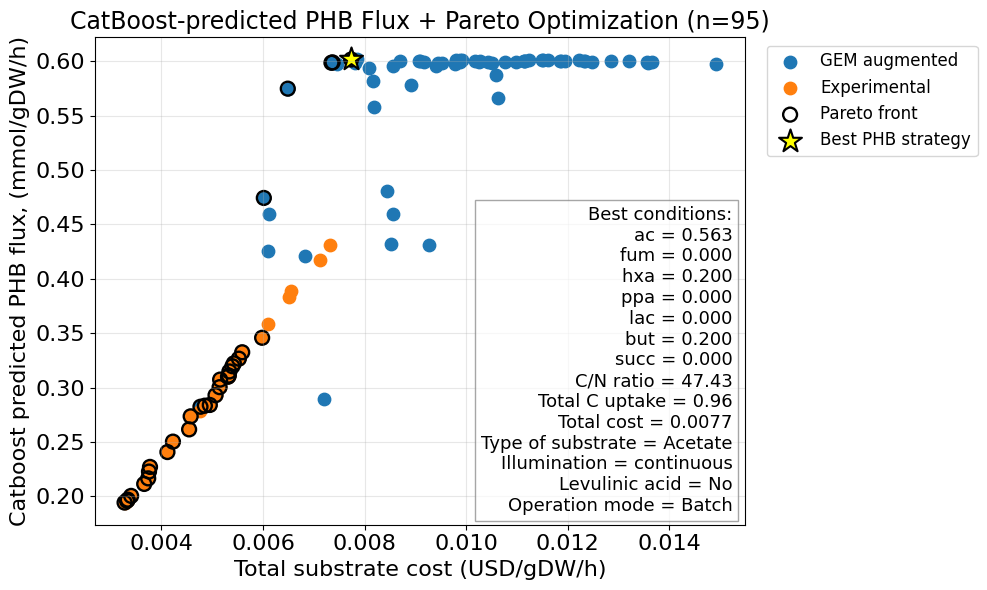

In [ ]:
# This version is convert predicted flux → PHB g/L and %PHB

from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


# =========================================================
# 1. Load data
# =========================================================
df = pd.read_csv("Buitron2025_dataset_augmented_with_cost.csv")

print("\n=== Columns in dataset ===")
print(df.columns.tolist())

# =========================================================
# 2. Detect substrate columns (robust search)
# =========================================================
possible_substrates = [
    "acetate", "butyrate", "propionate", "lactate",
    "succinate", "fumarate", "hexanoate"
]

substrates = []
for sub in possible_substrates:
    matches = [c for c in df.columns if sub.lower() in c.lower()]
    substrates.extend(matches)

print("\n=== Detected substrate columns ===")
print(substrates)

# =========================================================
# 3. Feature columns
# =========================================================
extra_features = ["C/N_ratio", "total_uptake", "total_cost"]
extra_features = [c for c in extra_features if c in df.columns]

feature_cols = substrates + extra_features
print("\n=== Final feature columns ===")
print(feature_cols)

target = "PHB_model_flux"
y = df[target]

print("\n=== Using combined PHB flux target ===")

# =========================================================
# 5. Features with categorical variables
# =========================================================
cat_features = [
    'Type of substrate',
    'Illumination',
    'Levulinic acid',
    'Operation mode'#,
    #'Substrate_type',
    #'sub_rxn_id'
]

existing_cat_features = [c for c in cat_features if c in df.columns]
print("\n=== Categorical features used ===")
print(existing_cat_features)

X = df[feature_cols + existing_cat_features]

# =========================================================
# 6. Train / Test split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_pool = Pool(X_train, y_train, cat_features=existing_cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=existing_cat_features)

# =========================================================
# 7. Train CatBoost surrogate
# =========================================================
model = CatBoostRegressor(
    iterations=600,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    verbose=100
)

model.fit(train_pool, eval_set=test_pool)

pred_test = model.predict(test_pool)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))
r2   = r2_score(y_test, pred_test)

print("\n=== CHECKPOINT 1: CatBoost Performance ===")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# =========================================================
# 8. Retrain on ALL data
# =========================================================
model.fit(Pool(X, y, cat_features=existing_cat_features))

df["PHB_pred_flux"] = model.predict(Pool(X, cat_features=existing_cat_features))

# =========================================================
# 9. 🔥 Convert predicted flux → PHB g/L and %PHB
# =========================================================
# Define constants (adjust to your experimental assumptions)
#MW_PHB = 86        # g/mol (3HB monomer)
#X_gDW_L = 1.0      # biomass concentration (gDW/L)
#t = 1.0            # hours (if flux is mmol/gDW/h)

# Convert from mmol/gDW/h → g/L
#df["PHB_pred_gL"] = df["PHB_pred_flux"] * X_gDW_L * (MW_PHB / 1000) * t

# Convert to %PHB (g PHB / gDW)
#df["PHB_pred_percent"] = (df["PHB_pred_flux"] * MW_PHB * t) * 100 / (1000 * 1)

# Export best solution
best_idx = df["PHB_pred_flux"].idxmax()
best_solution = df.loc[best_idx].to_frame().T
best_solution.to_csv("catboost_optimal_conditions.csv", index=False)

print("\n=== Best CatBoost predicted solution ===")
print(best_solution)

# =========================================================
# 10. Pareto Optimality
# =========================================================
def is_pareto_efficient(costs, maximize_cols=None):
    costs_adj = costs.copy()
    if maximize_cols:
        for col in maximize_cols:
            costs_adj[:, col] *= -1

    n = costs_adj.shape[0]
    is_efficient = np.ones(n, dtype=bool)

    for i in range(n):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(
                costs_adj[is_efficient] < costs_adj[i], axis=1
            )
            is_efficient[i] = True
    return is_efficient

objectives = df[["PHB_pred_flux", "total_cost", "Biomass_model_flux"]].to_numpy()

pareto_mask = is_pareto_efficient(objectives, maximize_cols=[0, 2])
pareto_solutions = df[pareto_mask]

print("\n=== CHECKPOINT 2: Pareto Solutions ===")
print(f"Number of Pareto-optimal strategies: {pareto_solutions.shape[0]}")

best_pareto_idx = pareto_solutions["PHB_pred_flux"].idxmax()
best_pareto = pareto_solutions.loc[best_pareto_idx]

print("\nBest Pareto solution:")
print(best_pareto)

pareto_solutions.to_csv("pareto_optimal_conditions.csv", index=False)

# =========================================================
# 11. PLOT — PHB flux vs cost
# =========================================================
COLOR_GEM  = "#1f77b4"
COLOR_EXP  = "#ff7f0e"
COLOR_BEST = "yellow"

plt.figure(figsize=(10,6))

if "is_experimental" in df.columns:
    gem_points = df[df["is_experimental"] == 0]
    plt.scatter(gem_points["total_cost"], gem_points["PHB_pred_flux"],
                color=COLOR_GEM, s=80, label="GEM augmented")

    exp_points = df[df["is_experimental"] == 1]
    plt.scatter(exp_points["total_cost"], exp_points["PHB_pred_flux"],
                color=COLOR_EXP, s=80,label="Experimental")

plt.scatter(
    pareto_solutions["total_cost"],
    pareto_solutions["PHB_pred_flux"],
    facecolors='none', edgecolors="black", s=100, linewidths=1.7,
    label="Pareto front"
)

plt.scatter(
    best_pareto["total_cost"],
    best_pareto["PHB_pred_flux"],
    color=COLOR_BEST, s=300, marker="*",
    edgecolors="black", linewidths=1.5, label="Best PHB strategy"
)


# Annotation
best_solution = df.loc[best_idx]   # Series

substrates = ['ac', 'fum', 'hxa', 'ppa', 'lac', 'but', 'succ']
print("Unique substrates:", substrates)

# =========================================================
# FIXED ANNOTATION BLOCK (NO STRING NEGATION)
# =========================================================

substrates = ['ac', 'fum', 'hxa', 'ppa', 'lac', 'but', 'succ']
existing_cat_features = [c for c in cat_features if c in df.columns]

annotation_lines = []

# --- numeric substrate uptakes (negate for GEM convention) ---
for col in substrates:
    if col in best_solution.index:
        annotation_lines.append(f"{col} = {-float(best_solution[col]):.3f}")

# --- continuous variables (numeric) ---
if "C/N_ratio" in best_solution:
    annotation_lines.append(f"C/N ratio = {-float(best_solution['C/N_ratio']):.2f}")

if "total_uptake" in best_solution:
    annotation_lines.append(f"Total C uptake = {-float(best_solution['total_uptake']):.2f}")

if "total_cost" in best_solution:
    annotation_lines.append(f"Total cost = {float(best_solution['total_cost']):.4f}")

# --- categorical variables (strings → DO NOT NEGATE) ---
for col in existing_cat_features:
    if col not in substrates:
        annotation_lines.append(f"{col} = {best_solution[col]}")

# assemble text
feature_text = "Best conditions:\n" + "\n".join(annotation_lines)


plt.annotate(
    feature_text,
    xy=(0.98, 0.02),
    xycoords='axes fraction',
    fontsize=13,
    ha='right',
    va='bottom',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7)
)


plt.xlabel("Total substrate cost (USD/gDW/h)", fontsize=16)
plt.ylabel("Catboost predicted PHB flux, (mmol/gDW/h)", fontsize=16)
plt.title(
    f"CatBoost-predicted PHB Flux + Pareto Optimization (n={len(df)})",
    fontsize=17
)

plt.grid(True, alpha=0.3)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(loc="upper left", bbox_to_anchor=(1.02,1), fontsize=12)
plt.tight_layout()
plt.savefig("PHB_catboost_pareto_plot.png", dpi=300, bbox_inches="tight")
plt.show()


## pFBA vs FBA Wordcloud (significant reactions)

significant_reactions_succ ATPM       0.000050
ACS       -0.000025
ADK1      -0.000025
PCXHtpp    0.000025
PPA_1pp   -0.000025
ACOAH      0.000025
Name: fluxes, dtype: float64
Number of significant reactions: 6


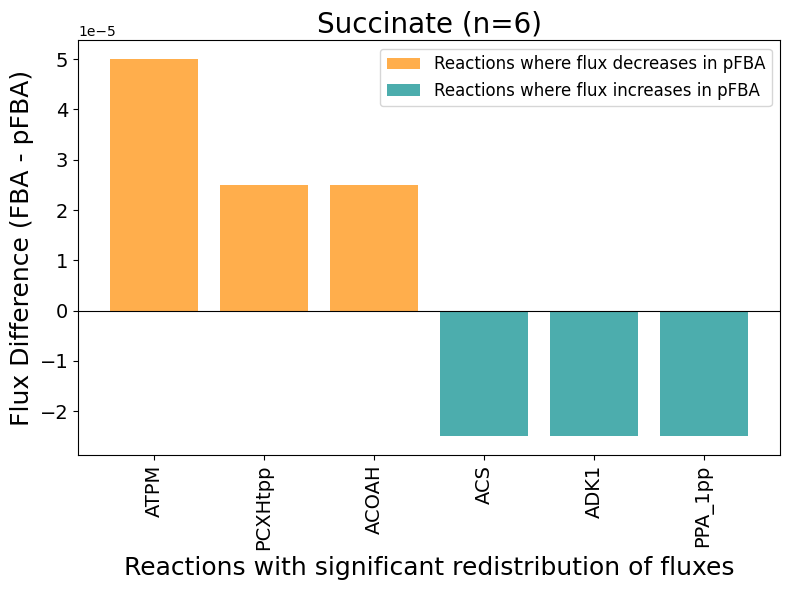

  Reaction ID                                      Reaction Name
0        ATPM                        ATP maintenance requirement
1         ACS                              Acetyl-CoA synthetase
2        ADK1                                   Adenylate kinase
3     PCXHtpp                                     H+ export PcxA
4     PPA_1pp  Inorganic diphosphatase (one proton translocat...


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cobra.flux_analysis import pfba

# Perform pFBA on the model
pfba_solution_succ = pfba(model_acetate1)

# Standard FBA solution for comparison
solution_succ = model_acetate1.optimize()

# Compute the flux difference (without absolute value)
flux_diff_succ = solution_succ.fluxes - pfba_solution_succ.fluxes
flux_diff_succ = pd.Series(flux_diff_succ)  # Ensure it's a Pandas Series

# Print some statistics to debug
#print("Flux Difference Summary:")
#print(flux_diff_succ.describe())

# Set a lower threshold to capture more reactions
threshold = 0.00001
significant_reactions_succ = flux_diff_succ[abs(flux_diff_succ) > threshold]
print('significant_reactions_succ', significant_reactions_succ)

# Print count of significant reactions
print(f"Number of significant reactions: {len(significant_reactions_succ)}")

# Separate reactions into those that decreased (FBA > pFBA) and those that increased (FBA < pFBA)
reactions_fba_succ = significant_reactions_succ[significant_reactions_succ > 0]  # Red, going downward
reactions_pfba_succ = significant_reactions_succ[significant_reactions_succ < 0]  # Blue, going upward

# Ensure we have data to plot
if len(significant_reactions_succ) > 0:
    # Plot significant flux changes
    plt.figure(figsize=(8, 6))

    # Plot FBA fluxes (negative direction)
    plt.bar(reactions_fba_succ.index, reactions_fba_succ.values, color="darkorange", label="Reactions where flux decreases in pFBA", alpha=0.7)

    # Plot pFBA fluxes (positive direction)
    plt.bar(reactions_pfba_succ.index, reactions_pfba_succ.values, color="darkcyan", label="Reactions where flux increases in pFBA", alpha=0.7)

    plt.xlabel("Reactions with significant redistribution of fluxes", size= 18)
    plt.ylabel("Flux Difference (FBA - pFBA)", size= 18)
    plt.title(f"(n={len(significant_reactions_succ)})", fontsize=20)
    plt.xticks(rotation=90, fontsize=14)
    plt.yticks(fontsize=14)  # Increase y-axis font size
    plt.axhline(0, color='black', linewidth=0.8)
    # Add legend
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.savefig("flux_comparison_succ.pdf", format="pdf", bbox_inches="tight")

    plt.show()
else:
    print("No significant flux changes found. Try lowering the threshold.")

import pandas as pd

# Create a list to store reaction details
reaction_details = []

# Loop through each significant reaction
for rxn_id in significant_reactions_succ.index:
    reaction = model_acetate1.reactions.get_by_id(rxn_id)
    reaction_details.append({
        "Reaction ID": rxn_id,
        "Reaction Name": reaction.name

    })

#"Reaction ID": rxn_id,
#"Reaction Name": reaction.name,
#"Equation": reaction.reaction,
#"Subsystem": reaction.subsystem,
#"Flux Difference": significant_reactions_succ[rxn_id]

# Convert to DataFrame
reaction_df = pd.DataFrame(reaction_details)

# Display the first few rows
print(reaction_df.head())

# Save to CSV for further analysis
reaction_df.to_excel("pFBA_vs_FBA_reactions_withsignificant_differrences.xlsx", index=False) # export to consult with chatgpt

# *Catboost + PSO

Particle Swarm Optimization is not the best optimization method in combination with GEM (which optimizes the flux) for this since focuses in 1 objective at the time and of course it finds the highest GEM flux values



Loaded columns:
['Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)', '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', 'Time (d)', 'g substrate COD/L', 'Type of substrate', 'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium', ' g NaHCO3/L', 'Illumination', 'Levulinic acid', 'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange', 'Row', 'Biomass_mgL', 'COD_gL_fed', 'Substrate_type', 'Time_h', 'PHB_mgL', 'biomass_initial_gL', 'biomass_final_gL', 'biomass_eff_gL', 'PHB_exp_flux', 'Substrate_exp_flux', 'sub_rxn_id', 'PHB_model_flux', 'PHV_model_flux', '3HV_model_flux', 'PHBV_model_flux', 'Biomass_model_flux', 'Substrate_model_flux', 'is_experimental', 'ac', 'fum', 'hxa', 'ppa', 'lac', 'but', 'succ', 'C_total', 'N_total', 'C/N_ratio', 'total_uptake', 'total_cost']

Detected substrate columns: ['Fraction mineral medium', 'Levulinic acid', 'ac', 'lac', 'fum', 'hxa', 'ppa', 'but', 'succ']
Extra numeric f

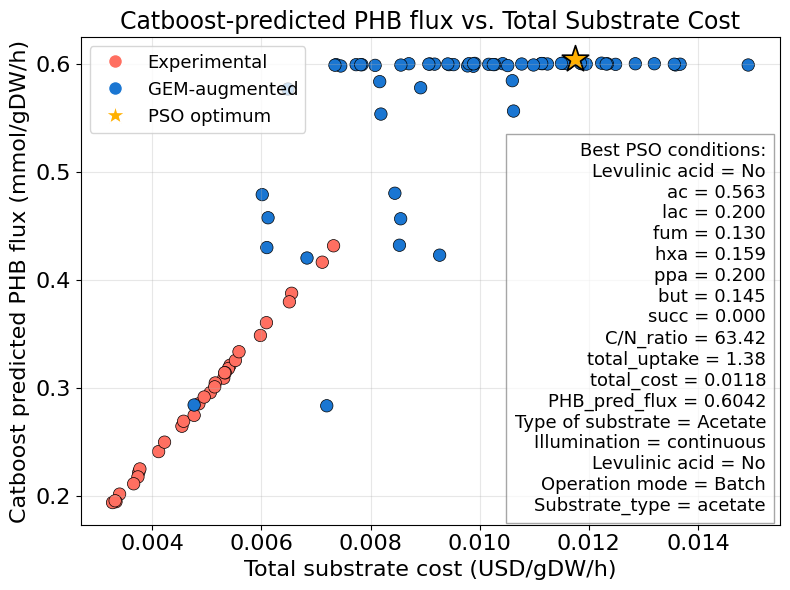

In [ ]:
# Full fixed pipeline: CatBoost surrogate + numeric-only PSO + PHB conversions + CSV output
# Includes R2, Pearson, RMSE, MAPE evaluations
# Usage: place in same folder as your CSV and run.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr, stats
import random
import os

# -------------------------
# USER CONFIG
# -------------------------
CSV_PATH = "Buitron2025_dataset_augmented_with_cost.csv"
TARGET_COL = "PHB_model_flux"
SAVE_PSO_CSV = "catboost_pso_optimal_conditions.csv"
RANDOM_SEED = 42

# PHB conversion assumptions
MW_PHB = 86.0       # g/mol (3HB monomer)
X_gDW_L = 1.0       # biomass concentration (gDW/L)
t_h = 1.0           # integration time (h)

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# -------------------------
# 1) Load & clean
# -------------------------
df = pd.read_csv(CSV_PATH)

# Remove duplicate columns
if df.columns.duplicated().any():
    print("Warning: duplicate columns detected. Removing duplicates.")
    df = df.loc[:, ~df.columns.duplicated()]

print("\nLoaded columns:")
print(df.columns.tolist())

if TARGET_COL not in df.columns:
    raise KeyError(f"Target column '{TARGET_COL}' not in CSV.")

# -------------------------
# 2) Detect substrate columns
# -------------------------
substrates = ['ac', 'fum', 'hxa', 'ppa', 'lac', 'but', 'succ']

detected_substrates = []
for sub in substrates:
    matches = [c for c in df.columns if sub.lower() in c.lower()]
    detected_substrates.extend(matches)
detected_substrates = list(dict.fromkeys(detected_substrates))
print("\nDetected substrate columns:", detected_substrates)

# -------------------------
# 3) Extra numeric features
# -------------------------
extra_numeric_features = ["C/N_ratio", "total_uptake", "total_cost"]
extra_numeric_features = [c for c in extra_numeric_features if c in df.columns]
print("Extra numeric features:", extra_numeric_features)

# Combine candidate numeric columns, **remove 'Levulinic acid'**
candidate_numeric = detected_substrates + extra_numeric_features
candidate_numeric = [c for c in candidate_numeric if c in df.columns]
candidate_numeric.remove('Levulinic acid')
print("Candidate numeric columns:", candidate_numeric)

# -------------------------
# 4) Detect categorical columns
# -------------------------
predefined_cat_features = [
    'Type of substrate', 'Illumination', 'Levulinic acid',
    'Operation mode', 'Substrate_type'
]
predefined_cat_features = [c for c in predefined_cat_features if c in df.columns]

inferred_cat_features = [c for c in df.columns if df[c].dtype == "object" and c != TARGET_COL]

cat_features = []
for c in predefined_cat_features + inferred_cat_features:
    if c not in cat_features:
        cat_features.append(c)

print("Categorical columns:", cat_features)

# Convert categorical columns to string
for col in cat_features:
    df[col] = df[col].astype(str)

# -------------------------
# 5) Build training features
# -------------------------
features_for_training = candidate_numeric + [c for c in cat_features if c not in candidate_numeric]
if TARGET_COL in features_for_training:
    features_for_training.remove(TARGET_COL)

X = df[features_for_training].copy()
y = df[TARGET_COL].copy()

# Coerce numeric
for col in X.columns:
    if col not in cat_features:
        X[col] = pd.to_numeric(X[col], errors="coerce")

# Drop rows with NaNs
mask = ~X.isna().any(axis=1) & ~y.isna()
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)
df = df.loc[mask].reset_index(drop=True)

# -------------------------
# 6) Train/test split + CatBoost
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print("\nTraining CatBoost surrogate...")
model = CatBoostRegressor(
    iterations=600,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    verbose=100
)
model.fit(X_train, y_train, eval_set=(X_test, y_test), cat_features=cat_features)

# -------------------------
# 6b) Model performance metrics
# -------------------------
pred_test = model.predict(X_test)
rmse = mean_squared_error(y_test, pred_test)**0.5
r2 = r2_score(y_test, pred_test)
pearson_r, pearson_p = pearsonr(y_test, pred_test)
y_test_nonzero = np.where(y_test == 0, np.nan, y_test)
mape = np.nanmean(np.abs((y_test_nonzero - pred_test) / y_test_nonzero)) * 100

print(f"\nRMSE: {rmse:.6f}, R²: {r2:.6f}, Pearson R: {pearson_r:.6f}, MAPE: {mape:.3f}%")

# Retrain on full dataset
model.fit(X, y, cat_features=cat_features)
df["PHB_pred_flux"] = model.predict(X)

# -------------------------
# 7) PSO (numeric-only)
# -------------------------
numeric_cols = candidate_numeric.copy()  # ensure substrates + extra numeric features
fixed_cat_values = {c: df[c].mode().iloc[0] for c in cat_features}

lb = np.array([df[c].min() for c in numeric_cols], dtype=float)
ub = np.array([df[c].max() for c in numeric_cols], dtype=float)

n_particles = 40
n_iterations = 80
w, c1, c2 = 0.7, 1.5, 1.5
dim = len(numeric_cols)

particles = np.random.uniform(lb, ub, size=(n_particles, dim))
vel = np.zeros_like(particles)

def pso_objective_numeric(v):
    row = {c: float(v[i]) for i, c in enumerate(numeric_cols)}  # now guaranteed numeric
    row.update(fixed_cat_values)
    # Fill remaining features
    for feat in features_for_training:
        if feat not in row:
            if feat in cat_features:
                row[feat] = df[feat].mode().iloc[0]
            else:
                row[feat] = df[feat].median()
    sample = pd.DataFrame([row], columns=features_for_training)
    return -model.predict(sample)[0]


pbest = particles.copy()
pbest_vals = np.array([pso_objective_numeric(p) for p in particles])
gbest = pbest[pbest_vals.argmin()].copy()
gbest_val = pbest_vals.min()

for it in range(n_iterations):
    for i in range(n_particles):
        r1, r2 = np.random.rand(dim), np.random.rand(dim)
        vel[i] = w*vel[i] + c1*r1*(pbest[i]-particles[i]) + c2*r2*(gbest-particles[i])
        particles[i] = np.clip(particles[i]+vel[i], lb, ub)
        val = pso_objective_numeric(particles[i])
        if val < pbest_vals[i]:
            pbest[i], pbest_vals[i] = particles[i].copy(), val
            if val < gbest_val:
                gbest, gbest_val = particles[i].copy(), val

# -------------------------
# 8) Build best PSO solution
# -------------------------
best_row = {c: float(gbest[i]) for i, c in enumerate(numeric_cols)}
best_row.update(fixed_cat_values)

for feat in features_for_training:
    if feat not in best_row:
        best_row[feat] = df[feat].mode().iloc[0] if feat in cat_features else df[feat].median()

best_df = pd.DataFrame([best_row])
best_df["PHB_pred_flux"] = model.predict(best_df)[0]
best_df["PHB_pred_gL"] = best_df["PHB_pred_flux"] * X_gDW_L * (MW_PHB/1000) * t_h
best_df["PHB_pred_percent"] = best_df["PHB_pred_flux"] * (MW_PHB/1000) * 100 * t_h

best_df.to_csv(SAVE_PSO_CSV, index=False)
print("\nSaved PSO optimal conditions to:", SAVE_PSO_CSV)
print("\nBest solution:")
print(best_df.T)

# -------------------------
# 9) Final plot: Predicted PHB flux vs Total Cost
# -------------------------


COLOR_EXP, COLOR_GEM, COLOR_PSO = "#FF6F61", "#1A76D2", "#FFB000"
pso_cost, pso_phb = best_df["total_cost"].iloc[0], best_df["PHB_pred_flux"].iloc[0]

plt.figure(figsize=(8,6))
plt.scatter(df["total_cost"], df["PHB_pred_flux"],
            c=df["is_experimental"].map({1: COLOR_EXP, 0: COLOR_GEM}), s=80, edgecolor="k", linewidth=0.5)
plt.scatter(pso_cost, pso_phb, marker="*", color=COLOR_PSO, s=400, edgecolor="k", linewidth=1.2)
plt.xlabel("Total substrate cost (USD/gDW/h)", fontsize=16)
plt.ylabel("Catboost predicted PHB flux (mmol/gDW/h)", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title("Catboost-predicted PHB flux vs. Total Substrate Cost", fontsize=17)
plt.grid(alpha=0.3)
plt.legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_EXP, markersize=10, label="Experimental"),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_GEM, markersize=10, label="GEM-augmented"),
    plt.Line2D([0],[0], marker='*', color='w', markerfacecolor=COLOR_PSO, markersize=15, label="PSO optimum")
], fontsize=13, loc="upper left")

# -------------------------
# Annotate PSO optimal solution with selected features
# -------------------------
exclude_features = ['sub_rxn_id', 'Fraction mineral medium']  # features to skip

feature_text_lines = ["Best PSO conditions:"]

# Add numeric substrates
for col in detected_substrates:
    if col in best_df.columns and col not in exclude_features:
        val = best_df[col].iloc[0]
        if np.issubdtype(type(val), np.number):
            val = -val
        feature_text_lines.append(f"{col} = {val:.3f}" if isinstance(val, (int, float)) else f"{col} = {val}")

# Add extra numeric features
extra_numeric = ['C/N_ratio', 'total_uptake', 'total_cost', 'PHB_pred_flux']
for col in extra_numeric:
    if col in best_df.columns and col not in exclude_features:
        val = best_df[col].iloc[0]
        if col not in ['total_cost', 'PHB_pred_flux'] and np.issubdtype(type(val), np.number):
            val = -val
        feature_text_lines.append(
            f"{col} = {val:.2f}" if isinstance(val, (int, float)) and col not in ['total_cost', 'PHB_pred_flux']
            else f"{col} = {val:.4f}"
        )

# Add categorical features
for col in cat_features:
    if col in best_df.columns and col not in exclude_features:
        val = best_df[col].iloc[0]
        feature_text_lines.append(f"{col} = {val}")

# Combine into a single string
feature_text = "\n".join(feature_text_lines)

# Add to plot
plt.annotate(feature_text, xy=(0.98, 0.02), xycoords='axes fraction',
             fontsize=13, ha='right', va='bottom',
             bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7, pad=6))

plt.tight_layout()
plt.savefig("catboost_predPHB_vs_cost_pso_annotated.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
df['ac']

,ac
0,0.536571
1,0.540198
2,0.443257
3,0.445583
4,0.401708
...,...
90,-0.562970
91,-0.562970
92,-0.562970
93,-0.562970


# *Catboost + Gradient Descent

Buitron 2025 uses gradient descent (not pareto). Advantages?

In [ ]:
CSV = "Buitron2025_dataset_augmented_with_cost.csv"
df = pd.read_csv(CSV)

df['PHB_model_flux'].max()

0.6


Loaded columns:
['Experiment', 'Biomass (mg dw/L)', 'PHB (mg/L)', '% PHB', 'PHV (mg/L)', '% PHV', '5-ALA (micromol/L)', 'Q10 (mg/g dw)', 'Carotenoids (mg/g dw)', 'Experiment.1', 'Time (d)', 'g substrate COD/L', 'Type of substrate', 'mg N/L', 'C/N (molar base)', 'mg ethanol/L', 'Fraction mineral medium', ' g NaHCO3/L', 'Illumination', 'Levulinic acid', 'Fe (mg Ferric citrate/L)', 'Operation mode', '% Volume exchange', 'Row', 'Biomass_mgL', 'COD_gL_fed', 'Substrate_type', 'Time_h', 'PHB_mgL', 'biomass_initial_gL', 'biomass_final_gL', 'biomass_eff_gL', 'PHB_exp_flux', 'Substrate_exp_flux', 'sub_rxn_id', 'PHB_model_flux', 'PHV_model_flux', '3HV_model_flux', 'PHBV_model_flux', 'Biomass_model_flux', 'Substrate_model_flux', 'is_experimental', 'ac', 'fum', 'hxa', 'ppa', 'lac', 'but', 'succ', 'C_total', 'N_total', 'C/N_ratio', 'total_uptake', 'total_cost']

Detected substrate columns: ['Fraction mineral medium', 'Levulinic acid', 'ac', 'lac', 'fum', 'hxa', 'ppa', 'but', 'succ']
Extra numeric f

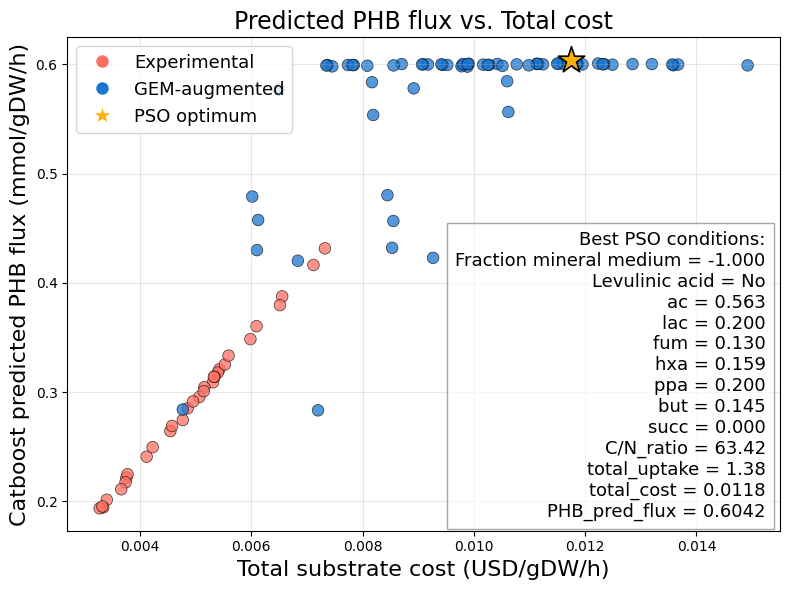

In [ ]:
# Full fixed pipeline: CatBoost surrogate + numeric-only PSO + PHB conversions + CSV output
# Includes R2, Pearson, RMSE, MAPE evaluations
# Usage: place in same folder as your CSV and run.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr, stats
import random

# -------------------------
# USER CONFIG
# -------------------------
CSV_PATH = "Buitron2025_dataset_augmented_with_cost.csv"
TARGET_COL = "PHB_model_flux"
SAVE_PSO_CSV = "catboost_pso_optimal_conditions.csv"
RANDOM_SEED = 42

# PHB conversion assumptions
MW_PHB = 86.0       # g/mol (3HB monomer)
X_gDW_L = 1.0       # biomass concentration (gDW/L)
t_h = 1.0           # integration time (h)

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# -------------------------
# 1) Load & clean
# -------------------------
df = pd.read_csv(CSV_PATH)

# Remove duplicate columns
if df.columns.duplicated().any():
    print("Warning: duplicate columns detected. Removing duplicates.")
    df = df.loc[:, ~df.columns.duplicated()]

print("\nLoaded columns:")
print(df.columns.tolist())

if TARGET_COL not in df.columns:
    raise KeyError(f"Target column '{TARGET_COL}' not in CSV.")

# -------------------------
# 2) Detect substrate columns
# -------------------------
substrates = ['ac', 'fum', 'hxa', 'ppa', 'lac', 'but', 'succ']

detected_substrates = []
for sub in substrates:
    matches = [c for c in df.columns if sub.lower() in c.lower()]
    detected_substrates.extend(matches)
detected_substrates = list(dict.fromkeys(detected_substrates))
print("\nDetected substrate columns:", detected_substrates)

# -------------------------
# 3) Extra numeric features
# -------------------------
extra_numeric_features = ["C/N_ratio", "total_uptake", "total_cost"]
extra_numeric_features = [c for c in extra_numeric_features if c in df.columns]
print("Extra numeric features:", extra_numeric_features)

# Combine candidate numeric columns, remove 'Levulinic acid'
candidate_numeric = detected_substrates + extra_numeric_features
candidate_numeric = [c for c in candidate_numeric if c in df.columns and c != 'Levulinic acid']
print("Candidate numeric columns:", candidate_numeric)

# -------------------------
# 4) Detect categorical columns
# -------------------------
predefined_cat_features = [
    'Type of substrate', 'Illumination', 'Levulinic acid',
    'Operation mode', 'Substrate_type'
]
predefined_cat_features = [c for c in predefined_cat_features if c in df.columns]

inferred_cat_features = [c for c in df.columns if df[c].dtype == "object" and c != TARGET_COL]

cat_features = []
for c in predefined_cat_features + inferred_cat_features:
    if c not in cat_features:
        cat_features.append(c)

print("Categorical columns:", cat_features)

# Convert categorical columns to string
for col in cat_features:
    df[col] = df[col].astype(str)

# -------------------------
# 5) Build training features
# -------------------------
features_for_training = candidate_numeric + [c for c in cat_features if c not in candidate_numeric]
if TARGET_COL in features_for_training:
    features_for_training.remove(TARGET_COL)

X = df[features_for_training].copy()
y = df[TARGET_COL].copy()

# Coerce numeric
for col in X.columns:
    if col not in cat_features:
        X[col] = pd.to_numeric(X[col], errors="coerce")

# Drop rows with NaNs
mask = ~X.isna().any(axis=1) & ~y.isna()
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)
df = df.loc[mask].reset_index(drop=True)

# -------------------------
# 6) Train/test split + CatBoost
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print("\nTraining CatBoost surrogate...")
model = CatBoostRegressor(
    iterations=600,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    verbose=100
)
model.fit(X_train, y_train, eval_set=(X_test, y_test), cat_features=cat_features)

# -------------------------
# 6b) Model performance metrics
# -------------------------
pred_test = model.predict(X_test)
rmse = mean_squared_error(y_test, pred_test)**0.5
r2 = r2_score(y_test, pred_test)
pearson_r, pearson_p = pearsonr(y_test, pred_test)
y_test_nonzero = np.where(y_test == 0, np.nan, y_test)
mape = np.nanmean(np.abs((y_test_nonzero - pred_test) / y_test_nonzero)) * 100

print(f"\nRMSE: {rmse:.6f}, R²: {r2:.6f}, Pearson R: {pearson_r:.6f}, MAPE: {mape:.3f}%")

# Retrain on full dataset
model.fit(X, y, cat_features=cat_features)
df["PHB_pred_flux"] = model.predict(X)

# -------------------------
# 7) PSO (numeric-only)
# -------------------------
numeric_cols = candidate_numeric.copy()  # ensure substrates + extra numeric features
fixed_cat_values = {c: df[c].mode().iloc[0] for c in cat_features}

lb = np.array([df[c].min() for c in numeric_cols], dtype=float)
ub = np.array([df[c].max() for c in numeric_cols], dtype=float)

n_particles = 40
n_iterations = 80
w, c1, c2 = 0.7, 1.5, 1.5
dim = len(numeric_cols)

particles = np.random.uniform(lb, ub, size=(n_particles, dim))
vel = np.zeros_like(particles)

def pso_objective_numeric(v):
    row = {c: float(v[i]) for i, c in enumerate(numeric_cols)}
    row.update(fixed_cat_values)
    # Fill remaining features
    for feat in features_for_training:
        if feat not in row:
            if feat in cat_features:
                row[feat] = df[feat].mode().iloc[0]
            else:
                row[feat] = df[feat].median()
    sample = pd.DataFrame([row], columns=features_for_training)
    return -model.predict(sample)[0]

pbest = particles.copy()
pbest_vals = np.array([pso_objective_numeric(p) for p in particles])
gbest = pbest[pbest_vals.argmin()].copy()
gbest_val = pbest_vals.min()

for it in range(n_iterations):
    for i in range(n_particles):
        r1, r2 = np.random.rand(dim), np.random.rand(dim)
        vel[i] = w*vel[i] + c1*r1*(pbest[i]-particles[i]) + c2*r2*(gbest-particles[i])
        particles[i] = np.clip(particles[i]+vel[i], lb, ub)
        val = pso_objective_numeric(particles[i])
        if val < pbest_vals[i]:
            pbest[i], pbest_vals[i] = particles[i].copy(), val
            if val < gbest_val:
                gbest, gbest_val = particles[i].copy(), val

# -------------------------
# 8) Build best PSO solution
# -------------------------
best_row = {c: float(gbest[i]) for i, c in enumerate(numeric_cols)}
best_row.update(fixed_cat_values)

for feat in features_for_training:
    if feat not in best_row:
        best_row[feat] = df[feat].mode().iloc[0] if feat in cat_features else df[feat].median()

best_df = pd.DataFrame([best_row])
best_df["PHB_pred_flux"] = model.predict(best_df)[0]
best_df["PHB_pred_gL"] = best_df["PHB_pred_flux"] * X_gDW_L * (MW_PHB/1000) * t_h
best_df["PHB_pred_percent"] = best_df["PHB_pred_flux"] * (MW_PHB/1000) * 100 * t_h

best_df.to_csv(SAVE_PSO_CSV, index=False)
print("\nSaved PSO optimal conditions to:", SAVE_PSO_CSV)
print("\nBest solution:")
print(best_df.T)

# -------------------------
# 9) Final plot: Predicted PHB flux vs Total Cost
# -------------------------
COLOR_EXP, COLOR_GEM, COLOR_PSO = "#FF6F61", "#1A76D2", "#FFB000"
pso_cost, pso_phb = best_df["total_cost"].iloc[0], best_df["PHB_pred_flux"].iloc[0]

plt.figure(figsize=(8,6))
plt.scatter(df["total_cost"], df["PHB_pred_flux"],
            c=df["is_experimental"].map({1: COLOR_EXP, 0: COLOR_GEM}),
            alpha=0.75, s=70, edgecolor="k", linewidth=0.5)
plt.scatter(pso_cost, pso_phb, marker="*", color=COLOR_PSO, s=400, edgecolor="k", linewidth=1.2)
plt.xlabel("Total substrate cost (USD/gDW/h)", fontsize=16)
plt.ylabel("Catboost predicted PHB flux (mmol/gDW/h)", fontsize=16)
plt.title("Predicted PHB flux vs. Total cost", fontsize=17)
plt.grid(alpha=0.3)
plt.legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_EXP, markersize=10, label="Experimental"),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_GEM, markersize=10, label="GEM-augmented"),
    plt.Line2D([0],[0], marker='*', color='w', markerfacecolor=COLOR_PSO, markersize=15, label="PSO optimum")
], fontsize=13, loc="upper left")

# Annotate PSO optimal solution with substrates + numeric features
feature_text_lines = ["Best PSO conditions:"]
for col in detected_substrates:
    if col in best_df.columns:
        val = best_df[col].iloc[0]
        # Only negate numeric
        if np.issubdtype(type(val), np.number):
            val = -val
        feature_text_lines.append(f"{col} = {val:.3f}" if isinstance(val, (int, float)) else f"{col} = {val}")

extra_numeric = ['C/N_ratio', 'total_uptake', 'total_cost', 'PHB_pred_flux']
for col in extra_numeric:
    if col in best_df.columns:
        val = best_df[col].iloc[0]
        if col not in ['total_cost', 'PHB_pred_flux'] and np.issubdtype(type(val), np.number):
            val = -val
        feature_text_lines.append(
            f"{col} = {val:.2f}" if isinstance(val, (int, float)) and col not in ['total_cost', 'PHB_pred_flux']
            else f"{col} = {val:.4f}"
        )
feature_text = "\n".join(feature_text_lines)

plt.annotate(feature_text, xy=(0.98,0.02), xycoords='axes fraction', fontsize=13,
             ha='right', va='bottom', bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7, pad=6))

plt.tight_layout()
plt.savefig("catboost_predPHB_vs_cost_pso_annotated.png", dpi=300, bbox_inches="tight")
plt.show()


## FINISH!!!

I reached upt to here for R. palustis




In [ ]:
import numpy as np

# Compare solutions FBA and pFBA solutions
from cobra.flux_analysis import pfba

pfba_solution_gluc = pfba(model_gluc.copy())

# Compare FBA vs. pFBA flux distribution
#print("FBA solution:", solution_glucose.fluxes.head(10))
#print("pFBA solution:", pfba_solution_gluc.fluxes.head(10))

# Compare total flux investment
fba_flux_sum_gluc = sum(abs(v) for v in solution_glucose.fluxes)
pfba_flux_sum_gluc = sum(abs(v) for v in pfba_solution_gluc.fluxes)
print(f"Total metabolic flux investment in FBA_gluc: {fba_flux_sum_gluc}")
print(f"Total metabolic flux investment in pFBAgluc: {pfba_flux_sum_gluc}")

pfba_solution_succ = pfba(model_succ.copy())

# Compare FBA vs. pFBA flux distribution
#print("FBA solution:", solution_succinate.fluxes.head(10))
#print("pFBA solution:", pfba_solution_succ.fluxes.head(10))

# Compare total flux investment
fba_flux_sum_succ = sum(abs(v) for v in solution_succinate.fluxes)
pfba_flux_sum_succ = sum(abs(v) for v in pfba_solution_succ.fluxes)
print(f"Total metabolic flux investment in FBA_succ: {fba_flux_sum_succ}")
print(f"Total metabolic flux investment in pFBA: {pfba_flux_sum_succ}")


Total metabolic flux investment in FBA_gluc: 1285.1574453442672
Total metabolic flux investment in pFBAgluc: 1258.0243535032575
Total metabolic flux investment in FBA_succ: 775.8702343584249
Total metabolic flux investment in pFBA: 757.2871251515832


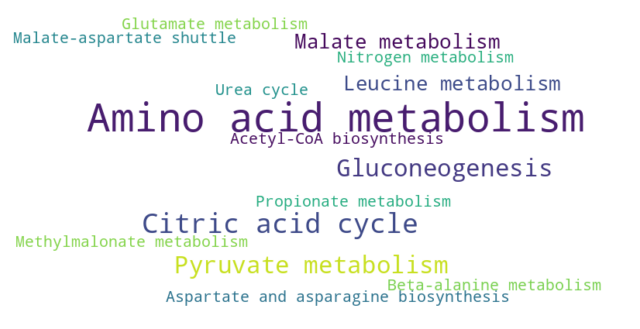

In [ ]:
pathways_succ = [
    "Amino acid metabolism", "Amino acid metabolism", "Amino acid metabolism", "Amino acid metabolism",
    "Gluconeogenesis", "Pyruvate metabolism", "Amino acid metabolism", "Aspartate and asparagine biosynthesis",
    "Amino acid metabolism", "Gluconeogenesis", "Urea cycle", "Citric acid cycle", "Amino acid metabolism",
    "Beta-alanine metabolism", "Pyruvate metabolism", "Amino acid metabolism", "Glutamate metabolism",
    "Nitrogen metabolism", "Amino acid metabolism", "Leucine metabolism", "Amino acid metabolism",
    "Leucine metabolism", "Citric acid cycle", "Malate-aspartate shuttle", "Amino acid metabolism",
    "Malate metabolism", "Citric acid cycle", "Gluconeogenesis", "Malate metabolism", "Propionate metabolism",
    "Methylmalonate metabolism", "Citric acid cycle", "Pyruvate metabolism", "Acetyl-CoA biosynthesis"
]

# Create a frequency dictionary for the pathways
pathway_freq = {pathway: pathways_succ.count(pathway) for pathway in set(pathways_succ)}

# Generate the word cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(pathway_freq)

# Display the word cloud
plt.figure(figsize=(8, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.savefig("wordcloud_pathways_succinate2.pdf", format="pdf", bbox_inches="tight")

plt.show()


In [ ]:
pfba_solution_succ


,fluxes,reduced_costs
DM_26dap__M_c,0.0,330.000000
DM_3pg_c,0.0,124.000000
DM_4mhetz_c,0.0,0.000000
DM_EC_PREGRO,0.0,2818.833333
DM_aacoa_c,0.0,1822.666667
...,...,...
DM_udcppfmm_c,0.0,-351.333333
DM_rha4glcnacppund_c,0.0,-9932.000000
DM_algna_c,0.0,0.000000
DM_llrhh_c,0.0,358.000000


Notice that model with glucose reaches a higher biomass production than succinate. Glucose metabolism can theoretically yield more ATP and precursors for biomass when modeled under FBA conditions. Even though P. aeruginosa prefers succinate (because of regulatory factors like catabolite repression), FBA ignores regulation and favors the carbon source that theoretically maximizes biomass yield. The preference for succinate then may come from the reduces amount of resources used as sugestted by McGill et al., 2021 (doi: 10.1038/s41598-020-80522-8). Let's investigate whether less resources are invested in model_succ in comparisson to model_gluc.


## Resource investment under glucose




In [ ]:
from cobra.flux_analysis import flux_variability_analysis
from cobra import Model, Reaction, Metabolite

# FBA Optimization
fba_solution_gluc = model_gluc.optimize()
fba_growth_rate_gluc = solution_glucose.objective_value  # This will give you the growth rate from FBA

# pFBA Optimization (parsimonious FBA)
# For pFBA, we need to add a minimization term for the total flux in addition to the biomass optimization
model_gluc.objective = biomass_rxn  # Set the biomass reaction as the objective for pFBA (by default pFBA's objective value reports sum of fluxes)
pFBA_solution_gluc = model_gluc.optimize()
pFBA_growth_rate_gluc = pFBA_solution_gluc.objective_value  # This will give you the growth rate from pFBA

# Print out the growth rates from both FBA and pFBA
print(f"Growth Rate from FBA: {fba_growth_rate_gluc}")
print(f"Growth Rate from pFBA: {pFBA_growth_rate_gluc}")


Growth Rate from FBA: 2.0958571056362105
Growth Rate from pFBA: 2.0958571056362105


Number of significant reactions: 19


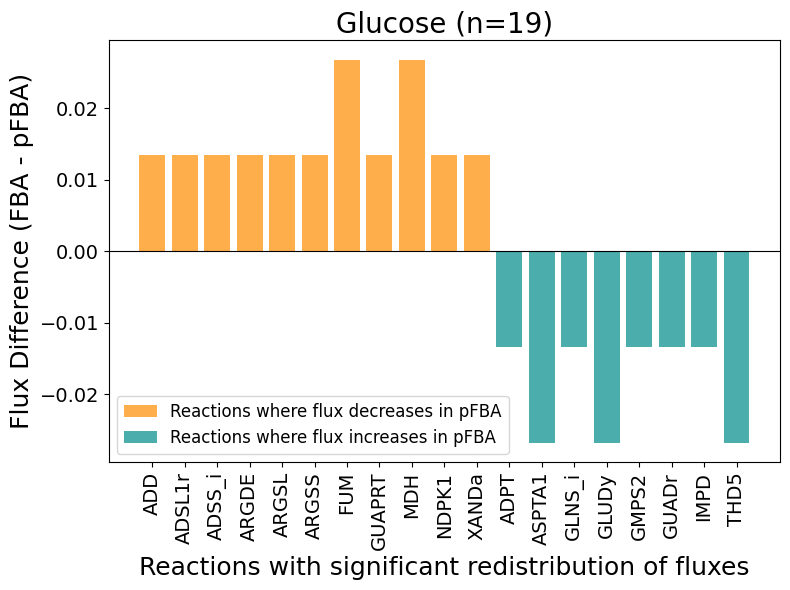

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cobra.flux_analysis import pfba

# Perform pFBA on the model
pfba_solution_gluc = pfba(model_gluc)

# Standard FBA solution for comparison
solution_gluc = model_gluc.optimize()

# Compute the flux difference (without absolute value)
flux_diff_gluc = solution_gluc.fluxes - pfba_solution_gluc.fluxes
flux_diff_gluc = pd.Series(flux_diff_gluc)  # Ensure it's a Pandas Series

# Print some statistics to debug
#print("Flux Difference Summary:")
#print(flux_diff.describe())

# Set a lower threshold to capture more reactions
threshold = 0.01
significant_reactions_gluc = flux_diff_gluc[abs(flux_diff_gluc) > threshold]
#print(significant_reactions)

# Print count of significant reactions
print(f"Number of significant reactions: {len(significant_reactions_gluc)}")

# Separate reactions into those that decreased (FBA > pFBA) and those that increased (FBA < pFBA)
reactions_fba_gluc = significant_reactions_gluc[significant_reactions_gluc > 0]  # Red, going downward
reactions_pfba_gluc = significant_reactions_gluc[significant_reactions_gluc < 0]  # Blue, going upward

# Ensure we have data to plot
if len(significant_reactions_gluc) > 0:
    # Plot significant flux changes
    plt.figure(figsize=(8, 6))

    # Plot FBA fluxes (negative direction)
    plt.bar(reactions_fba_gluc.index, reactions_fba_gluc.values, color="darkorange", label="Reactions where flux decreases in pFBA", alpha=0.7)

    # Plot pFBA fluxes (positive direction)
    plt.bar(reactions_pfba_gluc.index, reactions_pfba_gluc.values, color="darkcyan", label="Reactions where flux increases in pFBA", alpha=0.7)

    plt.xlabel("Reactions with significant redistribution of fluxes", size=18)
    plt.ylabel("Flux Difference (FBA - pFBA)", size=18)
    plt.title(f"Glucose (n={len(significant_reactions_gluc)})", fontsize=20)
    plt.xticks(rotation=90, fontsize=14)
    plt.yticks(fontsize=14)  # Increase y-axis font size
    plt.axhline(0, color='black', linewidth=0.8)
    # Add legend
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.savefig("flux_comparison_gluc.pdf", format="pdf", bbox_inches="tight")
    plt.show()
else:
    print("No significant flux changes found. Try lowering the threshold.")


In [ ]:
# Find identity of reactions

#GLUDy #glutamate dehydrogenase (NADP)
#LEUTA #leucine transaminase
#LLEUDr #	L-leucine dehydrogenase
#SSALx #succinate-semialdehyde dehydrogenase (NAD)
#SSALy #succinate-semialdehyde dehydrogenase (NADP)
#THD5 #NAD transhydrogenase

model.reactions.get_by_id("THD5")


Reaction identifier,THD5
Name,NAD transhydrogenase
Memory address,0x7be8b5927bd0
Stoichiometry,nad_c + nadph_c --> nadh_c + nadp_c Nicotinamide adenine dinucleotide + Nicotinamide adenine dinucleotide phosphate - reduced --> Nicotinamide adenine dinucleotide - reduced + Nicotinamide adenine dinucleotide phosphate
GPR,PA0195 and PA0196
Lower bound,0.0
Upper bound,1000.0


In [ ]:
import pandas as pd

# Create a list to store reaction details
reaction_details = []

# Loop through each significant reaction
for rxn_id in significant_reactions_gluc.index:
    reaction = model_gluc.reactions.get_by_id(rxn_id)
    reaction_details.append({
        "Reaction ID": rxn_id,
        "Reaction Name": reaction.name

    })

# Convert to DataFrame
reaction_df = pd.DataFrame(reaction_details)

# Display the first few rows
print(reaction_df.head())

# Save to CSV for further analysis
reaction_df.to_excel("reactions_significant_flux_changes_gluc.xlsx", index=False) # export to consult with chatgpt


  Reaction ID                      Reaction Name
0         ADD                  adenine deaminase
1        ADPT  adenine phosphoribosyltransferase
2      ADSL1r              adenylsuccinate lyase
3      ADSS_i        adenylosuccinate synthetase
4       ARGDE                 arginine deiminase


## Resource investment under succinate

In [ ]:
from cobra.flux_analysis import flux_variability_analysis
from cobra import Model, Reaction, Metabolite

# Assuming your model is already loaded into the `model` variable

# FBA Optimization
fba_solution_succ = model_succ.optimize()
fba_growth_rate_succ = fba_solution_succ.objective_value  # This will give you the growth rate from FBA

# pFBA Optimization (parsimonious FBA)
# For pFBA, we need to add a minimization term for the total flux in addition to the biomass optimization
model_succ.objective = biomass_rxn  # Set the biomass reaction as the objective (replace with your actual biomass reaction ID)
pFBA_solution_succ = model_succ.optimize()
pFBA_growth_rate_succ = pFBA_solution_succ.objective_value  # This will give you the growth rate from pFBA

# Print out the growth rates from both FBA and pFBA
print(f"Growth Rate from FBA: {fba_growth_rate_succ}")
print(f"Growth Rate from pFBA: {pFBA_growth_rate_succ}")



Growth Rate from FBA: 1.1056058375145887
Growth Rate from pFBA: 1.1056058375145887


significant_reactions_succ ALATA_L    0.585985
ASP1DC     0.585985
ASPTA1    -0.585985
BALAAT    -0.585985
GLUDy      7.507065
LEUTA      7.507065
LLEUD      7.507065
MDH        0.585985
ME1x       6.921080
ME2       -7.507065
MMSAD3     0.585985
PDH       -0.585985
Name: fluxes, dtype: float64
Number of significant reactions: 12


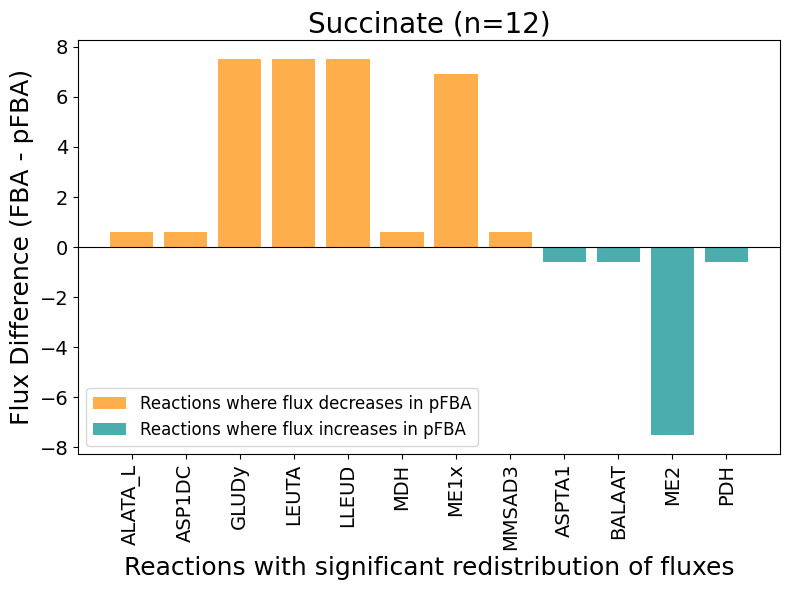

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cobra.flux_analysis import pfba

# Perform pFBA on the model
pfba_solution_succ = pfba(model_succ)

# Standard FBA solution for comparison
solution_succ = model_succ.optimize()

# Compute the flux difference (without absolute value)
flux_diff_succ = solution_succ.fluxes - pfba_solution_succ.fluxes
flux_diff_succ = pd.Series(flux_diff_succ)  # Ensure it's a Pandas Series

# Print some statistics to debug
#print("Flux Difference Summary:")
#print(flux_diff_succ.describe())

# Set a lower threshold to capture more reactions
threshold = 0.01
significant_reactions_succ = flux_diff_succ[abs(flux_diff_succ) > threshold]
print('significant_reactions_succ', significant_reactions_succ)

# Print count of significant reactions
print(f"Number of significant reactions: {len(significant_reactions_succ)}")

# Separate reactions into those that decreased (FBA > pFBA) and those that increased (FBA < pFBA)
reactions_fba_succ = significant_reactions_succ[significant_reactions_succ > 0]  # Red, going downward
reactions_pfba_succ = significant_reactions_succ[significant_reactions_succ < 0]  # Blue, going upward

# Ensure we have data to plot
if len(significant_reactions_succ) > 0:
    # Plot significant flux changes
    plt.figure(figsize=(8, 6))

    # Plot FBA fluxes (negative direction)
    plt.bar(reactions_fba_succ.index, reactions_fba_succ.values, color="darkorange", label="Reactions where flux decreases in pFBA", alpha=0.7)

    # Plot pFBA fluxes (positive direction)
    plt.bar(reactions_pfba_succ.index, reactions_pfba_succ.values, color="darkcyan", label="Reactions where flux increases in pFBA", alpha=0.7)

    plt.xlabel("Reactions with significant redistribution of fluxes", size= 18)
    plt.ylabel("Flux Difference (FBA - pFBA)", size= 18)
    plt.title(f"Succinate (n={len(significant_reactions_succ)})", fontsize=20)
    plt.xticks(rotation=90, fontsize=14)
    plt.yticks(fontsize=14)  # Increase y-axis font size
    plt.axhline(0, color='black', linewidth=0.8)
    # Add legend
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.savefig("flux_comparison_succ.pdf", format="pdf", bbox_inches="tight")

    plt.show()
else:
    print("No significant flux changes found. Try lowering the threshold.")



In [ ]:
import pandas as pd

# Create a list to store reaction details
reaction_details = []

# Loop through each significant reaction
for rxn_id in significant_reactions_succ.index:
    reaction = model_succ.reactions.get_by_id(rxn_id)
    reaction_details.append({
        "Reaction ID": rxn_id,
        "Reaction Name": reaction.name

    })

#"Reaction ID": rxn_id,
#"Reaction Name": reaction.name,
#"Equation": reaction.reaction,
#"Subsystem": reaction.subsystem,
#"Flux Difference": significant_reactions_succ[rxn_id]

# Convert to DataFrame
reaction_df = pd.DataFrame(reaction_details)

# Display the first few rows
print(reaction_df.head())

# Save to CSV for further analysis
reaction_df.to_excel("reactions_significant_flux_changes_succ.xlsx", index=False) # export to consult with chatgpt


  Reaction ID                        Reaction Name
0     ALATA_L               L-alanine transaminase
1      ASP1DC            aspartate 1-decarboxylase
2      ASPTA1               aspartate transaminase
3      BALAAT  beta-alanine--pyruvate transaminase
4       GLUDy       glutamate dehydrogenase (NADP)


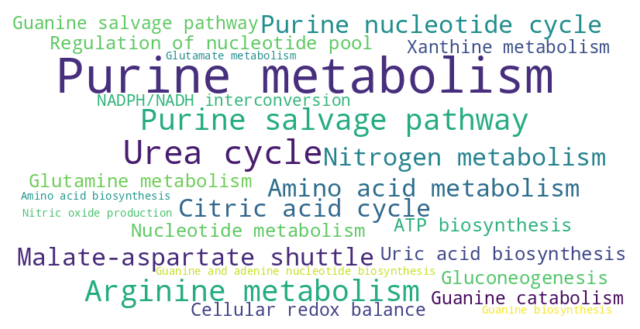

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# List of pathways for the reactions
pathways = [
    "Purine metabolism", "Purine metabolism", "Purine metabolism", "Purine metabolism",
    "Purine salvage pathway", "Purine metabolism", "Purine salvage pathway",
    "Purine metabolism", "Purine nucleotide cycle", "Purine nucleotide cycle",
    "Arginine metabolism", "Urea cycle", "Nitric oxide production",
    "Urea cycle", "Arginine metabolism", "Urea cycle", "Arginine metabolism",
    "Amino acid metabolism", "Gluconeogenesis", "Urea cycle",
    "Citric acid cycle", "Malate-aspartate shuttle", "Nitrogen metabolism",
    "Glutamine metabolism", "Amino acid biosynthesis", "Glutamate metabolism",
    "Amino acid metabolism", "Nitrogen metabolism", "Purine metabolism",
    "Guanine biosynthesis", "Purine metabolism", "Guanine catabolism",
    "Purine salvage pathway", "Purine metabolism", "Guanine salvage pathway",
    "Purine metabolism", "Guanine and adenine nucleotide biosynthesis",
    "Citric acid cycle", "Malate-aspartate shuttle", "Nucleotide metabolism",
    "ATP biosynthesis", "Regulation of nucleotide pool",
    "Cellular redox balance", "NADPH/NADH interconversion",
    "Purine metabolism", "Xanthine metabolism", "Uric acid biosynthesis"
]

# Create a frequency dictionary for the pathways
pathway_freq = {pathway: pathways.count(pathway) for pathway in set(pathways)}

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(pathway_freq)

# Create a figure and display the word cloud
plt.figure(figsize=(8, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

# Save the word cloud as a PDF file
plt.savefig("wordcloud_pathways_glucose2.pdf", format="pdf", bbox_inches="tight")

# Optionally, show the word cloud as well
plt.show()


## Investigate number of genes, metabolites and reactions involved in each scenario

In [ ]:
growth_rates_gluc = np.linspace(0.1, solution_gluc.objective_value, 10)  # Adjust number of growth rates as needed
for gr in growth_rates_gluc:
    with model_gluc:
      biomass = model_gluc.reactions.get_by_id(biomass_rxn)
      print(biomass.upper_bound)

1000.0
1000.0
1000.0
1000.0
1000.0
1000.0
1000.0
1000.0
1000.0
1000.0


0.1
0.32176190043356434
0.5435238008671287
0.7652857013006931
0.9870476017342574
1.208809502167822
1.4305714026013863
1.6523333030349505
1.874095203468515
2.0958571039020795


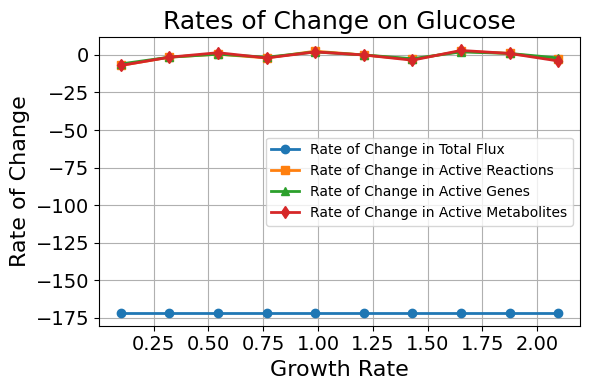

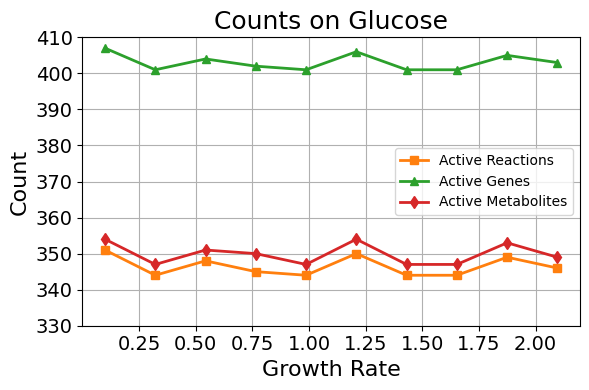

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cobra.flux_analysis import pfba

# Define biomass reaction (ensure this is the correct biomass reaction ID for the glucose model)
biomass_rxn = "PA_Biomass6_DM"  # Replace with correct biomass reaction ID if different

# Define the growth rates (adjust according to the glucose model's objective value)
growth_rates_gluc = np.linspace(0.1, solution_gluc.objective_value, 10)  # Adjust number of growth rates as needed

# Initialize lists to store results
total_flux_values = []
active_reactions = []  # Number of active reactions
active_genes = []  # Number of active genes
active_metabolites = []  # Number of active metabolites

# Loop over growth rates and solve the model at each rate
for gr in growth_rates_gluc:
    print(gr)
    with model_gluc:
        # Set biomass reaction bounds to the current growth rate
        biomass = model_gluc.reactions.get_by_id(biomass_rxn)
        biomass.upper_bound = gr
        biomass.lower_bound = gr

        # Run optimization with the new growth rate constraint
        sol = model_gluc.optimize()

        # Compute total flux (sum of absolute values of fluxes)
        total_flux = sum(abs(flux) for flux in sol.fluxes)
        total_flux_values.append(total_flux)

        # Count active reactions (reactions with non-zero flux)
        active_reactions_count = sum(1 for flux in sol.fluxes if flux != 0)
        active_reactions.append(active_reactions_count)

        # Count active genes (genes associated with active reactions)
        active_genes_count = set()
        for reaction_id, flux in sol.fluxes.items():
            if flux != 0:
                reaction = model_gluc.reactions.get_by_id(reaction_id)
                for gene in reaction.genes:
                    active_genes_count.add(gene)
        active_genes.append(len(active_genes_count))

        # Count active metabolites (metabolites involved in active reactions)
        active_metabolites_count = set()
        for reaction_id, flux in sol.fluxes.items():
            if flux != 0:
                reaction = model_gluc.reactions.get_by_id(reaction_id)
                for metabolite in reaction.metabolites:
                    active_metabolites_count.add(metabolite)
        active_metabolites.append(len(active_metabolites_count))

# Calculate the rate of change (first derivative) using np.gradient
d_growth_rate = np.gradient(growth_rates_gluc)  # The growth rate changes (this is just the difference)
d_flux = np.gradient(total_flux_values)
d_reactions = np.gradient(active_reactions)
d_genes = np.gradient(active_genes)
d_metabolites = np.gradient(active_metabolites)

# Plot the first derivatives of the various quantities
plt.figure(figsize=(6, 4))
plt.plot(growth_rates_gluc, d_flux, marker="o", linewidth=2, label="Rate of Change in Total Flux", color="#1f77b4")  # Soft Blue
plt.plot(growth_rates_gluc, d_reactions, marker="s", linewidth=2, label="Rate of Change in Active Reactions", color="#ff7f0e")  # Warm Orange
plt.plot(growth_rates_gluc, d_genes, marker="^", linewidth=2, label="Rate of Change in Active Genes", color="#2ca02c")  # Soft Green
plt.plot(growth_rates_gluc, d_metabolites, marker="d", linewidth=2, label="Rate of Change in Active Metabolites", color="#d62728")  # Soft Red

plt.xlabel("Growth Rate", fontsize=16)
plt.ylabel("Rate of Change", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)  # Increase y-axis font size
plt.title("Rates of Change on Glucose", fontsize=18)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()

# Save the plot to a PDF
plt.savefig("rate_of_change_growth_rate_gluc.pdf", format="pdf", bbox_inches="tight")

# Show the plot
plt.show()

# ---------------------- NEW PLOT ----------------------
# Plot the actual number of reactions, genes, and metabolites

plt.figure(figsize=(6, 4))
plt.plot(growth_rates_gluc, active_reactions, marker="s", linewidth=2, label="Active Reactions", color="#ff7f0e")
plt.plot(growth_rates_gluc, active_genes, marker="^", linewidth=2, label="Active Genes", color="#2ca02c")
plt.plot(growth_rates_gluc, active_metabolites, marker="d", linewidth=2, label="Active Metabolites", color="#d62728")

plt.xlabel("Growth Rate", fontsize=16)
plt.ylabel("Count", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14) # Increase y-axis font size
plt.ylim(330, 410)  # Set y-axis range

plt.title("Counts on Glucose", fontsize=18)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()

# Save the plot to a PDF
plt.savefig("active_counts_growth_rate_gluc.pdf", format="pdf", bbox_inches="tight")

# Show the plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define Min-Max Normalization function
def min_max_normalize(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

# Normalize Glucose Data
d_flux_gluc_norm = min_max_normalize(d_flux)
d_reactions_gluc_norm = min_max_normalize(d_reactions)
d_genes_gluc_norm = min_max_normalize(d_genes)
d_metabolites_gluc_norm = min_max_normalize(d_metabolites)

# Normalize Succinate Data
d_flux_succ_norm = min_max_normalize(d_flux_succ)
d_reactions_succ_norm = min_max_normalize(d_reactions_succ)
d_genes_succ_norm = min_max_normalize(d_genes_succ)
d_metabolites_succ_norm = min_max_normalize(d_metabolites_succ)

# --- Create Figure with 4 Subplots ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
titles = ["Total Flux", "Active Reactions", "Active Genes", "Active Metabolites"]
data_gluc = [d_flux_gluc_norm, d_reactions_gluc_norm, d_genes_gluc_norm, d_metabolites_gluc_norm]
data_succ = [d_flux_succ_norm, d_reactions_succ_norm, d_genes_succ_norm, d_metabolites_succ_norm]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for i, ax in enumerate(axes.flat):
    ax.plot(growth_rates_gluc, data_gluc[i], marker="o", linestyle="--", linewidth=2,
            label=f"{titles[i]} (Glucose)", color=colors[i])
    ax.plot(growth_rates, data_succ[i], marker="s", linewidth=2,
            label=f"{titles[i]} (Succinate)", color=colors[i], alpha=0.6)

    ax.set_xlabel("Growth Rate", fontsize=14)
    ax.set_ylabel("Normalized Rate of Change", fontsize=14)
    ax.set_title(f"{titles[i]} Comparison", fontsize=16)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)

# Adjust layout
plt.tight_layout()
plt.savefig("normalized_rate_of_change_subplots.pdf", format="pdf", bbox_inches="tight")

# Show the plots
plt.show()


NameError: name 'd_flux_succ' is not defined

0.1
0.21173398194606563
0.3234679638921313
0.4352019458381968
0.5469359277842625
0.6586699097303281
0.7704038916763937
0.8821378736224593
0.993871855568525
1.1056058375145907


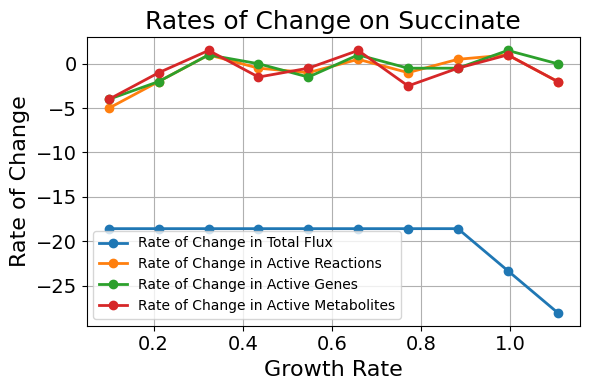

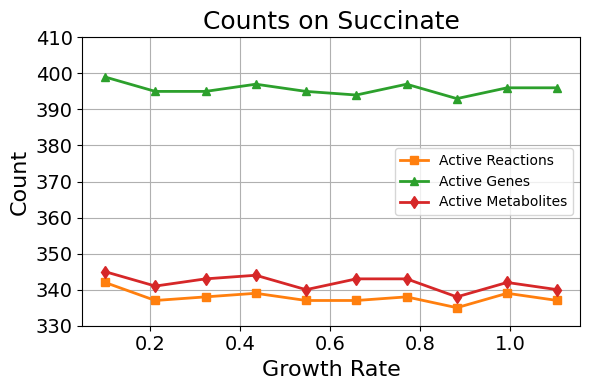

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cobra.flux_analysis import pfba

# Define biomass reaction (ensure this is the correct biomass reaction ID)
biomass_rxn = "PA_Biomass6_DM"  # Replace with correct ID if different

# Define the growth rates
growth_rates = np.linspace(0.1, solution_succ.objective_value, 10)  # Adjust number of growth rates as needed

# Initialize lists to store results
total_flux_values = []
active_reactions = []  # Number of active reactions
active_genes = []  # Number of active genes
active_metabolites = []  # Number of active metabolites

# Loop over growth rates and solve the model at each rate
for gr in growth_rates:
    print(gr)
    with model_succ:
        # Set biomass reaction bounds to the current growth rate
        biomass = model_succ.reactions.get_by_id(biomass_rxn)
        biomass.lower_bound = gr
        biomass.upper_bound = gr

        # Run optimization with the new growth rate constraint
        sol = model_succ.optimize()

        # Compute total flux (sum of absolute values of fluxes)
        total_flux = sum(abs(flux) for flux in sol.fluxes)
        total_flux_values.append(total_flux)

        # Count active reactions (reactions with non-zero flux)
        active_reactions_count = sum(1 for flux in sol.fluxes if flux != 0)
        active_reactions.append(active_reactions_count)

        # Count active genes (genes associated with active reactions)
        active_genes_count = set()
        for reaction_id, flux in sol.fluxes.items():
            if flux != 0:
                reaction = model_succ.reactions.get_by_id(reaction_id)
                for gene in reaction.genes:
                    active_genes_count.add(gene)
        active_genes.append(len(active_genes_count))

        # Count active metabolites (metabolites involved in active reactions)
        active_metabolites_count = set()
        for reaction_id, flux in sol.fluxes.items():
            if flux != 0:
                reaction = model_succ.reactions.get_by_id(reaction_id)
                for metabolite in reaction.metabolites:
                    active_metabolites_count.add(metabolite)
        active_metabolites.append(len(active_metabolites_count))

# Calculate the rate of change (first derivative) using np.gradient
d_growth_rate = np.gradient(growth_rates)  # The growth rate changes (this is just the difference)
d_flux = np.gradient(total_flux_values)
d_reactions = np.gradient(active_reactions)
d_genes = np.gradient(active_genes)
d_metabolites = np.gradient(active_metabolites)

# Plot the first derivatives of the various quantities
plt.figure(figsize=(6, 4))
plt.plot(growth_rates, d_flux, marker="o", linewidth=2,label="Rate of Change in Total Flux", color="#1f77b4")
plt.plot(growth_rates, d_reactions, marker="o", linewidth=2,label="Rate of Change in Active Reactions", color="#ff7f0e")
plt.plot(growth_rates, d_genes, marker="o", linewidth=2,label="Rate of Change in Active Genes", color="#2ca02c")
plt.plot(growth_rates, d_metabolites, marker="o", linewidth=2,label="Rate of Change in Active Metabolites", color="#d62728")

plt.xlabel("Growth Rate", fontsize=16)
plt.ylabel("Rate of Change", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14) # Increase y-axis font size
plt.title("Rates of Change on Succinate", fontsize=18)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()

# Save the plot to a PDF
plt.savefig("rate_of_change_growth_rate_succ.pdf", format="pdf", bbox_inches="tight")

# Show the plot
plt.show()

# ---------------------- NEW PLOT ----------------------
# Plot the actual number of reactions, genes, and metabolites

plt.figure(figsize=(6, 4))
plt.plot(growth_rates, active_reactions, marker="s", linewidth=2,label="Active Reactions", color="#ff7f0e")
plt.plot(growth_rates, active_genes, marker="^", linewidth=2,label="Active Genes", color="#2ca02c")
plt.plot(growth_rates, active_metabolites, marker="d", linewidth=2,label="Active Metabolites", color="#d62728")

plt.xlabel("Growth Rate", fontsize=16)
plt.ylabel("Count", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14) # Increase y-axis font size
plt.ylim(330, 410)  # Set y-axis range

plt.title("Counts on Succinate", fontsize=18)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()

# Save the plot to a PDF
plt.savefig("active_counts_growth_rate_succ.pdf", format="pdf", bbox_inches="tight")

# Show the plot
plt.show()


## FBA deletions

In [ ]:
from cobra.flux_analysis import single_gene_deletion

gene_deletion_results = single_gene_deletion(model_succ)
print(gene_deletion_results.sort_values("growth", ascending=True).head(10))


In [ ]:
model.reactions.get_by_id("GAPD") #PA3195


NameError: name 'model' is not defined

In [ ]:
from cobra.io import load_model
from cobra.flux_analysis import (
    single_gene_deletion, single_reaction_deletion, double_gene_deletion, double_reaction_deletion)

# List of genes you want to knockout
genes_to_ko = ['PA2323', 'PA3195']

# Perform single gene deletion
single_ko_results = single_gene_deletion(model, genes_to_ko)

# Perform double gene deletion
double_ko_results = double_gene_deletion(model, genes_to_ko)

# Print single gene knockout results
print("Single Gene Knockouts:")
print(single_ko_results)

# Print double gene knockout results
print("Double Gene Knockouts:")
print(double_ko_results)


Single Gene Knockouts:
        ids    growth   status
0  {PA2323}  1.047929  optimal
1  {PA3195}  1.004026  optimal
Double Gene Knockouts:
                ids    growth   status
0          {PA2323}  1.047929  optimal
1          {PA3195}  1.004026  optimal
2  {PA3195, PA2323}  1.004026  optimal


In [ ]:
model.reactions.get_by_id("GAPDy1") #PA2323 or #PA3001


Reaction identifier,GAPDy1
Name,glyceraldehyde-3-phosphate dehydrogenase (NADP)
Memory address,0x7b671a215710
Stoichiometry,g3p_c + h2o_c + nadp_c --> 3pg_c + 2.0 h_c + nadph_c Glyceraldehyde 3-phosphate + H2O + Nicotinamide adenine dinucleotide phosphate --> 3-Phospho-D-glycerate + 2.0 H+ + Nicotinamide adenine dinucleotide phosphate - reduced
GPR,PA2323 or PA3001
Lower bound,0.0
Upper bound,1000.0


# Code for loading and running GEM Zhu, 2018

In [ ]:

reaction = cobra.Reaction(data["Rxn No."])
reaction.name = data["Rxn Name"]
reaction.lower_bound = data["LB"]
reaction.upper_bound = data["UB"]

# Set reversibility
reaction.reversibility = data["Reversible"]

# Define reaction formula
#reaction.formula = string(row["Reaction Formula"])
# Define reaction formula
reaction.formula = data["Formula"]
print(reaction.formula)

# Add the reaction to the model
model.add_reactions([reaction])

# Save the updated model
#cobra.io.write_sbml_model(model, "updated_model.xml")

#print(f"Added {len(reactions_df)} reactions to the model.")


In [ ]:
import cobra
import pandas as pd

# Load COBRA model

# Load reactions from Excel
reactions_df = pd.read_excel("additionalFile16.xlsx", header=2)

# Iterate over the reactions and add them to the model
for _, row in reactions_df.iterrows():
    reaction_id = row["Reaction ID"]
    reaction_name = row["Reaction Name"]
    reaction_formula = str(row["Reaction Formula"]).strip()  # Ensure it's a string

    # Skip empty reaction formulas
    if not reaction_formula or reaction_formula.lower() == "nan":
        print(f"Skipping reaction {reaction_id}: empty formula")
        continue

    # Create reaction
    reaction = cobra.Reaction(reaction_id)
    reaction.name = reaction_name
    reaction.lower_bound = row["Lower Bound"]
    reaction.upper_bound = row["Upper Bound"]
    reaction.reaction = reaction_formula

    # Add reaction to model
    model.add_reactions([reaction])
    print(f'{len(model.reactions)} reactions')


In [ ]:
model.reactions[29]


Reaction identifier,EX_cpd00064(e)
Name,EX L-Ornithine e
Memory address,0x7c925444f090
Stoichiometry,<=> <=>
GPR,
Lower bound,-1000
Upper bound,1000


In [ ]:
# Dictionary to store metabolites for reference
metabolites_dict = {}

for _, row in metabolites.iterrows():
    met = cobra.Metabolite(
        id=row["Model ID (in MATLAB)"],  # COBRApy requires unique IDs
        name=row["Metabolite Name"],
        compartment=row["Compartment"],
        formula=row["Charged Formula"],
        charge=row["Charge"] if pd.notna(row["Charge"]) else None  # Handle NaN values
    )

    # Add additional metadata if available
    met.annotation = {
        "KEGG": row["KEGG Identifier"] if pd.notna(row["KEGG Identifier"]) else None,
        "MetaCyc": row["MetaCyc Identifier"] if pd.notna(row["MetaCyc Identifier"]) else None,
        "PubChem": row["PubChem CID"] if pd.notna(row["PubChem CID"]) else None,
        "CHEBI": row["CHEBI Identifier"] if pd.notna(row["CHEBI Identifier"]) else None,
        "InChI": row["Inchi String"] if pd.notna(row["Inchi String"]) else None,
        "SMILES": row["Smile"] if pd.notna(row["Smile"]) else None
    }

    model.add_metabolites([met])
    metabolites_dict[row["Model ID"]] = met  # Store for use in reactions


In [ ]:
model.reactions

[]

In [ ]:
for _, row in reactions.iterrows():
    reaction_id = row["Reaction ID"]

    print(reaction_formula)

In [ ]:
model.reactions.get_by_id('rxn05330')

Reaction identifier,rxn05330
Name,(3R)-3-Hydroxybutanoyl-ACP hydrolyase
Memory address,0x7c925784b5d0
Stoichiometry,<=> <=>
GPR,
Lower bound,-1000
Upper bound,1000


In [ ]:
for _, row in genes.iterrows():
    gene = cobra.Gene(row["Locus Tag"]) #Gene ID
    gene.name = row["Annotation"]

    model.genes.append(gene)  # Add gene to model


In [ ]:
model.genes.get_by_id('PA0005')

Gene identifier,PA0005
Name,lysophosphatidic acid acyltransferase
Memory address,0x7c9255b43890
Functional,True
In 0 reaction(s),


In [ ]:
model.metabolites.get_by_id('cpd00117_e')

Metabolite identifier,cpd00117_e
Name,D-Alanine[e]
Memory address,0x7c9264e0cf90
Formula,None
Compartment,e
In 0 reaction(s),


# Parte final de modelo de ejmplo de E. coli

# Análisis del Modelo e importación

In [ ]:
model.summary() #resumen del modelo

Metabolite,Reaction,Flux,C-Number,C-Flux
Metabolite,Reaction,Flux,C-Number,C-Flux


# Verificar reacciones:

In [ ]:
model.reactions

[<Reaction ACALD at 0x79e0735769d0>,
 <Reaction ACALDt at 0x79e073576990>,
 <Reaction ACKr at 0x79e073577910>,
 <Reaction ACONTa at 0x79e073577890>,
 <Reaction ACONTb at 0x79e08d259d50>,
 <Reaction ACt2r at 0x79e07356dc50>,
 <Reaction ADK1 at 0x79e0735d5bd0>,
 <Reaction AKGDH at 0x79e07356ec90>,
 <Reaction AKGt2r at 0x79e078b011d0>,
 <Reaction ALCD2x at 0x79e07356ff10>,
 <Reaction ATPM at 0x79e07356fed0>,
 <Reaction ATPS4r at 0x79e073563150>,
 <Reaction Biomass_Ecoli_core at 0x79e073563110>,
 <Reaction CO2t at 0x79e073577d90>,
 <Reaction CS at 0x79e07355d610>,
 <Reaction CYTBD at 0x79e07355d650>,
 <Reaction D_LACt2 at 0x79e07356c410>,
 <Reaction ENO at 0x79e07356e0d0>,
 <Reaction ETOHt2r at 0x79e0735468d0>,
 <Reaction EX_ac_e at 0x79e073545350>,
 <Reaction EX_acald_e at 0x79e073547310>,
 <Reaction EX_akg_e at 0x79e07356d410>,
 <Reaction EX_co2_e at 0x79e0735e0510>,
 <Reaction EX_etoh_e at 0x79e0735e08d0>,
 <Reaction EX_for_e at 0x79e073563350>,
 <Reaction EX_fru_e at 0x79e0735e1050>,
 

In [ ]:
# Verificar el identificador correcto de la reacción de biomasa
for reaction in model.reactions:
    print(reaction.id)

In [ ]:
# Asignar la función objetivo: biomasa
model.objective = 'Biomass_Ecoli_core'

Límite de glucosa: Establecemos un límite para el flujo de entrada de glucosa, que es una fuente importante de carbono en el metabolismo de P. aeruginosa.

In [ ]:
# Limitar la disponibilidad de glucosa (entrada a través de EX_glc__D_e)
model.reactions.get_by_id('EX_glc__D_e').lower_bound = -10.0  # mmol/gDW/h




El valor "10.0" en -10.0 mmol/gDW/h indica que la célula tiene permitido consumir hasta 10 mmol de glucosa por gramo de peso seco de célula (gDW) por hora.

Esta cantidad refleja la velocidad máxima de consumo de glucosa. En este caso, limitamos el flujo de entrada de glucosa a 10 mmol/gDW/h para simular una situación donde la disponibilidad de glucosa es limitada, algo que se puede observar en cultivos controlados o condiciones experimentales.


En FBA, los signos de los flujos tienen una interpretación importante:
Un flujo negativo en una reacción de intercambio (como 'EX_glc__D_e', que representa el intercambio de glucosa entre la célula y el entorno) significa que la célula consume glucosa desde el medio externo.
Un flujo positivo en una reacción de intercambio significaría que el compuesto se está produciendo o excretando por la célula al medio.
En el caso de la glucosa:

Un flujo negativo, como -10.0, significa que la célula está importando glucosa desde el medio externo hacia su interior a una tasa máxima de 10 mmol/gDW/h.

Optimización: Realizamos el análisis de balance de flujo (FBA) para maximizar el crecimiento celular.

In [ ]:
# Ejecutar la optimización del modelo
solution = model.optimize()

In [ ]:
# Mostrar el valor de la función objetivo (tasa de crecimiento)
print(f"Tasa de crecimiento: {solution.objective_value:.4f} h^-1")

Tasa de crecimiento: 0.8739 h^-1



La tasa de crecimiento que obtienes al optimizar el modelo metabólico en COBRApy, específicamente en análisis de balance de flujo (FBA), generalmente tiene unidades de h⁻¹ (inverso de horas). Esto indica la fracción del crecimiento celular por hora, conocida como tasa específica de crecimiento.

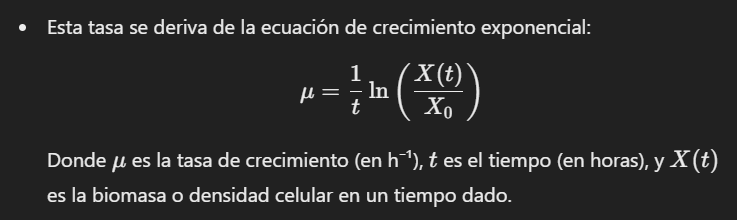

Producción de acetato: Al final, obtenemos el flujo de producción de acetato (reacción 'EX_ac_e'), que es un subproducto importante en muchas condiciones de cultivo de P. aeruginosa.

In [ ]:
# Obtener el flujo de la reacción de producción de acetato (EX_ac_e)
acetate_flux = model.reactions.get_by_id('EX_ac_e').flux
print(f"Producción de acetato: {acetate_flux:.4f} mmol/gDW/h")

Producción de acetato: 0.0000 mmol/gDW/h
